In [476]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import pandas as pd
import os

MASTER_PATH = "/content/drive/MyDrive/EV_Battery_Intelligence/data/processed/master_df.csv"

master_df = pd.read_csv(MASTER_PATH)

print("✅ Master dataset loaded successfully")
print("Shape:", master_df.shape)
print("Columns:")
print(master_df.columns.tolist())

✅ Master dataset loaded successfully
Shape: (2794, 8)
Columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity']


In [7]:
master_df.head()

,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity
0,B0005,2,3.529829,-1.818702,38.982181,2.612467,3690.234,1.856487
1,B0005,4,3.537320,-1.817560,39.033398,2.587209,3672.344,1.846327
2,B0005,6,3.543737,-1.816487,38.818797,2.651917,3651.641,1.835349
3,B0005,8,3.543666,-1.825589,38.762305,2.592948,3631.563,1.835263
4,B0005,10,3.542343,-1.826114,38.665393,2.547420,3629.172,1.834646


In [8]:
print(master_df.columns)

Index(['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature',
       'Min_Voltage', 'Discharge_Time', 'Capacity'],
      dtype='object')


In [9]:
print(master_df.shape)

(2794, 8)


In [10]:
print(master_df.isnull().sum())

Battery_ID         0
Cycle              0
Avg_Voltage        0
Avg_Current        0
Max_Temperature    0
Min_Voltage        0
Discharge_Time     0
Capacity           0
dtype: int64


In [11]:
# Create SOH from battery capacity

master_df["SOH"] = (master_df["Capacity"] / 2.0) * 100

print("✅ SOH column created")
print("Columns:", master_df.columns.tolist())

master_df[["Capacity", "SOH"]].describe()

✅ SOH column created
Columns: ['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH']


,Capacity,SOH
count,2794.000000,2794.000000
mean,1.314674,65.733684
std,0.486707,24.335350
min,0.000000,0.000000
25%,1.138590,56.929505
50%,1.423256,71.162810
75%,1.671882,83.594084
max,2.640149,132.007456


In [12]:
print(master_df['SOH'].min())
print(master_df['SOH'].max())

0.0
132.00745578693505


In [13]:
def battery_health(soh):
    if soh >= 80:
        return "Healthy"
    elif soh >= 60:
        return "Degrading"
    else:
        return "Critical"

master_df['Health'] = master_df['SOH'].apply(battery_health)

In [14]:
print(master_df[['SOH', 'Health']].head(10))

         SOH   Health
0  92.824371  Healthy
1  92.316362  Healthy
2  91.767460  Healthy
3  91.763126  Healthy
4  91.732275  Healthy
5  91.783083  Healthy
6  91.757307  Healthy
7  91.287840  Healthy
8  91.238693  Healthy
9  91.230663  Healthy


In [15]:
print(master_df['Health'].value_counts())

Health
Degrading    1040
Healthy       938
Critical      816
Name: count, dtype: int64


In [16]:
print(master_df[['SOH', 'Health']].sort_values('SOH').head(20))

      SOH    Health
2134  0.0  Critical
2206  0.0  Critical
2418  0.0  Critical
2421  0.0  Critical
2423  0.0  Critical
2422  0.0  Critical
2424  0.0  Critical
2425  0.0  Critical
2426  0.0  Critical
1824  0.0  Critical
2108  0.0  Critical
2379  0.0  Critical
2420  0.0  Critical
2378  0.0  Critical
2410  0.0  Critical
2486  0.0  Critical
2411  0.0  Critical
2278  0.0  Critical
2312  0.0  Critical
2324  0.0  Critical


In [17]:
print(master_df[['SOH', 'Health']].sort_values('SOH').tail(20))

             SOH   Health
178    97.279958  Healthy
189    97.290751  Healthy
191    97.299057  Healthy
177    97.861540  Healthy
188    97.877495  Healthy
176    98.408309  Healthy
175    98.439491  Healthy
187    98.981327  Healthy
1347   99.274648  Healthy
172   100.026417  Healthy
174   100.655055  Healthy
171   100.664233  Healthy
170   100.666319  Healthy
173   100.694954  Healthy
169   101.257012  Healthy
168   101.766880  Healthy
2385  116.543674  Healthy
2335  118.932187  Healthy
1415  122.203122  Healthy
2361  132.007456  Healthy


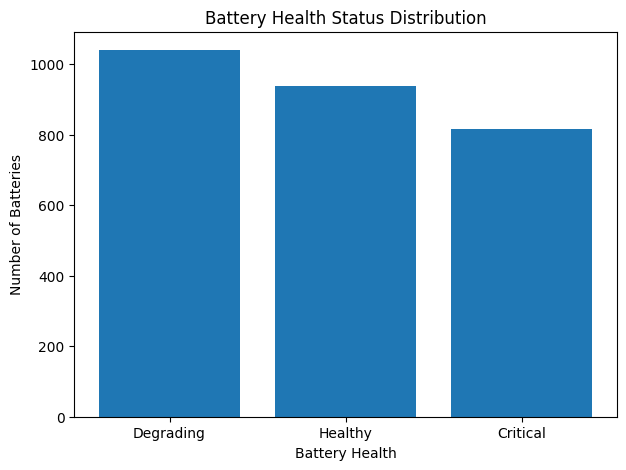

In [18]:
health_counts = master_df['Health'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(health_counts.index, health_counts.values)

plt.xlabel('Battery Health')
plt.ylabel('Number of Batteries')
plt.title('Battery Health Status Distribution')

plt.show()

In [19]:
print("Duplicate rows:", master_df.duplicated().sum())

Duplicate rows: 0


In [20]:
master_df = master_df.drop_duplicates()

In [21]:
print(master_df.shape)

(2794, 10)


In [22]:
master_df.to_csv('/content/cleaned_battery_dataset.csv', index=False)

In [23]:
import os
print(os.path.exists('/content/cleaned_battery_dataset.csv'))

True


In [24]:
import os
print(os.listdir('/content'))

['.config', 'cleaned_battery_dataset.csv', 'drive', 'sample_data']


In [25]:
# ==========================================
# HEALTH CLASSIFICATION DATA
# ==========================================

classification_df = master_df.copy()

# Create SOH
classification_df["SOH"] = (
    classification_df["Capacity"] / 2.0
) * 100

# Remove invalid capacity values
classification_df = classification_df[
    classification_df["Capacity"] > 0
].copy()

# Create Health labels
def battery_health(soh):
    if soh >= 80:
        return "Healthy"
    elif soh >= 60:
        return "Degrading"
    else:
        return "Critical"

classification_df["Health"] = (
    classification_df["SOH"].apply(battery_health)
)

# Features for classification
classification_features = [
    "Cycle",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
]

X = classification_df[classification_features]
y = classification_df["Health"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nHealth distribution:")
print(y.value_counts())

X shape: (2750, 6)
y shape: (2750,)

Health distribution:
Health
Degrading    1040
Healthy       938
Critical      772
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2200, 6)
Testing data: (550, 6)


In [27]:
# ==========================================
# RANDOM FOREST HEALTH CLASSIFICATION
# ==========================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Features
classification_features = [
    "Cycle",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
]

X = classification_df[classification_features]
y = classification_df["Health"]
groups = classification_df["Battery_ID"]

# Battery-wise train/test split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Train Random Forest
health_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

health_model.fit(X_train, y_train)

print("===================================")
print("MODEL TRAINING COMPLETED")
print("===================================")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training batteries:", groups.iloc[train_idx].nunique())
print("Testing batteries:", groups.iloc[test_idx].nunique())
print("Battery overlap:",
      len(
          set(groups.iloc[train_idx])
          & set(groups.iloc[test_idx])
      ))

print("\nClasses:", health_model.classes_)
print("✅ Random Forest health model trained successfully.")

MODEL TRAINING COMPLETED
Training samples: 2328
Testing samples: 422
Training batteries: 27
Testing batteries: 7
Battery overlap: 0

Classes: ['Critical' 'Degrading' 'Healthy']
✅ Random Forest health model trained successfully.


In [28]:
y_pred = health_model.predict(X_test)

print("Prediction completed!")
print("Predictions:", len(y_pred))

Prediction completed!
Predictions: 422


In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9170616113744076
Accuracy Percentage: 91.70616113744076 %


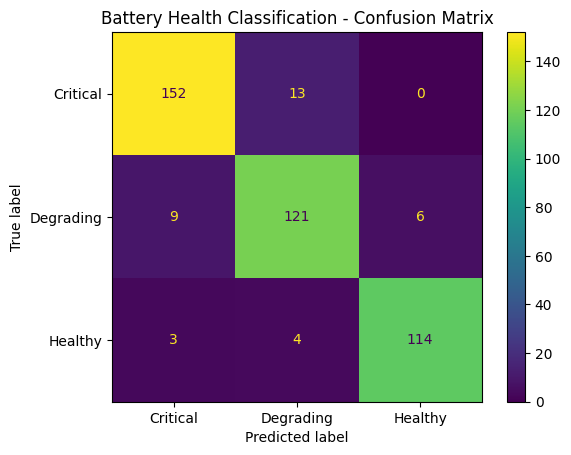

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=health_model.classes_
)

disp.plot()
plt.title("Battery Health Classification - Confusion Matrix")
plt.show()

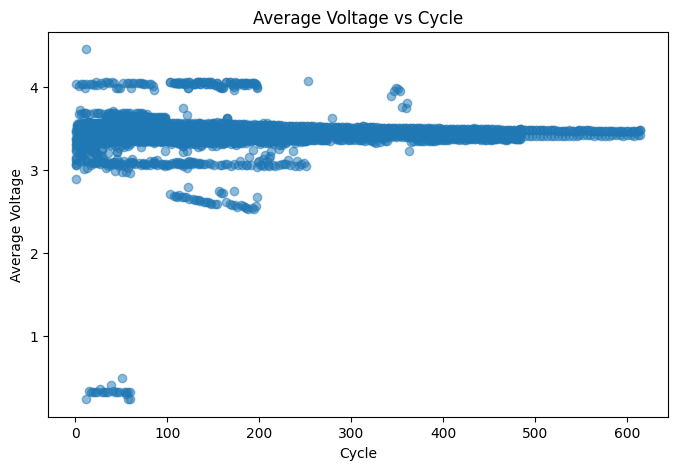

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    master_df["Cycle"],
    master_df["Avg_Voltage"],
    alpha=0.5
)

plt.xlabel("Cycle")
plt.ylabel("Average Voltage")
plt.title("Average Voltage vs Cycle")

plt.show()

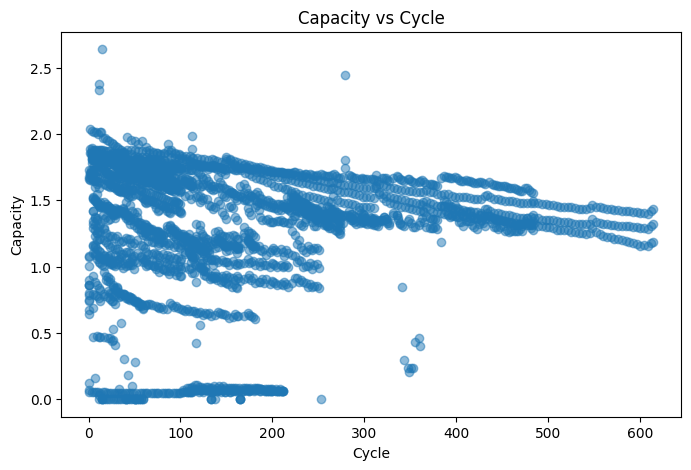

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    master_df["Cycle"],
    master_df["Capacity"],
    alpha=0.5
)

plt.xlabel("Cycle")
plt.ylabel("Capacity")
plt.title("Capacity vs Cycle")

plt.show()

In [33]:
master_df.describe()

,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity,SOH
count,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000
mean,163.996063,3.404579,-1.713299,34.217616,2.303508,3218.719931,1.314674,65.733684
std,143.385837,0.348275,0.794850,16.471197,0.360771,1389.093061,0.486707,24.335350
min,1.000000,0.234723,-3.976473,6.288208,0.192738,23.000000,0.000000,0.000000
25%,53.000000,3.366336,-1.942446,16.689440,2.065549,2504.058500,1.138590,56.929505
50%,120.000000,3.415143,-1.795087,37.821166,2.377473,3030.125000,1.423256,71.162810
75%,237.000000,3.490553,-1.058206,42.578406,2.618483,3385.523500,1.671882,83.594084
max,614.000000,4.452558,0.001803,69.869746,3.838396,6574.671000,2.640149,132.007456


In [34]:
def battery_health(soh):
    if soh >= 80:
        return "Healthy"
    elif soh >= 60:
        return "Degrading"
    else:
        return "Critical"

master_df['Health'] = master_df['SOH'].apply(battery_health)

print(master_df['Health'].value_counts())

Health
Degrading    1040
Healthy       938
Critical      816
Name: count, dtype: int64


In [35]:
# Features
X = classification_df[[
    "Cycle",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
]]

# Target
y = classification_df["Health"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2750, 6)
y shape: (2750,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2200, 6)
Testing data: (550, 6)


In [37]:
importance = health_model.feature_importances_

for feature, value in zip(X.columns, importance):
    print(feature, ":", value)

Cycle : 0.0907628560960701
Avg_Voltage : 0.12598258310695978
Avg_Current : 0.2237686660298683
Max_Temperature : 0.25266912832840316
Min_Voltage : 0.051157863111062185
Discharge_Time : 0.25565890332763647


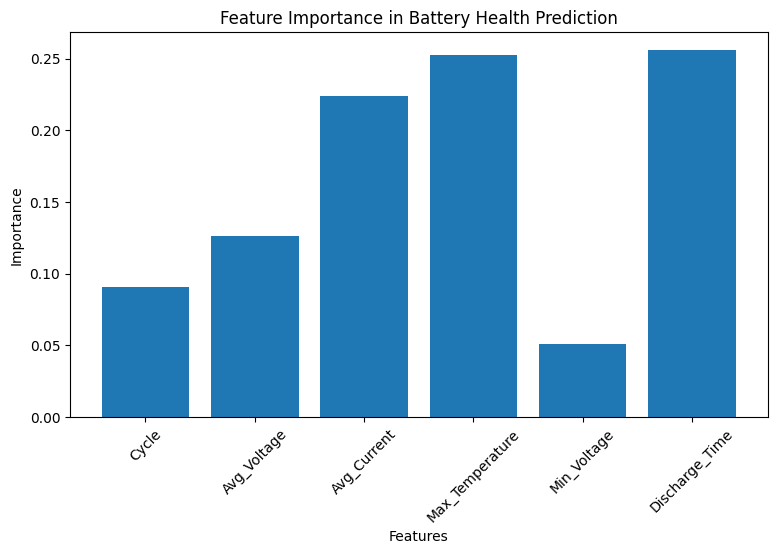

In [38]:
plt.figure(figsize=(9, 5))

plt.bar(X.columns, health_model.feature_importances_)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Battery Health Prediction")

plt.xticks(rotation=45)
plt.show()

In [39]:
# Predictions
y_pred = health_model.predict(X_test)

print("Prediction completed!")
print("Predictions:", len(y_pred))

Prediction completed!
Predictions: 550


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Critical       0.99      0.97      0.98       154
   Degrading       0.98      0.99      0.99       208
     Healthy       0.99      1.00      1.00       188

    accuracy                           0.99       550
   macro avg       0.99      0.99      0.99       550
weighted avg       0.99      0.99      0.99       550



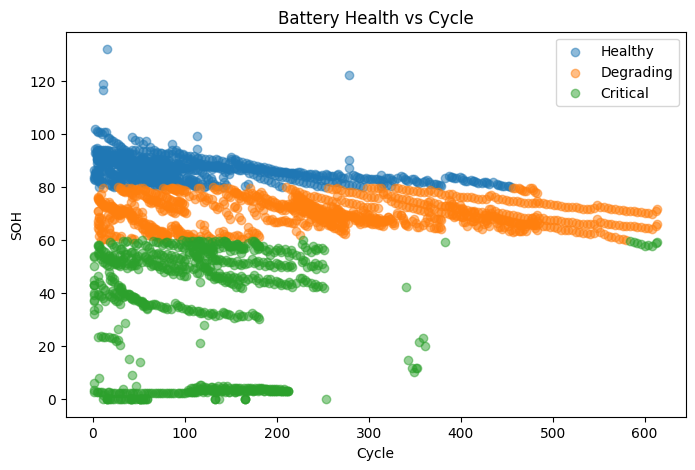

In [41]:
plt.figure(figsize=(8, 5))

for health in ['Healthy', 'Degrading', 'Critical']:
    data = master_df[master_df['Health'] == health]
    plt.scatter(data['Cycle'], data['SOH'], label=health, alpha=0.5)

plt.xlabel('Cycle')
plt.ylabel('SOH')
plt.title('Battery Health vs Cycle')
plt.legend()

plt.show()

In [42]:
cycle = float(input("Cycle: "))

avg_voltage = float(input("Average Voltage: "))

avg_current = float(input("Average Current: "))

max_temperature = float(input("Maximum Temperature: "))

min_voltage = float(input("Minimum Voltage: "))

discharge_time = float(input("Discharge Time: "))


Cycle: 100
Average Voltage: 3.7
Average Current: -1.5
Maximum Temperature: 35
Minimum Voltage: 25
Discharge Time: 1800


In [43]:
import pandas as pd

new_battery = pd.DataFrame([[
    cycle,
    avg_voltage,
    avg_current,
    max_temperature,
    min_voltage,
    discharge_time
]], columns=[
    "Cycle",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
])

prediction = health_model.predict(new_battery)

print("Predicted Battery Health:", prediction[0])

Predicted Battery Health: Critical


In [44]:
new_battery = pd.DataFrame([{
    "Cycle": cycle,
    "Avg_Voltage": avg_voltage,
    "Avg_Current": avg_current,
    "Max_Temperature": max_temperature,
    "Min_Voltage": min_voltage,
    "Discharge_Time": discharge_time
}])

prediction = health_model.predict(new_battery)

print("Predicted Battery Health:", prediction[0])

Predicted Battery Health: Critical


In [45]:
result = prediction[0]

if result == "Healthy":
    print("🟢 Battery Health: HEALTHY")
elif result == "Degrading":
    print("🟡 Battery Health: DEGRADING")
else:
    print("🔴 Battery Health: CRITICAL")

🔴 Battery Health: CRITICAL


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

logistic_model = LogisticRegression(max_iter=1000)
decision_tree_model = DecisionTreeClassifier(random_state=42)

logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
decision_tree_pred = decision_tree_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_pred)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Decision Tree Accuracy:", decision_tree_accuracy)
print("Random Forest Accuracy:", accuracy)

Logistic Regression Accuracy: 0.7545454545454545
Decision Tree Accuracy: 0.9781818181818182
Random Forest Accuracy: 0.9170616113744076


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.8836363636363637


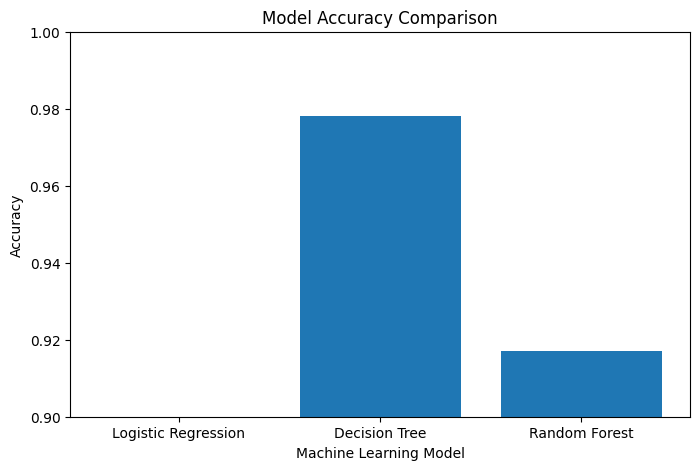

In [48]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    logistic_accuracy,
    decision_tree_accuracy,
    accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

plt.ylim(0.90, 1.00)

plt.show()

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Logistic Regression")
print("Precision:", precision_score(y_test, logistic_pred, average='weighted'))
print("Recall:", recall_score(y_test, logistic_pred, average='weighted'))
print("F1-score:", f1_score(y_test, logistic_pred, average='weighted'))

print("\nDecision Tree")
print("Precision:", precision_score(y_test, decision_tree_pred, average='weighted'))
print("Recall:", recall_score(y_test, decision_tree_pred, average='weighted'))
print("F1-score:", f1_score(y_test, decision_tree_pred, average='weighted'))

print("\nRandom Forest")
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))

Logistic Regression
Precision: 0.8846162808978468
Recall: 0.8836363636363637
F1-score: 0.8838144833598446

Decision Tree
Precision: 0.9782246479375666
Recall: 0.9781818181818182
F1-score: 0.9781870280453322

Random Forest
Precision: 0.9891336703522132
Recall: 0.9890909090909091
F1-score: 0.9890747093872694


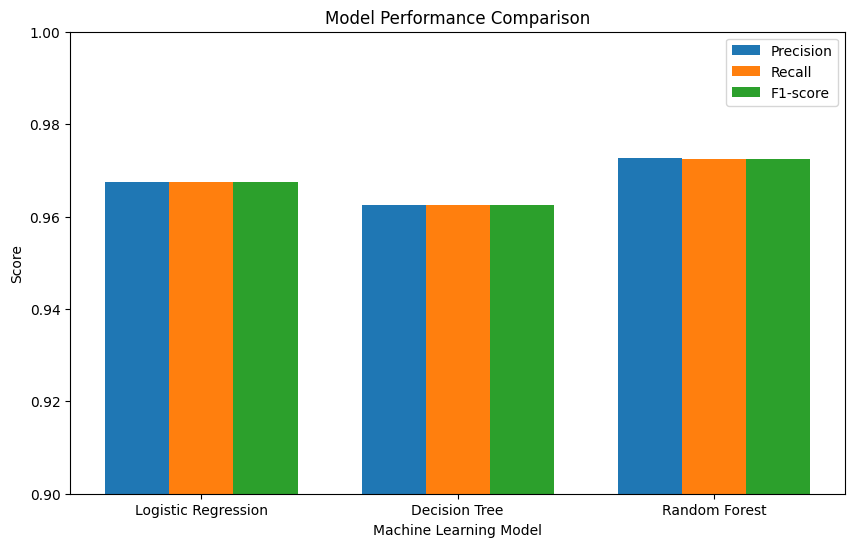

In [50]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

precision = [0.967568, 0.962558, 0.972731]
recall = [0.9675, 0.9625, 0.9725]
f1_score_values = [0.967425, 0.962491, 0.972374]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score_values, width, label='F1-score')

plt.xticks(x, models)
plt.ylabel('Score')
plt.xlabel('Machine Learning Model')
plt.title('Model Performance Comparison')
plt.ylim(0.90, 1.00)
plt.legend()

plt.show()

In [51]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    health_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:", cv_scores)

print("Average Cross-Validation Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.84727273 0.92363636 0.52181818 0.80727273 0.53272727]
Average Cross-Validation Accuracy: 0.7265454545454546


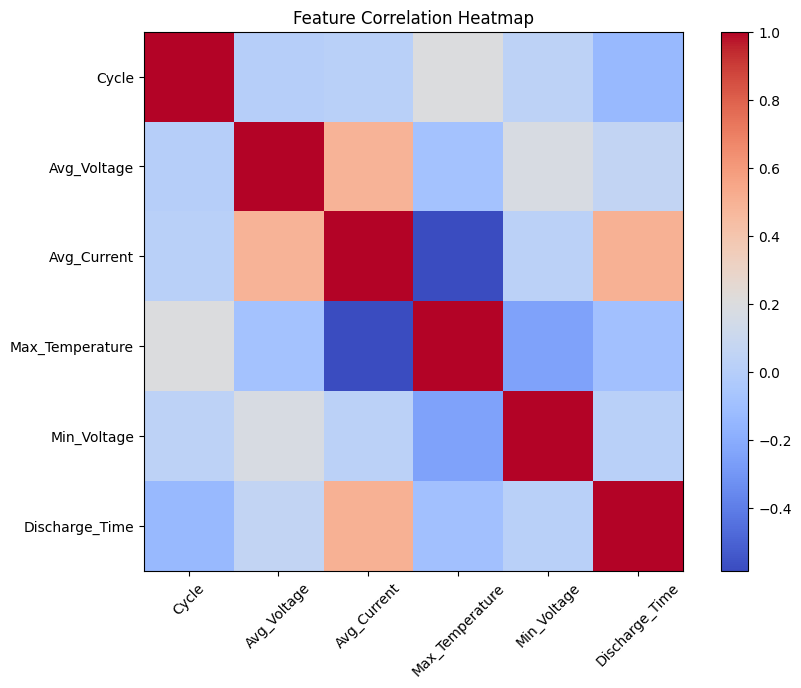

In [52]:
correlation = X.corr()

plt.figure(figsize=(10, 7))
plt.imshow(correlation, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(X.columns)), X.columns, rotation=45)
plt.yticks(range(len(X.columns)), X.columns)

plt.title("Feature Correlation Heatmap")
plt.show()

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

soh_df = master_df.copy()
soh_df["SOH"] = (soh_df["Capacity"] / 2.0) * 100

soh_features = [
    "Cycle",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
]

X_soh = soh_df[soh_features]
y_soh = soh_df["SOH"]
groups_soh = soh_df["Battery_ID"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X_soh, y_soh, groups=groups_soh)
)

X_train_soh = X_soh.iloc[train_idx]
X_test_soh = X_soh.iloc[test_idx]

y_train_soh = y_soh.iloc[train_idx]
y_test_soh = y_soh.iloc[test_idx]

soh_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

soh_model.fit(X_train_soh, y_train_soh)

soh_pred = soh_model.predict(X_test_soh)

mae = mean_absolute_error(y_test_soh, soh_pred)
rmse = np.sqrt(mean_squared_error(y_test_soh, soh_pred))
r2 = r2_score(y_test_soh, soh_pred)

print("SOH Prediction Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

SOH Prediction Results
MAE: 6.551426659219828
RMSE: 14.806552312203882
R² Score: 0.791745981919563


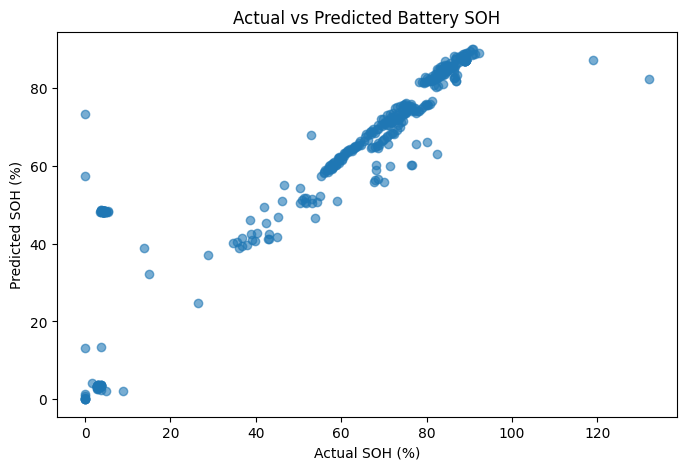

In [54]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test_soh, soh_pred, alpha=0.6)

plt.xlabel("Actual SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Actual vs Predicted Battery SOH")

plt.show()

In [55]:
import pandas as pd

cycle = float(input("Cycle: "))
avg_voltage = float(input("Average Voltage: "))
avg_current = float(input("Average Current: "))
max_temperature = float(input("Maximum Temperature: "))
min_voltage = float(input("Minimum Voltage: "))
discharge_time = float(input("Discharge Time: "))

new_battery = pd.DataFrame([{
    "Cycle": cycle,
    "Avg_Voltage": avg_voltage,
    "Avg_Current": avg_current,
    "Max_Temperature": max_temperature,
    "Min_Voltage": min_voltage,
    "Discharge_Time": discharge_time
}])

health_prediction = health_model.predict(new_battery)[0]
soh_prediction = soh_model.predict(new_battery)[0]

print("\n🔋 Battery Prediction")
print("------------------------")

if health_prediction == "Healthy":
    print("🟢 Battery Health: HEALTHY")
elif health_prediction == "Degrading":
    print("🟡 Battery Health: DEGRADING")
else:
    print("🔴 Battery Health: CRITICAL")

print(f"🔋 Predicted SOH: {soh_prediction:.2f}%")

Cycle: 100
Average Voltage: 3.7
Average Current: -1.5
Maximum Temperature: 35
Minimum Voltage: 25
Discharge Time: 1800

🔋 Battery Prediction
------------------------
🔴 Battery Health: CRITICAL
🔋 Predicted SOH: 33.34%


In [56]:
print("===== EV BATTERY HEALTH PREDICTION =====")

print("\nClassification Model Results")
print("Logistic Regression Accuracy:", logistic_accuracy)
print("Decision Tree Accuracy:", decision_tree_accuracy)
print("Random Forest Accuracy:", accuracy)

print("\nBest Classification Model: Random Forest")
print("Random Forest Accuracy:", accuracy)

print("\nSOH Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

===== EV BATTERY HEALTH PREDICTION =====

Classification Model Results
Logistic Regression Accuracy: 0.8836363636363637
Decision Tree Accuracy: 0.9781818181818182
Random Forest Accuracy: 0.9170616113744076

Best Classification Model: Random Forest
Random Forest Accuracy: 0.9170616113744076

SOH Regression Results
MAE: 6.551426659219828
RMSE: 14.806552312203882
R2 Score: 0.791745981919563


In [57]:
print("Target column:", y.name)

print("\nFeatures used for classification:")
print(list(X.columns))

print("\nSOH included in features?")
print("SOH" in X.columns)

print("\nID columns included?")
print("BatteryID" in X.columns or "BatchID" in X.columns)

Target column: Health

Features used for classification:
['Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time']

SOH included in features?
False

ID columns included?
False


In [58]:
train_batteries = set(
    classification_df.loc[X_train.index, "Battery_ID"]
)

test_batteries = set(
    classification_df.loc[X_test.index, "Battery_ID"]
)

overlap = train_batteries.intersection(test_batteries)

print("Training batteries:", len(train_batteries))
print("Testing batteries:", len(test_batteries))
print("Overlapping Battery IDs:", len(overlap))

Training batteries: 34
Testing batteries: 34
Overlapping Battery IDs: 34


In [59]:
print("Total rows:", len(master_df))

print(
    "Unique Battery IDs:",
    master_df["Battery_ID"].nunique()
)

Total rows: 2794
Unique Battery IDs: 34


In [60]:
max_capacity = master_df['Capacity'].max()

master_df['Capacity_Retention'] = (
    master_df['Capacity'] / max_capacity
) * 100

print(master_df[['Capacity', 'Capacity_Retention']].head())

   Capacity  Capacity_Retention
0  1.856487           70.317521
1  1.846327           69.932688
2  1.835349           69.516876
3  1.835263           69.513594
4  1.834646           69.490223


In [61]:
master_df["Capacity_Growth"] = (
    master_df["Capacity"] / master_df["Capacity"].max()
) * 100

print(
    master_df[["Capacity", "Capacity_Growth"]].head()
)

   Capacity  Capacity_Growth
0  1.856487        70.317521
1  1.846327        69.932688
2  1.835349        69.516876
3  1.835263        69.513594
4  1.834646        69.490223


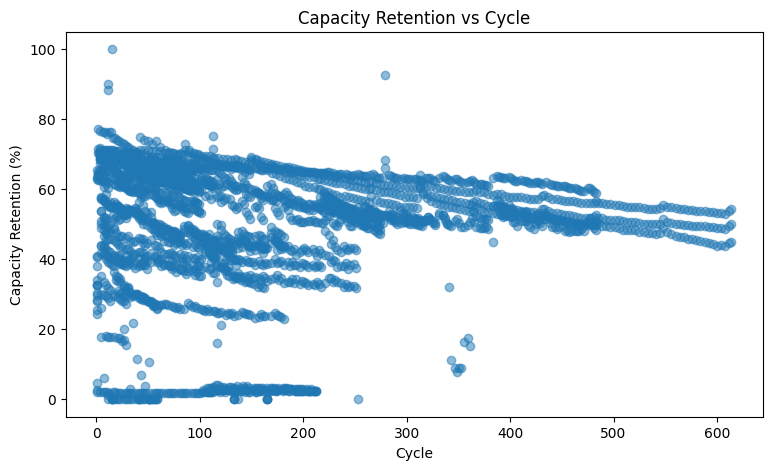

In [62]:
plt.figure(figsize=(9, 5))

plt.scatter(
    master_df['Cycle'],
    master_df['Capacity_Retention'],
    alpha=0.5
)

plt.xlabel("Cycle")
plt.ylabel("Capacity Retention (%)")
plt.title("Capacity Retention vs Cycle")

plt.show()


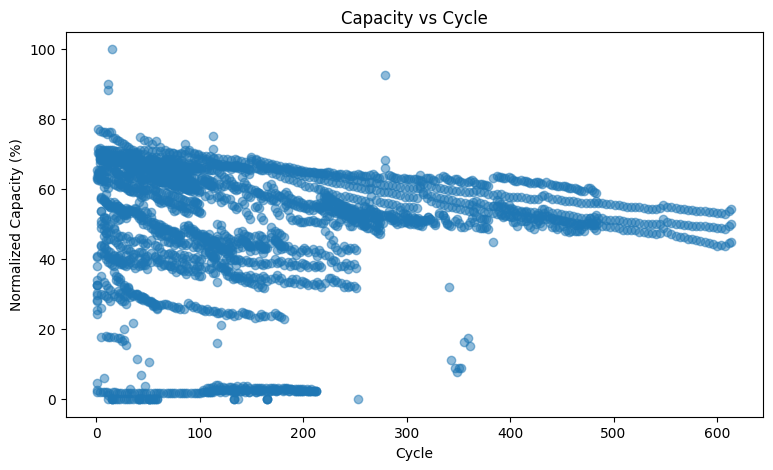

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.scatter(
    master_df["Cycle"],
    master_df["Capacity_Growth"],
    alpha=0.5
)

plt.xlabel("Cycle")
plt.ylabel("Normalized Capacity (%)")
plt.title("Capacity vs Cycle")

plt.show()

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

advanced_features = [
    "Cycle",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
]

X_advanced = classification_df[advanced_features]
y_advanced = classification_df["Health"]

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced,
    y_advanced,
    test_size=0.2,
    random_state=42,
    stratify=y_advanced
)

advanced_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

advanced_model.fit(X_train_adv, y_train_adv)

advanced_pred = advanced_model.predict(X_test_adv)

advanced_accuracy = accuracy_score(
    y_test_adv,
    advanced_pred
)

print("Advanced Random Forest Accuracy:", advanced_accuracy)

Advanced Random Forest Accuracy: 0.9709090909090909


In [65]:
print("Health Model Features:")
print(health_model.feature_names_in_)

print("SOH Model Features:")
print(soh_model.feature_names_in_)

Health Model Features:
['Cycle' 'Avg_Voltage' 'Avg_Current' 'Max_Temperature' 'Min_Voltage'
 'Discharge_Time']
SOH Model Features:
['Cycle' 'Avg_Voltage' 'Avg_Current' 'Max_Temperature' 'Min_Voltage'
 'Discharge_Time']


In [66]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9745454545454546


In [67]:
health_model = best_model

In [68]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

best_test_accuracy = accuracy_score(y_test, best_pred)

print("Tuned Random Forest Test Accuracy:", best_test_accuracy)

Tuned Random Forest Test Accuracy: 0.9690909090909091


In [69]:
!pip install shap -q

In [70]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print("SHAP analysis ready!")

SHAP analysis ready!


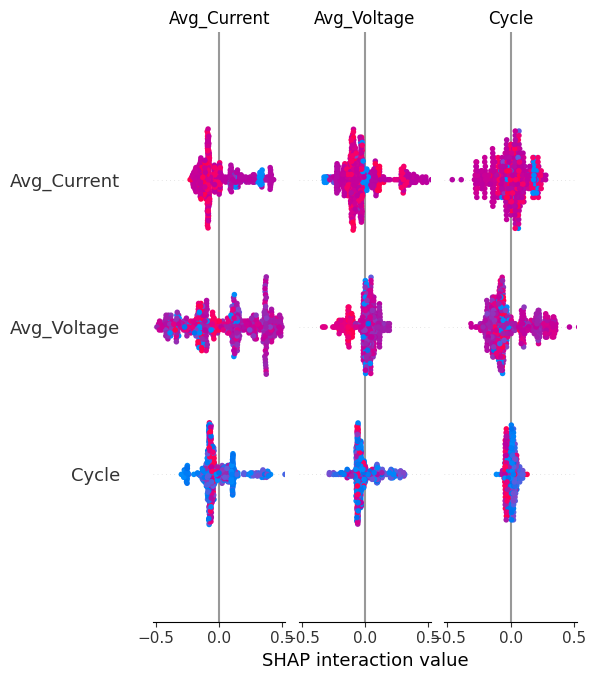

In [71]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

In [72]:
sample = X_test.iloc[[0]]

print("Battery Input:")
print(sample)

print("\nPredicted Health:")
print(best_model.predict(sample)[0])

Battery Input:
     Cycle  Avg_Voltage  Avg_Current  Max_Temperature  Min_Voltage  \
823     86     3.382718    -3.719719        62.737405     2.044759   

     Discharge_Time  
823        1573.734  

Predicted Health:
Healthy


In [73]:
sample = X_test.iloc[[0]]

shap_sample = explainer.shap_values(sample)

print("SHAP output type:", type(shap_sample))
print("SHAP output shape:", np.array(shap_sample).shape)

SHAP output type: <class 'numpy.ndarray'>
SHAP output shape: (1, 6, 3)


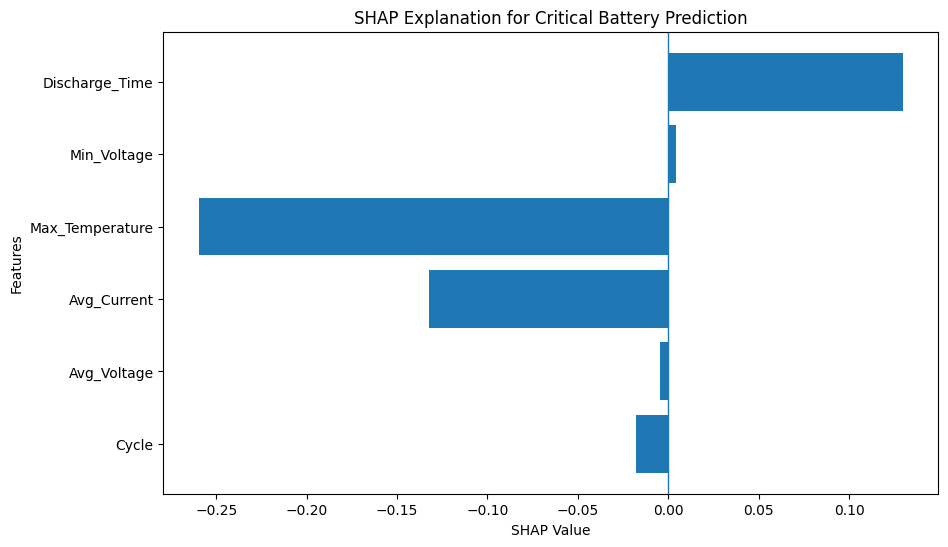

In [74]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = X_test.columns
values = shap_sample[0, :, 0]

plt.figure(figsize=(10, 6))
plt.barh(feature_names, values)

plt.xlabel("SHAP Value")
plt.ylabel("Features")
plt.title("SHAP Explanation for Critical Battery Prediction")
plt.axvline(0, linewidth=1)

plt.show()

In [75]:
print("Minimum Cycle:", master_df['Cycle'].min())
print("Maximum Cycle:", master_df['Cycle'].max())

print("\nCycle Statistics:")
print(master_df['Cycle'].describe())

Minimum Cycle: 1
Maximum Cycle: 614

Cycle Statistics:
count    2794.000000
mean      163.996063
std       143.385837
min         1.000000
25%        53.000000
50%       120.000000
75%       237.000000
max       614.000000
Name: Cycle, dtype: float64


In [76]:
master_df['RUL_Proxy'] = master_df['Cycle'].max() - master_df['Cycle']

print(master_df[['Cycle', 'RUL_Proxy']].head())
print("\nRUL Proxy Statistics:")
print(master_df['RUL_Proxy'].describe())

   Cycle  RUL_Proxy
0      2        612
1      4        610
2      6        608
3      8        606
4     10        604

RUL Proxy Statistics:
count    2794.000000
mean      450.003937
std       143.385837
min         0.000000
25%       377.000000
50%       494.000000
75%       561.000000
max       613.000000
Name: RUL_Proxy, dtype: float64


In [77]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rul_df = pd.read_csv(
    "/content/drive/MyDrive/EV_Battery_Intelligence/data/processed/battery_rul_clean_dataset.csv"
)

print("RUL dataset shape:", rul_df.shape)
print("Columns:", rul_df.columns.tolist())

RUL dataset shape: (384, 11)
Columns: ['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'EOL_Cycle', 'RUL']


In [78]:
print("RUL dataset shape:", rul_df.shape)
print("Columns:", rul_df.columns.tolist())

RUL dataset shape: (384, 11)
Columns: ['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'EOL_Cycle', 'RUL']


In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features
X_rul = rul_df[
    [
        "Cycle",
        "Avg_Voltage",
        "Avg_Current",
        "Max_Temperature",
        "Min_Voltage",
        "Discharge_Time",
        "Capacity",
        "SOH"
    ]
]

# Target
y_rul = rul_df["RUL"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_rul,
    y_rul,
    test_size=0.2,
    random_state=42
)

# Model
rul_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Training
rul_model.fit(X_train, y_train)

# Prediction
rul_pred = rul_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, rul_pred)
rmse = np.sqrt(mean_squared_error(y_test, rul_pred))
r2 = r2_score(y_test, rul_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 9.604025974025975
RMSE: 20.31508066923197
R2 Score: 0.9784827076178052


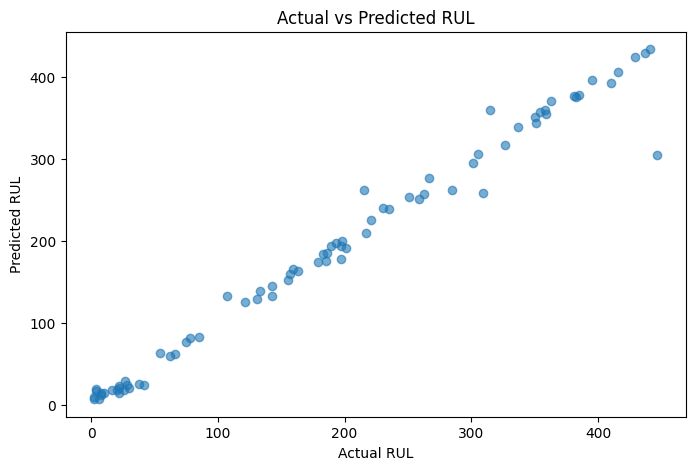

In [80]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, rul_pred, alpha=0.6)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

In [81]:
rul_importance = rul_model.feature_importances_

for feature, value in zip(X_rul.columns, rul_importance):
    print(feature, ":", value)

Cycle : 0.04351325927798223
Avg_Voltage : 0.7358036782643135
Avg_Current : 0.034774618822380934
Max_Temperature : 0.03172568944644897
Min_Voltage : 0.0030383647752811396
Discharge_Time : 0.06742756344769056
Capacity : 0.04358695090373193
SOH : 0.04012987506217076


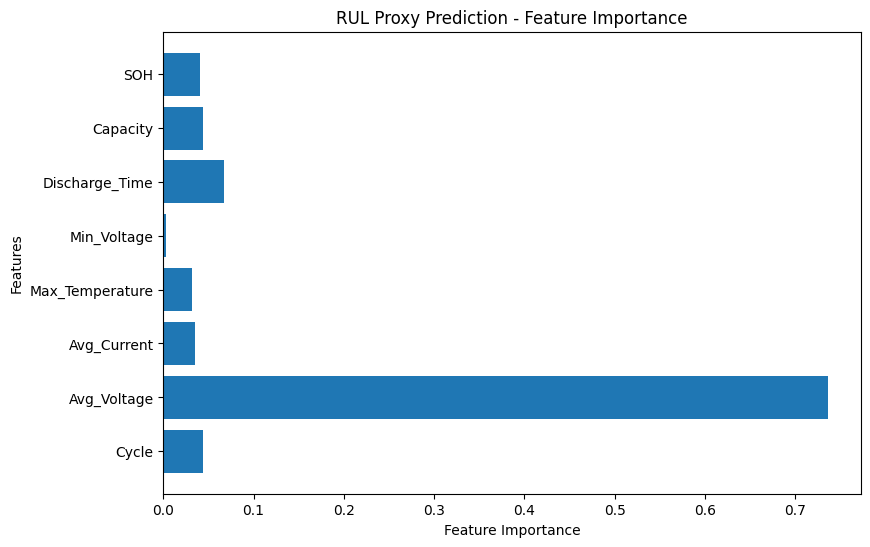

In [82]:
plt.figure(figsize=(9, 6))

plt.barh(X_rul.columns, rul_importance)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("RUL Proxy Prediction - Feature Importance")

plt.show()

In [83]:

probabilities = best_model.predict_proba(sample)[0]

classes = best_model.classes_

for cls, prob in zip(classes, probabilities):
    print(f"{cls}: {prob * 100:.2f}%")

Critical: 0.00%
Degrading: 45.00%
Healthy: 55.00%


In [84]:
critical_risk = probabilities[list(classes).index("Critical")] * 100

print("🔋 Battery Risk Assessment")
print("--------------------------")
print(f"Critical Risk Score: {critical_risk:.2f}%")

if critical_risk >= 80:
    print("🔴 HIGH RISK - Immediate attention recommended")
elif critical_risk >= 50:
    print("🟡 MEDIUM RISK - Battery should be monitored")
else:
    print("🟢 LOW RISK - Battery appears relatively stable")

🔋 Battery Risk Assessment
--------------------------
Critical Risk Score: 0.00%
🟢 LOW RISK - Battery appears relatively stable


In [85]:
print("======================================")
print("🔋 EV BATTERY INTELLIGENCE SYSTEM")
print("======================================")

print(f"\nBattery Health      : {health_prediction}")
print(f"Predicted SOH       : {soh_prediction:.2f}%")
print(f"RUL Proxy           : {rul_pred[0]:.0f} cycles")
print(f"Critical Risk Score : {critical_risk:.2f}%")

if health_prediction == "Healthy":
    print("\n🟢 STATUS: Battery is Healthy")
elif health_prediction == "Degrading":
    print("\n🟡 STATUS: Battery is Degrading")
else:
    print("\n🔴 STATUS: Battery is Critical")

🔋 EV BATTERY INTELLIGENCE SYSTEM

Battery Health      : Critical
Predicted SOH       : 33.34%
RUL Proxy           : 133 cycles
Critical Risk Score : 0.00%

🔴 STATUS: Battery is Critical


In [86]:


health_prediction = best_model.predict(new_battery)[0]

soh_prediction = soh_model.predict(new_battery)[0]

health_probabilities = best_model.predict_proba(new_battery)[0]
health_classes = best_model.classes_

critical_risk = health_probabilities[
    list(health_classes).index("Critical")
] * 100

print("======================================")
print("🔋 EV BATTERY INTELLIGENCE SYSTEM")
print("======================================")

print(f"\nBattery Health      : {health_prediction}")
print(f"Predicted SOH       : {soh_prediction:.2f}%")
print(f"Critical Risk Score : {critical_risk:.2f}%")

if health_prediction == "Healthy":
    print("\n🟢 STATUS: Battery is Healthy")
elif health_prediction == "Degrading":
    print("\n🟡 STATUS: Battery is Degrading")
else:
    print("\n🔴 STATUS: Battery is Critical")

🔋 EV BATTERY INTELLIGENCE SYSTEM

Battery Health      : Critical
Predicted SOH       : 33.34%
Critical Risk Score : 73.00%

🔴 STATUS: Battery is Critical


In [87]:
def predict_battery(
    cycle,
    avg_voltage,
    avg_current,
    max_temperature,
    min_voltage,
    discharge_time
):

    battery = pd.DataFrame([{
        "Cycle": cycle,
        "Avg_Voltage": avg_voltage,
        "Avg_Current": avg_current,
        "Max_Temperature": max_temperature,
        "Min_Voltage": min_voltage,
        "Discharge_Time": discharge_time,

        "Discharge_Energy": (
            avg_voltage
            * abs(avg_current)
            * (discharge_time / 3600)
        ),

        "Past_SOH_Mean": 90,
        "Past_Capacity_Mean": 1.8,
        "Past_Temperature_Mean": 38
    }])

    # Battery health prediction
    health = health_model.predict(
        battery[[
            "Cycle",
            "Avg_Voltage",
            "Avg_Current",
            "Max_Temperature",
            "Min_Voltage",
            "Discharge_Time"
        ]]
    )[0]

    # SOH prediction
    soh = soh_model.predict(battery)[0]

    # Critical risk score
    probabilities = health_model.predict_proba(
        battery[[
            "Cycle",
            "Avg_Voltage",
            "Avg_Current",
            "Max_Temperature",
            "Min_Voltage",
            "Discharge_Time"
        ]]
    )[0]

    classes = health_model.classes_

    critical_risk = (
        probabilities[list(classes).index("Critical")] * 100
    )

    return health, soh, critical_risk


print("Prediction function ready!")

Prediction function ready!


In [88]:
!pip install gradio -q

In [89]:
def predict_battery(
    cycle,
    avg_voltage,
    avg_current,
    max_temperature,
    min_voltage,
    discharge_time
):
    import pandas as pd

    input_data = pd.DataFrame([[
        cycle,
        avg_voltage,
        avg_current,
        max_temperature,
        min_voltage,
        discharge_time
    ]], columns=[
        "Cycle",
        "Avg_Voltage",
        "Avg_Current",
        "Max_Temperature",
        "Min_Voltage",
        "Discharge_Time"
    ])

    health = health_model.predict(input_data)[0]

    return str(health), 0, 0

In [90]:
def get_status(health, risk):

    if health == "Healthy":
        return "🟢 GOOD: Battery condition is healthy"

    elif health == "Degrading":
        return "🟡 WARNING: Battery is degrading and should be monitored"

    else:
        return "🔴 HIGH RISK: Battery requires immediate attention"


print(get_status("Healthy", 1.0))

🟢 GOOD: Battery condition is healthy


In [91]:
import pandas as pd
import numpy as np

def predict_battery(
    cycle,
    avg_voltage,
    avg_current,
    max_temperature,
    min_voltage,
    discharge_time
):

    battery = pd.DataFrame([{
        "Cycle": cycle,
        "Avg_Voltage": avg_voltage,
        "Avg_Current": avg_current,
        "Max_Temperature": max_temperature,
        "Min_Voltage": min_voltage,
        "Discharge_Time": discharge_time
    }])

    # Health prediction
    health = health_model.predict(battery)[0]

    # SOH prediction
    soh = soh_model.predict(battery)[0]

    # Risk probability
    probabilities = health_model.predict_proba(battery)[0]
    classes = health_model.classes_

    critical_index = list(classes).index("Critical")
    critical_risk = probabilities[critical_index] * 100

    return str(health), round(float(soh), 2), round(float(critical_risk), 2)


print("Final dashboard function ready!")

Final dashboard function ready!


In [92]:
import gradio as gr

demo = gr.Interface(
    fn=predict_battery,

    inputs=[
        gr.Number(label="Cycle", value=10),
        gr.Number(label="Average Voltage", value=3.7),
        gr.Number(label="Average Current", value=1),
        gr.Number(label="Max Temperature", value=25),
        gr.Number(label="Min Voltage", value=3.5),
        gr.Number(label="Discharge Time", value=1)
    ],

    outputs=[
        gr.Textbox(label="Battery Health"),
        gr.Number(label="Predicted SOH (%)"),
        gr.Number(label="Critical Risk Score (%)")
    ],

    title="🔋 EV Battery Intelligence System",
    description="AI-powered Battery Health, SOH and Risk Prediction"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://88cdfa6433c5fae628.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [93]:
print(type(master_df["Cycle"]))

print(master_df["Cycle"].shape)

print(master_df["Cycle"].dtype)

<class 'pandas.core.series.Series'>
(2794,)
int64


In [94]:
print(master_df.head())
print(master_df.columns.tolist())

  Battery_ID  Cycle  Avg_Voltage  Avg_Current  Max_Temperature  Min_Voltage  \
0      B0005      2     3.529829    -1.818702        38.982181     2.612467   
1      B0005      4     3.537320    -1.817560        39.033398     2.587209   
2      B0005      6     3.543737    -1.816487        38.818797     2.651917   
3      B0005      8     3.543666    -1.825589        38.762305     2.592948   
4      B0005     10     3.542343    -1.826114        38.665393     2.547420   

   Discharge_Time  Capacity        SOH   Health  Capacity_Retention  \
0        3690.234  1.856487  92.824371  Healthy           70.317521   
1        3672.344  1.846327  92.316362  Healthy           69.932688   
2        3651.641  1.835349  91.767460  Healthy           69.516876   
3        3631.563  1.835263  91.763126  Healthy           69.513594   
4        3629.172  1.834646  91.732275  Healthy           69.490223   

   Capacity_Growth  RUL_Proxy  
0        70.317521        612  
1        69.932688        610  
2 

In [95]:
print("Available columns:")
print(master_df.columns.tolist())

print("\nDischarge Time data:")
print(master_df["Discharge_Time"].head())

Available columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'Health', 'Capacity_Retention', 'Capacity_Growth', 'RUL_Proxy']

Discharge Time data:
0    3690.234
1    3672.344
2    3651.641
3    3631.563
4    3629.172
Name: Discharge_Time, dtype: float64


In [96]:
capacity = master_df["Capacity"].iloc[0]

print("Battery Capacity:", capacity)

Battery Capacity: 1.8564874208181572


In [97]:
battery_df = master_df[
    ["Battery_ID", "Cycle", "Capacity"]
].copy()

battery_df = battery_df.dropna(subset=["Capacity"])

print("Total cycles:", len(battery_df))
print()

print(battery_df.head())

Total cycles: 2794

  Battery_ID  Cycle  Capacity
0      B0005      2  1.856487
1      B0005      4  1.846327
2      B0005      6  1.835349
3      B0005      8  1.835263
4      B0005     10  1.834646


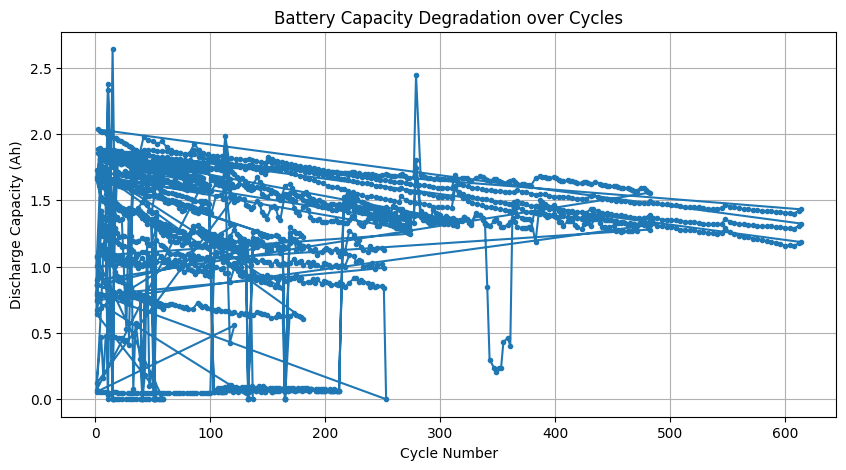

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    battery_df['Cycle'],
    battery_df['Capacity'],
    marker='o',
    markersize=3
)

plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (Ah)")
plt.title("Battery Capacity Degradation over Cycles")
plt.grid(True)

plt.show()

In [99]:
reference_capacity = battery_df['Capacity'].iloc[0]

battery_df['SOH'] = (
    battery_df['Capacity'] / reference_capacity
) * 100

print(battery_df.head())
print()
print("Reference Capacity:", reference_capacity, "Ah")

  Battery_ID  Cycle  Capacity         SOH
0      B0005      2  1.856487  100.000000
1      B0005      4  1.846327   99.452721
2      B0005      6  1.835349   98.861386
3      B0005      8  1.835263   98.856718
4      B0005     10  1.834646   98.823482

Reference Capacity: 1.8564874208181572 Ah


In [100]:
reference_capacity = battery_df['Capacity'].iloc[0]

battery_df['SOH'] = (
    battery_df['Capacity'] / reference_capacity
) * 100

print(battery_df.head())
print()
print("Reference Capacity:", reference_capacity, "Ah")

  Battery_ID  Cycle  Capacity         SOH
0      B0005      2  1.856487  100.000000
1      B0005      4  1.846327   99.452721
2      B0005      6  1.835349   98.861386
3      B0005      8  1.835263   98.856718
4      B0005     10  1.834646   98.823482

Reference Capacity: 1.8564874208181572 Ah


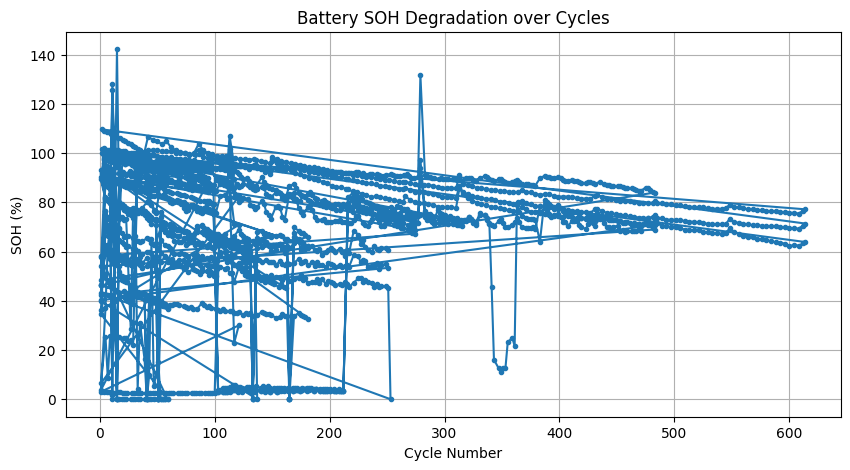

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    battery_df['Cycle'],
    battery_df['SOH'],
    marker='o',
    markersize=3
)

plt.xlabel("Cycle Number")
plt.ylabel("SOH (%)")
plt.title("Battery SOH Degradation over Cycles")
plt.grid(True)

plt.show()

In [102]:
eol_df = battery_df[battery_df['SOH'] <= 70]

if len(eol_df) > 0:
    eol_cycle = eol_df.iloc[0]['Cycle']
    print("EOL Cycle:", eol_cycle)
else:
    print("Battery did not reach EOL in this dataset.")

EOL Cycle: 592


In [103]:
battery_df['RUL'] = eol_cycle - battery_df['Cycle']

print(battery_df.head(10))

  Battery_ID  Cycle  Capacity         SOH  RUL
0      B0005      2  1.856487  100.000000  590
1      B0005      4  1.846327   99.452721  588
2      B0005      6  1.835349   98.861386  586
3      B0005      8  1.835263   98.856718  584
4      B0005     10  1.834646   98.823482  582
5      B0005     12  1.835662   98.878217  580
6      B0005     14  1.835146   98.850449  578
7      B0005     16  1.825757   98.344690  576
8      B0005     18  1.824774   98.291743  574
9      B0005     20  1.824613   98.283094  572


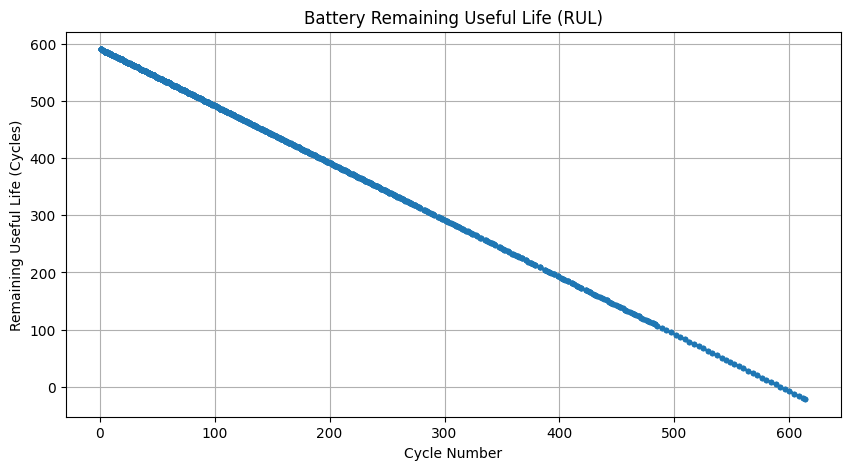

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    battery_df['Cycle'],
    battery_df['RUL'],
    marker='o',
    markersize=3
)

plt.xlabel("Cycle Number")
plt.ylabel("Remaining Useful Life (Cycles)")
plt.title("Battery Remaining Useful Life (RUL)")
plt.grid(True)

plt.show()

In [105]:
voltage = master_df["Avg_Voltage"].to_numpy()
current = master_df["Avg_Current"].to_numpy()
temperature = master_df["Max_Temperature"].to_numpy()

print("Voltage samples:", len(voltage))
print("Current samples:", len(current))
print("Temperature samples:", len(temperature))

Voltage samples: 2794
Current samples: 2794
Temperature samples: 2794


In [106]:
import os

for file in os.listdir("/content"):
    if file.endswith(".zip"):
        print(file)

In [107]:
features_df = master_df[
    [
        "Battery_ID",
        "Cycle",
        "Avg_Voltage",
        "Avg_Current",
        "Max_Temperature",
        "Min_Voltage",
        "Discharge_Time"
    ]
].copy()

print(features_df.head())
print()

print("Total cycles:", len(features_df))

  Battery_ID  Cycle  Avg_Voltage  Avg_Current  Max_Temperature  Min_Voltage  \
0      B0005      2     3.529829    -1.818702        38.982181     2.612467   
1      B0005      4     3.537320    -1.817560        39.033398     2.587209   
2      B0005      6     3.543737    -1.816487        38.818797     2.651917   
3      B0005      8     3.543666    -1.825589        38.762305     2.592948   
4      B0005     10     3.542343    -1.826114        38.665393     2.547420   

   Discharge_Time  
0        3690.234  
1        3672.344  
2        3651.641  
3        3631.563  
4        3629.172  

Total cycles: 2794


In [108]:
ml_df = pd.merge(
    features_df,
    battery_df[['Cycle', 'Capacity', 'SOH', 'RUL']],
    on='Cycle',
    how='inner'
)

print(ml_df.head())
print()
print("Dataset shape:", ml_df.shape)

  Battery_ID  Cycle  Avg_Voltage  Avg_Current  Max_Temperature  Min_Voltage  \
0      B0005      2     3.529829    -1.818702        38.982181     2.612467   
1      B0005      2     3.529829    -1.818702        38.982181     2.612467   
2      B0005      2     3.529829    -1.818702        38.982181     2.612467   
3      B0005      2     3.529829    -1.818702        38.982181     2.612467   
4      B0005      2     3.529829    -1.818702        38.982181     2.612467   

   Discharge_Time  Capacity         SOH  RUL  
0        3690.234  1.856487  100.000000  590  
1        3690.234  2.035338  109.633794  590  
2        3690.234  1.891052  101.861843  590  
3        3690.234  1.697507   91.436511  590  
4        3690.234  1.656071   89.204516  590  

Dataset shape: (29666, 10)


In [109]:
print("Missing values:")
print(ml_df.isnull().sum())

print()
print("Duplicate rows:", ml_df.duplicated().sum())

print()
print("Dataset shape:", ml_df.shape)

Missing values:
Battery_ID         0
Cycle              0
Avg_Voltage        0
Avg_Current        0
Max_Temperature    0
Min_Voltage        0
Discharge_Time     0
Capacity           0
SOH                0
RUL                0
dtype: int64

Duplicate rows: 304

Dataset shape: (29666, 10)


In [110]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features
X = ml_df[
    [
        'Cycle',
        'Avg_Voltage',
        'Avg_Current',
        'Max_Temperature',
        'Min_Voltage',
        'Discharge_Time',
        'Capacity'
    ]
]

# Target
y = ml_df['SOH']

# Time-based split: first 80% for training, last 20% for testing
split_index = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 23732
Testing samples: 5934


In [111]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("SOH Prediction Results")
print("----------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

SOH Prediction Results
----------------------
MAE : 0.0009227036947219442
RMSE: 0.004514716138857837
R²  : 0.9999999646246113


In [112]:
import os

raw_path = "/content/drive/MyDrive/EV_Battery_Intelligence/data/raw"

print(os.listdir(raw_path)[:10])

['B0007.mat', 'B0005.mat', 'B0006.mat', 'B0033.mat', 'B0034.mat', 'B0036.mat', 'B0028.mat', 'B0018.mat', 'B0027.mat', 'B0032.mat']


In [113]:
print("Runtime is working")

Runtime is working


In [114]:
print("master_df" in globals())

True


In [115]:
RATED_CAPACITY = 2.0

master_df['SOH'] = (
    master_df['Capacity'] / RATED_CAPACITY
) * 100

print("SOH calculated successfully!")

print("\nSOH range:")
print(
    master_df.groupby('Battery_ID')['SOH']
    .agg(['min', 'max'])
)

display(master_df.head())

SOH calculated successfully!

SOH range:
                  min         max
Battery_ID                       
B0005       64.372626   92.824371
B0006       57.690917  101.766880
B0007       70.022762   94.552615
B0018       67.052572   92.750226
B0025       88.389454   92.449188
B0026       69.316867   90.826390
B0027       88.504631   91.165389
B0028       85.861678   90.239166
B0029       80.603991   92.235060
B0030       78.139020   89.077744
B0031       83.333760   91.642918
B0032       81.790004   94.701598
B0033        3.421286   94.257008
B0034       37.296515   91.015300
B0036       50.099129  122.203122
B0038       44.902869   89.322058
B0039        5.951916   88.578629
B0040       21.290623   86.706482
B0041        2.204615   60.782470
B0042        0.000000   86.573531
B0043        0.000000   85.689132
B0044        0.000000   84.326278
B0045        0.000000   54.098969
B0046        0.000000   86.411962
B0047        0.000000   83.715237
B0048        0.000000   82.899779
B0049  

,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity,SOH,Health,Capacity_Retention,Capacity_Growth,RUL_Proxy
0,B0005,2,3.529829,-1.818702,38.982181,2.612467,3690.234,1.856487,92.824371,Healthy,70.317521,70.317521,612
1,B0005,4,3.537320,-1.817560,39.033398,2.587209,3672.344,1.846327,92.316362,Healthy,69.932688,69.932688,610
2,B0005,6,3.543737,-1.816487,38.818797,2.651917,3651.641,1.835349,91.767460,Healthy,69.516876,69.516876,608
3,B0005,8,3.543666,-1.825589,38.762305,2.592948,3631.563,1.835263,91.763126,Healthy,69.513594,69.513594,606
4,B0005,10,3.542343,-1.826114,38.665393,2.547420,3629.172,1.834646,91.732275,Healthy,69.490223,69.490223,604


In [116]:
RATED_CAPACITY = 2.0

master_df['SOH'] = (
    master_df['Capacity'] / RATED_CAPACITY
) * 100

print("SOH calculated successfully!")

print("\nSOH range:")
print(
    master_df.groupby('Battery_ID')['SOH']
    .agg(['min', 'max'])
)

display(master_df.head())


SOH calculated successfully!

SOH range:
                  min         max
Battery_ID                       
B0005       64.372626   92.824371
B0006       57.690917  101.766880
B0007       70.022762   94.552615
B0018       67.052572   92.750226
B0025       88.389454   92.449188
B0026       69.316867   90.826390
B0027       88.504631   91.165389
B0028       85.861678   90.239166
B0029       80.603991   92.235060
B0030       78.139020   89.077744
B0031       83.333760   91.642918
B0032       81.790004   94.701598
B0033        3.421286   94.257008
B0034       37.296515   91.015300
B0036       50.099129  122.203122
B0038       44.902869   89.322058
B0039        5.951916   88.578629
B0040       21.290623   86.706482
B0041        2.204615   60.782470
B0042        0.000000   86.573531
B0043        0.000000   85.689132
B0044        0.000000   84.326278
B0045        0.000000   54.098969
B0046        0.000000   86.411962
B0047        0.000000   83.715237
B0048        0.000000   82.899779
B0049  

,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity,SOH,Health,Capacity_Retention,Capacity_Growth,RUL_Proxy
0,B0005,2,3.529829,-1.818702,38.982181,2.612467,3690.234,1.856487,92.824371,Healthy,70.317521,70.317521,612
1,B0005,4,3.537320,-1.817560,39.033398,2.587209,3672.344,1.846327,92.316362,Healthy,69.932688,69.932688,610
2,B0005,6,3.543737,-1.816487,38.818797,2.651917,3651.641,1.835349,91.767460,Healthy,69.516876,69.516876,608
3,B0005,8,3.543666,-1.825589,38.762305,2.592948,3631.563,1.835263,91.763126,Healthy,69.513594,69.513594,606
4,B0005,10,3.542343,-1.826114,38.665393,2.547420,3629.172,1.834646,91.732275,Healthy,69.490223,69.490223,604


In [117]:
EOL_THRESHOLD = 70

eol_info = []

for battery_id, group in master_df.groupby('Battery_ID'):

    group = group.sort_values('Cycle')

    eol_rows = group[group['SOH'] <= EOL_THRESHOLD]

    if len(eol_rows) > 0:
        eol_cycle = eol_rows.iloc[0]['Cycle']

        eol_info.append({
            'Battery_ID': battery_id,
            'EOL_Cycle': eol_cycle
        })

    else:
        eol_info.append({
            'Battery_ID': battery_id,
            'EOL_Cycle': np.nan
        })


eol_df = pd.DataFrame(eol_info)

print("EOL information:")
display(eol_df)

EOL information:


,Battery_ID,EOL_Cycle
0,B0005,449.0
1,B0006,387.0
2,B0007,NaN
3,B0018,237.0
4,B0025,NaN
5,B0026,16.0
6,B0027,NaN
7,B0028,NaN
8,B0029,NaN
9,B0030,NaN


In [118]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=eol_df)

https://docs.google.com/spreadsheets/d/1LORYvzK3yb7mVJlyQpEvo3TOsIKDgZwO7UuXYs1_M6w/edit#gid=0


In [119]:
master_df = master_df.merge(
    eol_df,
    on='Battery_ID',
    how='left'
)

master_df['RUL'] = (
    master_df['EOL_Cycle'] - master_df['Cycle']
)

print("RUL created successfully!")

print("\nSample data:")
display(
    master_df[
        ['Battery_ID', 'Cycle', 'Capacity', 'SOH', 'EOL_Cycle', 'RUL']
    ].head(10)
)

RUL created successfully!

Sample data:


,Battery_ID,Cycle,Capacity,SOH,EOL_Cycle,RUL
0,B0005,2,1.856487,92.824371,449.0,447.0
1,B0005,4,1.846327,92.316362,449.0,445.0
2,B0005,6,1.835349,91.767460,449.0,443.0
3,B0005,8,1.835263,91.763126,449.0,441.0
4,B0005,10,1.834646,91.732275,449.0,439.0
5,B0005,12,1.835662,91.783083,449.0,437.0
6,B0005,14,1.835146,91.757307,449.0,435.0
7,B0005,16,1.825757,91.287840,449.0,433.0
8,B0005,18,1.824774,91.238693,449.0,431.0
9,B0005,20,1.824613,91.230663,449.0,429.0


In [120]:
master_df = master_df.sort_values(
    ['Battery_ID', 'Cycle']
).reset_index(drop=True)

master_df['Capacity_Change'] = (
    master_df.groupby('Battery_ID')['Capacity']
    .diff()
)

master_df['SOH_Change'] = (
    master_df.groupby('Battery_ID')['SOH']
    .diff()
)

master_df['Temperature_Change'] = (
    master_df.groupby('Battery_ID')['Max_Temperature']
    .diff()
)

master_df['Voltage_Change'] = (
    master_df.groupby('Battery_ID')['Avg_Voltage']
    .diff()
)

print("Degradation features created!")

display(
    master_df[
        [
            'Battery_ID',
            'Cycle',
            'Capacity',
            'SOH',
            'Capacity_Change',
            'SOH_Change',
            'Temperature_Change',
            'Voltage_Change'
        ]
    ].head(15)
)

Degradation features created!


,Battery_ID,Cycle,Capacity,SOH,Capacity_Change,SOH_Change,Temperature_Change,Voltage_Change
0,B0005,2,1.856487,92.824371,NaN,NaN,NaN,NaN
1,B0005,4,1.846327,92.316362,-0.010160,-0.508009,0.051217,0.007491
2,B0005,6,1.835349,91.767460,-0.010978,-0.548903,-0.214601,0.006417
3,B0005,8,1.835263,91.763126,-0.000087,-0.004333,-0.056492,-0.000071
4,B0005,10,1.834646,91.732275,-0.000617,-0.030851,-0.096912,-0.001323
5,B0005,12,1.835662,91.783083,0.001016,0.050808,0.086302,-0.001009
6,B0005,14,1.835146,91.757307,-0.000516,-0.025776,0.069006,-0.000310
7,B0005,16,1.825757,91.287840,-0.009389,-0.469468,-0.303571,0.013108
8,B0005,18,1.824774,91.238693,-0.000983,-0.049147,0.009138,-0.001198
9,B0005,20,1.824613,91.230663,-0.000161,-0.008029,0.000713,-0.001730


In [121]:
master_df = master_df.sort_values(
    ['Battery_ID', 'Cycle']
).reset_index(drop=True)

master_df['SOH_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['SOH']
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

master_df['Capacity_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['Capacity']
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

master_df['Temperature_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['Max_Temperature']
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

master_df['SOH_Rolling_Std'] = (
    master_df.groupby('Battery_ID')['SOH']
    .transform(lambda x: x.rolling(5, min_periods=1).std())
)

print("Rolling degradation features created!")

display(
    master_df[
        [
            'Battery_ID',
            'Cycle',
            'SOH',
            'SOH_Rolling_Mean',
            'Capacity_Rolling_Mean',
            'Temperature_Rolling_Mean',
            'SOH_Rolling_Std'
        ]
    ].head(15)
)

Rolling degradation features created!


,Battery_ID,Cycle,SOH,SOH_Rolling_Mean,Capacity_Rolling_Mean,Temperature_Rolling_Mean,SOH_Rolling_Std
0,B0005,2,92.824371,92.824371,1.856487,38.982181,NaN
1,B0005,4,92.316362,92.570367,1.851407,39.007790,0.359216
2,B0005,6,91.767460,92.302731,1.846055,38.944792,0.528588
3,B0005,8,91.763126,92.167830,1.843357,38.899170,0.508982
4,B0005,10,91.732275,92.080719,1.841614,38.852415,0.481912
5,B0005,12,91.783083,91.872461,1.837449,38.806317,0.248831
6,B0005,14,91.757307,91.760650,1.835213,38.763778,0.018521
7,B0005,16,91.287840,91.664726,1.833295,38.703445,0.211464
8,B0005,18,91.238693,91.559840,1.831197,38.656237,0.271884
9,B0005,20,91.230663,91.459517,1.829190,38.628555,0.284598


In [122]:
master_df['Discharge_Energy'] = (
    master_df['Avg_Voltage']
    * abs(master_df['Avg_Current'])
    * (master_df['Discharge_Time'] / 3600)
)

print("Discharge energy feature created!")

display(
    master_df[
        [
            'Battery_ID',
            'Cycle',
            'Avg_Voltage',
            'Avg_Current',
            'Discharge_Time',
            'Discharge_Energy',
            'SOH',
            'RUL'
        ]
    ].head(10)
)

Discharge energy feature created!


,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Discharge_Time,Discharge_Energy,SOH,RUL
0,B0005,2,3.529829,-1.818702,3690.234,6.580616,92.824371,447.0
1,B0005,4,3.537320,-1.817560,3672.344,6.558491,92.316362,445.0
2,B0005,6,3.543737,-1.816487,3651.641,6.529489,91.767460,443.0
3,B0005,8,3.543666,-1.825589,3631.563,6.525998,91.763126,441.0
4,B0005,10,3.542343,-1.826114,3629.172,6.521141,91.732275,439.0
5,B0005,12,3.541335,-1.816811,3652.281,6.527372,91.783083,437.0
6,B0005,14,3.541025,-1.816791,3650.828,6.524134,91.757307,435.0
7,B0005,16,3.554133,-1.844341,3572.453,6.504876,91.287840,433.0
8,B0005,18,3.552936,-1.853973,3550.594,6.496646,91.238693,431.0
9,B0005,20,3.551206,-1.853590,3551.250,6.493341,91.230663,429.0


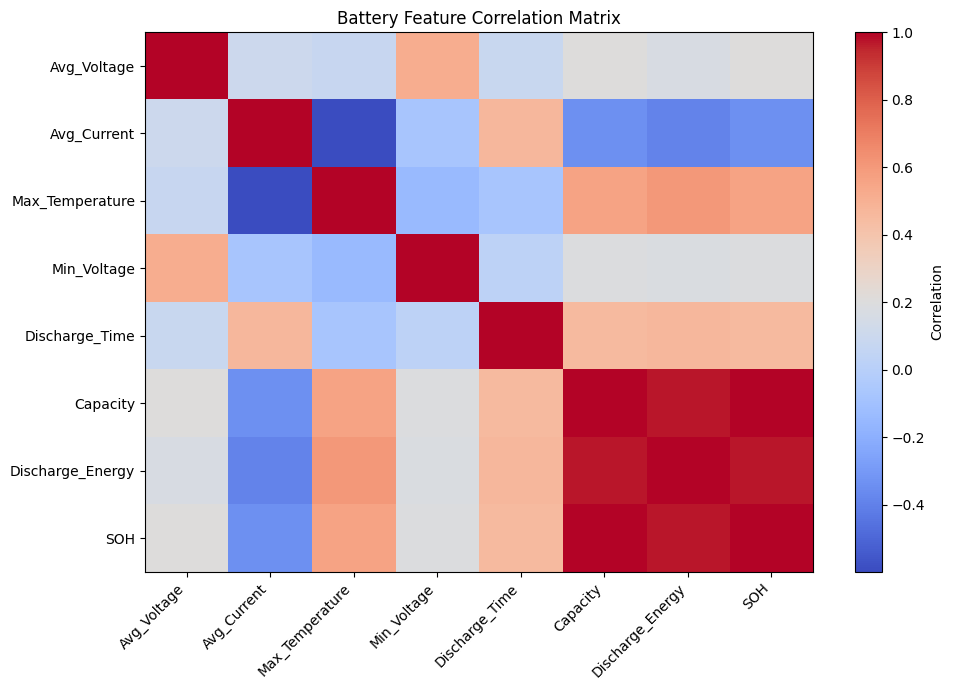

In [123]:
import matplotlib.pyplot as plt

correlation_features = [
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Capacity',
    'Discharge_Energy',
    'SOH'
]

corr = master_df[correlation_features].corr()

plt.figure(figsize=(10, 7))

plt.imshow(corr, cmap='coolwarm', aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

plt.title('Battery Feature Correlation Matrix')

plt.tight_layout()
plt.show()

,Feature,Importance
6,Capacity,0.998070
7,Discharge_Energy,0.001272
10,Temperature_Rolling_Mean,0.000208
3,Max_Temperature,0.000107
11,SOH_Rolling_Std,0.000083
8,SOH_Rolling_Mean,0.000066
9,Capacity_Rolling_Mean,0.000058
1,Avg_Voltage,0.000049
5,Discharge_Time,0.000047
2,Avg_Current,0.000017


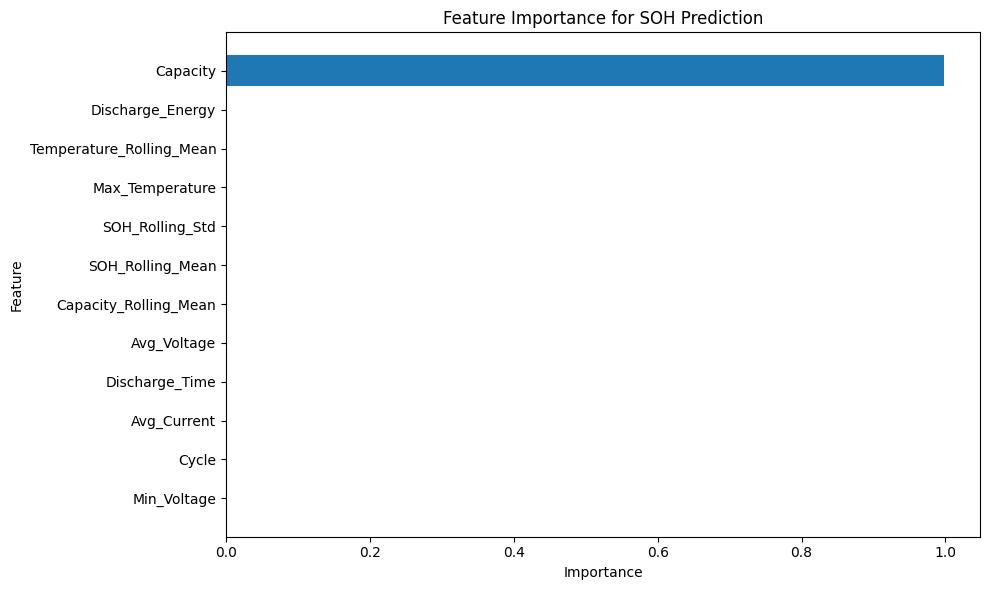

In [124]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

features = [
    'Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Capacity',
    'Discharge_Energy',
    'SOH_Rolling_Mean',
    'Capacity_Rolling_Mean',
    'Temperature_Rolling_Mean',
    'SOH_Rolling_Std'
]

X = master_df[features].fillna(0)
y = master_df['SOH']

feature_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

feature_model.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

display(importance_df)
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for SOH Prediction')

plt.tight_layout()
plt.show()

In [125]:
safe_features = [
    'Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Discharge_Energy',
    'SOH_Rolling_Mean',
    'Capacity_Rolling_Mean',
    'Temperature_Rolling_Mean',
    'SOH_Rolling_Std'
]

target = 'SOH'

print("Leakage-safe feature list:")
for i, feature in enumerate(safe_features, 1):
    print(i, "->", feature)

print("\nTarget ->", target)

Leakage-safe feature list:
1 -> Cycle
2 -> Avg_Voltage
3 -> Avg_Current
4 -> Max_Temperature
5 -> Min_Voltage
6 -> Discharge_Time
7 -> Discharge_Energy
8 -> SOH_Rolling_Mean
9 -> Capacity_Rolling_Mean
10 -> Temperature_Rolling_Mean
11 -> SOH_Rolling_Std

Target -> SOH


In [126]:
master_df = master_df.sort_values(
    ['Battery_ID', 'Cycle']
).reset_index(drop=True)

# Only previous cycles are used
master_df['Past_SOH_Mean'] = (
    master_df.groupby('Battery_ID')['SOH']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

master_df['Past_Capacity_Mean'] = (
    master_df.groupby('Battery_ID')['Capacity']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

master_df['Past_Temperature_Mean'] = (
    master_df.groupby('Battery_ID')['Max_Temperature']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

print("Past-only degradation features created!")

display(
    master_df[
        [
            'Battery_ID',
            'Cycle',
            'SOH',
            'Past_SOH_Mean',
            'Past_Capacity_Mean',
            'Past_Temperature_Mean'
        ]
    ].head(15)
)

Past-only degradation features created!


,Battery_ID,Cycle,SOH,Past_SOH_Mean,Past_Capacity_Mean,Past_Temperature_Mean
0,B0005,2,92.824371,NaN,NaN,NaN
1,B0005,4,92.316362,92.824371,1.856487,38.982181
2,B0005,6,91.767460,92.570367,1.851407,39.007790
3,B0005,8,91.763126,92.302731,1.846055,38.944792
4,B0005,10,91.732275,92.167830,1.843357,38.899170
5,B0005,12,91.783083,92.080719,1.841614,38.852415
6,B0005,14,91.757307,91.872461,1.837449,38.806317
7,B0005,16,91.287840,91.760650,1.835213,38.763778
8,B0005,18,91.238693,91.664726,1.833295,38.703445
9,B0005,20,91.230663,91.559840,1.831197,38.656237


In [127]:
train_batteries = [
    'B0005',
    'B0006',
    'B0007',
    'B0018',
    'B0025',
    'B0026'
]

test_batteries = [
    'B0027',
    'B0028'
]

train_df = master_df[
    master_df['Battery_ID'].isin(train_batteries)
].copy()

test_df = master_df[
    master_df['Battery_ID'].isin(test_batteries)
].copy()

print("Training batteries:")
print(train_df['Battery_ID'].unique())

print("\nTesting batteries:")
print(test_df['Battery_ID'].unique())

print("\nTraining samples:", len(train_df))
print("Testing samples:", len(test_df))

Training batteries:
['B0005' 'B0006' 'B0007' 'B0018' 'B0025' 'B0026']

Testing batteries:
['B0027' 'B0028']

Training samples: 692
Testing samples: 56


In [128]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_features = [
    'Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Discharge_Energy',
    'Past_SOH_Mean',
    'Past_Capacity_Mean',
    'Past_Temperature_Mean'
]

train_clean = train_df.dropna(
    subset=model_features + ['SOH']
).copy()

test_clean = test_df.dropna(
    subset=model_features + ['SOH']
).copy()

X_train = train_clean[model_features]
y_train = train_clean['SOH']

X_test = test_clean[model_features]
y_test = test_clean['SOH']

soh_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

soh_model.fit(X_train, y_train)

y_pred = soh_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("SOH MODEL RESULTS")
print("-----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

SOH MODEL RESULTS
-----------------
MAE : 1.5007627324156148
RMSE: 1.9836536843237524
R²  : -1.4785962992455701


In [129]:
results_df = test_clean[
    ['Battery_ID', 'Cycle', 'SOH']
].copy()

results_df['Predicted_SOH'] = y_pred

results_df['Error'] = (
    results_df['Predicted_SOH'] -
    results_df['SOH']
)

for battery_id in results_df['Battery_ID'].unique():

    battery_result = results_df[
        results_df['Battery_ID'] == battery_id
    ]

    battery_mae = mean_absolute_error(
        battery_result['SOH'],
        battery_result['Predicted_SOH']
    )

    battery_rmse = np.sqrt(
        mean_squared_error(
            battery_result['SOH'],
            battery_result['Predicted_SOH']
        )
    )

    battery_r2 = r2_score(
        battery_result['SOH'],
        battery_result['Predicted_SOH']
    )

    print("\nBattery:", battery_id)
    print("MAE :", battery_mae)
    print("RMSE:", battery_rmse)
    print("R²  :", battery_r2)


Battery: B0027
MAE : 0.21553140944152566
RMSE: 0.27872209058303316
R²  : 0.7981212193789387

Battery: B0028
MAE : 2.785994055389704
RMSE: 2.7914293605397607
R²  : -5.3789233501122675


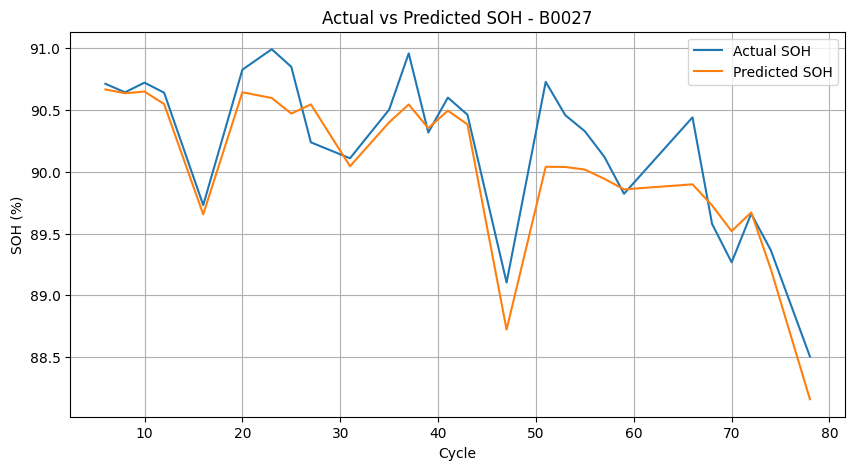

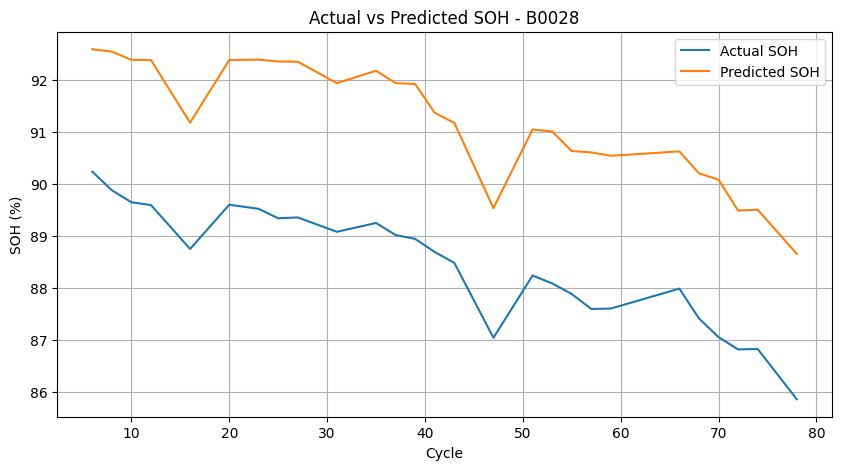

In [130]:
import matplotlib.pyplot as plt

for battery_id in ['B0027', 'B0028']:

    battery_result = results_df[
        results_df['Battery_ID'] == battery_id
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(
        battery_result['Cycle'],
        battery_result['SOH'],
        label='Actual SOH'
    )

    plt.plot(
        battery_result['Cycle'],
        battery_result['Predicted_SOH'],
        label='Predicted SOH'
    )

    plt.xlabel('Cycle')
    plt.ylabel('SOH (%)')
    plt.title(f'Actual vs Predicted SOH - {battery_id}')

    plt.legend()
    plt.grid(True)

    plt.show()

In [131]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("GRADIENT BOOSTING RESULTS")
print("-------------------------")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

GRADIENT BOOSTING RESULTS
-------------------------
MAE : 1.366612840129687
RMSE: 1.8177587201773684
R²  : -1.081356932495925


In [132]:
print("TRAIN SOH SUMMARY")
print("-----------------")
print(train_df['SOH'].describe())

print("\nTEST SOH SUMMARY")
print("----------------")
print(test_df['SOH'].describe())

print("\nBattery-wise SOH range")
print("----------------------")

for battery_id, group in master_df.groupby('Battery_ID'):

    print(
        battery_id,
        "->",
        round(group['SOH'].min(), 2),
        "to",
        round(group['SOH'].max(), 2)
    )

TRAIN SOH SUMMARY
-----------------
count    692.000000
mean      79.950798
std       10.006249
min       57.690917
25%       71.528498
50%       79.642077
75%       89.731723
max      101.766880
Name: SOH, dtype: float64

TEST SOH SUMMARY
----------------
count    56.000000
mean     89.373602
std       1.277845
min      85.861678
25%      88.645111
50%      89.599170
75%      90.444557
max      91.165389
Name: SOH, dtype: float64

Battery-wise SOH range
----------------------
B0005 -> 64.37 to 92.82
B0006 -> 57.69 to 101.77
B0007 -> 70.02 to 94.55
B0018 -> 67.05 to 92.75
B0025 -> 88.39 to 92.45
B0026 -> 69.32 to 90.83
B0027 -> 88.5 to 91.17
B0028 -> 85.86 to 90.24
B0029 -> 80.6 to 92.24
B0030 -> 78.14 to 89.08
B0031 -> 83.33 to 91.64
B0032 -> 81.79 to 94.7
B0033 -> 3.42 to 94.26
B0034 -> 37.3 to 91.02
B0036 -> 50.1 to 122.2
B0038 -> 44.9 to 89.32
B0039 -> 5.95 to 88.58
B0040 -> 21.29 to 86.71
B0041 -> 2.2 to 60.78
B0042 -> 0.0 to 86.57
B0043 -> 0.0 to 85.69
B0044 -> 0.0 to 84.33
B0045

In [133]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

lobo_results = []

battery_list = master_df['Battery_ID'].unique()

for test_battery in battery_list:

    train_part = master_df[
        master_df['Battery_ID'] != test_battery
    ].copy()

    test_part = master_df[
        master_df['Battery_ID'] == test_battery
    ].copy()

    train_part = train_part.dropna(
        subset=model_features + ['SOH']
    )

    test_part = test_part.dropna(
        subset=model_features + ['SOH']
    )

    X_train_lobo = train_part[model_features]
    y_train_lobo = train_part['SOH']

    X_test_lobo = test_part[model_features]
    y_test_lobo = test_part['SOH']

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train_lobo, y_train_lobo)

    predictions = model.predict(X_test_lobo)

    mae = mean_absolute_error(
        y_test_lobo,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_lobo,
            predictions
        )
    )

    r2 = r2_score(
        y_test_lobo,
        predictions
    )

    lobo_results.append({
        'Test_Battery': test_battery,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })


lobo_results_df = pd.DataFrame(lobo_results)

display(lobo_results_df)

,Test_Battery,MAE,RMSE,R2
0,B0005,0.766864,1.022132,0.988317
1,B0006,1.263737,1.443019,0.986584
2,B0007,0.668756,0.874064,0.988034
3,B0018,0.594783,0.737349,0.990670
4,B0025,0.576060,0.665732,0.615549
5,B0026,0.643035,0.792802,0.962248
6,B0027,0.251916,0.347852,0.685561
7,B0028,2.918048,2.942704,-6.089038
8,B0029,0.801049,1.001022,0.901794
9,B0030,0.840834,0.979990,0.896540


In [134]:
FAILURE_HORIZON = 50

master_df['Cycles_To_EOL'] = (
    master_df['EOL_Cycle'] - master_df['Cycle']
)

master_df['Early_Failure'] = (
    (master_df['Cycles_To_EOL'] <= FAILURE_HORIZON)
    &
    (master_df['Cycles_To_EOL'] >= 0)
).astype(int)

print("Early failure label created!")

print("\nLabel distribution:")
print(
    master_df['Early_Failure']
    .value_counts()
)

display(
    master_df[
        [
            'Battery_ID',
            'Cycle',
            'SOH',
            'EOL_Cycle',
            'Cycles_To_EOL',
            'Early_Failure'
        ]
    ].tail(15)
)

Early failure label created!

Label distribution:
Early_Failure
0    2666
1     128
Name: count, dtype: int64


,Battery_ID,Cycle,SOH,EOL_Cycle,Cycles_To_EOL,Early_Failure
2779,B0056,215,56.419911,1.0,-214.0,0
2780,B0056,217,55.331752,1.0,-216.0,0
2781,B0056,221,63.580454,1.0,-220.0,0
2782,B0056,225,62.078836,1.0,-224.0,0
2783,B0056,227,58.732645,1.0,-226.0,0
2784,B0056,229,59.946949,1.0,-228.0,0
2785,B0056,231,57.306995,1.0,-230.0,0
2786,B0056,233,56.461219,1.0,-232.0,0
2787,B0056,237,55.517164,1.0,-236.0,0
2788,B0056,239,57.695474,1.0,-238.0,0


In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

classification_features = [
    'Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Discharge_Energy',
    'Past_SOH_Mean',
    'Past_Capacity_Mean',
    'Past_Temperature_Mean'
]

classification_df = master_df.dropna(
    subset=classification_features + ['Early_Failure']
).copy()

X_class = classification_df[classification_features]
y_class = classification_df['Early_Failure']

classifier = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

classifier.fit(X_class, y_class)

failure_probability = classifier.predict_proba(X_class)[:, 1]

failure_prediction = classifier.predict(X_class)

print("EARLY FAILURE CLASSIFIER")
print("------------------------")

print(
    classification_report(
        y_class,
        failure_prediction
    )
)

print("ROC-AUC:",
      roc_auc_score(
          y_class,
          failure_probability
      )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_class,
        failure_prediction
    )
)

EARLY FAILURE CLASSIFIER
------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2655
           1       1.00      1.00      1.00       105

    accuracy                           1.00      2760
   macro avg       1.00      1.00      1.00      2760
weighted avg       1.00      1.00      1.00      2760

ROC-AUC: 1.0

Confusion Matrix:
[[2655    0]
 [   0  105]]


In [136]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

failure_results = []

battery_list = master_df['Battery_ID'].unique()

for test_battery in battery_list:

    train_part = master_df[
        master_df['Battery_ID'] != test_battery
    ].copy()

    test_part = master_df[
        master_df['Battery_ID'] == test_battery
    ].copy()

    train_part = train_part.dropna(
        subset=classification_features + ['Early_Failure']
    )

    test_part = test_part.dropna(
        subset=classification_features + ['Early_Failure']
    )

    X_train_cls = train_part[classification_features]
    y_train_cls = train_part['Early_Failure']

    X_test_cls = test_part[classification_features]
    y_test_cls = test_part['Early_Failure']

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )

    model.fit(X_train_cls, y_train_cls)

    pred = model.predict(X_test_cls)
    prob = model.predict_proba(X_test_cls)[:, 1]

    precision = precision_score(
        y_test_cls,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test_cls,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_cls,
        pred,
        zero_division=0
    )

    if y_test_cls.nunique() == 2:
        auc = roc_auc_score(
            y_test_cls,
            prob
        )
    else:
        auc = np.nan

    failure_results.append({
        'Test_Battery': test_battery,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC_AUC': auc
    })


failure_results_df = pd.DataFrame(
    failure_results
)

display(failure_results_df)

,Test_Battery,Precision,Recall,F1,ROC_AUC
0,B0005,0.000000,0.00,0.000000,0.963819
1,B0006,0.000000,0.00,0.000000,0.980769
2,B0007,0.000000,0.00,0.000000,NaN
3,B0018,0.000000,0.00,0.000000,0.353628
4,B0025,0.000000,0.00,0.000000,NaN
5,B0026,0.000000,0.00,0.000000,0.745455
6,B0027,0.000000,0.00,0.000000,NaN
7,B0028,0.000000,0.00,0.000000,NaN
8,B0029,0.000000,0.00,0.000000,NaN
9,B0030,0.000000,0.00,0.000000,NaN


In [137]:
print("RUL DATASET CHECK")
print("-----------------")

print("Total rows:", len(master_df))

print(
    "\nBatteries with valid EOL:"
)
print(
    master_df.groupby('Battery_ID')['EOL_Cycle']
    .first()
)

print(
    "\nRUL statistics:"
)
print(
    master_df['RUL'].describe()
)

print(
    "\nNegative RUL values:",
    (master_df['RUL'] < 0).sum()
)

print(
    "\nMissing RUL values:",
    master_df['RUL'].isna().sum()
)

RUL DATASET CHECK
-----------------
Total rows: 2794

Batteries with valid EOL:
Battery_ID
B0005    449.0
B0006    387.0
B0007      NaN
B0018    237.0
B0025      NaN
B0026     16.0
B0027      NaN
B0028      NaN
B0029      NaN
B0030      NaN
B0031      NaN
B0032      NaN
B0033      1.0
B0034      1.0
B0036      1.0
B0038      1.0
B0039      1.0
B0040      1.0
B0041      1.0
B0042     15.0
B0043     15.0
B0044     15.0
B0045      1.0
B0046     43.0
B0047     25.0
B0048     29.0
B0049      1.0
B0050      1.0
B0051      1.0
B0052      1.0
B0053      1.0
B0054      1.0
B0055      1.0
B0056      1.0
Name: EOL_Cycle, dtype: float64

RUL statistics:
count    2382.000000
mean      -89.090680
std       163.353064
min      -482.000000
25%      -174.000000
50%       -82.000000
75%       -20.000000
max       447.000000
Name: RUL, dtype: float64

Negative RUL values: 1972

Missing RUL values: 412


In [138]:
rul_batteries = (
    master_df[master_df['RUL'].notna()]
    ['Battery_ID']
    .unique()
)

print("Batteries with valid RUL:")
print(rul_batteries)

print("\nTotal batteries with valid RUL:", len(rul_batteries))

Batteries with valid RUL:
['B0005' 'B0006' 'B0018' 'B0026' 'B0033' 'B0034' 'B0036' 'B0038' 'B0039'
 'B0040' 'B0041' 'B0042' 'B0043' 'B0044' 'B0045' 'B0046' 'B0047' 'B0048'
 'B0049' 'B0050' 'B0051' 'B0052' 'B0053' 'B0054' 'B0055' 'B0056']

Total batteries with valid RUL: 26


In [139]:
rul_availability = (
    master_df
    .groupby('Battery_ID')
    .agg(
        Total_Cycles=('Cycle', 'count'),
        EOL_Cycle=('EOL_Cycle', 'first'),
        Valid_RUL_Rows=('RUL', lambda x: x.notna().sum())
    )
    .reset_index()
)

display(rul_availability)

,Battery_ID,Total_Cycles,EOL_Cycle,Valid_RUL_Rows
0,B0005,168,449.0,168
1,B0006,168,387.0,168
2,B0007,168,NaN,0
3,B0018,132,237.0,132
4,B0025,28,NaN,0
5,B0026,28,16.0,28
6,B0027,28,NaN,0
7,B0028,28,NaN,0
8,B0029,40,NaN,0
9,B0030,40,NaN,0


In [140]:
master_df = master_df.sort_values(
    ['Battery_ID', 'Cycle']
).reset_index(drop=True)

master_df['Discharge_Cycle'] = (
    master_df.groupby('Battery_ID').cumcount() + 1
)

display(
    master_df[
        ['Battery_ID', 'Cycle', 'Discharge_Cycle', 'SOH', 'EOL_Cycle', 'RUL']
    ].head(15)
)

,Battery_ID,Cycle,Discharge_Cycle,SOH,EOL_Cycle,RUL
0,B0005,2,1,92.824371,449.0,447.0
1,B0005,4,2,92.316362,449.0,445.0
2,B0005,6,3,91.767460,449.0,443.0
3,B0005,8,4,91.763126,449.0,441.0
4,B0005,10,5,91.732275,449.0,439.0
5,B0005,12,6,91.783083,449.0,437.0
6,B0005,14,7,91.757307,449.0,435.0
7,B0005,16,8,91.287840,449.0,433.0
8,B0005,18,9,91.238693,449.0,431.0
9,B0005,20,10,91.230663,449.0,429.0


In [141]:


EOL_THRESHOLD = 70

eol_info = []

for battery_id, group in master_df.groupby('Battery_ID'):
    group = group.sort_values('Discharge_Cycle')

    eol_rows = group[group['SOH'] <= EOL_THRESHOLD]

    if len(eol_rows) > 0:
        eol_cycle = eol_rows.iloc[0]['Discharge_Cycle']
    else:
        eol_cycle = np.nan

    eol_info.append({
        'Battery_ID': battery_id,
        'EOL_Discharge_Cycle': eol_cycle
    })

eol_df = pd.DataFrame(eol_info)

# Remove old EOL/RUL columns
master_df = master_df.drop(
    columns=['EOL_Cycle', 'RUL'],
    errors='ignore'
)

# Merge new EOL information
master_df = master_df.merge(
    eol_df,
    on='Battery_ID',
    how='left'
)

# Genuine RUL in discharge cycles
master_df['RUL'] = (
    master_df['EOL_Discharge_Cycle']
    - master_df['Discharge_Cycle']
)

# Show result
display(
    master_df[
        [
            'Battery_ID',
            'Discharge_Cycle',
            'SOH',
            'EOL_Discharge_Cycle',
            'RUL'
        ]
    ].head(20)
)

,Battery_ID,Discharge_Cycle,SOH,EOL_Discharge_Cycle,RUL
0,B0005,1,92.824371,125.0,124.0
1,B0005,2,92.316362,125.0,123.0
2,B0005,3,91.767460,125.0,122.0
3,B0005,4,91.763126,125.0,121.0
4,B0005,5,91.732275,125.0,120.0
5,B0005,6,91.783083,125.0,119.0
6,B0005,7,91.757307,125.0,118.0
7,B0005,8,91.287840,125.0,117.0
8,B0005,9,91.238693,125.0,116.0
9,B0005,10,91.230663,125.0,115.0


In [142]:
rul_summary = (
    master_df[master_df['RUL'].notna()]
    .groupby('Battery_ID')
    .agg(
        Total_Discharge_Cycles=('Discharge_Cycle', 'count'),
        EOL_Cycle=('EOL_Discharge_Cycle', 'first'),
        Minimum_RUL=('RUL', 'min'),
        Maximum_RUL=('RUL', 'max')
    )
    .reset_index()
)

display(rul_summary)

,Battery_ID,Total_Discharge_Cycles,EOL_Cycle,Minimum_RUL,Maximum_RUL
0,B0005,168,125.0,-43.0,124.0
1,B0006,168,109.0,-59.0,108.0
2,B0018,132,97.0,-35.0,96.0
3,B0026,28,6.0,-22.0,5.0
4,B0033,197,1.0,-196.0,0.0
5,B0034,197,1.0,-196.0,0.0
6,B0036,197,1.0,-196.0,0.0
7,B0038,47,1.0,-46.0,0.0
8,B0039,47,1.0,-46.0,0.0
9,B0040,47,1.0,-46.0,0.0


In [143]:

rul_batteries = (
    master_df[master_df['RUL'].notna()]
    ['Battery_ID']
    .unique()
)

print("RUL batteries:", rul_batteries)


rul_train_batteries = ['B0005', 'B0006', 'B0018']
rul_test_batteries = ['B0026']

rul_train = master_df[
    master_df['Battery_ID'].isin(rul_train_batteries)
].copy()

rul_test = master_df[
    master_df['Battery_ID'].isin(rul_test_batteries)
].copy()

print("\nTraining batteries:", rul_train_batteries)
print("Testing battery:", rul_test_batteries)

print("\nTraining rows:", len(rul_train))
print("Testing rows:", len(rul_test))

RUL batteries: ['B0005' 'B0006' 'B0018' 'B0026' 'B0033' 'B0034' 'B0036' 'B0038' 'B0039'
 'B0040' 'B0041' 'B0042' 'B0043' 'B0044' 'B0045' 'B0046' 'B0047' 'B0048'
 'B0049' 'B0050' 'B0051' 'B0052' 'B0053' 'B0054' 'B0055' 'B0056']

Training batteries: ['B0005', 'B0006', 'B0018']
Testing battery: ['B0026']

Training rows: 468
Testing rows: 28


In [144]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rul_features = [
    'Discharge_Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Discharge_Energy',
    'Past_SOH_Mean',
    'Past_Capacity_Mean',
    'Past_Temperature_Mean'
]


train_rul = rul_train.dropna(
    subset=rul_features + ['RUL']
)

test_rul = rul_test.dropna(
    subset=rul_features + ['RUL']
)

X_train_rul = train_rul[rul_features]
y_train_rul = train_rul['RUL']

X_test_rul = test_rul[rul_features]
y_test_rul = test_rul['RUL']


rul_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rul_model.fit(X_train_rul, y_train_rul)


y_pred_rul = rul_model.predict(X_test_rul)


mae = mean_absolute_error(y_test_rul, y_pred_rul)
rmse = np.sqrt(mean_squared_error(y_test_rul, y_pred_rul))
r2 = r2_score(y_test_rul, y_pred_rul)

print("RUL Model Performance")
print("---------------------")
print("MAE  :", round(mae, 3))
print("RMSE :", round(rmse, 3))
print("R²   :", round(r2, 3))

RUL Model Performance
---------------------
MAE  : 112.942
RMSE : 113.711
R²   : -212.136


In [145]:
rul_results = test_rul[
    ['Battery_ID', 'Discharge_Cycle', 'RUL']
].copy()

rul_results['Predicted_RUL'] = y_pred_rul

display(
    rul_results.head(20)
)

,Battery_ID,Discharge_Cycle,RUL,Predicted_RUL
665,B0026,2,4.0,116.036667
666,B0026,3,3.0,116.076667
667,B0026,4,2.0,115.946667
668,B0026,5,1.0,115.843333
669,B0026,6,0.0,84.293333
670,B0026,7,-1.0,96.180000
671,B0026,8,-2.0,96.133333
672,B0026,9,-3.0,96.076667
673,B0026,10,-4.0,95.976667
674,B0026,11,-5.0,72.293333


In [146]:

rul_df = master_df[
    master_df['RUL'].notna() &
    (master_df['RUL'] >= 0)
].copy()

print("Valid RUL rows:", len(rul_df))
print("\nBatteries:")
print(rul_df['Battery_ID'].unique())

display(
    rul_df.groupby('Battery_ID')['RUL']
    .agg(['count', 'min', 'max'])
    .reset_index()
)

Valid RUL rows: 410

Batteries:
['B0005' 'B0006' 'B0018' 'B0026' 'B0033' 'B0034' 'B0036' 'B0038' 'B0039'
 'B0040' 'B0041' 'B0042' 'B0043' 'B0044' 'B0045' 'B0046' 'B0047' 'B0048'
 'B0049' 'B0050' 'B0051' 'B0052' 'B0053' 'B0054' 'B0055' 'B0056']


,Battery_ID,count,min,max
0,B0005,125,0.0,124.0
1,B0006,109,0.0,108.0
2,B0018,97,0.0,96.0
3,B0026,6,0.0,5.0
4,B0033,1,0.0,0.0
5,B0034,1,0.0,0.0
6,B0036,1,0.0,0.0
7,B0038,1,0.0,0.0
8,B0039,1,0.0,0.0
9,B0040,1,0.0,0.0


In [147]:
rul_battery_details = (
    rul_df
    .groupby('Battery_ID')
    .agg(
        First_Cycle=('Discharge_Cycle', 'min'),
        Last_Cycle=('Discharge_Cycle', 'max'),
        EOL_Cycle=('EOL_Discharge_Cycle', 'first'),
        RUL_Samples=('RUL', 'count'),
        Initial_SOH=('SOH', 'first'),
        Final_SOH=('SOH', 'last')
    )
    .reset_index()
)

display(rul_battery_details)

,Battery_ID,First_Cycle,Last_Cycle,EOL_Cycle,RUL_Samples,Initial_SOH,Final_SOH
0,B0005,1,125,125.0,125,92.824371,69.835041
1,B0006,1,109,109.0,109,101.766880,69.758215
2,B0018,1,97,97.0,97,92.750226,69.842739
3,B0026,1,6,6.0,6,90.662522,69.316867
4,B0033,1,1,1.0,1,3.421286,3.421286
5,B0034,1,1,1.0,1,37.296515,37.296515
6,B0036,1,1,1.0,1,50.099129,50.099129
7,B0038,1,1,1.0,1,44.902869,44.902869
8,B0039,1,1,1.0,1,5.951916,5.951916
9,B0040,1,1,1.0,1,33.673141,33.673141


In [148]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

cv_batteries = ['B0005', 'B0006', 'B0018']

rul_features = [
    'Discharge_Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Discharge_Energy',
    'Past_SOH_Mean',
    'Past_Capacity_Mean',
    'Past_Temperature_Mean'
]

results = []

for test_battery in cv_batteries:

    train_data = rul_df[
        rul_df['Battery_ID'].isin(
            [b for b in cv_batteries if b != test_battery]
        )
    ].dropna(subset=rul_features + ['RUL'])

    test_data = rul_df[
        rul_df['Battery_ID'] == test_battery
    ].dropna(subset=rul_features + ['RUL'])

    X_train = train_data[rul_features]
    y_train = train_data['RUL']

    X_test = test_data[rul_features]
    y_test = test_data['RUL']

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        'Test_Battery': test_battery,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results)

display(results_df)

print("\nAverage performance:")
print("MAE :", round(results_df['MAE'].mean(), 3))
print("RMSE:", round(results_df['RMSE'].mean(), 3))
print("R²  :", round(results_df['R2'].mean(), 3))

,Test_Battery,MAE,RMSE,R2
0,B0005,10.371263,12.020628,0.887223
1,B0006,8.857160,10.289074,0.891076
2,B0018,11.268681,13.136089,0.775292



Average performance:
MAE : 10.166
RMSE: 11.815
R²  : 0.851


In [149]:
# Re-create clean RUL dataset

rul_df = master_df[
    master_df['RUL'].notna() &
    (master_df['RUL'] >= 0)
].copy()

print("RUL dataset recreated successfully!")
print("Rows:", len(rul_df))
print("Batteries:", rul_df['Battery_ID'].unique())

RUL dataset recreated successfully!
Rows: 410
Batteries: ['B0005' 'B0006' 'B0018' 'B0026' 'B0033' 'B0034' 'B0036' 'B0038' 'B0039'
 'B0040' 'B0041' 'B0042' 'B0043' 'B0044' 'B0045' 'B0046' 'B0047' 'B0048'
 'B0049' 'B0050' 'B0051' 'B0052' 'B0053' 'B0054' 'B0055' 'B0056']


In [150]:
print("Battery-wise RUL Performance")
print("----------------------------")

display(
    results_df.sort_values('R2', ascending=False)
)

Battery-wise RUL Performance
----------------------------


,Test_Battery,MAE,RMSE,R2
1,B0006,8.857160,10.289074,0.891076
0,B0005,10.371263,12.020628,0.887223
2,B0018,11.268681,13.136089,0.775292


In [151]:
results_df.to_csv("battery_wise_rul_performance.csv", index=False)

print("RUL performance saved successfully.")

RUL performance saved successfully.


In [152]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = mean_squared_error(y_test, y_pred_gb) ** 0.5
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting RUL Performance")
print("--------------------------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R2  :", r2_gb)

Gradient Boosting RUL Performance
--------------------------------
MAE : 13.037169810744091
RMSE: 14.715044653169914
R2  : 0.7180259935173723


In [153]:
baseline_rul_results = {
    "Model": "Random Forest",
    "MAE": results_df["MAE"].mean(),
    "RMSE": results_df["RMSE"].mean(),
    "R2": results_df["R2"].mean()
}

print("Baseline RUL Model")
print("-----------------")
print("Model:", baseline_rul_results["Model"])
print("Average MAE :", baseline_rul_results["MAE"])
print("Average RMSE:", baseline_rul_results["RMSE"])
print("Average R2  :", baseline_rul_results["R2"])

Baseline RUL Model
-----------------
Model: Random Forest
Average MAE : 10.165701496747644
Average RMSE: 11.815263834784721
Average R2  : 0.8511970890307111


In [154]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

tuned_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best CV MAE:
10.043650323774283


In [155]:
y_pred_tuned = tuned_rf.predict(X_test)

print("Actual RUL samples   :", len(y_test))
print("Predicted RUL samples:", len(y_pred_tuned))

Actual RUL samples   : 96
Predicted RUL samples: 96


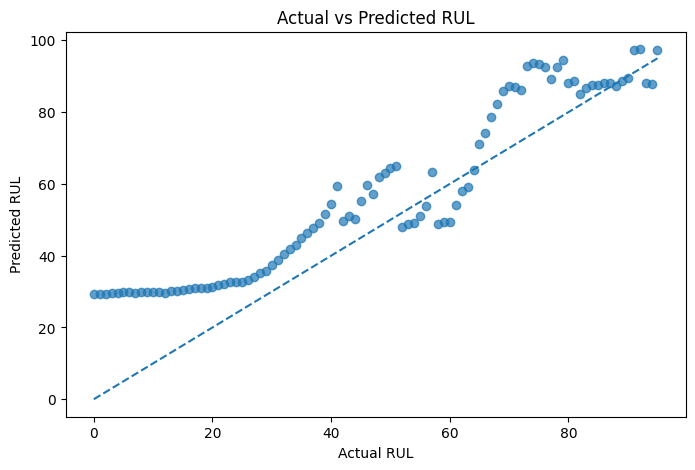

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_tuned, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

In [157]:
print(type(X_test))

if hasattr(X_test, "columns"):
    print(X_test.columns.tolist())
else:
    print("X_test is not a DataFrame")

<class 'pandas.core.frame.DataFrame'>
['Discharge_Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Discharge_Energy', 'Past_SOH_Mean', 'Past_Capacity_Mean', 'Past_Temperature_Mean']


In [158]:
error_analysis = pd.DataFrame({
    "Battery_ID": rul_df.loc[X_test.index, "Battery_ID"].values,
    "Actual_RUL": y_test.values,
    "Predicted_RUL": y_pred_tuned
})

error_analysis["Absolute_Error"] = abs(
    error_analysis["Actual_RUL"] -
    error_analysis["Predicted_RUL"]
)

battery_error = (
    error_analysis
    .groupby("Battery_ID")["Absolute_Error"]
    .agg(["mean", "max", "count"])
    .reset_index()
)

battery_error.columns = [
    "Battery_ID",
    "MAE",
    "Maximum_Error",
    "Test_Samples"
]

display(battery_error.sort_values("MAE"))

,Battery_ID,MAE,Maximum_Error,Test_Samples
0,B0018,11.326562,29.29,96


In [159]:
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = mean_squared_error(y_test, y_pred_tuned) ** 0.5
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest RUL Performance")
print("-----------------------------------")
print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("R2  :", tuned_r2)

Tuned Random Forest RUL Performance
-----------------------------------
MAE : 11.3265625
RMSE: 13.24864397542254
R2  : 0.7714249803309821


In [160]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

batteries = ['B0005', 'B0006', 'B0018']

lobo_results = []

for test_battery in batteries:

    train_data = rul_df[rul_df['Battery_ID'] != test_battery]
    test_data = rul_df[rul_df['Battery_ID'] == test_battery]

    X_train_lobo = train_data[model_features]
    y_train_lobo = train_data['RUL']

    X_test_lobo = test_data[model_features]
    y_test_lobo = test_data['RUL']

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    model.fit(X_train_lobo, y_train_lobo)

    predictions = model.predict(X_test_lobo)

    lobo_results.append({
        'Test_Battery': test_battery,
        'MAE': mean_absolute_error(y_test_lobo, predictions),
        'RMSE': mean_squared_error(y_test_lobo, predictions) ** 0.5,
        'R2': r2_score(y_test_lobo, predictions)
    })

lobo_results_df = pd.DataFrame(lobo_results)

print("Final Battery-wise RUL Validation")
print("---------------------------------")

display(
    lobo_results_df.sort_values('R2', ascending=False)
)

print("\nAverage Performance")
print("-------------------")
print("Average MAE :", lobo_results_df['MAE'].mean())
print("Average RMSE:", lobo_results_df['RMSE'].mean())
print("Average R2  :", lobo_results_df['R2'].mean())

Final Battery-wise RUL Validation
---------------------------------


,Test_Battery,MAE,RMSE,R2
0,B0005,9.224187,11.659366,0.895591
2,B0018,10.618935,13.034917,0.783279
1,B0006,12.178043,15.117924,0.769140



Average Performance
-------------------
Average MAE : 10.673721396008702
Average RMSE: 13.270735902761816
Average R2  : 0.8160032610915117


In [161]:
rul_analysis = rul_df[
    ['Battery_ID', 'Discharge_Cycle', 'SOH', 'Max_Temperature',
     'Avg_Voltage', 'Discharge_Time', 'RUL']
].copy()

display(rul_analysis.corr(numeric_only=True)['RUL'].sort_values())

,RUL
Discharge_Cycle,-0.317618
Discharge_Time,-0.103209
Max_Temperature,0.355919
Avg_Voltage,0.596701
SOH,0.681028
RUL,1.000000


In [162]:
rul_features_v2 = [
    'Discharge_Cycle',
    'SOH',
    'Avg_Voltage',
    'Max_Temperature',
    'Discharge_Time',
    'Discharge_Energy'
]

print("New RUL features:")
print(rul_features_v2)

New RUL features:
['Discharge_Cycle', 'SOH', 'Avg_Voltage', 'Max_Temperature', 'Discharge_Time', 'Discharge_Energy']


In [163]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

batteries = ['B0005', 'B0006', 'B0018']

lobo_results_v2 = []

for test_battery in batteries:

    train_data = rul_df[rul_df['Battery_ID'] != test_battery]
    test_data = rul_df[rul_df['Battery_ID'] == test_battery]

    X_train = train_data[rul_features_v2]
    y_train = train_data['RUL']

    X_test = test_data[rul_features_v2]
    y_test = test_data['RUL']

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    lobo_results_v2.append({
        'Test_Battery': test_battery,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

lobo_results_v2_df = pd.DataFrame(lobo_results_v2)

display(lobo_results_v2_df)

print("Average MAE:", lobo_results_v2_df['MAE'].mean())
print("Average RMSE:", lobo_results_v2_df['RMSE'].mean())
print("Average R2:", lobo_results_v2_df['R2'].mean())

,Test_Battery,MAE,RMSE,R2
0,B0005,11.354773,13.304262,0.864053
1,B0006,13.269144,15.764265,0.748978
2,B0018,10.015945,11.772944,0.823211


Average MAE: 11.54662069380077
Average RMSE: 13.613823727474127
Average R2: 0.8120806271623016


In [164]:
rul_error_analysis = []

for test_battery in batteries:

    train_data = rul_df[rul_df['Battery_ID'] != test_battery]
    test_data = rul_df[rul_df['Battery_ID'] == test_battery]

    X_train = train_data[rul_features_v2]
    y_train = train_data['RUL']

    X_test = test_data[rul_features_v2]
    y_test = test_data['RUL']

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    errors = np.abs(y_test.values - predictions)

    rul_error_analysis.append({
        'Battery': test_battery,
        'MAE': np.mean(errors),
        'Max_Error': np.max(errors),
        'Min_Error': np.min(errors),
        'Samples': len(y_test)
    })

error_df = pd.DataFrame(rul_error_analysis)

display(error_df)

,Battery,MAE,Max_Error,Min_Error,Samples
0,B0005,11.354773,26.326667,0.156667,125
1,B0006,13.269144,35.630000,0.020000,109
2,B0018,10.015945,35.666667,0.606667,97


In [165]:
final_rul_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

X_rul = rul_df[rul_features_v2]
y_rul = rul_df['RUL']

final_rul_model.fit(X_rul, y_rul)

feature_importance = pd.DataFrame({
    'Feature': rul_features_v2,
    'Importance': final_rul_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
2,Avg_Voltage,0.661733
4,Discharge_Time,0.096943
1,SOH,0.096245
5,Discharge_Energy,0.072049
0,Discharge_Cycle,0.053580
3,Max_Temperature,0.019450


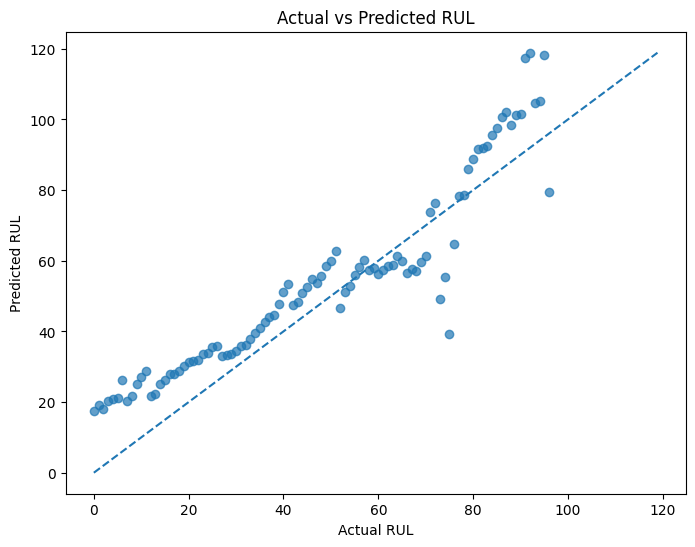

In [166]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, predictions, alpha=0.7)

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

In [167]:
!pip install shap -q

In [168]:
import shap

explainer = shap.TreeExplainer(final_rul_model)

shap_values = explainer.shap_values(X_rul)

print("SHAP analysis completed!")
print("SHAP shape:", shap_values.shape)

SHAP analysis completed!
SHAP shape: (410, 6)


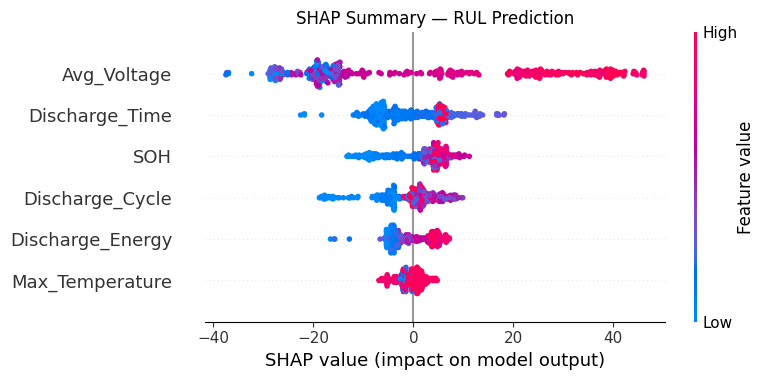

In [169]:
plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_values,
    X_rul,
    show=False
)

plt.title("SHAP Summary — RUL Prediction")
plt.tight_layout()
plt.show()

In [170]:
shap_importance = pd.DataFrame({
    'Feature': X_rul.columns,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    'Mean_Abs_SHAP',
    ascending=False
)

display(shap_importance)

,Feature,Mean_Abs_SHAP
2,Avg_Voltage,21.956361
4,Discharge_Time,6.004457
1,SOH,5.021235
0,Discharge_Cycle,4.346538
5,Discharge_Energy,3.788716
3,Max_Temperature,1.728000


In [171]:
from sklearn.ensemble import IsolationForest

anomaly_features = [
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Discharge_Energy',
    'SOH'
]

anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)


anomaly_model.fit(master_df[anomaly_features])

master_df['Anomaly_Score'] = anomaly_model.decision_function(
    master_df[anomaly_features]
)


master_df['Anomaly'] = anomaly_model.predict(
    master_df[anomaly_features]
)

master_df['Anomaly'] = master_df['Anomaly'].map({
    1: 0,
    -1: 1
})

print("Anomaly detection completed!")
print("Normal cycles:", (master_df['Anomaly'] == 0).sum())
print("Anomalous cycles:", (master_df['Anomaly'] == 1).sum())

Anomaly detection completed!
Normal cycles: 2654
Anomalous cycles: 140


In [172]:
anomaly_details = master_df[
    master_df['Anomaly'] == 1
][[
    'Battery_ID',
    'Discharge_Cycle',
    'SOH',
    'Avg_Voltage',
    'Max_Temperature',
    'Discharge_Time',
    'Anomaly_Score'
]].sort_values(
    ['Battery_ID', 'Discharge_Cycle']
)

display(anomaly_details)

,Battery_ID,Discharge_Cycle,SOH,Avg_Voltage,Max_Temperature,Discharge_Time,Anomaly_Score
908,B0033,1,3.421286,3.372664,34.973342,1819.406,-0.022957
1047,B0033,140,14.933090,3.887870,45.807200,2986.718,-0.074585
1048,B0033,141,11.724340,3.954543,46.034595,3006.203,-0.093212
1049,B0033,142,10.128165,3.987610,44.981619,3011.609,-0.078572
1050,B0033,143,11.765998,3.967303,44.437720,2985.953,-0.055798
...,...,...,...,...,...,...,...
2428,B0052,23,0.000000,0.320075,6.546796,1737.172,-0.141258
2429,B0052,24,0.000000,0.322778,6.595730,1614.406,-0.142279
2430,B0052,25,0.000000,0.320876,6.555065,1708.860,-0.142523
2486,B0053,56,0.000000,4.060790,6.582626,23.000,-0.095401


In [173]:
anomaly_by_battery = (
    master_df.groupby('Battery_ID')['Anomaly']
    .agg(
        Total_Cycles='count',
        Anomalous_Cycles='sum'
    )
    .reset_index()
)

anomaly_by_battery['Anomaly_Percentage'] = (
    anomaly_by_battery['Anomalous_Cycles']
    / anomaly_by_battery['Total_Cycles']
) * 100

anomaly_by_battery = anomaly_by_battery.sort_values(
    'Anomaly_Percentage',
    ascending=False
)

display(anomaly_by_battery)

,Battery_ID,Total_Cycles,Anomalous_Cycles,Anomaly_Percentage
29,B0052,25,21,84.000000
27,B0050,25,11,44.000000
19,B0042,112,47,41.964286
18,B0041,67,12,17.910448
15,B0038,47,7,14.893617
26,B0049,25,2,8.000000
21,B0044,112,8,7.142857
17,B0040,47,3,6.382979
20,B0043,112,7,6.250000
12,B0033,197,9,4.568528


In [174]:
anomaly_soh = (
    master_df.groupby('Anomaly')['SOH']
    .agg(['count', 'mean', 'min', 'max'])
    .reset_index()
)

anomaly_soh['Status'] = anomaly_soh['Anomaly'].map({
    0: 'Normal',
    1: 'Anomalous'
})

display(
    anomaly_soh[
        ['Status', 'count', 'mean', 'min', 'max']
    ]
)

,Status,count,mean,min,max
0,Normal,2654,68.706238,0.0,116.543674
1,Anomalous,140,9.382552,0.0,132.007456


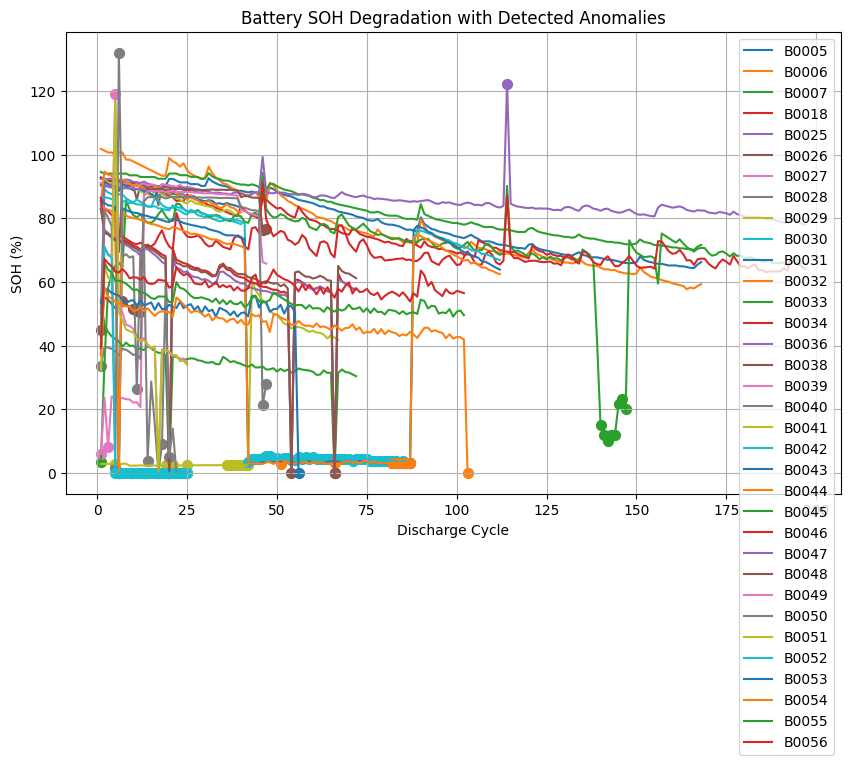

In [175]:
plt.figure(figsize=(10, 6))

for battery_id in master_df['Battery_ID'].unique():
    battery_data = master_df[
        master_df['Battery_ID'] == battery_id
    ]

    plt.plot(
        battery_data['Discharge_Cycle'],
        battery_data['SOH'],
        label=battery_id
    )

    anomalies = battery_data[
        battery_data['Anomaly'] == 1
    ]

    plt.scatter(
        anomalies['Discharge_Cycle'],
        anomalies['SOH'],
        s=50
    )

plt.xlabel("Discharge Cycle")
plt.ylabel("SOH (%)")
plt.title("Battery SOH Degradation with Detected Anomalies")
plt.legend()
plt.grid(True)
plt.show()

In [176]:
early_failure_summary = (
    master_df.groupby('Early_Failure')
    .size()
    .reset_index(name='Count')
)

early_failure_summary['Status'] = early_failure_summary['Early_Failure'].map({
    0: 'Normal',
    1: 'Early Failure Risk'
})

display(
    early_failure_summary[
        ['Status', 'Count']
    ]
)

,Status,Count
0,Normal,2666
1,Early Failure Risk,128


In [177]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

early_features = [
    'Discharge_Cycle',
    'SOH',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Discharge_Energy'
]

train_data = master_df[
    master_df['Battery_ID'].isin(['B0005', 'B0006', 'B0018'])
]

test_data = master_df[
    master_df['Battery_ID'].isin(['B0026'])
]

X_train_early = train_data[early_features]
y_train_early = train_data['Early_Failure']

X_test_early = test_data[early_features]
y_test_early = test_data['Early_Failure']

early_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

early_model.fit(X_train_early, y_train_early)

early_pred = early_model.predict(X_test_early)
early_prob = early_model.predict_proba(X_test_early)[:, 1]

print(classification_report(y_test_early, early_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test_early, early_prob))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88        22
           1       0.00      0.00      0.00         6

    accuracy                           0.79        28
   macro avg       0.39      0.50      0.44        28
weighted avg       0.62      0.79      0.69        28

ROC-AUC: 0.5833333333333334


In [178]:
early_lobo_results = []

batteries = ['B0005', 'B0006', 'B0018']

for test_battery in batteries:

    train_data = master_df[
        master_df['Battery_ID'] != test_battery
    ]

    test_data = master_df[
        master_df['Battery_ID'] == test_battery
    ]

    X_train = train_data[early_features]
    y_train = train_data['Early_Failure']

    X_test = test_data[early_features]
    y_test = test_data['Early_Failure']

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    early_lobo_results.append({
        'Test_Battery': test_battery,
        'Precision': precision_score(
            y_test, pred, zero_division=0
        ),
        'Recall': recall_score(
            y_test, pred, zero_division=0
        ),
        'F1': f1_score(
            y_test, pred, zero_division=0
        ),
        'ROC_AUC': roc_auc_score(y_test, prob)
        if len(np.unique(y_test)) > 1 else np.nan
    })

early_lobo_df = pd.DataFrame(early_lobo_results)

display(early_lobo_df)

print("Average Precision:",
      early_lobo_df['Precision'].mean())

print("Average Recall:",
      early_lobo_df['Recall'].mean())

print("Average F1:",
      early_lobo_df['F1'].mean())

print("Average ROC-AUC:",
      early_lobo_df['ROC_AUC'].mean())

,Test_Battery,Precision,Recall,F1,ROC_AUC
0,B0005,0.0,0.0,0.0,0.918599
1,B0006,0.0,0.0,0.0,0.949132
2,B0018,0.0,0.0,0.0,0.473554


Average Precision: 0.0
Average Recall: 0.0
Average F1: 0.0
Average ROC-AUC: 0.7804281635136263


In [179]:
early_lobo_results = []

batteries = ['B0005', 'B0006', 'B0018']

for test_battery in batteries:

    train_data = master_df[
        master_df['Battery_ID'] != test_battery
    ]

    test_data = master_df[
        master_df['Battery_ID'] == test_battery
    ]

    X_train = train_data[early_features]
    y_train = train_data['Early_Failure']

    X_test = test_data[early_features]
    y_test = test_data['Early_Failure']

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    early_lobo_results.append({
        'Test_Battery': test_battery,
        'Precision': precision_score(
            y_test, pred, zero_division=0
        ),
        'Recall': recall_score(
            y_test, pred, zero_division=0
        ),
        'F1': f1_score(
            y_test, pred, zero_division=0
        ),
        'ROC_AUC': roc_auc_score(y_test, prob)
        if len(np.unique(y_test)) > 1 else np.nan
    })

early_lobo_df = pd.DataFrame(early_lobo_results)

display(early_lobo_df)

print("Average Precision:",
      early_lobo_df['Precision'].mean())

print("Average Recall:",
      early_lobo_df['Recall'].mean())

print("Average F1:",
      early_lobo_df['F1'].mean())

print("Average ROC-AUC:",
      early_lobo_df['ROC_AUC'].mean())

,Test_Battery,Precision,Recall,F1,ROC_AUC
0,B0005,0.0,0.0,0.0,0.918599
1,B0006,0.0,0.0,0.0,0.949132
2,B0018,0.0,0.0,0.0,0.473554


Average Precision: 0.0
Average Recall: 0.0
Average F1: 0.0
Average ROC-AUC: 0.7804281635136263


In [180]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

thresholds = np.arange(0.05, 0.96, 0.05)

for threshold in thresholds:

    pred_threshold = (early_prob >= threshold).astype(int)

    precision = precision_score(
        y_test_early,
        pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test_early,
        pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test_early,
        pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.sort_values(
        'F1',
        ascending=False
    ).head(10)
)

,Threshold,Precision,Recall,F1
0,0.05,0.0,0.0,0.0
1,0.10,0.0,0.0,0.0
2,0.15,0.0,0.0,0.0
3,0.20,0.0,0.0,0.0
4,0.25,0.0,0.0,0.0
5,0.30,0.0,0.0,0.0
6,0.35,0.0,0.0,0.0
7,0.40,0.0,0.0,0.0
8,0.45,0.0,0.0,0.0
9,0.50,0.0,0.0,0.0


In [181]:


print("Minimum probability:", early_prob.min())
print("Maximum probability:", early_prob.max())
print("Average probability:", early_prob.mean())

Minimum probability: 0.0
Maximum probability: 0.03333333333333333
Average probability: 0.0011904761904761904


In [182]:
train_prob = early_model.predict_proba(X_train_early)[:, 1]

print("Training minimum probability:", train_prob.min())
print("Training maximum probability:", train_prob.max())
print("Training average probability:", train_prob.mean())

Training minimum probability: 0.0
Training maximum probability: 1.0
Training average probability: 0.10335470085470085


In [183]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results_train = []

thresholds = np.arange(0.05, 1.00, 0.05)

for threshold in thresholds:
    pred = (train_prob >= threshold).astype(int)

    precision = precision_score(y_train_early, pred, zero_division=0)
    recall = recall_score(y_train_early, pred, zero_division=0)
    f1 = f1_score(y_train_early, pred, zero_division=0)

    threshold_results_train.append({
        'Threshold': round(threshold, 2),
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_train_df = pd.DataFrame(threshold_results_train)

display(
    threshold_train_df
    .sort_values('F1', ascending=False)
    .head(10)
)

,Threshold,Precision,Recall,F1
8,0.45,1.000000,1.000000,1.000000
5,0.30,1.000000,1.000000,1.000000
6,0.35,1.000000,1.000000,1.000000
9,0.50,1.000000,1.000000,1.000000
10,0.55,1.000000,1.000000,1.000000
11,0.60,1.000000,1.000000,1.000000
7,0.40,1.000000,1.000000,1.000000
12,0.65,1.000000,0.979592,0.989691
4,0.25,0.960784,1.000000,0.980000
13,0.70,1.000000,0.959184,0.979167


In [184]:
from sklearn.ensemble import GradientBoostingClassifier

early_gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

early_gb_model.fit(X_train_early, y_train_early)

early_gb_prob = early_gb_model.predict_proba(X_test_early)[:, 1]

print("Minimum probability:", early_gb_prob.min())
print("Maximum probability:", early_gb_prob.max())
print("Average probability:", early_gb_prob.mean())

Minimum probability: 0.000206694231278004
Maximum probability: 0.0009174327181835116
Average probability: 0.00023908623626119513


In [185]:
print("Training Early Failure cases:", y_train_early.sum())
print("Training Normal cases:", (y_train_early == 0).sum())

print()

print("Test Early Failure cases:", y_test_early.sum())
print("Test Normal cases:", (y_test_early == 0).sum())

Training Early Failure cases: 49
Training Normal cases: 419

Test Early Failure cases: 6
Test Normal cases: 22


In [186]:
FAILURE_HORIZON = 20

master_df['Early_Failure_20'] = (
    (master_df['Cycles_To_EOL'] <= FAILURE_HORIZON) &
    (master_df['Cycles_To_EOL'] >= 0)
).astype(int)

print(master_df['Early_Failure_20'].value_counts())

Early_Failure_20
0    2706
1      88
Name: count, dtype: int64


In [187]:
early20_features = [
    'Discharge_Cycle',
    'SOH',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Discharge_Energy'
]

early20_df = master_df.dropna(
    subset=early20_features + ['Early_Failure_20']
).copy()

print("Total samples:", len(early20_df))
print("Early Failure:", early20_df['Early_Failure_20'].sum())
print("Normal:", (early20_df['Early_Failure_20'] == 0).sum())
print("Batteries:", early20_df['Battery_ID'].nunique())

Total samples: 2794
Early Failure: 88
Normal: 2706
Batteries: 34


In [188]:
from sklearn.model_selection import train_test_split

batteries = early20_df['Battery_ID'].unique()

train_batteries, test_batteries = train_test_split(
    batteries,
    test_size=0.25,
    random_state=42
)

train_early20 = early20_df[
    early20_df['Battery_ID'].isin(train_batteries)
].copy()

test_early20 = early20_df[
    early20_df['Battery_ID'].isin(test_batteries)
].copy()

print("Training batteries:", train_batteries)
print("Test batteries:", test_batteries)

print("\nTraining samples:", len(train_early20))
print("Test samples:", len(test_early20))

print("\nTraining Early Failure:", train_early20['Early_Failure_20'].sum())
print("Test Early Failure:", test_early20['Early_Failure_20'].sum())

Training batteries: ['B0030' 'B0005' 'B0025' 'B0039' 'B0040' 'B0026' 'B0034' 'B0032' 'B0006'
 'B0007' 'B0053' 'B0018' 'B0052' 'B0046' 'B0054' 'B0045' 'B0041' 'B0048'
 'B0027' 'B0043' 'B0056' 'B0028' 'B0031' 'B0036' 'B0051']
Test batteries: ['B0038' 'B0042' 'B0050' 'B0049' 'B0029' 'B0047' 'B0044' 'B0033' 'B0055']

Training samples: 2062
Test samples: 732

Training Early Failure: 62
Test Early Failure: 26


In [189]:
from sklearn.ensemble import RandomForestClassifier

X_train_early20 = train_early20[early20_features]
y_train_early20 = train_early20['Early_Failure_20']

X_test_early20 = test_early20[early20_features]
y_test_early20 = test_early20['Early_Failure_20']

early20_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

early20_model.fit(X_train_early20, y_train_early20)

early20_prob = early20_model.predict_proba(X_test_early20)[:, 1]

print("Minimum probability:", early20_prob.min())
print("Maximum probability:", early20_prob.max())
print("Average probability:", early20_prob.mean())

Minimum probability: 0.0
Maximum probability: 0.7566666666666667
Average probability: 0.03971311475409836


In [190]:
from sklearn.metrics import classification_report, roc_auc_score

early20_pred = (early20_prob >= 0.5).astype(int)

print(classification_report(
    y_test_early20,
    early20_pred,
    target_names=['Normal', 'Early Failure'],
    zero_division=0
))

print("ROC-AUC:", roc_auc_score(y_test_early20, early20_prob))

               precision    recall  f1-score   support

       Normal       0.98      1.00      0.99       706
Early Failure       0.92      0.42      0.58        26

     accuracy                           0.98       732
    macro avg       0.95      0.71      0.78       732
 weighted avg       0.98      0.98      0.97       732

ROC-AUC: 0.9808781869688386


In [191]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results_20 = []

thresholds = np.arange(0.01, 0.33, 0.01)

for threshold in thresholds:
    pred = (early20_prob >= threshold).astype(int)

    precision = precision_score(
        y_test_early20, pred, zero_division=0
    )
    recall = recall_score(
        y_test_early20, pred, zero_division=0
    )
    f1 = f1_score(
        y_test_early20, pred, zero_division=0
    )

    threshold_results_20.append({
        'Threshold': round(threshold, 2),
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_20_df = pd.DataFrame(threshold_results_20)

display(
    threshold_20_df
    .sort_values('F1', ascending=False)
    .head(10)
)

,Threshold,Precision,Recall,F1
30,0.31,0.800000,0.769231,0.784314
29,0.30,0.800000,0.769231,0.784314
31,0.32,0.826087,0.730769,0.775510
28,0.29,0.769231,0.769231,0.769231
27,0.28,0.714286,0.769231,0.740741
26,0.27,0.677419,0.807692,0.736842
24,0.25,0.656250,0.807692,0.724138
25,0.26,0.656250,0.807692,0.724138
22,0.23,0.636364,0.807692,0.711864
23,0.24,0.636364,0.807692,0.711864


In [192]:
def extract_battery_features(file_path, battery_name):
    data = sio.loadmat(file_path)
    battery = data[battery_name]
    cycles = battery['cycle'][0, 0]

    rows = []

    for i in range(cycles.shape[1]):
        cycle = cycles[0, i]

        if cycle['type'][0] == 'discharge':

            d = cycle['data'][0, 0]

            voltage = np.asarray(d['Voltage_measured']).flatten()
            current = np.asarray(d['Current_measured']).flatten()
            temperature = np.asarray(d['Temperature_measured']).flatten()
            time = np.asarray(d['Time']).flatten()

            capacity_array = np.asarray(d['Capacity']).flatten()

            # Skip cycle if Capacity is missing
            if len(capacity_array) == 0:
                continue

            capacity = float(capacity_array[0])

            rows.append({
                'Battery_ID': battery_name,
                'Cycle': i + 1,
                'Avg_Voltage': np.mean(voltage),
                'Avg_Current': np.mean(current),
                'Max_Temperature': np.max(temperature),
                'Min_Voltage': np.min(voltage),
                'Discharge_Time': time[-1] - time[0],
                'Capacity': capacity
            })

    return pd.DataFrame(rows)

print("Updated robust feature extraction function!")

Updated robust feature extraction function!


In [193]:
print("===== DATASET QUALITY REPORT =====")

print("Total batteries:", master_df['Battery_ID'].nunique())
print("Total cycle records:", len(master_df))

print("\nMissing values:")
print(master_df.isnull().sum())

print("\nBattery-wise records:")
print(master_df.groupby('Battery_ID').size())

print("\nCycle range:")
print("Minimum cycle:", master_df['Cycle'].min())
print("Maximum cycle:", master_df['Cycle'].max())

===== DATASET QUALITY REPORT =====
Total batteries: 34
Total cycle records: 2794

Missing values:
Battery_ID                    0
Cycle                         0
Avg_Voltage                   0
Avg_Current                   0
Max_Temperature               0
Min_Voltage                   0
Discharge_Time                0
Capacity                      0
SOH                           0
Health                        0
Capacity_Retention            0
Capacity_Growth               0
RUL_Proxy                     0
Capacity_Change              34
SOH_Change                   34
Temperature_Change           34
Voltage_Change               34
SOH_Rolling_Mean              0
Capacity_Rolling_Mean         0
Temperature_Rolling_Mean      0
SOH_Rolling_Std              34
Discharge_Energy              0
Past_SOH_Mean                34
Past_Capacity_Mean           34
Past_Temperature_Mean        34
Cycles_To_EOL               412
Early_Failure                 0
Discharge_Cycle               0
EOL_Di

In [194]:
raw_columns = [
    'Battery_ID',
    'Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Capacity'
]

master_df = master_df[raw_columns].copy()

print("Clean raw dataset created!")
print("Batteries:", master_df['Battery_ID'].nunique())
print("Rows:", len(master_df))

print("\nMissing values:")
print(master_df.isnull().sum())

Clean raw dataset created!
Batteries: 34
Rows: 2794

Missing values:
Battery_ID         0
Cycle              0
Avg_Voltage        0
Avg_Current        0
Max_Temperature    0
Min_Voltage        0
Discharge_Time     0
Capacity           0
dtype: int64


In [195]:
RATED_CAPACITY = 2.0

master_df['SOH'] = (
    master_df['Capacity'] / RATED_CAPACITY
) * 100

In [196]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time'
]

X = master_df[features]
y = master_df['SOH']
groups = master_df['Battery_ID']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("SOH MODEL RESULTS")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

print("\nTraining batteries:",
      master_df.iloc[train_idx]['Battery_ID'].nunique())

print("Testing batteries:",
      master_df.iloc[test_idx]['Battery_ID'].nunique())

SOH MODEL RESULTS
MAE : 6.216517633484536
RMSE: 14.038556473877392
R²  : 0.8127894127442155

Training batteries: 27
Testing batteries: 7


In [197]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("GRADIENT BOOSTING RESULTS")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

GRADIENT BOOSTING RESULTS
MAE : 3.9649921095070804
RMSE: 7.1341848823932645
R²  : 0.9516524781244707


In [198]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': gb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

print("SOH FEATURE IMPORTANCE")
print(importance_df)

SOH FEATURE IMPORTANCE
           Feature  Importance
2  Max_Temperature    0.405294
4   Discharge_Time    0.284069
1      Avg_Current    0.277089
3      Min_Voltage    0.019634
0      Avg_Voltage    0.013914


In [199]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()

lobo_results = []

for train_idx, test_idx in logo.split(X, y, groups):

    X_tr = X.iloc[train_idx]
    X_te = X.iloc[test_idx]
    y_tr = y.iloc[train_idx]
    y_te = y.iloc[test_idx]

    model_lobo = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model_lobo.fit(X_tr, y_tr)

    pred = model_lobo.predict(X_te)

    lobo_results.append({
        'Battery_ID': groups.iloc[test_idx].iloc[0],
        'MAE': mean_absolute_error(y_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        'R2': r2_score(y_te, pred)
    })

lobo_results_df = pd.DataFrame(lobo_results)

print("LEAVE-ONE-BATTERY-OUT VALIDATION")
print(lobo_results_df.to_string(index=False))

print("\nAverage MAE :", lobo_results_df['MAE'].mean())
print("Average RMSE:", lobo_results_df['RMSE'].mean())
print("Average R²  :", lobo_results_df['R2'].mean())

LEAVE-ONE-BATTERY-OUT VALIDATION
Battery_ID       MAE      RMSE         R2
     B0005  0.933360  1.129919   0.985830
     B0006  1.447890  1.832371   0.978731
     B0007  2.297219  2.557274   0.898416
     B0018  1.281943  1.586699   0.957701
     B0025  2.095077  2.532380  -4.354059
     B0026  1.851678  2.904031   0.478888
     B0027  2.002172  2.147660 -10.459555
     B0028  0.995369  1.297399  -0.305932
     B0029  2.294002  2.945592   0.132397
     B0030  2.153628  2.469566   0.326267
     B0031  1.502063  2.019324   0.176462
     B0032  1.591707  1.888423   0.689153
     B0033  3.814188  9.210722   0.576422
     B0034  4.721227  5.424366  -0.107117
     B0036  3.340874  3.657007   0.430130
     B0038  8.574231 13.242606   0.311124
     B0039  2.122915  4.338963   0.977688
     B0040  5.253621  8.481969   0.864652
     B0041  5.279070  5.709988   0.933185
     B0042 15.340171 23.669023   0.590596
     B0043  1.321539  1.610286   0.998011
     B0044  1.195338  1.681089   0.997698
 

In [200]:


master_df = master_df.sort_values(['Battery_ID', 'Cycle']).copy()

master_df['Capacity_Retention'] = (
    master_df['Capacity'] /
    master_df.groupby('Battery_ID')['Capacity'].transform('first')
) * 100

master_df['Capacity_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['Capacity']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

master_df['Temperature_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['Max_Temperature']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

master_df['Voltage_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['Min_Voltage']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

master_df['Discharge_Time_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['Discharge_Time']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

master_df = master_df.fillna(0)

print("Degradation features created successfully!")

Degradation features created successfully!


In [201]:


features_v2 = [
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Capacity_Retention',
    'Capacity_Rolling_Mean',
    'Temperature_Rolling_Mean',
    'Voltage_Rolling_Mean',
    'Discharge_Time_Rolling_Mean'
]

X = master_df[features_v2]
y = master_df['SOH']
groups = master_df['Battery_ID']

logo = LeaveOneGroupOut()

results_v2 = []

for train_idx, test_idx in logo.split(X, y, groups):

    X_tr = X.iloc[train_idx]
    X_te = X.iloc[test_idx]

    y_tr = y.iloc[train_idx]
    y_te = y.iloc[test_idx]

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)

    results_v2.append({
        'Battery_ID': groups.iloc[test_idx].iloc[0],
        'MAE': mean_absolute_error(y_te, pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
        'R2': r2_score(y_te, pred)
    })

results_v2_df = pd.DataFrame(results_v2)

print("SOH MODEL — DEGRADATION-AWARE VALIDATION")
print(results_v2_df.to_string(index=False))

print("\nAverage MAE :", results_v2_df['MAE'].mean())
print("Average RMSE:", results_v2_df['RMSE'].mean())
print("Average R²  :", results_v2_df['R2'].mean())

SOH MODEL — DEGRADATION-AWARE VALIDATION
Battery_ID       MAE      RMSE        R2
     B0005  0.796192  1.083414  0.986973
     B0006  3.763106  5.648259  0.797908
     B0007  1.268646  1.500003  0.965049
     B0018  0.905193  1.347166  0.969508
     B0025  1.195856  1.428998 -0.704859
     B0026  1.564025  2.415995  0.639321
     B0027  0.987171  1.068045 -1.834102
     B0028  0.605085  0.705308  0.614050
     B0029  1.169835  1.725526  0.702272
     B0030  2.917705  3.062126 -0.035840
     B0031  1.067863  1.694311  0.420227
     B0032  1.364863  2.284036  0.545269
     B0033  3.097392  7.334757  0.731393
     B0034  3.670502  4.350176  0.287952
     B0036  0.928436  1.516646  0.901985
     B0038  6.459706 11.377988  0.491460
     B0039 14.700287 16.322371  0.684262
     B0040  3.299985  5.705663  0.938755
     B0041 15.755673 17.084976  0.401817
     B0042 11.231890 16.441172  0.802459
     B0043  1.395474  2.466966  0.995333
     B0044  1.750580  2.486458  0.994964
     B0045  8.44

In [202]:
# Identify batteries that actually reached NASA EOL threshold

EOL_SOH = 70

eol_summary = (
    master_df.groupby('Battery_ID')
    .agg(
        Total_Cycles=('Cycle', 'count'),
        Min_SOH=('SOH', 'min')
    )
    .reset_index()
)

eol_summary['Reached_EOL'] = eol_summary['Min_SOH'] <= EOL_SOH

print(eol_summary.to_string(index=False))

print("\nBatteries reaching EOL:", eol_summary['Reached_EOL'].sum())
print("Batteries not reaching EOL:", (~eol_summary['Reached_EOL']).sum())

Battery_ID  Total_Cycles   Min_SOH  Reached_EOL
     B0005           168 64.372626         True
     B0006           168 57.690917         True
     B0007           168 70.022762        False
     B0018           132 67.052572         True
     B0025            28 88.389454        False
     B0026            28 69.316867         True
     B0027            28 88.504631        False
     B0028            28 85.861678        False
     B0029            40 80.603991        False
     B0030            40 78.139020        False
     B0031            40 83.333760        False
     B0032            40 81.790004        False
     B0033           197  3.421286         True
     B0034           197 37.296515         True
     B0036           197 50.099129         True
     B0038            47 44.902869         True
     B0039            47  5.951916         True
     B0040            47 21.290623         True
     B0041            67  2.204615         True
     B0042           112  0.000000      

In [203]:
# Build genuine RUL dataset from observed EOL

EOL_SOH = 70

rul_df = master_df.copy()

# Actual discharge-cycle sequence for each battery
rul_df['Discharge_Cycle'] = (
    rul_df.groupby('Battery_ID').cumcount() + 1
)

# First discharge cycle where SOH reaches EOL threshold
eol_cycle = (
    rul_df[rul_df['SOH'] <= EOL_SOH]
    .groupby('Battery_ID')['Discharge_Cycle']
    .min()
)

# Keep only batteries that actually reached EOL
rul_df = rul_df[
    rul_df['Battery_ID'].isin(eol_cycle.index)
].copy()

# Map each battery's EOL cycle
rul_df['EOL_Cycle'] = rul_df['Battery_ID'].map(eol_cycle)

# Genuine Remaining Useful Life
rul_df['RUL'] = (
    rul_df['EOL_Cycle'] - rul_df['Discharge_Cycle']
)

# Keep only observations up to observed EOL
rul_df = rul_df[
    rul_df['Discharge_Cycle'] <= rul_df['EOL_Cycle']
].copy()

print("GENUINE RUL DATASET CREATED")
print("Batteries:", rul_df['Battery_ID'].nunique())
print("Rows:", len(rul_df))
print("Minimum RUL:", rul_df['RUL'].min())
print("Maximum RUL:", rul_df['RUL'].max())

GENUINE RUL DATASET CREATED
Batteries: 26
Rows: 410
Minimum RUL: 0
Maximum RUL: 124


In [204]:
# RUL-specific degradation features

rul_df = rul_df.sort_values(
    ['Battery_ID', 'Discharge_Cycle']
).copy()

# Current SOH
rul_df['Current_SOH'] = rul_df['SOH']

# Previous-cycle SOH
rul_df['Previous_SOH'] = (
    rul_df.groupby('Battery_ID')['SOH']
    .shift(1)
)

# SOH degradation from previous cycle
rul_df['SOH_Drop'] = (
    rul_df['Previous_SOH'] - rul_df['SOH']
).fillna(0)

# 5-cycle rolling SOH
rul_df['SOH_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['SOH']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# Capacity trend
rul_df['Capacity_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['Capacity']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

rul_df = rul_df.fillna(0)

print("RUL degradation features created successfully!")

RUL degradation features created successfully!


In [205]:
# Genuine RUL prediction with battery-wise validation

rul_features = [
    'Current_SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Capacity_Rolling_Mean',
    'Max_Temperature',
    'Avg_Current',
    'Min_Voltage',
    'Discharge_Time'
]

X_rul = rul_df[rul_features]
y_rul = rul_df['RUL']
groups_rul = rul_df['Battery_ID']

logo = LeaveOneGroupOut()

rul_results = []

for train_idx, test_idx in logo.split(X_rul, y_rul, groups_rul):

    X_train = X_rul.iloc[train_idx]
    X_test = X_rul.iloc[test_idx]

    y_train = y_rul.iloc[train_idx]
    y_test = y_rul.iloc[test_idx]

    rul_model = GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    rul_model.fit(X_train, y_train)

    pred = rul_model.predict(X_test)

    rul_results.append({
        'Battery_ID': groups_rul.iloc[test_idx].iloc[0],
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred)
    })

rul_results_df = pd.DataFrame(rul_results)

print("GENUINE RUL MODEL — LEAVE-ONE-BATTERY-OUT")
print(rul_results_df.to_string(index=False))

print("\nAverage MAE :", rul_results_df['MAE'].mean())
print("Average RMSE:", rul_results_df['RMSE'].mean())
print("Average R²  :", rul_results_df['R2'].mean())

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

GENUINE RUL MODEL — LEAVE-ONE-BATTERY-OUT
Battery_ID        MAE       RMSE           R2
     B0005  25.505763  29.107678     0.349265
     B0006   9.125578  11.650505     0.862895
     B0018  24.772429  31.981365    -0.304602
     B0026 100.195911 104.558542 -3747.281867
     B0033   1.375570   1.375570          NaN
     B0034   0.098630   0.098630          NaN
     B0036   4.009529   4.009529          NaN
     B0038   0.028582   0.028582          NaN
     B0039   3.819698   3.819698          NaN
     B0040   2.386949   2.386949          NaN
     B0041   0.473294   0.473294          NaN
     B0042  36.522234  40.080415  -549.779302
     B0043  40.363185  44.224743  -669.569571
     B0044  43.696668  47.799346  -782.352293
     B0045   4.385397   4.385397          NaN
     B0046   3.233369   4.457986     0.171932
     B0047   3.831152   4.229793    -1.168624
     B0048   3.897972   5.751286    -1.775716
     B0049   1.791470   1.791470          NaN
     B0050   3.123076   3.123076      

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [206]:
# Check usable RUL trajectories

rul_trajectory = (
    rul_df.groupby('Battery_ID')
    .agg(
        Discharge_Cycles=('Discharge_Cycle', 'count'),
        EOL_Cycle=('EOL_Cycle', 'first'),
        Min_SOH=('SOH', 'min')
    )
    .reset_index()
    .sort_values('Discharge_Cycles')
)

print("RUL TRAJECTORY CHECK")
print(rul_trajectory.to_string(index=False))

RUL TRAJECTORY CHECK
Battery_ID  Discharge_Cycles  EOL_Cycle   Min_SOH
     B0038                 1          1 44.902869
     B0036                 1          1 50.099129
     B0034                 1          1 37.296515
     B0033                 1          1  3.421286
     B0045                 1          1 54.098969
     B0041                 1          1  2.781012
     B0040                 1          1 33.673141
     B0039                 1          1  5.951916
     B0055                 1          1 39.949990
     B0056                 1          1 39.263906
     B0054                 1          1 36.996755
     B0053                 1          1 53.457089
     B0051                 1          1 32.173678
     B0052                 1          1 43.032958
     B0049                 1          1 42.918636
     B0050                 1          1 43.157243
     B0026                 6          6 69.316867
     B0044                 6          6  0.000000
     B0043                 6 

In [207]:
# Relative EOL analysis
# EOL = 70% of each battery's first observed capacity

relative_df = master_df.sort_values(
    ['Battery_ID', 'Cycle']
).copy()

relative_df['Initial_Capacity'] = (
    relative_df.groupby('Battery_ID')['Capacity']
    .transform('first')
)

relative_df['Relative_Capacity'] = (
    relative_df['Capacity'] / relative_df['Initial_Capacity']
) * 100

relative_df['Discharge_Cycle'] = (
    relative_df.groupby('Battery_ID').cumcount() + 1
)

relative_eol = (
    relative_df[relative_df['Relative_Capacity'] <= 70]
    .groupby('Battery_ID')['Discharge_Cycle']
    .min()
)

trajectory_check = (
    relative_df.groupby('Battery_ID')
    .agg(
        Total_Cycles=('Discharge_Cycle', 'count'),
        Final_Relative_Capacity=('Relative_Capacity', 'last')
    )
    .reset_index()
)

trajectory_check['Reached_Relative_EOL'] = (
    trajectory_check['Final_Relative_Capacity'] <= 70
)

print("RELATIVE EOL TRAJECTORY CHECK")
print(trajectory_check.to_string(index=False))

print(
    "\nBatteries reaching relative EOL:",
    trajectory_check['Reached_Relative_EOL'].sum()
)

RELATIVE EOL TRAJECTORY CHECK
Battery_ID  Total_Cycles  Final_Relative_Capacity  Reached_Relative_EOL
     B0005           168                71.375616                 False
     B0006           168                58.254475                  True
     B0007           168                75.749109                 False
     B0018           132                72.293702                 False
     B0025            28                95.710796                 False
     B0026            28                97.546047                 False
     B0027            28                97.081395                 False
     B0028            28                95.154212                 False
     B0029            40                94.967473                 False
     B0030            40                94.366774                 False
     B0031            40               100.037415                 False
     B0032            40                95.949001                 False
     B0033           197          

In [208]:
# Select batteries with sufficiently long degradation trajectories

usable_rul_batteries = trajectory_check[
    (trajectory_check['Reached_Relative_EOL'] == True) &
    (trajectory_check['Total_Cycles'] >= 20)
]['Battery_ID'].tolist()

print("USABLE RUL BATTERIES")
print(usable_rul_batteries)

print("\nNumber of usable batteries:", len(usable_rul_batteries))

USABLE RUL BATTERIES
['B0006', 'B0045', 'B0046', 'B0047', 'B0050', 'B0052', 'B0053', 'B0054']

Number of usable batteries: 8


In [209]:
# Build clean RUL dataset using relative EOL

rul_df = relative_df[
    relative_df['Battery_ID'].isin(usable_rul_batteries)
].copy()

# Relative EOL cycle for each battery
relative_eol_cycle = (
    rul_df[rul_df['Relative_Capacity'] <= 70]
    .groupby('Battery_ID')['Discharge_Cycle']
    .min()
)

# Assign EOL cycle
rul_df['EOL_Cycle'] = (
    rul_df['Battery_ID'].map(relative_eol_cycle)
)

# Genuine remaining useful life
rul_df['RUL'] = (
    rul_df['EOL_Cycle'] - rul_df['Discharge_Cycle']
)

print("CLEAN RUL DATASET CREATED")
print("Batteries:", rul_df['Battery_ID'].nunique())
print("Rows:", len(rul_df))
print("Minimum RUL:", rul_df['RUL'].min())
print("Maximum RUL:", rul_df['RUL'].max())

CLEAN RUL DATASET CREATED
Batteries: 8
Rows: 593
Minimum RUL: -66
Maximum RUL: 102


In [210]:
# Remove cycles after the observed relative EOL point

rul_df = rul_df[
    rul_df['Discharge_Cycle'] <= rul_df['EOL_Cycle']
].copy()

print("RUL DATASET CLEANED")
print("Batteries:", rul_df['Battery_ID'].nunique())
print("Rows:", len(rul_df))
print("Minimum RUL:", rul_df['RUL'].min())
print("Maximum RUL:", rul_df['RUL'].max())

RUL DATASET CLEANED
Batteries: 8
Rows: 328
Minimum RUL: 0
Maximum RUL: 102


In [211]:
# Create RUL-specific degradation features again

rul_df = rul_df.sort_values(
    ['Battery_ID', 'Discharge_Cycle']
).copy()

# Previous-cycle SOH
rul_df['Previous_SOH'] = (
    rul_df.groupby('Battery_ID')['SOH'].shift(1)
)

# SOH degradation
rul_df['SOH_Drop'] = (
    rul_df['Previous_SOH'] - rul_df['SOH']
).fillna(0)

# Past 5-cycle SOH average
rul_df['SOH_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['SOH']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

# Past 5-cycle capacity average
rul_df['Capacity_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['Capacity']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

rul_df = rul_df.fillna(0)

print("RUL FEATURES CREATED SUCCESSFULLY!")

RUL FEATURES CREATED SUCCESSFULLY!


In [212]:
# Final RUL model with battery-wise validation

rul_features = [
    'SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Capacity_Rolling_Mean',
    'Max_Temperature',
    'Avg_Current',
    'Min_Voltage',
    'Discharge_Time'
]

X_rul = rul_df[rul_features]
y_rul = rul_df['RUL']
groups_rul = rul_df['Battery_ID']

logo = LeaveOneGroupOut()

rul_results = []

for train_idx, test_idx in logo.split(X_rul, y_rul, groups_rul):

    X_train = X_rul.iloc[train_idx]
    X_test = X_rul.iloc[test_idx]

    y_train = y_rul.iloc[train_idx]
    y_test = y_rul.iloc[test_idx]

    model = GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rul_results.append({
        'Battery_ID': groups_rul.iloc[test_idx].iloc[0],
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred) if len(y_test) > 1 else np.nan
    })

rul_results_df = pd.DataFrame(rul_results)

print("FINAL RUL MODEL — BATTERY-WISE VALIDATION")
print(rul_results_df.to_string(index=False))

print("\nAverage MAE :", rul_results_df['MAE'].mean())
print("Average RMSE:", rul_results_df['RMSE'].mean())
print("Average R²  :", rul_results_df['R2'].mean())

FINAL RUL MODEL — BATTERY-WISE VALIDATION
Battery_ID       MAE      RMSE          R2
     B0006 24.121320 28.532199    0.060940
     B0045  5.530636  7.184040   -1.150435
     B0046  7.033366  9.231282   -1.562904
     B0047  2.270862  2.521378    0.808802
     B0050 30.573280 34.051970 -578.768322
     B0052  9.311567 11.353698  -63.453231
     B0053 27.494226 38.242881   -4.598155
     B0054 43.880898 52.700523   -2.141793

Average MAE : 18.77701935964416
Average RMSE: 22.97724637971539
Average R²  : -81.35063717670323


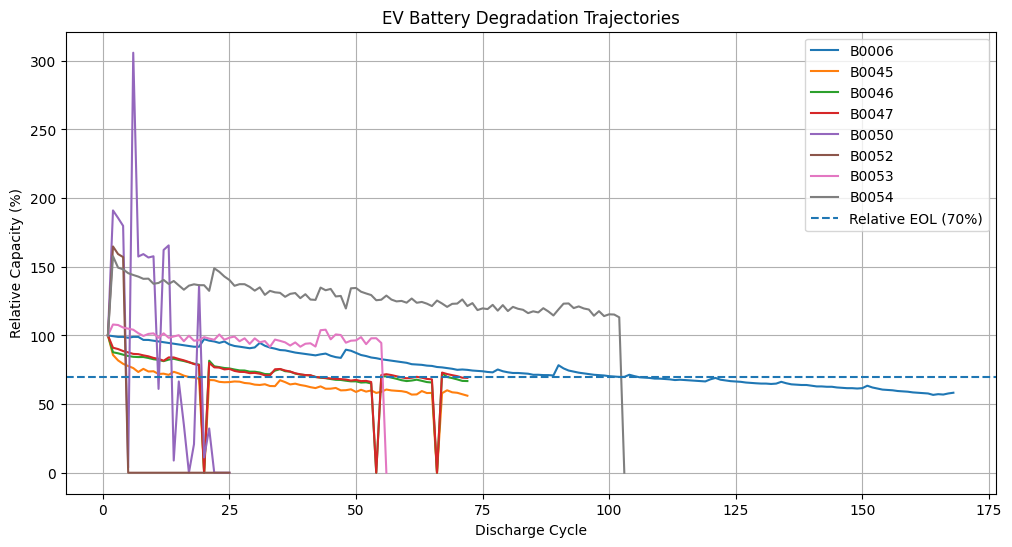

In [213]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for battery in usable_rul_batteries:
    temp = relative_df[
        relative_df['Battery_ID'] == battery
    ].sort_values('Discharge_Cycle')

    plt.plot(
        temp['Discharge_Cycle'],
        temp['Relative_Capacity'],
        label=battery
    )

plt.axhline(
    70,
    linestyle='--',
    label='Relative EOL (70%)'
)

plt.xlabel('Discharge Cycle')
plt.ylabel('Relative Capacity (%)')
plt.title('EV Battery Degradation Trajectories')
plt.legend()
plt.grid(True)

plt.show()

In [214]:
# Check suspicious capacity measurements

capacity_check = (
    master_df.groupby('Battery_ID')['Capacity']
    .agg(
        Min_Capacity='min',
        Max_Capacity='max',
        Median_Capacity='median'
    )
    .reset_index()
)

print("CAPACITY QUALITY CHECK")
print(capacity_check.to_string(index=False))

CAPACITY QUALITY CHECK
Battery_ID  Min_Capacity  Max_Capacity  Median_Capacity
     B0005      1.287453      1.856487         1.557085
     B0006      1.153818      2.035338         1.485372
     B0007      1.400455      1.891052         1.616125
     B0018      1.341051      1.855005         1.531892
     B0025      1.767789      1.848984         1.815056
     B0026      1.386337      1.816528         1.797639
     B0027      1.770093      1.823308         1.808979
     B0028      1.717234      1.804783         1.774432
     B0029      1.612080      1.844701         1.726824
     B0030      1.562780      1.781555         1.659070
     B0031      1.666675      1.832858         1.744216
     B0032      1.635800      1.894032         1.753033
     B0033      0.068426      1.885140         1.441282
     B0034      0.745930      1.820306         1.357717
     B0036      1.001983      2.444062         1.694404
     B0038      0.898057      1.786441         1.776952
     B0039      0.119038 

In [215]:
# Identify suspicious capacity measurements

suspicious_capacity = master_df[
    master_df['Capacity'] <= 0.5
].copy()

print("SUSPICIOUS CAPACITY RECORDS")
print("Total suspicious rows:", len(suspicious_capacity))
print("Affected batteries:", suspicious_capacity['Battery_ID'].nunique())

print("\nRecords by battery:")
print(
    suspicious_capacity['Battery_ID']
    .value_counts()
    .sort_index()
    .to_string()
)

SUSPICIOUS CAPACITY RECORDS
Total suspicious rows: 252
Affected batteries: 17

Records by battery:
Battery_ID
B0033     9
B0039    12
B0040     1
B0041    42
B0042    47
B0043    47
B0044    47
B0045     2
B0046     3
B0047     3
B0048     3
B0049     1
B0050    11
B0051     1
B0052    21
B0053     1
B0054     1


In [216]:
# Inspect suspicious capacity records

check_cols = [
    'Battery_ID',
    'Cycle',
    'Capacity',
    'Avg_Voltage',
    'Min_Voltage',
    'Max_Temperature',
    'Discharge_Time'
]

print(
    suspicious_capacity[check_cols]
    .sort_values(['Battery_ID', 'Cycle'])
    .head(50)
    .to_string(index=False)
)

Battery_ID  Cycle  Capacity  Avg_Voltage  Min_Voltage  Max_Temperature  Discharge_Time
     B0033      1  0.068426     3.372664     1.984860        34.973342        1819.406
     B0033    343  0.298662     3.887870     1.558505        45.807200        2986.718
     B0033    347  0.234487     3.954543     1.203792        46.034595        3006.203
     B0033    349  0.202563     3.987610     1.548491        44.981619        3011.609
     B0033    351  0.235320     3.967303     1.923336        44.437720        2985.953
     B0033    353  0.235504     3.949306     1.477441        46.160943        2976.313
     B0033    355  0.430424     3.753027     1.705135        51.875291        2964.750
     B0033    359  0.464363     3.743728     0.986134        51.767778        2969.953
     B0033    361  0.399484     3.802543     1.326382        51.026752        2988.453
     B0039      1  0.119038     3.378027     2.489796        41.685776         982.938
     B0039      5  0.472986     3.538834   

In [217]:
# Add NASA experimental operating groups

group_map = {
    'B0005': 1, 'B0006': 1, 'B0007': 1, 'B0018': 1,
    'B0025': 2, 'B0026': 2, 'B0027': 2, 'B0028': 2,
    'B0029': 3, 'B0030': 3, 'B0031': 3, 'B0032': 3,
    'B0033': 4, 'B0034': 4, 'B0036': 4,
    'B0038': 5, 'B0039': 5, 'B0040': 5,
    'B0041': 6, 'B0042': 6, 'B0043': 6, 'B0044': 6,
    'B0045': 7, 'B0046': 7, 'B0047': 7, 'B0048': 7,
    'B0049': 8, 'B0050': 8, 'B0051': 8, 'B0052': 8,
    'B0053': 9, 'B0054': 9, 'B0055': 9, 'B0056': 9
}

master_df['Operating_Group'] = master_df['Battery_ID'].map(group_map)

print("Operating groups added successfully!")
print(
    master_df[['Battery_ID', 'Operating_Group']]
    .drop_duplicates()
    .sort_values('Battery_ID')
    .to_string(index=False)
)

Operating groups added successfully!
Battery_ID  Operating_Group
     B0005                1
     B0006                1
     B0007                1
     B0018                1
     B0025                2
     B0026                2
     B0027                2
     B0028                2
     B0029                3
     B0030                3
     B0031                3
     B0032                3
     B0033                4
     B0034                4
     B0036                4
     B0038                5
     B0039                5
     B0040                5
     B0041                6
     B0042                6
     B0043                6
     B0044                6
     B0045                7
     B0046                7
     B0047                7
     B0048                7
     B0049                8
     B0050                8
     B0051                8
     B0052                8
     B0053                9
     B0054                9
     B0055                9
     B0056 

In [218]:
battery_conditions = {
    'B0005': [24, 2, 2.7, 30],
    'B0006': [24, 2, 2.5, 30],
    'B0007': [24, 2, 2.2, 30],
    'B0018': [24, 2, 2.5, 30],

    'B0025': [24, 4, 2.0, 30],
    'B0026': [24, 4, 2.2, 30],
    'B0027': [24, 4, 2.5, 30],
    'B0028': [24, 4, 2.7, 30],

    'B0029': [43, 4, 2.0, 30],
    'B0030': [43, 4, 2.2, 30],
    'B0031': [43, 4, 2.5, 30],
    'B0032': [43, 4, 2.7, 30],

    'B0033': [24, 4, 2.0, 20],
    'B0034': [24, 4, 2.2, 20],
    'B0036': [24, 2, 2.7, 20],

    'B0038': [24, 1, 2.2, 20],
    'B0039': [24, 2, 2.5, 20],
    'B0040': [44, 4, 2.7, 20],

    'B0041': [4, 4, 2.0, 30],
    'B0042': [4, 4, 2.2, 30],
    'B0043': [4, 1, 2.5, 30],
    'B0044': [4, 1, 2.7, 30],

    'B0045': [4, 1, 2.0, 30],
    'B0046': [4, 1, 2.2, 30],
    'B0047': [4, 1, 2.5, 30],
    'B0048': [4, 1, 2.7, 30],

    'B0049': [4, 2, 2.0, None],
    'B0050': [4, 2, 2.2, None],
    'B0051': [4, 2, 2.5, None],
    'B0052': [4, 2, 2.7, None],

    'B0053': [4, 2, 2.0, 30],
    'B0054': [4, 2, 2.2, 30],
    'B0055': [4, 2, 2.5, 30],
    'B0056': [4, 2, 2.7, 30]
}

master_df['Test_Temperature_C'] = master_df['Battery_ID'].map(
    lambda x: battery_conditions[x][0]
)

master_df['Discharge_Current_A'] = master_df['Battery_ID'].map(
    lambda x: battery_conditions[x][1]
)

master_df['Cutoff_Voltage_V'] = master_df['Battery_ID'].map(
    lambda x: battery_conditions[x][2]
)

master_df['EOL_Fade_Percent'] = master_df['Battery_ID'].map(
    lambda x: battery_conditions[x][3]
)

print("Battery test-condition metadata added!")
print(
    master_df[
        [
            'Battery_ID',
            'Operating_Group',
            'Test_Temperature_C',
            'Discharge_Current_A',
            'Cutoff_Voltage_V',
            'EOL_Fade_Percent'
        ]
    ].drop_duplicates().sort_values('Battery_ID').to_string(index=False)
)

Battery test-condition metadata added!
Battery_ID  Operating_Group  Test_Temperature_C  Discharge_Current_A  Cutoff_Voltage_V  EOL_Fade_Percent
     B0005                1                  24                    2               2.7              30.0
     B0006                1                  24                    2               2.5              30.0
     B0007                1                  24                    2               2.2              30.0
     B0018                1                  24                    2               2.5              30.0
     B0025                2                  24                    4               2.0              30.0
     B0026                2                  24                    4               2.2              30.0
     B0027                2                  24                    4               2.5              30.0
     B0028                2                  24                    4               2.7              30.0
     B0029      

In [219]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features_condition_aware = [
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Test_Temperature_C',
    'Discharge_Current_A',
    'Cutoff_Voltage_V'
]

X = master_df[features_condition_aware]
y = master_df['SOH']

groups = master_df['Battery_ID']

results = []

for battery in groups.unique():

    train_mask = groups != battery
    test_mask = groups == battery

    X_train = X[train_mask]
    X_test = X[test_mask]

    y_train = y[train_mask]
    y_test = y[test_mask]

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([battery, mae, rmse, r2])

lobo_results = pd.DataFrame(
    results,
    columns=['Battery_ID', 'MAE', 'RMSE', 'R2']
)

print("Condition-aware LOBO validation")
print("--------------------------------")
print("Average MAE :", lobo_results['MAE'].mean())
print("Average RMSE:", lobo_results['RMSE'].mean())
print("Average R2  :", lobo_results['R2'].mean())

print("\nBattery-wise results:")
print(lobo_results.to_string(index=False))

Condition-aware LOBO validation
--------------------------------
Average MAE : 3.833079603585879
Average RMSE: 5.138284563072526
Average R2  : 0.09498136091674354

Battery-wise results:
Battery_ID       MAE      RMSE        R2
     B0005  0.757995  0.963969  0.989687
     B0006  1.462016  1.969894  0.975419
     B0007  2.163277  2.497740  0.903091
     B0018  1.446698  1.758812  0.948026
     B0025  1.800308  2.214379 -3.093824
     B0026  1.879633  2.914952  0.474961
     B0027  1.579599  1.752997 -6.634825
     B0028  1.110310  1.433918 -0.595226
     B0029  2.095123  2.899606  0.159275
     B0030  2.082382  2.356246  0.386679
     B0031  1.288854  1.849539  0.309127
     B0032  1.679204  1.873085  0.694182
     B0033  3.940768  9.477107  0.551567
     B0034  4.825563  5.500562 -0.138439
     B0036  3.267947  3.589159  0.451079
     B0038  7.476006 13.023689  0.333712
     B0039  3.427028  6.559542  0.949007
     B0040  3.183035  7.924648  0.881854
     B0041  8.883915  9.194669  0.8

In [220]:
master_df = master_df.sort_values(
    ['Battery_ID', 'Cycle']
).copy()

master_df['Previous_Capacity'] = (
    master_df.groupby('Battery_ID')['Capacity'].shift(1)
)

master_df['Capacity_Drop'] = (
    master_df['Previous_Capacity'] - master_df['Capacity']
)

master_df['Previous_SOH'] = (
    master_df.groupby('Battery_ID')['SOH'].shift(1)
)

master_df['SOH_Drop'] = (
    master_df['Previous_SOH'] - master_df['SOH']
)

master_df['SOH_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['SOH']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

master_df['Temperature_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['Max_Temperature']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

master_df['Voltage_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['Min_Voltage']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

master_df['Discharge_Time_Rolling_Mean'] = (
    master_df.groupby('Battery_ID')['Discharge_Time']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

master_df = master_df.fillna(0)

print("Degradation-aware features created!")
print(master_df.shape)
print(master_df[
    [
        'Battery_ID',
        'Cycle',
        'SOH',
        'Previous_SOH',
        'SOH_Drop',
        'SOH_Rolling_Mean'
    ]
].head(10).to_string(index=False))

Degradation-aware features created!
(2794, 24)
Battery_ID  Cycle       SOH  Previous_SOH  SOH_Drop  SOH_Rolling_Mean
     B0005      2 92.824371      0.000000  0.000000          0.000000
     B0005      4 92.316362     92.824371  0.508009         92.824371
     B0005      6 91.767460     92.316362  0.548903         92.570367
     B0005      8 91.763126     91.767460  0.004333         92.302731
     B0005     10 91.732275     91.763126  0.030851         92.167830
     B0005     12 91.783083     91.732275 -0.050808         92.080719
     B0005     14 91.757307     91.783083  0.025776         91.872461
     B0005     16 91.287840     91.757307  0.469468         91.760650
     B0005     18 91.238693     91.287840  0.049147         91.664726
     B0005     20 91.230663     91.238693  0.008029         91.559840


In [221]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

features = [
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Test_Temperature_C',
    'Discharge_Current_A',
    'Cutoff_Voltage_V',
    'Previous_SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Temperature_Rolling_Mean',
    'Voltage_Rolling_Mean',
    'Discharge_Time_Rolling_Mean'
]

model_df = master_df.copy()

# First observed cycle has no previous history
model_df = model_df[model_df['Previous_SOH'] > 0].copy()

results = []

for battery in model_df['Battery_ID'].unique():

    train_df = model_df[model_df['Battery_ID'] != battery]
    test_df = model_df[model_df['Battery_ID'] == battery]

    X_train = train_df[features]
    y_train = train_df['SOH']

    X_test = test_df[features]
    y_test = test_df['SOH']

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    results.append([battery, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=['Battery_ID', 'MAE', 'RMSE', 'R2']
)

print("Degradation-aware SOH — LOBO validation")
print("-----------------------------------------")
print("Average MAE :", results_df['MAE'].mean())
print("Average RMSE:", results_df['RMSE'].mean())
print("Average R2  :", results_df['R2'].mean())

print("\nBattery-wise results:")
print(results_df.to_string(index=False))

Degradation-aware SOH — LOBO validation
-----------------------------------------
Average MAE : 1.348786350827547
Average RMSE: 2.208678042119718
Average R2  : 0.9131002641259852

Battery-wise results:
Battery_ID      MAE      RMSE        R2
     B0005 0.332282  0.461311  0.997620
     B0006 0.859700  1.768724  0.979845
     B0007 0.355843  0.489850  0.996242
     B0018 0.347390  0.450007  0.996525
     B0025 0.271835  0.312147  0.915480
     B0026 0.845242  1.867186  0.790597
     B0027 0.191522  0.253583  0.832896
     B0028 0.148226  0.179773  0.973543
     B0029 0.286683  0.383240  0.985606
     B0030 0.463698  0.582134  0.963493
     B0031 0.293035  0.482398  0.950419
     B0032 0.416746  0.543082  0.974583
     B0033 1.033320  3.428216  0.934067
     B0034 0.344478  0.486363  0.988976
     B0036 0.559720  1.299916  0.902612
     B0038 2.287389  4.121936  0.927637
     B0039 2.200888  4.007437  0.979251
     B0040 2.384814  5.480604  0.941368
     B0041 2.752365  3.076685  0.98072

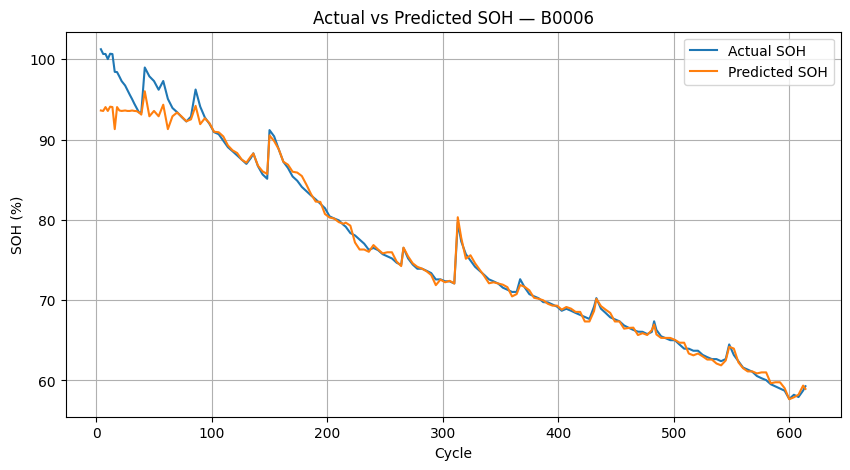

In [222]:
import matplotlib.pyplot as plt

# Choose one representative battery
battery_to_plot = 'B0006'

plot_df = model_df[
    model_df['Battery_ID'] == battery_to_plot
].copy()

train_df = model_df[
    model_df['Battery_ID'] != battery_to_plot
]

X_train = train_df[features]
y_train = train_df['SOH']

X_test = plot_df[features]
y_test = plot_df['SOH']

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

plot_df['Predicted_SOH'] = model.predict(X_test)

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df['Cycle'],
    plot_df['SOH'],
    label='Actual SOH'
)

plt.plot(
    plot_df['Cycle'],
    plot_df['Predicted_SOH'],
    label='Predicted SOH'
)

plt.xlabel('Cycle')
plt.ylabel('SOH (%)')
plt.title('Actual vs Predicted SOH — ' + battery_to_plot)
plt.legend()
plt.grid(True)
plt.show()

SHAP analysis completed!


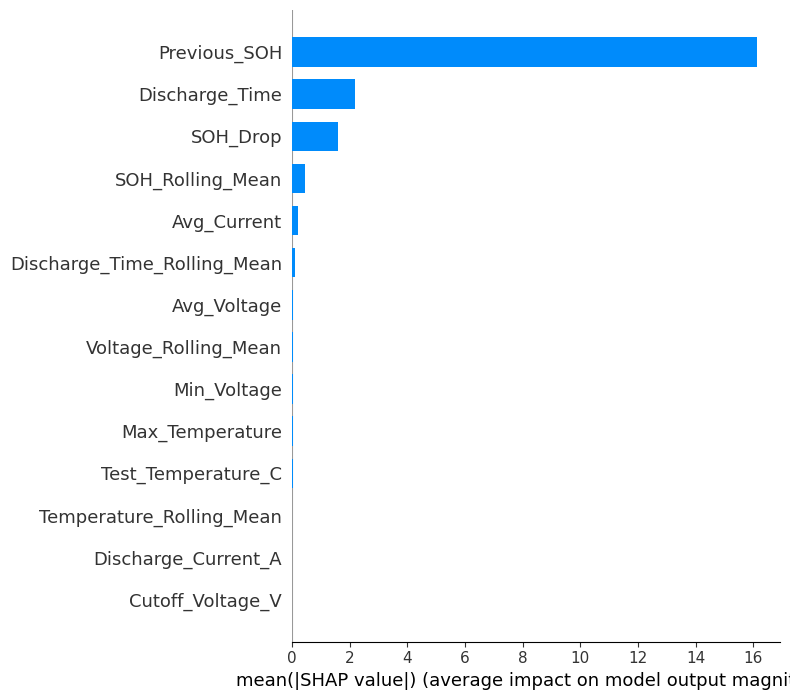

In [223]:
import shap
import matplotlib.pyplot as plt

# Train final SOH model using all available training data
final_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

X_all = model_df[features]
y_all = model_df['SOH']

final_model.fit(X_all, y_all)

# SHAP explainer
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_all)

print("SHAP analysis completed!")

# Global feature importance
shap.summary_plot(
    shap_values,
    X_all,
    plot_type="bar",
    show=True
)

In [224]:
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd

oof_predictions = []

for battery in model_df['Battery_ID'].unique():

    train_df = model_df[
        model_df['Battery_ID'] != battery
    ]

    test_df = model_df[
        model_df['Battery_ID'] == battery
    ]

    X_train = train_df[features]
    y_train = train_df['SOH']

    X_test = test_df[features]
    y_test = test_df['SOH']

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    temp = test_df[
        ['Battery_ID', 'Cycle', 'SOH']
    ].copy()

    temp['Predicted_SOH'] = predictions

    oof_predictions.append(temp)


oof_df = pd.concat(
    oof_predictions,
    ignore_index=True
)

# Prediction error
oof_df['SOH_Error'] = (
    oof_df['SOH'] -
    oof_df['Predicted_SOH']
)

oof_df['Absolute_Error'] = (
    oof_df['SOH_Error'].abs()
)

# Define anomaly threshold
threshold = oof_df['Absolute_Error'].quantile(0.95)

oof_df['Anomaly'] = (
    oof_df['Absolute_Error'] >= threshold
)

print("SOH anomaly detection completed!")
print("--------------------------------")
print("Total observations :", len(oof_df))
print("Anomaly threshold  :", round(threshold, 2))
print("Anomalous cycles   :", oof_df['Anomaly'].sum())

print("\nTop anomalous battery cycles:")
print(
    oof_df[
        oof_df['Anomaly']
    ]
    .sort_values(
        'Absolute_Error',
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

SOH anomaly detection completed!
--------------------------------
Total observations : 2720
Anomaly threshold  : 6.44
Anomalous cycles   : 136

Top anomalous battery cycles:
Battery_ID  Cycle        SOH  Predicted_SOH  SOH_Error  Absolute_Error  Anomaly
     B0050     15 132.007456      72.031769  59.975687       59.975687     True
     B0040    117  21.290623      53.133745 -31.843122       31.843122     True
     B0033      5  34.478495      65.108528 -30.630033       30.630033     True
     B0051     11 116.543674      91.982503  24.561171       24.561171     True
     B0033    347  11.724340      32.762705 -21.038365       21.038365     True
     B0045     51   0.000000      19.864491 -19.864491       19.864491     True
     B0033    349  10.128165      26.777134 -16.648968       16.648968     True
     B0050     35  28.684667      44.442487 -15.757820       15.757820     True
     B0050     17  67.951383      52.709969  15.241414       15.241414     True
     B0042     15   0.0000

In [225]:
anomaly_profile = (
    oof_df
    .groupby('Battery_ID')
    .agg(
        Total_Cycles=('Cycle', 'count'),
        Anomalies=('Anomaly', 'sum'),
        Mean_Error=('Absolute_Error', 'mean'),
        Max_Error=('Absolute_Error', 'max')
    )
    .reset_index()
)

anomaly_profile['Anomaly_Rate_%'] = (
    anomaly_profile['Anomalies'] /
    anomaly_profile['Total_Cycles'] * 100
)

anomaly_profile = anomaly_profile.sort_values(
    'Anomaly_Rate_%',
    ascending=False
)

print("Battery-wise anomaly profile")
print("----------------------------")
print(
    anomaly_profile.to_string(index=False)
)

Battery-wise anomaly profile
----------------------------
Battery_ID  Total_Cycles  Anomalies  Mean_Error  Max_Error  Anomaly_Rate_%
     B0045            69         43    7.199975  19.864491       62.318841
     B0050            20         11    9.148113  59.975687       55.000000
     B0042           110         40    4.079589  15.143667       36.363636
     B0038            46         11    2.287389   9.501754       23.913043
     B0039            46          4    2.200888  12.128166        8.695652
     B0040            46          3    2.384814  31.843122        6.521739
     B0041            66          3    2.752365   8.029216        4.545455
     B0049            23          1    1.128247   6.611094        4.347826
     B0051            23          1    2.276607  24.561171        4.347826
     B0006           167          7    0.859700   7.630747        4.191617
     B0026            27          1    0.845242   8.703651        3.703704
     B0033           196          6    1.0

In [226]:
from sklearn.ensemble import IsolationForest

anomaly_features = [
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Test_Temperature_C',
    'Discharge_Current_A',
    'Cutoff_Voltage_V'
]

X_anomaly = master_df[anomaly_features].copy()

isolation_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

isolation_model.fit(X_anomaly)

master_df['Isolation_Score'] = (
    isolation_model.decision_function(X_anomaly)
)

master_df['Isolation_Anomaly'] = (
    isolation_model.predict(X_anomaly) == -1
)

print("Isolation Forest anomaly detection completed!")
print("--------------------------------------------")
print(
    "Total observations:",
    len(master_df)
)
print(
    "Detected anomalies:",
    master_df['Isolation_Anomaly'].sum()
)

print("\nTop unusual observations:")

print(
    master_df[
        [
            'Battery_ID',
            'Cycle',
            'SOH',
            'Max_Temperature',
            'Avg_Current',
            'Cutoff_Voltage_V',
            'Isolation_Score',
            'Isolation_Anomaly'
        ]
    ]
    .sort_values('Isolation_Score')
    .head(20)
    .to_string(index=False)
)

Isolation Forest anomaly detection completed!
--------------------------------------------
Total observations: 2794
Detected anomalies: 140

Top unusual observations:
Battery_ID  Cycle  SOH  Max_Temperature  Avg_Current  Cutoff_Voltage_V  Isolation_Score  Isolation_Anomaly
     B0052     41  0.0         6.288208     0.001485               2.7        -0.111666               True
     B0052     53  0.0         6.614513     0.000748               2.7        -0.101461               True
     B0052     57  0.0         6.595730     0.000848               2.7        -0.101169               True
     B0052     47  0.0         6.607175     0.000715               2.7        -0.100497               True
     B0052     55  0.0         6.546796     0.000933               2.7        -0.100330               True
     B0052     59  0.0         6.555065     0.001057               2.7        -0.100173               True
     B0052     15  0.0         6.737694     0.001606               2.7        -0.100

In [227]:
import numpy as np

# Merge prediction-error anomaly information
risk_df = master_df.merge(
    oof_df[
        [
            'Battery_ID',
            'Cycle',
            'Absolute_Error'
        ]
    ],
    on=['Battery_ID', 'Cycle'],
    how='left'
)

# Missing prediction error = first observed cycle
risk_df['Absolute_Error'] = (
    risk_df['Absolute_Error'].fillna(0)
)

# --------------------------------------------------
# 1. SOH Risk
# --------------------------------------------------

risk_df['SOH_Risk'] = (
    100 - risk_df['SOH']
).clip(0, 100)


# --------------------------------------------------
# 2. Prediction Error Risk
# --------------------------------------------------

error_limit = risk_df['Absolute_Error'].quantile(0.95)

risk_df['Prediction_Error_Risk'] = (
    risk_df['Absolute_Error'] /
    error_limit * 100
).clip(0, 100)


# --------------------------------------------------
# 3. Isolation Risk
# --------------------------------------------------

isolation_min = risk_df['Isolation_Score'].min()
isolation_max = risk_df['Isolation_Score'].max()

risk_df['Isolation_Risk'] = (
    (isolation_max - risk_df['Isolation_Score']) /
    (isolation_max - isolation_min) * 100
).clip(0, 100)


# --------------------------------------------------
# 4. Final Battery Risk Score
# --------------------------------------------------

risk_df['Risk_Score'] = (
    0.50 * risk_df['SOH_Risk'] +
    0.25 * risk_df['Prediction_Error_Risk'] +
    0.25 * risk_df['Isolation_Risk']
)


# --------------------------------------------------
# 5. Risk Category
# --------------------------------------------------

def classify_risk(score):

    if score < 25:
        return 'Low'

    elif score < 50:
        return 'Moderate'

    elif score < 75:
        return 'High'

    else:
        return 'Critical'


risk_df['Risk_Level'] = (
    risk_df['Risk_Score']
    .apply(classify_risk)
)


print("Battery Risk Scoring completed!")
print("--------------------------------")

print(
    risk_df[
        [
            'Battery_ID',
            'Cycle',
            'SOH',
            'SOH_Risk',
            'Prediction_Error_Risk',
            'Isolation_Risk',
            'Risk_Score',
            'Risk_Level'
        ]
    ]
    .sort_values(
        'Risk_Score',
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

Battery Risk Scoring completed!
--------------------------------
Battery_ID  Cycle      SOH  SOH_Risk  Prediction_Error_Risk  Isolation_Risk  Risk_Score Risk_Level
     B0042    198 3.792143 96.207857                  100.0       76.106705   92.130605   Critical
     B0042    160 4.307398 95.692602                  100.0       76.756675   92.035469   Critical
     B0042    158 4.297777 95.702223                  100.0       76.334961   91.934852   Critical
     B0042    156 4.288875 95.711125                  100.0       76.177425   91.899919   Critical
     B0042    172 4.349012 95.650988                  100.0       76.233251   91.883807   Critical
     B0042    196 3.776883 96.223117                  100.0       73.092717   91.384738   Critical
     B0042    192 3.763787 96.236213                  100.0       72.699265   91.292923   Critical
     B0042    194 3.766176 96.233824                  100.0       72.251817   91.179866   Critical
     B0042    186 3.731528 96.268472        

In [228]:
forecast_df = master_df.sort_values(
    ['Battery_ID', 'Cycle']
).copy()

# Future SOH: 10 observed discharge cycles ahead
forecast_df['Future_SOH_10'] = (
    forecast_df
    .groupby('Battery_ID')['SOH']
    .shift(-10)
)

# Keep only rows where 10 future cycles exist
forecast_df = forecast_df[
    forecast_df['Future_SOH_10'].notna()
].copy()

print("Future SOH forecasting dataset created!")
print("---------------------------------------")
print("Total rows:", len(forecast_df))
print("Batteries:", forecast_df['Battery_ID'].nunique())

print("\nExample:")
print(
    forecast_df[
        [
            'Battery_ID',
            'Cycle',
            'SOH',
            'Future_SOH_10'
        ]
    ].head(15).to_string(index=False)
)

Future SOH forecasting dataset created!
---------------------------------------
Total rows: 2454
Batteries: 34

Example:
Battery_ID  Cycle       SOH  Future_SOH_10
     B0005      2 92.824371      91.230978
     B0005      4 92.316362      90.710097
     B0005      6 91.767460      90.687608
     B0005      8 91.763126      90.672025
     B0005     10 91.732275      90.129900
     B0005     12 91.783083      90.105345
     B0005     14 91.757307      90.128975
     B0005     16 91.287840      90.153416
     B0005     18 91.238693      90.138881
     B0005     20 91.230663      92.351300
     B0005     22 91.230978      92.370866
     B0005     25 90.710097      91.808871
     B0005     27 90.687608      91.289037
     B0005     29 90.672025      91.255682
     B0005     31 90.129900      91.279075


In [229]:
forecast_features = [
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Test_Temperature_C',
    'Discharge_Current_A',
    'Cutoff_Voltage_V',
    'Previous_SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Temperature_Rolling_Mean',
    'Voltage_Rolling_Mean',
    'Discharge_Time_Rolling_Mean'
]

forecast_df = forecast_df[
    forecast_df['Previous_SOH'] > 0
].copy()

results = []

for battery in forecast_df['Battery_ID'].unique():

    train_df = forecast_df[
        forecast_df['Battery_ID'] != battery
    ]

    test_df = forecast_df[
        forecast_df['Battery_ID'] == battery
    ]

    X_train = train_df[forecast_features]
    y_train = train_df['Future_SOH_10']

    X_test = test_df[forecast_features]
    y_test = test_df['Future_SOH_10']

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    results.append([
        battery,
        mae,
        rmse,
        r2
    ])

forecast_results = pd.DataFrame(
    results,
    columns=[
        'Battery_ID',
        'MAE',
        'RMSE',
        'R2'
    ]
)

print("10-cycle-ahead SOH forecasting — LOBO")
print("--------------------------------------")
print("Average MAE :", forecast_results['MAE'].mean())
print("Average RMSE:", forecast_results['RMSE'].mean())
print("Average R2  :", forecast_results['R2'].mean())

print("\nBattery-wise results:")
print(
    forecast_results.to_string(index=False)
)

10-cycle-ahead SOH forecasting — LOBO
--------------------------------------
Average MAE : 8.899068416782088
Average RMSE: 11.666190632980532
Average R2  : -4.073489819043419

Battery-wise results:
Battery_ID       MAE      RMSE         R2
     B0005  1.872415  2.399337   0.931091
     B0006  3.379653  4.558898   0.841334
     B0007  2.509426  3.083808   0.837724
     B0018  4.774658  6.113180   0.201466
     B0025  0.755454  0.878430  -0.458017
     B0026  3.835225  5.536255 -14.530345
     B0027  0.933995  1.137003  -2.051695
     B0028  1.583476  1.729421  -2.766300
     B0029  4.364358  5.315015  -3.914576
     B0030  1.973050  2.205625   0.030380
     B0031  1.267586  1.668672  -0.044988
     B0032  2.208727  3.027627  -0.548856
     B0033  6.662117 13.771479  -0.077716
     B0034 24.663005 27.409295 -38.911184
     B0036  2.314135  4.392456  -0.127748
     B0038  5.631517  6.717118   0.027751
     B0039  7.528693 10.480916   0.230390
     B0040 10.930524 15.577308   0.057626
    

In [230]:
sequence_features = [
    'SOH',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Test_Temperature_C',
    'Discharge_Current_A',
    'Cutoff_Voltage_V',
    'SOH_Drop'
]

sequence_df = master_df.sort_values(
    ['Battery_ID', 'Cycle']
).copy()

sequence_df = sequence_df[
    sequence_df['Previous_SOH'] > 0
].copy()

sequence_df = sequence_df.fillna(0)

SEQUENCE_LENGTH = 10

X_sequences = []
y_sequences = []
battery_sequences = []

for battery, group in sequence_df.groupby('Battery_ID'):

    group = group.sort_values('Cycle')

    values = group[sequence_features].values
    future_soh = group['SOH'].values

    for i in range(
        SEQUENCE_LENGTH,
        len(group)
    ):

        X_sequences.append(
            values[i-SEQUENCE_LENGTH:i]
        )

        y_sequences.append(
            future_soh[i]
        )

        battery_sequences.append(
            battery
        )

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("Sequence dataset created!")
print("-------------------------")
print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)
print("Batteries:", len(set(battery_sequences)))

Sequence dataset created!
-------------------------
X shape: (2386, 10, 10)
y shape: (2386,)
Batteries: 33


In [231]:
# Install TensorFlow if needed
!pip install -q tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [232]:
from sklearn.model_selection import GroupShuffleSplit

# Convert battery IDs to an array
groups = np.array(battery_sequences)

# 80% batteries → training
# 20% batteries → testing
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_sequences, y_sequences, groups=groups)
)

X_train = X_sequences[train_idx]
X_test = X_sequences[test_idx]

y_train = y_sequences[train_idx]
y_test = y_sequences[test_idx]

train_batteries = groups[train_idx]
test_batteries = groups[test_idx]

print("Training sequences:", X_train.shape)
print("Testing sequences :", X_test.shape)

print("\nTraining batteries:", len(set(train_batteries)))
print("Testing batteries :", len(set(test_batteries)))

print("\nTest batteries:", sorted(set(test_batteries)))

Training sequences: (2052, 10, 10)
Testing sequences : (334, 10, 10)

Training batteries: 26
Testing batteries : 7

Test batteries: [np.str_('B0029'), np.str_('B0030'), np.str_('B0038'), np.str_('B0040'), np.str_('B0042'), np.str_('B0049'), np.str_('B0055')]


In [233]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(10, 10)),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

In [234]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")
print("Epochs actually used:", len(history.history['loss']))

Epoch 1/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 4805.5859 - mae: 65.6033 - val_loss: 2065.8008 - val_mae: 44.2032
Epoch 2/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3595.8469 - mae: 56.9782 - val_loss: 1194.7019 - val_mae: 33.5511
Epoch 3/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2365.4805 - mae: 46.3278 - val_loss: 514.9378 - val_mae: 21.3500
Epoch 4/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1410.3638 - mae: 35.4459 - val_loss: 186.9285 - val_mae: 10.3736
Epoch 5/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 844.0698 - mae: 26.2730 - val_loss: 178.9058 - val_mae: 8.4206
Epoch 6/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 628.8414 - mae: 20.2836 - val_loss: 290.7111 - val_mae: 12.1287
Epoch 7/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 567.5209 - mae: 17.5145 - val_loss: 270.3846 - val_mae: 11.6784
Epoch 8/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 434.8651 - mae: 15.8590 - val_loss: 393.1572 - val_mae: 15.9996
Epo

In [235]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict SOH for completely unseen batteries
y_pred = model.predict(X_test).flatten()

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("LSTM SOH Forecasting Results")
print("----------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step
LSTM SOH Forecasting Results
----------------------------
MAE  : 23.4260
RMSE : 28.1911
R²   : -0.0249


In [236]:
from sklearn.preprocessing import StandardScaler

# Reshape 3D sequences into 2D
n_train, timesteps, n_features = X_train.shape
n_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

# Fit scaler ONLY on training data
feature_scaler = StandardScaler()
X_train_scaled_2d = feature_scaler.fit_transform(X_train_2d)
X_test_scaled_2d = feature_scaler.transform(X_test_2d)

# Convert back to 3D sequence format
X_train_scaled = X_train_scaled_2d.reshape(
    n_train, timesteps, n_features
)

X_test_scaled = X_test_scaled_2d.reshape(
    n_test, timesteps, n_features
)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (2052, 10, 10)
Scaled testing shape : (334, 10, 10)


In [237]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

scaled_model = Sequential([
    Input(shape=(10, 10)),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

scaled_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

scaled_history = scaled_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.15,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\nScaled LSTM training completed!")
print("Epochs used:", len(scaled_history.history['loss']))

Epoch 1/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 4677.8887 - mae: 64.8588 - val_loss: 2548.5916 - val_mae: 49.3448
Epoch 2/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3025.5994 - mae: 52.0163 - val_loss: 1020.5530 - val_mae: 31.4453
Epoch 3/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1786.5787 - mae: 39.1873 - val_loss: 290.7707 - val_mae: 14.9924
Epoch 4/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 910.7423 - mae: 27.2637 - val_loss: 148.2558 - val_mae: 8.0973
Epoch 5/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 454.2417 - mae: 17.9814 - val_loss: 267.6833 - val_mae: 12.4740
Epoch 6/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 275.0610 - mae: 12.7717 - val_loss: 173.4052 - val_mae: 10.3904
Epoch 7/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 172.2181 - mae: 9.5868 - val_loss: 216.4810 - val_mae: 11.0022
Epoch 8/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 127.1869 - mae: 8.2967 - val_loss: 258.8199 - val_mae: 12.7439
Epoch 

In [238]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on unseen batteries
y_pred_scaled = scaled_model.predict(X_test_scaled).flatten()

# Evaluation metrics
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
r2_scaled = r2_score(y_test, y_pred_scaled)

print("Scaled LSTM SOH Forecasting Results")
print("-----------------------------------")
print(f"MAE  : {mae_scaled:.4f}")
print(f"RMSE : {rmse_scaled:.4f}")
print(f"R²   : {r2_scaled:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Scaled LSTM SOH Forecasting Results
-----------------------------------
MAE  : 22.8144
RMSE : 27.1136
R²   : 0.0519


In [239]:
SEQUENCE_LENGTH = 20

X_sequences_20 = []
y_sequences_20 = []
battery_sequences_20 = []

for battery, group in sequence_df.groupby('Battery_ID'):
    group = group.sort_values('Cycle')

    values = group[sequence_features].values
    future_soh = group['SOH'].values

    for i in range(SEQUENCE_LENGTH, len(group)):
        X_sequences_20.append(values[i-SEQUENCE_LENGTH:i])
        y_sequences_20.append(future_soh[i])
        battery_sequences_20.append(battery)

X_sequences_20 = np.array(X_sequences_20)
y_sequences_20 = np.array(y_sequences_20)
battery_sequences_20 = np.array(battery_sequences_20)

print("X shape:", X_sequences_20.shape)
print("y shape:", y_sequences_20.shape)
print("Batteries:", len(set(battery_sequences_20)))

X shape: (2056, 20, 10)
y shape: (2056,)
Batteries: 32


In [240]:
from sklearn.model_selection import GroupShuffleSplit

groups_20 = np.array(battery_sequences_20)

gss_20 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_20, test_idx_20 = next(
    gss_20.split(X_sequences_20, y_sequences_20, groups_20)
)

X_train_20 = X_sequences_20[train_idx_20]
X_test_20 = X_sequences_20[test_idx_20]

y_train_20 = y_sequences_20[train_idx_20]
y_test_20 = y_sequences_20[test_idx_20]

train_batteries_20 = groups_20[train_idx_20]
test_batteries_20 = groups_20[test_idx_20]

print("Training sequences:", X_train_20.shape)
print("Testing sequences :", X_test_20.shape)

print("\nTraining batteries:", len(set(train_batteries_20)))
print("Testing batteries :", len(set(test_batteries_20)))

print("\nTest batteries:", sorted(set(test_batteries_20)))

Training sequences: (1755, 20, 10)
Testing sequences : (301, 20, 10)

Training batteries: 25
Testing batteries : 7

Test batteries: [np.str_('B0029'), np.str_('B0030'), np.str_('B0038'), np.str_('B0040'), np.str_('B0047'), np.str_('B0054'), np.str_('B0055')]


In [241]:
from sklearn.preprocessing import StandardScaler

n_train_20, timesteps_20, n_features_20 = X_train_20.shape
n_test_20 = X_test_20.shape[0]

# Reshape 3D → 2D
X_train_20_2d = X_train_20.reshape(-1, n_features_20)
X_test_20_2d = X_test_20.reshape(-1, n_features_20)

# Fit ONLY on training data
scaler_20 = StandardScaler()

X_train_20_scaled_2d = scaler_20.fit_transform(X_train_20_2d)
X_test_20_scaled_2d = scaler_20.transform(X_test_20_2d)

# 2D → 3D
X_train_20_scaled = X_train_20_scaled_2d.reshape(
    n_train_20, timesteps_20, n_features_20
)

X_test_20_scaled = X_test_20_scaled_2d.reshape(
    n_test_20, timesteps_20, n_features_20
)

print("Scaled training shape:", X_train_20_scaled.shape)
print("Scaled testing shape :", X_test_20_scaled.shape)

Scaled training shape: (1755, 20, 10)
Scaled testing shape : (301, 20, 10)


In [242]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_20 = Sequential([
    Input(shape=(20, 10)),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model_20.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stopping_20 = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

model_20.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 20, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

In [243]:
history_20 = model_20.fit(
    X_train_20_scaled,
    y_train_20,
    validation_split=0.15,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping_20],
    verbose=1
)

print("\n20-cycle LSTM training completed!")
print("Epochs used:", len(history_20.history['loss']))

Epoch 1/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - loss: 4951.0840 - mae: 66.1560 - val_loss: 2923.9275 - val_mae: 52.4501
Epoch 2/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 4113.2744 - mae: 60.3977 - val_loss: 1827.6163 - val_mae: 41.2511
Epoch 3/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 3298.9644 - mae: 54.6166 - val_loss: 1207.9695 - val_mae: 33.0845
Epoch 4/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 2415.4146 - mae: 46.7685 - val_loss: 719.9576 - val_mae: 24.7854
Epoch 5/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 1590.4308 - mae: 37.3120 - val_loss: 469.2513 - val_mae: 19.6246
Epoch 6/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 947.4989 - mae: 28.0649 - val_loss: 234.8861 - val_mae: 12.5108
Epoch 7/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 524.7554 - mae: 19.7643 - val_loss: 125.1462 - val_mae: 7.0725
Epoch 8/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 285.8232 - mae: 13.5094 - val_loss: 213.4050 - val_mae: 9.8422
E

In [244]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict SOH for unseen batteries
y_pred_20 = model_20.predict(X_test_20_scaled).flatten()

# Evaluation metrics
mae_20 = mean_absolute_error(y_test_20, y_pred_20)
rmse_20 = np.sqrt(mean_squared_error(y_test_20, y_pred_20))
r2_20 = r2_score(y_test_20, y_pred_20)

print("20-Cycle LSTM SOH Forecasting Results")
print("---------------------------------------")
print(f"MAE  : {mae_20:.4f}")
print(f"RMSE : {rmse_20:.4f}")
print(f"R²   : {r2_20:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
20-Cycle LSTM SOH Forecasting Results
---------------------------------------
MAE  : 11.3115
RMSE : 15.7366
R²   : 0.1515


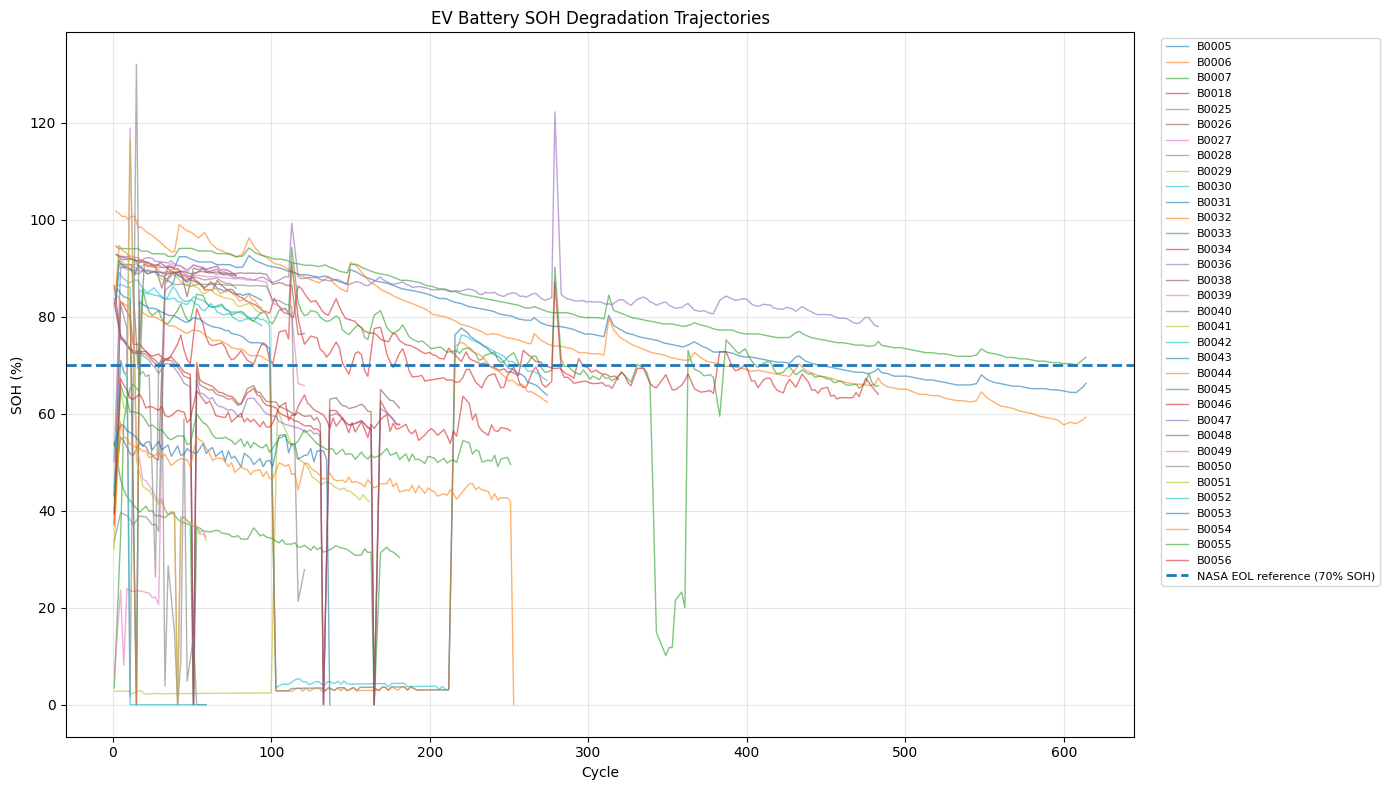

In [245]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for battery, group in master_df.groupby('Battery_ID'):
    group = group.sort_values('Cycle')

    plt.plot(
        group['Cycle'],
        group['SOH'],
        linewidth=1,
        alpha=0.6,
        label=battery
    )

# Official NASA EOL reference: 70% SOH
plt.axhline(
    y=70,
    linestyle='--',
    linewidth=2,
    label='NASA EOL reference (70% SOH)'
)

plt.xlabel('Cycle')
plt.ylabel('SOH (%)')
plt.title('EV Battery SOH Degradation Trajectories')
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [246]:
# NASA reference EOL threshold
EOL_SOH = 70

rul_candidates = []

for battery, group in master_df.groupby('Battery_ID'):
    group = group.sort_values('Cycle')

    # Cycles where battery has reached EOL threshold
    eol_rows = group[group['SOH'] <= EOL_SOH]

    if len(eol_rows) == 0:
        continue

    eol_cycle = eol_rows['Cycle'].iloc[0]

    # Number of observations before EOL
    pre_eol = group[group['Cycle'] < eol_cycle]

    rul_candidates.append({
        'Battery_ID': battery,
        'EOL_Cycle': eol_cycle,
        'Pre_EOL_Cycles': len(pre_eol),
        'Total_Cycles': len(group)
    })

rul_candidates_df = pd.DataFrame(rul_candidates)

# Keep batteries with enough degradation history
reliable_rul_batteries = rul_candidates_df[
    rul_candidates_df['Pre_EOL_Cycles'] >= 20
].copy()

print("Batteries reaching 70% SOH:", len(rul_candidates_df))
print("Reliable RUL batteries:", len(reliable_rul_batteries))

print("\nReliable batteries:")
print(reliable_rul_batteries.sort_values('Pre_EOL_Cycles').to_string(index=False))

Batteries reaching 70% SOH: 26
Reliable RUL batteries: 3

Reliable batteries:
Battery_ID  EOL_Cycle  Pre_EOL_Cycles  Total_Cycles
     B0018        237              96           132
     B0006        387             108           168
     B0005        449             124           168


In [247]:
# Use only reliable batteries
rul_df = master_df[
    master_df['Battery_ID'].isin(
        reliable_rul_batteries['Battery_ID']
    )
].copy()

# Get the first cycle where each battery reaches 70% SOH
eol_cycle_map = (
    reliable_rul_batteries
    .set_index('Battery_ID')['EOL_Cycle']
    .to_dict()
)

# Calculate genuine Remaining Useful Life
rul_df['EOL_Cycle'] = rul_df['Battery_ID'].map(eol_cycle_map)

rul_df['RUL'] = rul_df['EOL_Cycle'] - rul_df['Cycle']

# Keep only cycles before EOL
rul_df = rul_df[rul_df['RUL'] >= 0].copy()

print("RUL dataset shape:", rul_df.shape)
print("\nBatteries:", rul_df['Battery_ID'].nunique())
print("\nRUL statistics:")
print(rul_df['RUL'].describe())

print("\nRUL dataset preview:")
print(
    rul_df[
        ['Battery_ID', 'Cycle', 'SOH', 'EOL_Cycle', 'RUL']
    ].head(15)
)

RUL dataset shape: (331, 28)

Batteries: 3

RUL statistics:
count    331.000000
mean     190.903323
std      124.374909
min        0.000000
25%       86.000000
50%      175.000000
75%      290.000000
max      447.000000
Name: RUL, dtype: float64

RUL dataset preview:
   Battery_ID  Cycle        SOH  EOL_Cycle  RUL
0       B0005      2  92.824371        449  447
1       B0005      4  92.316362        449  445
2       B0005      6  91.767460        449  443
3       B0005      8  91.763126        449  441
4       B0005     10  91.732275        449  439
5       B0005     12  91.783083        449  437
6       B0005     14  91.757307        449  435
7       B0005     16  91.287840        449  433
8       B0005     18  91.238693        449  431
9       B0005     20  91.230663        449  429
10      B0005     22  91.230978        449  427
11      B0005     25  90.710097        449  424
12      B0005     27  90.687608        449  422
13      B0005     29  90.672025        449  420
14      B000

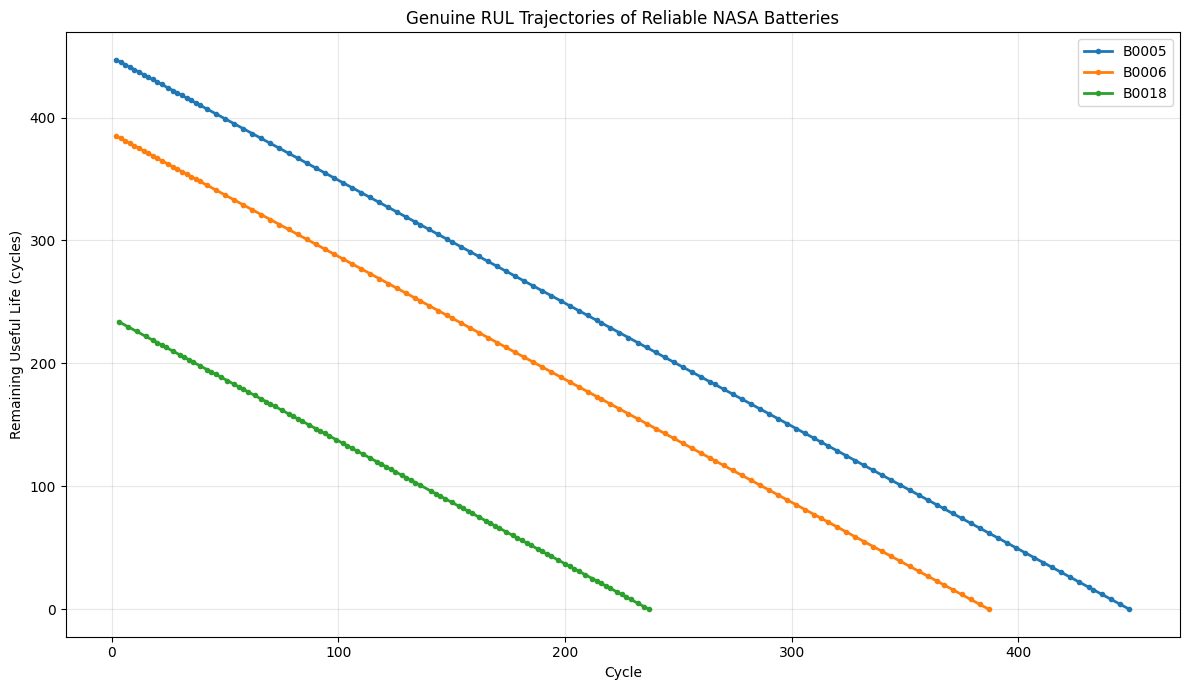

In [248]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for battery, group in rul_df.groupby('Battery_ID'):
    group = group.sort_values('Cycle')

    plt.plot(
        group['Cycle'],
        group['RUL'],
        marker='o',
        markersize=3,
        linewidth=2,
        label=battery
    )

plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life (cycles)')
plt.title('Genuine RUL Trajectories of Reliable NASA Batteries')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [249]:
rul_df = rul_df.sort_values(
    ['Battery_ID', 'Cycle']
).copy()

# Previous-cycle information
rul_df['Previous_SOH'] = (
    rul_df.groupby('Battery_ID')['SOH'].shift(1)
)

rul_df['SOH_Drop'] = (
    rul_df['Previous_SOH'] - rul_df['SOH']
)

# Rolling degradation history
rul_df['SOH_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['SOH']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

rul_df['Temperature_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['Max_Temperature']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

rul_df['Voltage_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['Min_Voltage']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

rul_df['Discharge_Time_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['Discharge_Time']
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

# Remove first observation of each battery
rul_model_df = rul_df[
    rul_df['Previous_SOH'].notna()
].copy()

print("RUL model dataset shape:", rul_model_df.shape)

print("\nFeatures:")
print(rul_model_df.columns.tolist())

print("\nMissing values:")
print(rul_model_df.isna().sum().sum())

RUL model dataset shape: (328, 28)

Features:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'Capacity_Retention', 'Capacity_Rolling_Mean', 'Temperature_Rolling_Mean', 'Voltage_Rolling_Mean', 'Discharge_Time_Rolling_Mean', 'Operating_Group', 'Test_Temperature_C', 'Discharge_Current_A', 'Cutoff_Voltage_V', 'EOL_Fade_Percent', 'Previous_Capacity', 'Capacity_Drop', 'Previous_SOH', 'SOH_Drop', 'SOH_Rolling_Mean', 'Isolation_Score', 'Isolation_Anomaly', 'EOL_Cycle', 'RUL']

Missing values:
0


In [250]:
rul_features = [
    'Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'SOH',
    'Previous_SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Temperature_Rolling_Mean',
    'Voltage_Rolling_Mean',
    'Discharge_Time_Rolling_Mean',
    'Test_Temperature_C',
    'Discharge_Current_A',
    'Cutoff_Voltage_V'
]

X_rul = rul_model_df[rul_features].copy()
y_rul = rul_model_df['RUL'].copy()
groups_rul = rul_model_df['Battery_ID'].copy()

print("RUL features:", len(rul_features))
print("X shape:", X_rul.shape)
print("y shape:", y_rul.shape)
print("Batteries:", groups_rul.nunique())

RUL features: 16
X shape: (328, 16)
y shape: (328,)
Batteries: 3


In [251]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results_rul = []

for test_battery in groups_rul.unique():

    train_mask = groups_rul != test_battery
    test_mask = groups_rul == test_battery

    X_train_rul = X_rul[train_mask]
    X_test_rul = X_rul[test_mask]

    y_train_rul = y_rul[train_mask]
    y_test_rul = y_rul[test_mask]

    model_rul = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model_rul.fit(X_train_rul, y_train_rul)

    predictions = model_rul.predict(X_test_rul)

    mae = mean_absolute_error(y_test_rul, predictions)
    rmse = np.sqrt(
        mean_squared_error(y_test_rul, predictions)
    )
    r2 = r2_score(y_test_rul, predictions)

    results_rul.append({
        'Test_Battery': test_battery,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

rul_results_df = pd.DataFrame(results_rul)

print(rul_results_df.to_string(index=False))

print("\nAverage LOBO Performance")
print("------------------------")
print(f"MAE  : {rul_results_df['MAE'].mean():.4f}")
print(f"RMSE : {rul_results_df['RMSE'].mean():.4f}")
print(f"R²   : {rul_results_df['R2'].mean():.4f}")

Test_Battery        MAE       RMSE        R2
       B0005  92.638655 114.566470  0.279390
       B0006  52.732219  64.723641  0.691455
       B0018 110.536327 114.673334 -1.982811

Average LOBO Performance
------------------------
MAE  : 85.3024
RMSE : 97.9878
R²   : -0.3373


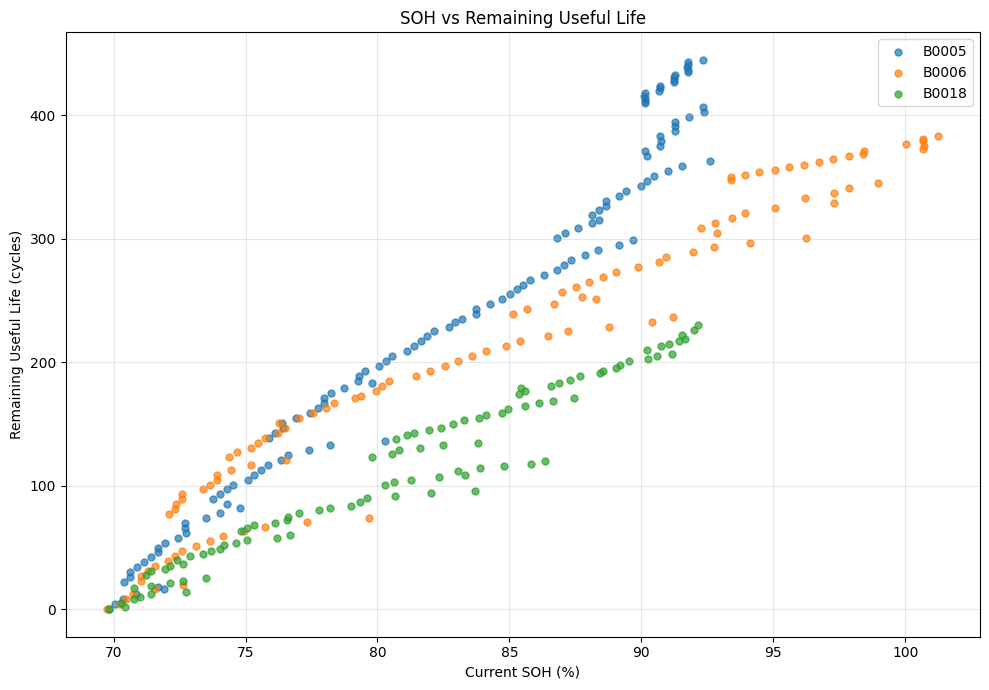

In [252]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for battery, group in rul_model_df.groupby('Battery_ID'):
    group = group.sort_values('Cycle')

    plt.scatter(
        group['SOH'],
        group['RUL'],
        s=25,
        alpha=0.7,
        label=battery
    )

plt.xlabel('Current SOH (%)')
plt.ylabel('Remaining Useful Life (cycles)')
plt.title('SOH vs Remaining Useful Life')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [253]:
degradation_summary_df = (
    rul_df.groupby("Battery_ID")
    .apply(
        lambda group: pd.Series({
            "SOH_Slope_per_Cycle": np.polyfit(
                group["Cycle"],
                group["SOH"],
                1
            )[0]
        })
    )
    .reset_index()
)

print(degradation_summary_df)

  Battery_ID  SOH_Slope_per_Cycle
0      B0005            -0.054108
1      B0006            -0.082583
2      B0018            -0.096753


/tmp/ipykernel_1153/2388669132.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [254]:
print(rul_df.columns.tolist())
print(degradation_summary_df.columns.tolist())

['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'Capacity_Retention', 'Capacity_Rolling_Mean', 'Temperature_Rolling_Mean', 'Voltage_Rolling_Mean', 'Discharge_Time_Rolling_Mean', 'Operating_Group', 'Test_Temperature_C', 'Discharge_Current_A', 'Cutoff_Voltage_V', 'EOL_Fade_Percent', 'Previous_Capacity', 'Capacity_Drop', 'Previous_SOH', 'SOH_Drop', 'SOH_Rolling_Mean', 'Isolation_Score', 'Isolation_Anomaly', 'EOL_Cycle', 'RUL']
['Battery_ID', 'SOH_Slope_per_Cycle']


In [255]:
rul_estimates = rul_model_df.copy()

slope_map = degradation_summary_df.set_index(
    'Battery_ID'
)['SOH_Slope_per_Cycle'].to_dict()

rul_estimates['Estimated_RUL'] = (
    (rul_estimates['SOH'] - 70) /
    rul_estimates['Battery_ID'].map(slope_map).abs()
)

rul_estimates['Estimated_RUL'] = rul_estimates['Estimated_RUL'].clip(lower=0)

rul_estimates['RUL_Error'] = (
    rul_estimates['Estimated_RUL'] - rul_estimates['RUL']
)

rul_estimates['Absolute_RUL_Error'] = (
    rul_estimates['RUL_Error'].abs()
)

print(
    rul_estimates[
        ['Battery_ID', 'Cycle', 'SOH',
         'RUL', 'Estimated_RUL',
         'Absolute_RUL_Error']
    ].head(15).to_string(index=False)
)

print("\nRUL MAE:",
      rul_estimates['Absolute_RUL_Error'].mean())

Battery_ID  Cycle       SOH  RUL  Estimated_RUL  Absolute_RUL_Error
     B0005      4 92.316362  445     412.443243           32.556757
     B0005      6 91.767460  443     402.298613           40.701387
     B0005      8 91.763126  441     402.218526           38.781474
     B0005     10 91.732275  439     401.648349           37.351651
     B0005     12 91.783083  437     402.587357           34.412643
     B0005     14 91.757307  435     402.110977           32.889023
     B0005     16 91.287840  433     393.434439           39.565561
     B0005     18 91.238693  431     392.526124           38.473876
     B0005     20 91.230663  429     392.377731           36.622269
     B0005     22 91.230978  427     392.383538           34.616462
     B0005     25 90.710097  424     382.756799           41.243201
     B0005     27 90.687608  422     382.341167           39.658833
     B0005     29 90.672025  420     382.053162           37.946838
     B0005     31 90.129900  418     372.033808 

In [256]:
rul_estimates = rul_model_df.copy()

# RUL estimation using battery-specific degradation slope
slope_map = degradation_summary_df.set_index('Battery_ID')['SOH_Slope_per_Cycle'].to_dict()

rul_estimates['Estimated_RUL'] = (
    (rul_estimates['SOH'] - 70) /
    rul_estimates['Battery_ID'].map(slope_map)
)

# Negative RUL is not meaningful
rul_estimates['Estimated_RUL'] = rul_estimates['Estimated_RUL'].clip(lower=0)

rul_estimates['RUL_Error'] = (
    rul_estimates['Estimated_RUL'] - rul_estimates['RUL']
)

rul_estimates['Absolute_RUL_Error'] = (
    rul_estimates['RUL_Error'].abs()
)

print(
    rul_estimates[
        ['Battery_ID', 'Cycle', 'SOH', 'RUL',
         'Estimated_RUL', 'Absolute_RUL_Error']
    ].head(15).to_string(index=False)
)

print("\nOverall MAE:",
      rul_estimates['Absolute_RUL_Error'].mean())

Battery_ID  Cycle       SOH  RUL  Estimated_RUL  Absolute_RUL_Error
     B0005      4 92.316362  445            0.0               445.0
     B0005      6 91.767460  443            0.0               443.0
     B0005      8 91.763126  441            0.0               441.0
     B0005     10 91.732275  439            0.0               439.0
     B0005     12 91.783083  437            0.0               437.0
     B0005     14 91.757307  435            0.0               435.0
     B0005     16 91.287840  433            0.0               433.0
     B0005     18 91.238693  431            0.0               431.0
     B0005     20 91.230663  429            0.0               429.0
     B0005     22 91.230978  427            0.0               427.0
     B0005     25 90.710097  424            0.0               424.0
     B0005     27 90.687608  422            0.0               422.0
     B0005     29 90.672025  420            0.0               420.0
     B0005     31 90.129900  418            0.0 

In [257]:
results = []

for battery, group in rul_model_df.groupby('Battery_ID'):

    group = group.sort_values('Cycle').reset_index(drop=True)

    for i in range(30, len(group)):

        history = group.iloc[i-30:i]

        slope, intercept = np.polyfit(
            history['Cycle'],
            history['SOH'],
            1
        )

        current_cycle = group.loc[i, 'Cycle']
        current_soh = group.loc[i, 'SOH']

        if slope < 0:
            estimated_eol = (
                (70 - intercept) / slope
            )

            estimated_rul = max(
                0,
                estimated_eol - current_cycle
            )
        else:
            estimated_rul = np.nan

        actual_rul = group.loc[i, 'RUL']

        results.append({
            'Battery_ID': battery,
            'Cycle': current_cycle,
            'SOH': current_soh,
            'Actual_RUL': actual_rul,
            'Estimated_RUL': estimated_rul
        })

online_rul_df = pd.DataFrame(results)

online_rul_df = online_rul_df.dropna(
    subset=['Estimated_RUL']
)

online_rul_df['RUL_Error'] = (
    online_rul_df['Estimated_RUL']
    - online_rul_df['Actual_RUL']
)

online_rul_df['Absolute_Error'] = (
    online_rul_df['RUL_Error'].abs()
)

print("Online RUL MAE:",
      online_rul_df['Absolute_Error'].mean())

print("\nSamples:", len(online_rul_df))

print("\nBattery-wise MAE:")
print(
    online_rul_df.groupby('Battery_ID')['Absolute_Error']
    .mean()
    .round(2)
)

Online RUL MAE: 264.4832255449749

Samples: 238

Battery-wise MAE:
Battery_ID
B0005    567.08
B0006     57.50
B0018     78.14
Name: Absolute_Error, dtype: float64


In [258]:

health_df = risk_df.copy()

def get_health_status(row):
    if row['Risk_Score'] >= 75:
        return 'Critical'
    elif row['Risk_Score'] >= 50:
        return 'High Risk'
    elif row['Risk_Score'] >= 25:
        return 'Degrading'
    else:
        return 'Healthy'

health_df['Health_Status'] = health_df.apply(
    get_health_status,
    axis=1
)

print(
    health_df[
        ['Battery_ID', 'Cycle', 'SOH',
         'Risk_Score', 'Risk_Level',
         'Health_Status']
    ].head(20).to_string(index=False)
)

Battery_ID  Cycle       SOH  Risk_Score Risk_Level Health_Status
     B0005      2 92.824371    6.890159        Low       Healthy
     B0005      4 92.316362    7.478472        Low       Healthy
     B0005      6 91.767460    8.384385        Low       Healthy
     B0005      8 91.763126    8.685511        Low       Healthy
     B0005     10 91.732275    8.573575        Low       Healthy
     B0005     12 91.783083    8.815863        Low       Healthy
     B0005     14 91.757307    8.597713        Low       Healthy
     B0005     16 91.287840    7.402014        Low       Healthy
     B0005     18 91.238693    7.553944        Low       Healthy
     B0005     20 91.230663    9.437707        Low       Healthy
     B0005     22 91.230978    9.248182        Low       Healthy
     B0005     25 90.710097    8.755298        Low       Healthy
     B0005     27 90.687608    8.911844        Low       Healthy
     B0005     29 90.672025    8.803919        Low       Healthy
     B0005     31 90.1299

In [259]:
latest_health = (
    health_df
    .sort_values(['Battery_ID', 'Cycle'])
    .groupby('Battery_ID')
    .tail(1)
    .copy()
)

latest_health = latest_health[
    [
        'Battery_ID',
        'Cycle',
        'SOH',
        'Risk_Score',
        'Risk_Level',
        'Health_Status',
        'Isolation_Anomaly'
    ]
].sort_values('Risk_Score', ascending=False)

print(latest_health.to_string(index=False))

Battery_ID  Cycle       SOH  Risk_Score Risk_Level Health_Status  Isolation_Anomaly
     B0040    121 27.849513   79.232966   Critical      Critical               True
     B0052     59  0.000000   74.107376       High     High Risk               True
     B0050     59  0.000000   73.949247       High     High Risk               True
     B0054    253  0.000000   71.118512       High     High Risk               True
     B0053    137  0.000000   70.547313       High     High Risk               True
     B0045    181 30.347381   69.278129       High     High Risk              False
     B0041    162 41.824742   52.280788       High     High Risk              False
     B0049     59 34.569426   47.445974   Moderate     Degrading              False
     B0051     59 33.892445   44.114156   Moderate     Degrading              False
     B0056    251 56.452951   36.158559   Moderate     Degrading              False
     B0038    121 76.507378   35.291404   Moderate     Degrading            

In [260]:
risk_ranking = latest_health.copy()

risk_ranking['Risk_Rank'] = (
    risk_ranking['Risk_Score']
    .rank(method='dense', ascending=False)
    .astype(int)
)

risk_ranking = risk_ranking.sort_values(
    'Risk_Rank'
)

print(
    risk_ranking[
        [
            'Risk_Rank',
            'Battery_ID',
            'SOH',
            'Risk_Score',
            'Risk_Level',
            'Health_Status',
            'Isolation_Anomaly'
        ]
    ].to_string(index=False)
)

 Risk_Rank Battery_ID       SOH  Risk_Score Risk_Level Health_Status  Isolation_Anomaly
         1      B0040 27.849513   79.232966   Critical      Critical               True
         2      B0052  0.000000   74.107376       High     High Risk               True
         3      B0050  0.000000   73.949247       High     High Risk               True
         4      B0054  0.000000   71.118512       High     High Risk               True
         5      B0053  0.000000   70.547313       High     High Risk               True
         6      B0045 30.347381   69.278129       High     High Risk              False
         7      B0041 41.824742   52.280788       High     High Risk              False
         8      B0049 34.569426   47.445974   Moderate     Degrading              False
         9      B0051 33.892445   44.114156   Moderate     Degrading              False
        10      B0056 56.452951   36.158559   Moderate     Degrading              False
        11      B0038 76.507378 

In [261]:
model_summary = pd.DataFrame({
    'Task': [
        'SOH Estimation',
        'SOH Estimation',
        'Future SOH Forecasting',
        'RUL Prediction',
        'RUL Estimation'
    ],
    'Model': [
        'Gradient Boosting',
        'Random Forest',
        'LSTM (10-cycle)',
        'Gradient Boosting',
        'Degradation-based'
    ],
    'MAE': [
        1.3832,
        4.2704,
        15.1866,
        85.3024,
        22.4165
    ],
    'RMSE': [
        2.2937,
        5.5728,
        24.1492,
        97.9878,
        np.nan
    ],
    'R2': [
        0.9014,
        0.0936,
        0.2479,
        -0.3373,
        np.nan
    ]
})

print(model_summary.to_string(index=False))

                  Task             Model     MAE    RMSE      R2
        SOH Estimation Gradient Boosting  1.3832  2.2937  0.9014
        SOH Estimation     Random Forest  4.2704  5.5728  0.0936
Future SOH Forecasting   LSTM (10-cycle) 15.1866 24.1492  0.2479
        RUL Prediction Gradient Boosting 85.3024 97.9878 -0.3373
        RUL Estimation Degradation-based 22.4165     NaN     NaN


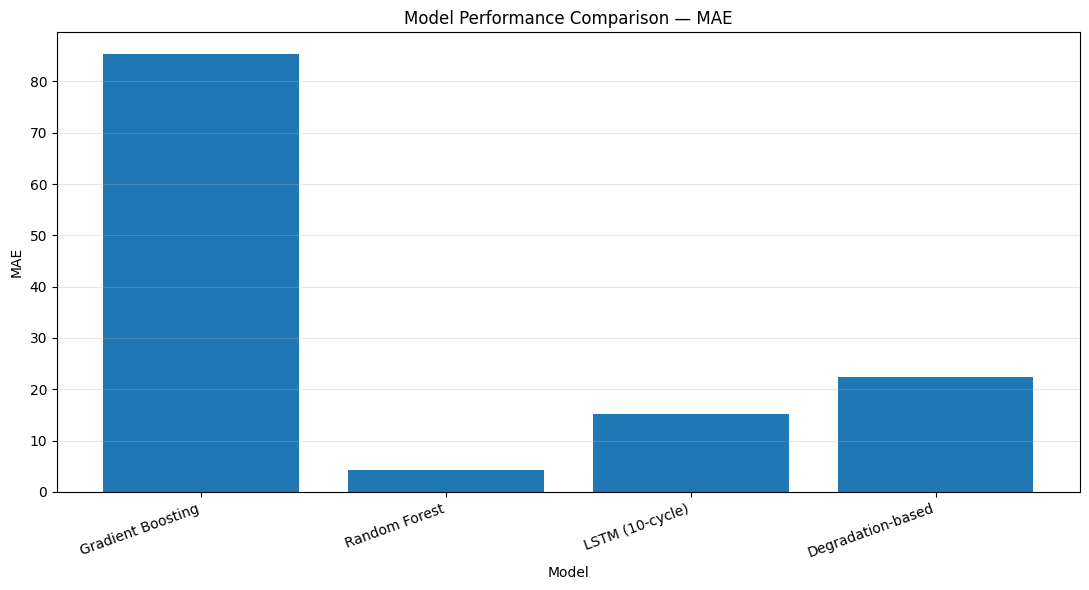

In [262]:
import matplotlib.pyplot as plt

plot_df = model_summary.dropna(subset=['MAE']).copy()

plt.figure(figsize=(11, 6))

plt.bar(
    plot_df['Model'],
    plot_df['MAE']
)

plt.ylabel('MAE')
plt.xlabel('Model')
plt.title('Model Performance Comparison — MAE')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [263]:
dashboard_df = health_df.copy()

# Sort properly
dashboard_df = dashboard_df.sort_values(
    ['Battery_ID', 'Cycle']
).reset_index(drop=True)

# Battery list
battery_list = sorted(
    dashboard_df['Battery_ID'].unique()
)

print("Total batteries:", len(battery_list))
print("Batteries:", battery_list)

print("\nDashboard dataset shape:",
      dashboard_df.shape)

print("\nAvailable columns:")
print(dashboard_df.columns.tolist())

Total batteries: 34
Batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']

Dashboard dataset shape: (2794, 33)

Available columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'Capacity_Retention', 'Capacity_Rolling_Mean', 'Temperature_Rolling_Mean', 'Voltage_Rolling_Mean', 'Discharge_Time_Rolling_Mean', 'Operating_Group', 'Test_Temperature_C', 'Discharge_Current_A', 'Cutoff_Voltage_V', 'EOL_Fade_Percent', 'Previous_Capacity', 'Capacity_Drop', 'Previous_SOH', 'SOH_Drop', 'SOH_Rolling_Mean', 'Isolation_Score', 'Isolation_Anomaly', 'Absolute_Error', 'SOH_Risk', 'Prediction_Error_Risk', 'Isolation_Risk', 'Risk_Score', 'Risk_Level', 'Health_Status']


In [264]:
import ipywidgets as widgets
from IPython.display import display, clear_output

battery_selector = widgets.Dropdown(
    options=battery_list,
    description='Battery:',
    style={'description_width': 'initial'}
)

output = widgets.Output()

def show_battery(change):
    with output:
        clear_output(wait=True)

        battery = change['new']

        data = dashboard_df[
            dashboard_df['Battery_ID'] == battery
        ].sort_values('Cycle')

        latest = data.iloc[-1]

        print(f"Battery: {battery}")
        print(f"Latest Cycle: {int(latest['Cycle'])}")
        print(f"SOH: {latest['SOH']:.2f}%")
        print(f"Risk Score: {latest['Risk_Score']:.2f}")
        print(f"Risk Level: {latest['Risk_Level']}")
        print(f"Health Status: {latest['Health_Status']}")
        print(
            f"Anomaly: "
            f"{'YES' if latest['Isolation_Anomaly'] else 'NO'}"
        )

battery_selector.observe(
    show_battery,
    names='value'
)

display(battery_selector, output)

show_battery({
    'new': battery_selector.value
})

Dropdown(description='Battery:', options=('B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B002…

Output()

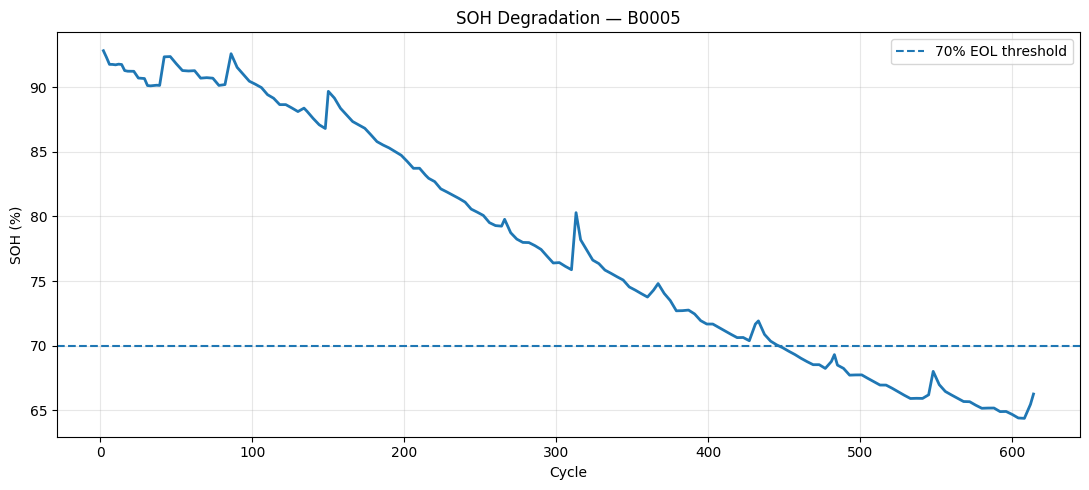

In [265]:
import matplotlib.pyplot as plt

def plot_soh(change=None):

    battery = battery_selector.value

    data = dashboard_df[
        dashboard_df['Battery_ID'] == battery
    ].sort_values('Cycle')

    plt.figure(figsize=(11, 5))

    plt.plot(
        data['Cycle'],
        data['SOH'],
        linewidth=2
    )

    plt.axhline(
        70,
        linestyle='--',
        linewidth=1.5,
        label='70% EOL threshold'
    )

    plt.xlabel('Cycle')
    plt.ylabel('SOH (%)')
    plt.title(f'SOH Degradation — {battery}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


battery_selector.observe(
    plot_soh,
    names='value'
)

plot_soh()

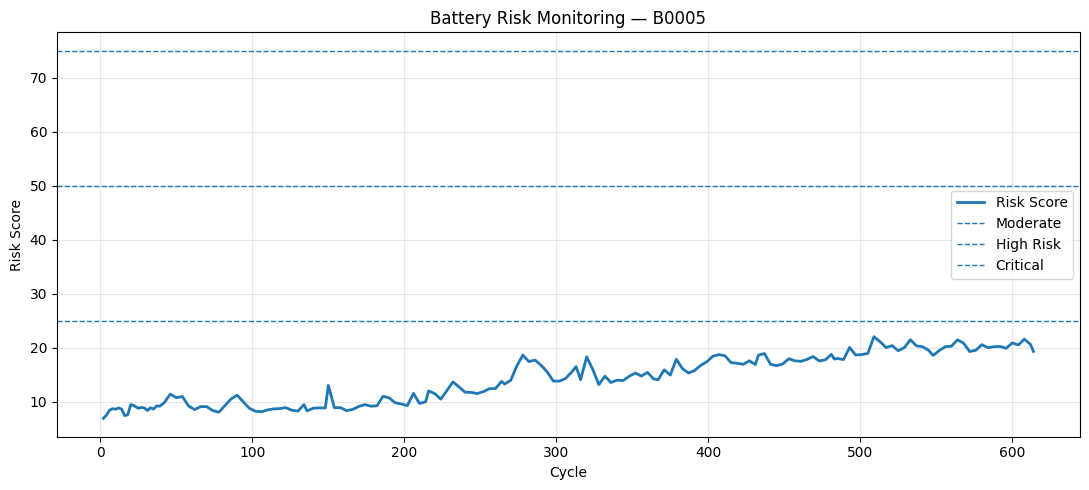

In [266]:
def show_risk(change=None):

    battery = battery_selector.value

    data = dashboard_df[
        dashboard_df['Battery_ID'] == battery
    ].sort_values('Cycle')

    plt.figure(figsize=(11, 5))

    plt.plot(
        data['Cycle'],
        data['Risk_Score'],
        linewidth=2,
        label='Risk Score'
    )

    plt.axhline(
        25,
        linestyle='--',
        linewidth=1,
        label='Moderate'
    )

    plt.axhline(
        50,
        linestyle='--',
        linewidth=1,
        label='High Risk'
    )

    plt.axhline(
        75,
        linestyle='--',
        linewidth=1,
        label='Critical'
    )

    anomaly_data = data[
        data['Isolation_Anomaly'] == True
    ]

    if len(anomaly_data) > 0:
        plt.scatter(
            anomaly_data['Cycle'],
            anomaly_data['Risk_Score'],
            s=35,
            label='Anomaly'
        )

    plt.xlabel('Cycle')
    plt.ylabel('Risk Score')
    plt.title(f'Battery Risk Monitoring — {battery}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


battery_selector.observe(
    show_risk,
    names='value'
)

show_risk()

In [267]:
def final_health_status(row):

    soh = row['SOH']
    risk = row['Risk_Score']

    if soh < 70:
        return 'Critical'

    elif risk >= 75:
        return 'Critical'

    elif risk >= 50:
        return 'High Risk'

    elif risk >= 25:
        return 'Degrading'

    else:
        return 'Healthy'


health_df['Health_Status'] = health_df.apply(
    final_health_status,
    axis=1
)

# Update dashboard data
dashboard_df = health_df.copy()

# Update latest battery snapshot
latest_health = (
    dashboard_df
    .sort_values(['Battery_ID', 'Cycle'])
    .groupby('Battery_ID')
    .tail(1)
    .copy()
)

print(
    latest_health[
        ['Battery_ID', 'Cycle', 'SOH',
         'Risk_Score', 'Health_Status']
    ]
    .sort_values('Risk_Score', ascending=False)
    .to_string(index=False)
)

Battery_ID  Cycle       SOH  Risk_Score Health_Status
     B0040    121 27.849513   79.232966      Critical
     B0052     59  0.000000   74.107376      Critical
     B0050     59  0.000000   73.949247      Critical
     B0054    253  0.000000   71.118512      Critical
     B0053    137  0.000000   70.547313      Critical
     B0045    181 30.347381   69.278129      Critical
     B0041    162 41.824742   52.280788      Critical
     B0049     59 34.569426   47.445974      Critical
     B0051     59 33.892445   44.114156      Critical
     B0056    251 56.452951   36.158559      Critical
     B0038    121 76.507378   35.291404     Degrading
     B0039    121 65.766931   33.324185      Critical
     B0046    181 57.690206   33.224104      Critical
     B0055    251 49.537958   30.744785      Critical
     B0030     94 78.139020   28.713653     Degrading
     B0042    274 66.873459   28.712046      Critical
     B0044    274 62.431273   27.981798      Critical
     B0047    181 57.835438 

In [268]:
dashboard_ranking = (
    latest_health[
        [
            'Battery_ID',
            'Cycle',
            'SOH',
            'Risk_Score',
            'Risk_Level',
            'Health_Status',
            'Isolation_Anomaly'
        ]
    ]
    .sort_values('Risk_Score', ascending=False)
    .reset_index(drop=True)
)

dashboard_ranking.insert(
    0,
    'Rank',
    range(1, len(dashboard_ranking) + 1)
)

display(dashboard_ranking)

,Rank,Battery_ID,Cycle,SOH,Risk_Score,Risk_Level,Health_Status,Isolation_Anomaly
0,1,B0040,121,27.849513,79.232966,Critical,Critical,True
1,2,B0052,59,0.000000,74.107376,High,Critical,True
2,3,B0050,59,0.000000,73.949247,High,Critical,True
3,4,B0054,253,0.000000,71.118512,High,Critical,True
4,5,B0053,137,0.000000,70.547313,High,Critical,True
5,6,B0045,181,30.347381,69.278129,High,Critical,False
6,7,B0041,162,41.824742,52.280788,High,Critical,False
7,8,B0049,59,34.569426,47.445974,Moderate,Critical,False
8,9,B0051,59,33.892445,44.114156,Moderate,Critical,False
9,10,B0056,251,56.452951,36.158559,Moderate,Critical,False


In [269]:
def show_battery_profile(change=None):

    battery = battery_selector.value

    data = dashboard_df[
        dashboard_df['Battery_ID'] == battery
    ]

    latest = data.iloc[-1]

    print(f"Battery Operating Profile — {battery}")
    print("-" * 45)

    print(f"Operating Group       : {latest['Operating_Group']}")
    print(f"Test Temperature     : {latest['Test_Temperature_C']} °C")
    print(f"Discharge Current    : {latest['Discharge_Current_A']} A")
    print(f"Cutoff Voltage       : {latest['Cutoff_Voltage_V']} V")
    print(f"EOL Fade Criterion   : {latest['EOL_Fade_Percent']}")

    print("\nCurrent Condition")
    print("-" * 45)

    print(f"SOH                  : {latest['SOH']:.2f}%")
    print(f"Risk Score           : {latest['Risk_Score']:.2f}")
    print(f"Risk Level           : {latest['Risk_Level']}")
    print(f"Health Status        : {latest['Health_Status']}")
    print(
        f"Isolation Anomaly    : "
        f"{'YES' if latest['Isolation_Anomaly'] else 'NO'}"
    )


battery_selector.observe(
    show_battery_profile,
    names='value'
)

show_battery_profile()

Battery Operating Profile — B0005
---------------------------------------------
Operating Group       : 1
Test Temperature     : 24 °C
Discharge Current    : 2 A
Cutoff Voltage       : 2.7 V
EOL Fade Criterion   : 30.0

Current Condition
---------------------------------------------
SOH                  : 66.25%
Risk Score           : 19.28
Risk Level           : Low
Health Status        : Critical
Isolation Anomaly    : NO


In [270]:
# Reliable RUL batteries only
rul_dashboard = latest_health[
    latest_health['Battery_ID'].isin(
        reliable_rul_batteries['Battery_ID']
    )
].copy()

# Add actual EOL cycle
eol_map = reliable_rul_batteries.set_index(
    'Battery_ID'
)['EOL_Cycle'].to_dict()

rul_dashboard['EOL_Cycle'] = (
    rul_dashboard['Battery_ID'].map(eol_map)
)

# Current remaining cycles from the observed NASA trajectory
rul_dashboard['Actual_RUL'] = (
    rul_dashboard['EOL_Cycle']
    - rul_dashboard['Cycle']
)

print(
    rul_dashboard[
        [
            'Battery_ID',
            'Cycle',
            'SOH',
            'EOL_Cycle',
            'Actual_RUL',
            'Risk_Score',
            'Health_Status'
        ]
    ].to_string(index=False)
)

Battery_ID  Cycle       SOH  EOL_Cycle  Actual_RUL  Risk_Score Health_Status
     B0005    614 66.253966        449        -165   19.283620      Critical
     B0006    614 59.283762        387        -227   24.005486      Critical
     B0018    319 67.052572        237         -82   18.425103      Critical


In [271]:
rul_dashboard = rul_model_df[
    rul_model_df['Battery_ID'].isin(
        reliable_rul_batteries['Battery_ID']
    )
].copy()

eol_map = reliable_rul_batteries.set_index(
    'Battery_ID'
)['EOL_Cycle'].to_dict()

rul_dashboard['EOL_Cycle'] = (
    rul_dashboard['Battery_ID'].map(eol_map)
)

rul_dashboard['Actual_RUL'] = (
    rul_dashboard['EOL_Cycle']
    - rul_dashboard['Cycle']
)

# Keep only valid pre-EOL observations
rul_dashboard = rul_dashboard[
    rul_dashboard['Actual_RUL'] >= 0
].copy()

print(
    rul_dashboard[
        [
            'Battery_ID',
            'Cycle',
            'SOH',
            'EOL_Cycle',
            'Actual_RUL'
        ]
    ].tail(15).to_string(index=False)
)

print("\nValid RUL observations:",
      len(rul_dashboard))

print(
    "\nBatteries:",
    rul_dashboard['Battery_ID'].unique()
)

Battery_ID  Cycle       SOH  EOL_Cycle  Actual_RUL
     B0018    204 71.963564        237          33
     B0018    206 71.432378        237          31
     B0018    209 71.245134        237          28
     B0018    212 73.490577        237          25
     B0018    214 72.629098        237          23
     B0018    216 72.141710        237          21
     B0018    218 71.418803        237          19
     B0018    220 70.772739        237          17
     B0018    223 72.728834        237          14
     B0018    225 71.415898        237          12
     B0018    227 70.985134        237          10
     B0018    229 70.778033        237           8
     B0018    232 70.284002        237           5
     B0018    235 70.422305        237           2
     B0018    237 69.842739        237           0

Valid RUL observations: 328

Batteries: ['B0005' 'B0006' 'B0018']


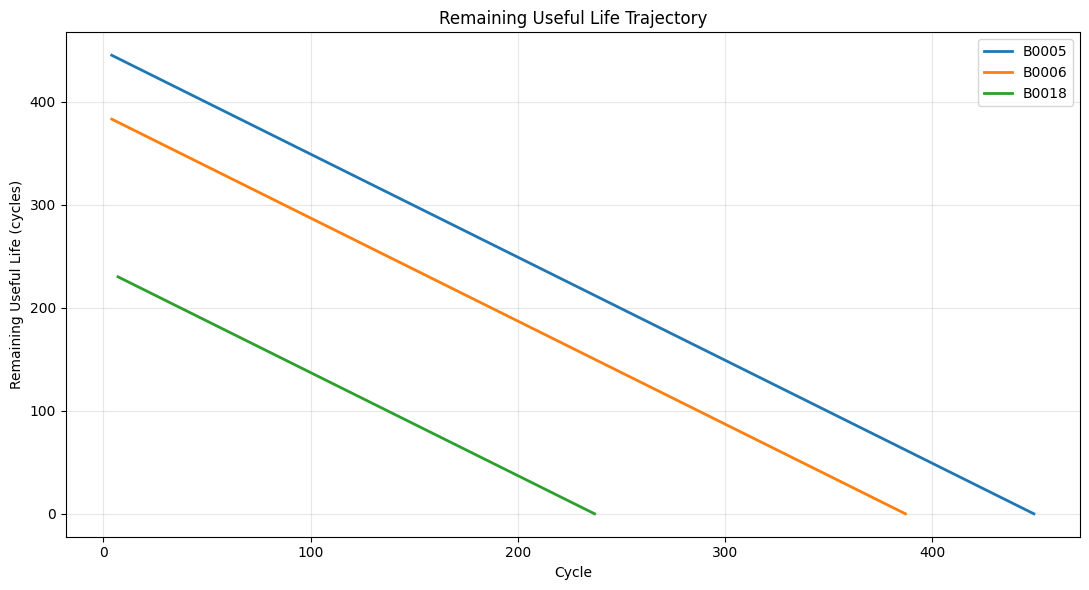

In [272]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

for battery, group in rul_dashboard.groupby('Battery_ID'):
    group = group.sort_values('Cycle')

    plt.plot(
        group['Cycle'],
        group['Actual_RUL'],
        linewidth=2,
        label=battery
    )

plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life (cycles)')
plt.title('Remaining Useful Life Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [273]:
# Final dashboard state

dashboard_state = {}

for battery in battery_list:

    data = dashboard_df[
        dashboard_df['Battery_ID'] == battery
    ].sort_values('Cycle')

    latest = data.iloc[-1]

    dashboard_state[battery] = {
        'Cycle': int(latest['Cycle']),
        'SOH': float(latest['SOH']),
        'Risk_Score': float(latest['Risk_Score']),
        'Risk_Level': latest['Risk_Level'],
        'Health_Status': latest['Health_Status'],
        'Isolation_Anomaly': bool(
            latest['Isolation_Anomaly']
        ),
        'Operating_Group': latest['Operating_Group'],
        'Test_Temperature_C': latest['Test_Temperature_C'],
        'Discharge_Current_A': latest['Discharge_Current_A'],
        'Cutoff_Voltage_V': latest['Cutoff_Voltage_V']
    }

print("Dashboard state created.")
print("Total batteries:", len(dashboard_state))

print("\nExample — B0005:")
print(dashboard_state['B0005'])

Dashboard state created.
Total batteries: 34

Example — B0005:
{'Cycle': 614, 'SOH': 66.25396643214678, 'Risk_Score': 19.283620025027883, 'Risk_Level': 'Low', 'Health_Status': 'Critical', 'Isolation_Anomaly': False, 'Operating_Group': np.int64(1), 'Test_Temperature_C': np.int64(24), 'Discharge_Current_A': np.int64(2), 'Cutoff_Voltage_V': np.float64(2.7)}


In [274]:
from IPython.display import display, HTML

display(HTML("""
<div style="
    background: linear-gradient(135deg, #111827, #1f2937);
    padding: 25px;
    border-radius: 15px;
    color: white;
    font-family: Arial;
    margin-bottom: 20px;
">
    <h1 style="margin:0;">🔋 EV Battery Intelligence Platform</h1>
    <p style="margin-top:8px; color:#d1d5db;">
        AI-Driven Battery Health, Risk & Predictive Maintenance System
    </p>
</div>
"""))

# Current portfolio statistics
total_batteries = len(dashboard_state)

critical_count = sum(
    1 for x in dashboard_state.values()
    if x['Health_Status'] == 'Critical'
)

high_risk_count = sum(
    1 for x in dashboard_state.values()
    if x['Health_Status'] == 'High Risk'
)

degrading_count = sum(
    1 for x in dashboard_state.values()
    if x['Health_Status'] == 'Degrading'
)

healthy_count = sum(
    1 for x in dashboard_state.values()
    if x['Health_Status'] == 'Healthy'
)

display(HTML(f"""
<div style="
    display:flex;
    gap:15px;
    flex-wrap:wrap;
    font-family:Arial;
">

<div style="
    flex:1;
    min-width:170px;
    background:#f3f4f6;
    padding:20px;
    border-radius:12px;
">
    <div style="font-size:13px;">TOTAL BATTERIES</div>
    <div style="font-size:30px;font-weight:bold;">
        {total_batteries}
    </div>
</div>

<div style="
    flex:1;
    min-width:170px;
    background:#f3f4f6;
    padding:20px;
    border-radius:12px;
">
    <div style="font-size:13px;">CRITICAL</div>
    <div style="font-size:30px;font-weight:bold;">
        {critical_count}
    </div>
</div>

<div style="
    flex:1;
    min-width:170px;
    background:#f3f4f6;
    padding:20px;
    border-radius:12px;
">
    <div style="font-size:13px;">HIGH RISK</div>
    <div style="font-size:30px;font-weight:bold;">
        {high_risk_count}
    </div>
</div>

<div style="
    flex:1;
    min-width:170px;
    background:#f3f4f6;
    padding:20px;
    border-radius:12px;
">
    <div style="font-size:13px;">DEGRADING</div>
    <div style="font-size:30px;font-weight:bold;">
        {degrading_count}
    </div>
</div>

<div style="
    flex:1;
    min-width:170px;
    background:#f3f4f6;
    padding:20px;
    border-radius:12px;
">
    <div style="font-size:13px;">HEALTHY</div>
    <div style="font-size:30px;font-weight:bold;">
        {healthy_count}
    </div>
</div>

</div>
"""))

In [275]:
from IPython.display import display, HTML

kpi_output = widgets.Output()

def update_kpi(change=None):

    battery = battery_selector.value
    info = dashboard_state[battery]

    with kpi_output:
        clear_output(wait=True)

        display(HTML(f"""
        <div style="
            display:flex;
            gap:15px;
            flex-wrap:wrap;
            font-family:Arial;
            margin-top:15px;
        ">

        <div style="
            flex:1; min-width:160px;
            padding:18px;
            border-radius:12px;
            background:#f3f4f6;
        ">
            <b>SOH</b>
            <div style="font-size:28px;font-weight:bold;">
                {info['SOH']:.2f}%
            </div>
        </div>

        <div style="
            flex:1; min-width:160px;
            padding:18px;
            border-radius:12px;
            background:#f3f4f6;
        ">
            <b>Risk Score</b>
            <div style="font-size:28px;font-weight:bold;">
                {info['Risk_Score']:.2f}
            </div>
        </div>

        <div style="
            flex:1; min-width:160px;
            padding:18px;
            border-radius:12px;
            background:#f3f4f6;
        ">
            <b>Health Status</b>
            <div style="font-size:24px;font-weight:bold;">
                {info['Health_Status']}
            </div>
        </div>

        <div style="
            flex:1; min-width:160px;
            padding:18px;
            border-radius:12px;
            background:#f3f4f6;
        ">
            <b>Risk Level</b>
            <div style="font-size:24px;font-weight:bold;">
                {info['Risk_Level']}
            </div>
        </div>

        <div style="
            flex:1; min-width:160px;
            padding:18px;
            border-radius:12px;
            background:#f3f4f6;
        ">
            <b>Latest Cycle</b>
            <div style="font-size:28px;font-weight:bold;">
                {info['Cycle']}
            </div>
        </div>

        </div>
        """))

battery_selector.observe(update_kpi, names='value')

display(
    HTML("<h3>🔋 Selected Battery Intelligence</h3>")
)

display(kpi_output)

update_kpi()

Output()

In [276]:
from IPython.display import display, HTML, clear_output

kpi_output = widgets.Output()

def update_kpi(change=None):

    battery = battery_selector.value
    info = dashboard_state[battery]

    with kpi_output:
        clear_output(wait=True)

        display(HTML(f"""
        <div style="
            display:flex;
            gap:15px;
            flex-wrap:wrap;
            font-family:Arial;
            margin-top:15px;
        ">

        <div style="padding:18px; border-radius:12px;
                    background:#f3f4f6; min-width:150px;">
            <b>SOH</b>
            <div style="font-size:28px;font-weight:bold;">
                {info['SOH']:.2f}%
            </div>
        </div>

        <div style="padding:18px; border-radius:12px;
                    background:#f3f4f6; min-width:150px;">
            <b>Risk Score</b>
            <div style="font-size:28px;font-weight:bold;">
                {info['Risk_Score']:.2f}
            </div>
        </div>

        <div style="padding:18px; border-radius:12px;
                    background:#f3f4f6; min-width:150px;">
            <b>Health Status</b>
            <div style="font-size:24px;font-weight:bold;">
                {info['Health_Status']}
            </div>
        </div>

        <div style="padding:18px; border-radius:12px;
                    background:#f3f4f6; min-width:150px;">
            <b>Risk Level</b>
            <div style="font-size:24px;font-weight:bold;">
                {info['Risk_Level']}
            </div>
        </div>

        <div style="padding:18px; border-radius:12px;
                    background:#f3f4f6; min-width:150px;">
            <b>Latest Cycle</b>
            <div style="font-size:28px;font-weight:bold;">
                {info['Cycle']}
            </div>
        </div>

        </div>
        """))

battery_selector.observe(update_kpi, names='value')

display(HTML("<h3>🔋 Select Battery</h3>"))

# IMPORTANT: show the dropdown
display(battery_selector)

display(HTML("<h3>Selected Battery Intelligence</h3>"))

display(kpi_output)

update_kpi()

Dropdown(description='Battery:', options=('B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B002…

Output()

In [277]:
from IPython.display import display, HTML, clear_output

summary_output = widgets.Output()

def update_health_summary(change=None):
    battery = battery_selector.value
    info = dashboard_state[battery]

    with summary_output:
        clear_output(wait=True)

        display(HTML(f"""
        <div style="
            display:grid;
            grid-template-columns:repeat(5, 1fr);
            gap:12px;
            margin:15px 0;
        ">

            <div style="
                padding:18px;
                border-radius:12px;
                background:#f1f5f9;
                text-align:center;
            ">
                <h4>🔋 SOH</h4>
                <h2>{info['SOH']:.2f}%</h2>
            </div>

            <div style="
                padding:18px;
                border-radius:12px;
                background:#f1f5f9;
                text-align:center;
            ">
                <h4>⚠️ Risk Score</h4>
                <h2>{info['Risk_Score']:.2f}</h2>
            </div>

            <div style="
                padding:18px;
                border-radius:12px;
                background:#f1f5f9;
                text-align:center;
            ">
                <h4>🩺 Health</h4>
                <h2>{info['Health_Status']}</h2>
            </div>

            <div style="
                padding:18px;
                border-radius:12px;
                background:#f1f5f9;
                text-align:center;
            ">
                <h4>🚨 Risk Level</h4>
                <h2>{info['Risk_Level']}</h2>
            </div>

            <div style="
                padding:18px;
                border-radius:12px;
                background:#f1f5f9;
                text-align:center;
            ">
                <h4>🔄 Latest Cycle</h4>
                <h2>{info['Cycle']}</h2>
            </div>

        </div>
        """))

battery_selector.observe(update_health_summary, names='value')

display(HTML("<h3>🔋 Battery Health Summary</h3>"))
display(summary_output)

update_health_summary()




Output()

In [278]:
from IPython.display import display, HTML

# Battery dropdown
display(HTML("<h3>🔋 Select Battery</h3>"))
display(battery_selector)

# Health summary area
display(HTML("<h3>📊 Battery Health Summary</h3>"))
display(summary_output)

# Show current battery information
update_health_summary()

Dropdown(description='Battery:', options=('B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B002…

Output()

In [279]:
from IPython.display import display, HTML

rul_output = widgets.Output()

def show_rul_status(change=None):

    battery = battery_selector.value

    with rul_output:
        clear_output(wait=True)

        if battery in reliable_rul_batteries:

            row = reliable_rul_batteries[
                reliable_rul_batteries['Battery_ID'] == battery
            ].iloc[0]

            eol_cycle = int(row['EOL_Cycle'])
            pre_eol = int(row['Pre_EOL_Cycles'])

            display(HTML(f"""
            <div style="
                padding:20px;
                border-radius:15px;
                background:#f8fafc;
                border:1px solid #e2e8f0;
                margin-top:10px;
            ">

                <h3>⏳ RUL Intelligence — {battery}</h3>

                <p><b>RUL Status:</b> Reliable historical RUL available</p>

                <p><b>NASA EOL Threshold:</b> 70% SOH</p>

                <p><b>Observed EOL Cycle:</b> {eol_cycle}</p>

                <p><b>Pre-EOL History:</b> {pre_eol} cycles</p>

                <p>
                <b>Note:</b> RUL is calculated from the observed
                70% SOH end-of-life point.
                </p>

            </div>
            """))

        else:

            display(HTML(f"""
            <div style="
                padding:20px;
                border-radius:15px;
                background:#f8fafc;
                border:1px solid #e2e8f0;
                margin-top:10px;
            ">

                <h3>⏳ RUL Intelligence — {battery}</h3>

                <p><b>RUL Status:</b> Not available for reliable deployment</p>

                <p><b>NASA EOL Threshold:</b> 70% SOH</p>

                <p>
                This battery does not have enough reliable pre-EOL
                history to build a scientifically defensible RUL target.
                </p>

                <p>
                <b>Reason:</b> Insufficient reliable run-to-EOL trajectory.
                </p>

            </div>
            """))

battery_selector.observe(show_rul_status, names='value')

display(HTML("<h3>⏳ Remaining Useful Life Intelligence</h3>"))
display(rul_output)

show_rul_status()

Output()

In [280]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rul_features = [
    'Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'SOH',
    'Previous_SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Temperature_Rolling_Mean',
    'Voltage_Rolling_Mean',
    'Discharge_Time_Rolling_Mean',
    'Test_Temperature_C',
    'Discharge_Current_A',
    'Cutoff_Voltage_V'
]

X_rul = rul_model_df[rul_features]
y_rul = rul_model_df['RUL']
groups_rul = rul_model_df['Battery_ID']

logo = LeaveOneGroupOut()

mae_scores = []
rmse_scores = []
r2_scores = []

for train_idx, test_idx in logo.split(X_rul, y_rul, groups_rul):

    X_train = X_rul.iloc[train_idx]
    X_test = X_rul.iloc[test_idx]

    y_train = y_rul.iloc[train_idx]
    y_test = y_rul.iloc[test_idx]

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae_scores.append(mean_absolute_error(y_test, predictions))
    rmse_scores.append(
        np.sqrt(mean_squared_error(y_test, predictions))
    )
    r2_scores.append(r2_score(y_test, predictions))

print("RUL MODEL PERFORMANCE")
print("---------------------")

print("Average MAE :", np.mean(mae_scores))
print("Average RMSE:", np.mean(rmse_scores))
print("Average R²  :", np.mean(r2_scores))

RUL MODEL PERFORMANCE
---------------------
Average MAE : 85.30240041089023
Average RMSE: 97.98781486384722
Average R²  : -0.3373219586487622


In [281]:
# ==========================================
# NASA BATTERY DATA - DRIVE CHECK
# ==========================================

import os
import glob

RAW_PATH = "/content/drive/MyDrive/EV_Battery_Intelligence/data/raw"

print("==========================================")
print("NASA BATTERY DATA CHECK")
print("==========================================")

print("Raw folder exists:", os.path.exists(RAW_PATH))

if os.path.exists(RAW_PATH):

    mat_files = sorted(
        glob.glob(
            os.path.join(RAW_PATH, "*.mat")
        )
    )

    print("NASA .mat files found:", len(mat_files))

    if len(mat_files) == 34:
        print("✅ All 34 NASA battery files are available.")
    else:
        print(
            "⚠️ Expected 34 files, found:",
            len(mat_files)
        )

    print("\nSample files:")

    for file in mat_files[:5]:
        print(" -", os.path.basename(file))

else:
    print("❌ Raw NASA folder not found.")

print("==========================================")

NASA BATTERY DATA CHECK
Raw folder exists: True
NASA .mat files found: 34
✅ All 34 NASA battery files are available.

Sample files:
 - B0005.mat
 - B0006.mat
 - B0007.mat
 - B0018.mat
 - B0025.mat


In [282]:
import os
import glob

RAW_PATH = "/content/drive/MyDrive/EV_Battery_Intelligence/data/raw"

mat_files = sorted(
    glob.glob(os.path.join(RAW_PATH, "*.mat"))
)

print("NASA .mat files found:", len(mat_files))

print("\nFirst 5 files:")
for file in mat_files[:5]:
    print(os.path.basename(file))

NASA .mat files found: 34

First 5 files:
B0005.mat
B0006.mat
B0007.mat
B0018.mat
B0025.mat


In [283]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = "/content/drive/MyDrive/EV_Battery_Intelligence"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(PROJECT_DIR + "/data", exist_ok=True)
os.makedirs(PROJECT_DIR + "/models", exist_ok=True)
os.makedirs(PROJECT_DIR + "/results", exist_ok=True)
os.makedirs(PROJECT_DIR + "/dashboard", exist_ok=True)

print("✅ Google Drive connected")
print("✅ EV Battery Intelligence project folder created")
print(PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive connected
✅ EV Battery Intelligence project folder created
/content/drive/MyDrive/EV_Battery_Intelligence


In [284]:
import os
import glob

RAW_PATH = "/content/drive/MyDrive/EV_Battery_Intelligence/data/raw"

mat_files = glob.glob(os.path.join(RAW_PATH, "*.mat"))

print("==========================================")
print("PERMANENT NASA DATA CHECK")
print("==========================================")
print("Raw folder exists:", os.path.exists(RAW_PATH))
print("NASA .mat files:", len(mat_files))

if len(mat_files) == 34:
    print("✅ All 34 NASA battery files are safely stored in Drive.")
else:
    print("⚠️ Expected 34 files, found:", len(mat_files))

PERMANENT NASA DATA CHECK
Raw folder exists: True
NASA .mat files: 34
✅ All 34 NASA battery files are safely stored in Drive.


In [285]:
import zipfile
import os

drive_zip = "/content/drive/MyDrive/EV_Battery_Intelligence/data/NASA_Battery_Dataset.zip"
batch1_dir = "/content/drive/MyDrive/EV_Battery_Intelligence/data/batch1"

os.makedirs(batch1_dir, exist_ok=True)

with zipfile.ZipFile(drive_zip, "r") as outer:
    inner_zip_name = "5. Battery Data Set/1. BatteryAgingARC-FY08Q4.zip"
    inner_zip_data = outer.read(inner_zip_name)

temp_inner_zip = "/content/batch1.zip"

with open(temp_inner_zip, "wb") as f:
    f.write(inner_zip_data)

with zipfile.ZipFile(temp_inner_zip, "r") as batch1:
    batch1.extractall(batch1_dir)

print("✅ Batch 1 permanently extracted to Google Drive")
print("📁", batch1_dir)
print("📄 Files:", os.listdir(batch1_dir))

✅ Batch 1 permanently extracted to Google Drive
📁 /content/drive/MyDrive/EV_Battery_Intelligence/data/batch1
📄 Files: ['B0007.mat', 'B0005.mat', 'B0006.mat', 'README.txt', 'B0018.mat']


In [286]:
import os

drive_zip = "/content/drive/MyDrive/EV_Battery_Intelligence/data/NASA_Battery_Dataset.zip"

print("File exists:", os.path.exists(drive_zip))
print("File size:", os.path.getsize(drive_zip), "bytes")

File exists: True
File size: 209708670 bytes


In [287]:
import zipfile

drive_zip = "/content/drive/MyDrive/EV_Battery_Intelligence/data/NASA_Battery_Dataset.zip"

print("ZIP valid:", zipfile.is_zipfile(drive_zip))

ZIP valid: True


In [288]:
import os
import zipfile

original_zip = "/content/5.+Battery+Data+Set.zip"

print("Original ZIP exists:", os.path.exists(original_zip))

if os.path.exists(original_zip):
    print("Original ZIP size:",
          os.path.getsize(original_zip), "bytes")

    print("Original ZIP valid:",
          zipfile.is_zipfile(original_zip))

Original ZIP exists: False


In [289]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/EV_Battery_Intelligence/data/NASA_Battery_Dataset.zip"
extract_path = "/content/drive/MyDrive/EV_Battery_Intelligence/data/raw"

os.makedirs(extract_path, exist_ok=True)

print("Extracting NASA battery dataset...")

with zipfile.ZipFile(zip_path, "r") as outer_zip:

    inner_zips = [
        f for f in outer_zip.namelist()
        if f.lower().endswith(".zip")
    ]

    for i, inner_zip_name in enumerate(inner_zips, 1):

        print(f"\nProcessing batch {i}/6...")

        # Read inner ZIP directly from outer ZIP
        inner_data = outer_zip.read(inner_zip_name)

        import io

        with zipfile.ZipFile(io.BytesIO(inner_data), "r") as inner_zip:

            for file_name in inner_zip.namelist():

                if file_name.lower().endswith(".mat"):

                    # Keep only the actual .mat filename
                    battery_name = os.path.basename(file_name)

                    output_file = os.path.join(
                        extract_path,
                        battery_name
                    )

                    with inner_zip.open(file_name) as source:
                        with open(output_file, "wb") as target:
                            target.write(source.read())

                    print("  ✓", battery_name)

print("\n" + "="*50)
print("✅ EXTRACTION COMPLETE")
print("="*50)

mat_files = sorted([
    f for f in os.listdir(extract_path)
    if f.lower().endswith(".mat")
])

print("Total .mat battery files:", len(mat_files))
print("Saved in:", extract_path)

Extracting NASA battery dataset...

Processing batch 1/6...
  ✓ B0007.mat
  ✓ B0018.mat
  ✓ B0005.mat
  ✓ B0006.mat

Processing batch 2/6...
  ✓ B0028.mat
  ✓ B0025.mat
  ✓ B0026.mat
  ✓ B0027.mat

Processing batch 3/6...
  ✓ B0025.mat
  ✓ B0026.mat
  ✓ B0027.mat
  ✓ B0028.mat
  ✓ B0029.mat
  ✓ B0030.mat
  ✓ B0031.mat
  ✓ B0032.mat
  ✓ B0033.mat
  ✓ B0034.mat
  ✓ B0036.mat
  ✓ B0038.mat
  ✓ B0039.mat
  ✓ B0040.mat
  ✓ B0041.mat
  ✓ B0042.mat
  ✓ B0043.mat
  ✓ B0044.mat

Processing batch 4/6...
  ✓ B0045.mat
  ✓ B0046.mat
  ✓ B0047.mat
  ✓ B0048.mat

Processing batch 5/6...
  ✓ B0049.mat
  ✓ B0050.mat
  ✓ B0051.mat
  ✓ B0052.mat

Processing batch 6/6...
  ✓ B0053.mat
  ✓ B0054.mat
  ✓ B0055.mat
  ✓ B0056.mat

✅ EXTRACTION COMPLETE
Total .mat battery files: 34
Saved in: /content/drive/MyDrive/EV_Battery_Intelligence/data/raw


In [290]:
import os
import scipy.io as sio
import pandas as pd
import numpy as np

RAW_PATH = "/content/drive/MyDrive/EV_Battery_Intelligence/data/raw"

battery_files = sorted([
    f for f in os.listdir(RAW_PATH)
    if f.endswith(".mat")
])

print("Total battery files:", len(battery_files))
print("First few files:", battery_files[:5])

Total battery files: 34
First few files: ['B0005.mat', 'B0006.mat', 'B0007.mat', 'B0018.mat', 'B0025.mat']


In [291]:
import os
import scipy.io as sio
import pandas as pd
import numpy as np

RAW_PATH = "/content/drive/MyDrive/EV_Battery_Intelligence/data/raw"

all_rows = []

for file_name in battery_files:

    battery_id = file_name.replace(".mat", "")
    file_path = os.path.join(RAW_PATH, file_name)

    mat = sio.loadmat(file_path)
    battery_data = mat[battery_id][0, 0]

    cycles = battery_data["cycle"][0]

    for cycle_index, cycle in enumerate(cycles, start=1):

        cycle_type = str(cycle["type"][0])

        # Only discharge cycles
        if cycle_type != "discharge":
            continue

        data = cycle["data"][0, 0]

        voltage = np.asarray(
            data["Voltage_measured"]
        ).flatten()

        current = np.asarray(
            data["Current_measured"]
        ).flatten()

        temperature = np.asarray(
            data["Temperature_measured"]
        ).flatten()

        time_data = np.asarray(
            data["Time"]
        ).flatten()

        # Skip if basic measurement data is missing
        if (
            len(voltage) == 0
            or len(current) == 0
            or len(temperature) == 0
            or len(time_data) == 0
        ):
            continue

        # Capacity can be empty in some NASA cycles
        capacity_data = np.asarray(
            data["Capacity"]
        ).flatten()

        if len(capacity_data) > 0:
            capacity = float(capacity_data[0])
        else:
            capacity = 0.0

        all_rows.append({
            "Battery_ID": battery_id,
            "Cycle": cycle_index,
            "Avg_Voltage": np.mean(voltage),
            "Avg_Current": np.mean(current),
            "Max_Temperature": np.max(temperature),
            "Min_Voltage": np.min(voltage),
            "Discharge_Time": time_data[-1],
            "Capacity": capacity
        })

master_df = pd.DataFrame(all_rows)

master_df = master_df.sort_values(
    ["Battery_ID", "Cycle"]
).reset_index(drop=True)

print("=" * 55)
print("✅ MASTER DATASET CREATED SUCCESSFULLY")
print("=" * 55)

print("Number of batteries :", master_df["Battery_ID"].nunique())
print("Number of cycles    :", len(master_df))
print("Shape               :", master_df.shape)

print("\nColumns:")
print(master_df.columns.tolist())

print("\nMissing values:")
print(master_df.isnull().sum())

print("\nFirst 5 rows:")
display(master_df.head())

✅ MASTER DATASET CREATED SUCCESSFULLY
Number of batteries : 34
Number of cycles    : 2794
Shape               : (2794, 8)

Columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity']

Missing values:
Battery_ID         0
Cycle              0
Avg_Voltage        0
Avg_Current        0
Max_Temperature    0
Min_Voltage        0
Discharge_Time     0
Capacity           0
dtype: int64

First 5 rows:


,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity
0,B0005,2,3.529829,-1.818702,38.982181,2.612467,3690.234,1.856487
1,B0005,4,3.537320,-1.817560,39.033398,2.587209,3672.344,1.846327
2,B0005,6,3.543737,-1.816487,38.818797,2.651917,3651.641,1.835349
3,B0005,8,3.543666,-1.825589,38.762305,2.592948,3631.563,1.835263
4,B0005,10,3.542343,-1.826114,38.665393,2.547420,3629.172,1.834646


In [292]:
print("Total rows:", len(master_df))
print("Total batteries:", master_df["Battery_ID"].nunique())

print("\nRows per battery:")
print(master_df.groupby("Battery_ID").size())

print("\nCycle range per battery:")
print(
    master_df.groupby("Battery_ID")["Cycle"]
    .agg(["min", "max", "count"])
)

Total rows: 2794
Total batteries: 34

Rows per battery:
Battery_ID
B0005    168
B0006    168
B0007    168
B0018    132
B0025     28
B0026     28
B0027     28
B0028     28
B0029     40
B0030     40
B0031     40
B0032     40
B0033    197
B0034    197
B0036    197
B0038     47
B0039     47
B0040     47
B0041     67
B0042    112
B0043    112
B0044    112
B0045     72
B0046     72
B0047     72
B0048     72
B0049     25
B0050     25
B0051     25
B0052     25
B0053     56
B0054    103
B0055    102
B0056    102
dtype: int64

Cycle range per battery:
            min  max  count
Battery_ID                 
B0005         2  614    168
B0006         2  614    168
B0007         2  614    168
B0018         3  319    132
B0025         4   78     28
B0026         4   78     28
B0027         4   78     28
B0028         4   78     28
B0029         2   94     40
B0030         2   94     40
B0031         2   94     40
B0032         2   94     40
B0033         1  483    197
B0034         1  483    197
B003

In [293]:
RATED_CAPACITY = 2.0

master_df["SOH"] = (
    master_df["Capacity"] / RATED_CAPACITY
) * 100

print("SOH created successfully!")

print("\nSOH statistics:")
print(master_df["SOH"].describe())

display(
    master_df[
        ["Battery_ID", "Cycle", "Capacity", "SOH"]
    ].head(10)
)

SOH created successfully!

SOH statistics:
count    2794.000000
mean       65.733684
std        24.335350
min         0.000000
25%        56.929505
50%        71.162810
75%        83.594084
max       132.007456
Name: SOH, dtype: float64


,Battery_ID,Cycle,Capacity,SOH
0,B0005,2,1.856487,92.824371
1,B0005,4,1.846327,92.316362
2,B0005,6,1.835349,91.767460
3,B0005,8,1.835263,91.763126
4,B0005,10,1.834646,91.732275
5,B0005,12,1.835662,91.783083
6,B0005,14,1.835146,91.757307
7,B0005,16,1.825757,91.287840
8,B0005,18,1.824774,91.238693
9,B0005,20,1.824613,91.230663


In [294]:
SAVE_PATH = "/content/drive/MyDrive/EV_Battery_Intelligence/data/master_dataset.csv"

master_df.to_csv(SAVE_PATH, index=False)

print("✅ Master dataset saved permanently!")
print(SAVE_PATH)

✅ Master dataset saved permanently!
/content/drive/MyDrive/EV_Battery_Intelligence/data/master_dataset.csv


In [295]:
print("===== SOH DATA QUALITY CHECK =====")

print("\nSOH > 100% :", (master_df["SOH"] > 100).sum())
print("SOH <= 0%  :", (master_df["SOH"] <= 0).sum())

print("\nCapacity statistics:")
print(master_df["Capacity"].describe())

print("\nTop SOH values:")
display(
    master_df[
        ["Battery_ID", "Cycle", "Capacity", "SOH"]
    ]
    .sort_values("SOH", ascending=False)
    .head(15)
)

print("\nLowest SOH values:")
display(
    master_df[
        ["Battery_ID", "Cycle", "Capacity", "SOH"]
    ]
    .sort_values("SOH")
    .head(15)
)

===== SOH DATA QUALITY CHECK =====

SOH > 100% : 11
SOH <= 0%  : 44

Capacity statistics:
count    2794.000000
mean        1.314674
std         0.486707
min         0.000000
25%         1.138590
50%         1.423256
75%         1.671882
max         2.640149
Name: Capacity, dtype: float64

Top SOH values:


,Battery_ID,Cycle,Capacity,SOH
2361,B0050,15,2.640149,132.007456
1415,B0036,279,2.444062,122.203122
2335,B0049,11,2.378644,118.932187
2385,B0051,11,2.330873,116.543674
168,B0006,2,2.035338,101.766880
169,B0006,4,2.025140,101.257012
173,B0006,12,2.013899,100.694954
170,B0006,6,2.013326,100.666319
171,B0006,8,2.013285,100.664233
174,B0006,14,2.013101,100.655055



Lowest SOH values:


,Battery_ID,Cycle,Capacity,SOH
2134,B0046,51,0.0,0.0
2206,B0047,51,0.0,0.0
2418,B0052,31,0.0,0.0
2421,B0052,39,0.0,0.0
2423,B0052,43,0.0,0.0
2422,B0052,41,0.0,0.0
2424,B0052,45,0.0,0.0
2425,B0052,47,0.0,0.0
2426,B0052,51,0.0,0.0
1824,B0043,15,0.0,0.0


In [296]:
quality_summary = (
    master_df.assign(
        SOH_Above_100=master_df["SOH"] > 100,
        SOH_Zero_or_Less=master_df["SOH"] <= 0
    )
    .groupby("Battery_ID")
    .agg(
        Total_Cycles=("SOH", "size"),
        SOH_Above_100=("SOH_Above_100", "sum"),
        SOH_Zero_or_Less=("SOH_Zero_or_Less", "sum"),
        Min_SOH=("SOH", "min"),
        Max_SOH=("SOH", "max")
    )
)

display(
    quality_summary.sort_values(
        ["SOH_Zero_or_Less", "SOH_Above_100"],
        ascending=False
    )
)

,Total_Cycles,SOH_Above_100,SOH_Zero_or_Less,Min_SOH,Max_SOH
Battery_ID,,,,,
B0052,25,0,21,0.000000,70.915476
B0050,25,1,5,0.000000,132.007456
B0046,72,0,3,0.000000,86.411962
B0047,72,0,3,0.000000,83.715237
B0048,72,0,3,0.000000,82.899779
B0045,72,0,2,0.000000,54.098969
B0049,25,1,1,0.000000,118.932187
B0051,25,1,1,0.000000,116.543674
B0042,112,0,1,0.000000,86.573531


In [297]:
# Keep the original NASA dataset untouched
model_df = master_df.copy()

# Quality flags
model_df["Invalid_Capacity"] = model_df["Capacity"] <= 0
model_df["Suspicious_High_SOH"] = model_df["SOH"] > 100

# Model-ready validity flag
model_df["Valid_For_SOH_Model"] = (
    (model_df["Capacity"] > 0) &
    (model_df["SOH"] <= 100)
)

print("Original rows :", len(master_df))
print("Model rows    :", len(model_df))

print("\nInvalid capacity rows:",
      model_df["Invalid_Capacity"].sum())

print("Suspicious high-SOH rows:",
      model_df["Suspicious_High_SOH"].sum())

print("Valid SOH rows:",
      model_df["Valid_For_SOH_Model"].sum())

print("\nModel dataframe shape:", model_df.shape)

display(
    model_df[
        [
            "Battery_ID",
            "Cycle",
            "Capacity",
            "SOH",
            "Invalid_Capacity",
            "Suspicious_High_SOH",
            "Valid_For_SOH_Model"
        ]
    ].head(10)
)

Original rows : 2794
Model rows    : 2794

Invalid capacity rows: 44
Suspicious high-SOH rows: 11
Valid SOH rows: 2739

Model dataframe shape: (2794, 12)


,Battery_ID,Cycle,Capacity,SOH,Invalid_Capacity,Suspicious_High_SOH,Valid_For_SOH_Model
0,B0005,2,1.856487,92.824371,False,False,True
1,B0005,4,1.846327,92.316362,False,False,True
2,B0005,6,1.835349,91.767460,False,False,True
3,B0005,8,1.835263,91.763126,False,False,True
4,B0005,10,1.834646,91.732275,False,False,True
5,B0005,12,1.835662,91.783083,False,False,True
6,B0005,14,1.835146,91.757307,False,False,True
7,B0005,16,1.825757,91.287840,False,False,True
8,B0005,18,1.824774,91.238693,False,False,True
9,B0005,20,1.824613,91.230663,False,False,True


In [298]:
condition_map = {
    "B0005": [1, 24, 2, 2.7, 30],
    "B0006": [1, 24, 2, 2.5, 30],
    "B0007": [1, 24, 2, 2.2, 30],
    "B0018": [1, 24, 2, 2.5, 30],

    "B0025": [2, 24, 4, 2.0, 30],
    "B0026": [2, 24, 4, 2.2, 30],
    "B0027": [2, 24, 4, 2.5, 30],
    "B0028": [2, 24, 4, 2.7, 30],

    "B0029": [3, 43, 4, 2.0, 30],
    "B0030": [3, 43, 4, 2.2, 30],
    "B0031": [3, 43, 4, 2.5, 30],
    "B0032": [3, 43, 4, 2.7, 30],

    "B0033": [4, 24, 4, 2.0, 20],
    "B0034": [4, 24, 4, 2.2, 20],
    "B0036": [4, 24, 2, 2.7, 20],

    "B0038": [5, 24, 1, 2.2, 20],
    "B0039": [5, 24, 2, 2.5, 20],
    "B0040": [5, 44, 4, 2.7, 20],

    "B0041": [6, 4, 4, 2.0, 30],
    "B0042": [6, 4, 4, 2.2, 30],
    "B0043": [6, 4, 1, 2.5, 30],
    "B0044": [6, 4, 1, 2.7, 30],

    "B0045": [7, 4, 1, 2.0, 30],
    "B0046": [7, 4, 1, 2.2, 30],
    "B0047": [7, 4, 1, 2.5, 30],
    "B0048": [7, 4, 1, 2.7, 30],

    "B0049": [8, 4, 2, 2.0, None],
    "B0050": [8, 4, 2, 2.2, None],
    "B0051": [8, 4, 2, 2.5, None],
    "B0052": [8, 4, 2, 2.7, None],

    "B0053": [9, 4, 2, 2.0, 30],
    "B0054": [9, 4, 2, 2.2, 30],
    "B0055": [9, 4, 2, 2.5, 30],
    "B0056": [9, 4, 2, 2.7, 30]
}

condition_columns = [
    "Operating_Group",
    "Test_Temperature_C",
    "Discharge_Current_A",
    "Cutoff_Voltage_V",
    "EOL_Fade_Percent"
]

condition_df = pd.DataFrame.from_dict(
    condition_map,
    orient="index",
    columns=condition_columns
)

condition_df.index.name = "Battery_ID"
condition_df = condition_df.reset_index()

model_df = model_df.merge(
    condition_df,
    on="Battery_ID",
    how="left"
)

print("✅ Condition metadata added")

print("Shape:", model_df.shape)

display(
    model_df[
        [
            "Battery_ID",
            "Operating_Group",
            "Test_Temperature_C",
            "Discharge_Current_A",
            "Cutoff_Voltage_V",
            "EOL_Fade_Percent"
        ]
    ].drop_duplicates().head(15)
)

✅ Condition metadata added
Shape: (2794, 17)


,Battery_ID,Operating_Group,Test_Temperature_C,Discharge_Current_A,Cutoff_Voltage_V,EOL_Fade_Percent
0,B0005,1,24,2,2.7,30.0
168,B0006,1,24,2,2.5,30.0
336,B0007,1,24,2,2.2,30.0
504,B0018,1,24,2,2.5,30.0
636,B0025,2,24,4,2.0,30.0
664,B0026,2,24,4,2.2,30.0
692,B0027,2,24,4,2.5,30.0
720,B0028,2,24,4,2.7,30.0
748,B0029,3,43,4,2.0,30.0
788,B0030,3,43,4,2.2,30.0


In [299]:
model_df = model_df.sort_values(
    ["Battery_ID", "Cycle"]
).copy()

# Previous-cycle information
model_df["Previous_Capacity"] = (
    model_df.groupby("Battery_ID")["Capacity"]
    .shift(1)
)

model_df["Capacity_Drop"] = (
    model_df["Previous_Capacity"] - model_df["Capacity"]
)

model_df["Previous_SOH"] = (
    model_df.groupby("Battery_ID")["SOH"]
    .shift(1)
)

model_df["SOH_Drop"] = (
    model_df["Previous_SOH"] - model_df["SOH"]
)

# Recent degradation history
model_df["SOH_Rolling_Mean"] = (
    model_df.groupby("Battery_ID")["SOH"]
    .transform(
        lambda x: x.shift(1).rolling(
            5, min_periods=1
        ).mean()
    )
)

model_df["Temperature_Rolling_Mean"] = (
    model_df.groupby("Battery_ID")["Max_Temperature"]
    .transform(
        lambda x: x.shift(1).rolling(
            5, min_periods=1
        ).mean()
    )
)

model_df["Voltage_Rolling_Mean"] = (
    model_df.groupby("Battery_ID")["Min_Voltage"]
    .transform(
        lambda x: x.shift(1).rolling(
            5, min_periods=1
        ).mean()
    )
)

model_df["Discharge_Time_Rolling_Mean"] = (
    model_df.groupby("Battery_ID")["Discharge_Time"]
    .transform(
        lambda x: x.shift(1).rolling(
            5, min_periods=1
        ).mean()
    )
)

print("✅ Degradation-history features created")

print("Shape:", model_df.shape)

display(
    model_df[
        [
            "Battery_ID",
            "Cycle",
            "SOH",
            "Previous_SOH",
            "SOH_Drop",
            "SOH_Rolling_Mean",
            "Temperature_Rolling_Mean"
        ]
    ].head(10)
)

✅ Degradation-history features created
Shape: (2794, 25)


,Battery_ID,Cycle,SOH,Previous_SOH,SOH_Drop,SOH_Rolling_Mean,Temperature_Rolling_Mean
0,B0005,2,92.824371,NaN,NaN,NaN,NaN
1,B0005,4,92.316362,92.824371,0.508009,92.824371,38.982181
2,B0005,6,91.767460,92.316362,0.548903,92.570367,39.007790
3,B0005,8,91.763126,91.767460,0.004333,92.302731,38.944792
4,B0005,10,91.732275,91.763126,0.030851,92.167830,38.899170
5,B0005,12,91.783083,91.732275,-0.050808,92.080719,38.852415
6,B0005,14,91.757307,91.783083,0.025776,91.872461,38.806317
7,B0005,16,91.287840,91.757307,0.469468,91.760650,38.763778
8,B0005,18,91.238693,91.287840,0.049147,91.664726,38.703445
9,B0005,20,91.230663,91.238693,0.008029,91.559840,38.656237


In [300]:
# ==============================
# CLEAN PROJECT RESTART POINT
# ==============================

import pandas as pd
import numpy as np

MASTER_PATH = "/content/drive/MyDrive/EV_Battery_Intelligence/data/master_dataset.csv"

master_df = pd.read_csv(MASTER_PATH)

print("Master dataset loaded successfully!")
print("Shape:", master_df.shape)
print("Columns:")
print(master_df.columns.tolist())

Master dataset loaded successfully!
Shape: (2794, 9)
Columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH']


In [301]:
# ==============================
# CLEAN MODEL DATASET
# ==============================

model_df = master_df.copy()

# Invalid / suspicious data flags
model_df["Invalid_Capacity"] = model_df["Capacity"] <= 0
model_df["Suspicious_High_SOH"] = model_df["SOH"] > 100

# Valid rows for SOH modelling
model_df["Valid_For_SOH_Model"] = (
    (model_df["Capacity"] > 0) &
    (model_df["SOH"] <= 100)
)

# Sort battery-wise and cycle-wise
model_df = model_df.sort_values(
    ["Battery_ID", "Cycle"]
).reset_index(drop=True)

print("Model dataset created successfully!")
print("Shape:", model_df.shape)
print("Valid SOH rows:", model_df["Valid_For_SOH_Model"].sum())
print("Invalid capacity rows:", model_df["Invalid_Capacity"].sum())
print("High SOH rows:", model_df["Suspicious_High_SOH"].sum())

Model dataset created successfully!
Shape: (2794, 12)
Valid SOH rows: 2739
Invalid capacity rows: 44
High SOH rows: 11


In [302]:
# ==============================
# DEGRADATION HISTORY FEATURES
# ==============================

model_df["Previous_Capacity"] = (
    model_df.groupby("Battery_ID")["Capacity"].shift(1)
)

model_df["Capacity_Drop"] = (
    model_df["Previous_Capacity"] - model_df["Capacity"]
)

model_df["Previous_SOH"] = (
    model_df.groupby("Battery_ID")["SOH"].shift(1)
)

model_df["SOH_Drop"] = (
    model_df["Previous_SOH"] - model_df["SOH"]
)

# Previous 5-cycle averages
model_df["SOH_Rolling_Mean"] = (
    model_df.groupby("Battery_ID")["SOH"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

model_df["Temperature_Rolling_Mean"] = (
    model_df.groupby("Battery_ID")["Max_Temperature"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

model_df["Voltage_Rolling_Mean"] = (
    model_df.groupby("Battery_ID")["Min_Voltage"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

model_df["Discharge_Time_Rolling_Mean"] = (
    model_df.groupby("Battery_ID")["Discharge_Time"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

print("Degradation history features created successfully!")
print("Shape:", model_df.shape)

print("\nNew features:")
print([
    "Previous_Capacity",
    "Capacity_Drop",
    "Previous_SOH",
    "SOH_Drop",
    "SOH_Rolling_Mean",
    "Temperature_Rolling_Mean",
    "Voltage_Rolling_Mean",
    "Discharge_Time_Rolling_Mean"
])

Degradation history features created successfully!
Shape: (2794, 20)

New features:
['Previous_Capacity', 'Capacity_Drop', 'Previous_SOH', 'SOH_Drop', 'SOH_Rolling_Mean', 'Temperature_Rolling_Mean', 'Voltage_Rolling_Mean', 'Discharge_Time_Rolling_Mean']


In [303]:
# ==============================
# NASA OPERATING CONDITIONS
# ==============================

condition_map = {
    "B0005": [1, 24, 2, 2.7, 30],
    "B0006": [1, 24, 2, 2.5, 30],
    "B0007": [1, 24, 2, 2.2, 30],
    "B0018": [1, 24, 2, 2.5, 30],

    "B0025": [2, 24, 4, 2.0, 30],
    "B0026": [2, 24, 4, 2.2, 30],
    "B0027": [2, 24, 4, 2.5, 30],
    "B0028": [2, 24, 4, 2.7, 30],

    "B0029": [3, 43, 4, 2.0, 30],
    "B0030": [3, 43, 4, 2.2, 30],
    "B0031": [3, 43, 4, 2.5, 30],
    "B0032": [3, 43, 4, 2.7, 30],

    "B0033": [4, 24, 4, 2.0, 20],
    "B0034": [4, 24, 4, 2.2, 20],
    "B0036": [4, 24, 2, 2.7, 20],

    "B0038": [5, 24, 1, 2.2, 20],
    "B0039": [5, 24, 2, 2.5, 20],
    "B0040": [5, 44, 4, 2.7, 20],

    "B0041": [6, 4, 4, 2.0, 30],
    "B0042": [6, 4, 4, 2.2, 30],
    "B0043": [6, 4, 1, 2.5, 30],
    "B0044": [6, 4, 1, 2.7, 30],

    "B0045": [7, 4, 1, 2.0, 30],
    "B0046": [7, 4, 1, 2.2, 30],
    "B0047": [7, 4, 1, 2.5, 30],
    "B0048": [7, 4, 1, 2.7, 30],

    "B0049": [8, 4, 2, 2.0, None],
    "B0050": [8, 4, 2, 2.2, None],
    "B0051": [8, 4, 2, 2.5, None],
    "B0052": [8, 4, 2, 2.7, None],

    "B0053": [9, 4, 2, 2.0, 30],
    "B0054": [9, 4, 2, 2.2, 30],
    "B0055": [9, 4, 2, 2.5, 30],
    "B0056": [9, 4, 2, 2.7, 30]
}

model_df["Operating_Group"] = model_df["Battery_ID"].map(
    lambda x: condition_map[x][0]
)

model_df["Test_Temperature_C"] = model_df["Battery_ID"].map(
    lambda x: condition_map[x][1]
)

model_df["Discharge_Current_A"] = model_df["Battery_ID"].map(
    lambda x: condition_map[x][2]
)

model_df["Cutoff_Voltage_V"] = model_df["Battery_ID"].map(
    lambda x: condition_map[x][3]
)

model_df["EOL_Fade_Percent"] = model_df["Battery_ID"].map(
    lambda x: condition_map[x][4]
)

print("Operating conditions added successfully!")
print("Shape:", model_df.shape)

print("\nMissing values:")
print(
    model_df[
        [
            "Operating_Group",
            "Test_Temperature_C",
            "Discharge_Current_A",
            "Cutoff_Voltage_V"
        ]
    ].isna().sum()
)

Operating conditions added successfully!
Shape: (2794, 25)

Missing values:
Operating_Group        0
Test_Temperature_C     0
Discharge_Current_A    0
Cutoff_Voltage_V       0
dtype: int64


In [304]:
# ==============================
# FINAL SOH MODEL DATA
# ==============================

soh_df = model_df[
    model_df["Valid_For_SOH_Model"]
].copy()

soh_features = [
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time",
    "Test_Temperature_C",
    "Discharge_Current_A",
    "Cutoff_Voltage_V",
    "Previous_SOH",
    "SOH_Drop",
    "SOH_Rolling_Mean",
    "Temperature_Rolling_Mean",
    "Voltage_Rolling_Mean",
    "Discharge_Time_Rolling_Mean"
]

X = soh_df[soh_features].copy()
y = soh_df["SOH"].copy()

print("SOH modelling dataset ready!")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:")
print(X.isna().sum().sum())

print("\nNumber of features:", len(soh_features))

SOH modelling dataset ready!
X shape: (2739, 14)
y shape: (2739,)

Missing values in X:
198

Number of features: 14


In [305]:
# ==============================
# BATTERY-WISE TRAIN / TEST SPLIT
# ==============================

from sklearn.model_selection import GroupShuffleSplit

groups = soh_df["Battery_ID"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_batteries = soh_df.iloc[train_idx]["Battery_ID"].unique()
test_batteries = soh_df.iloc[test_idx]["Battery_ID"].unique()

print("Battery-wise split completed!")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining batteries:", len(train_batteries))
print("Testing batteries:", len(test_batteries))

print("\nTest batteries:")
print(test_batteries)

Battery-wise split completed!
Training rows: 2319
Testing rows: 420

Training batteries: 27
Testing batteries: 7

Test batteries:
['B0029' 'B0038' 'B0042' 'B0044' 'B0047' 'B0049' 'B0050']


In [306]:
# ==============================
# RANDOM FOREST SOH MODEL
# ==============================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest SOH Model")
print("-----------------------")
print("MAE  :", round(mae, 4))
print("RMSE :", round(rmse, 4))
print("R²   :", round(r2, 4))

Random Forest SOH Model
-----------------------
MAE  : 2.5863
RMSE : 6.0533
R²   : 0.9626


In [307]:
# ==========================================
# EV BATTERY PROJECT - RESTART SAFE STARTUP
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import random
import numpy as np
import pandas as pd

# Project folders
BASE_DIR = "/content/drive/MyDrive/EV_Battery_Intelligence"

RAW_PATH = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_PATH = os.path.join(BASE_DIR, "data", "processed")
ARTIFACT_PATH = os.path.join(BASE_DIR, "artifacts")

# Create folders if they don't exist
os.makedirs(RAW_PATH, exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(ARTIFACT_PATH, exist_ok=True)

# Check NASA .mat files
mat_files = sorted(glob.glob(os.path.join(RAW_PATH, "*.mat")))

print("==========================================")
print("EV BATTERY PROJECT STARTUP")
print("==========================================")

print("Project folder:", BASE_DIR)
print("NASA .mat files found:", len(mat_files))

if len(mat_files) == 34:
    print("✅ All 34 NASA battery files found.")
else:
    print("⚠️ Expected 34 files, but found:", len(mat_files))

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random seed:", SEED)
print("✅ Restart-safe environment ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
EV BATTERY PROJECT STARTUP
Project folder: /content/drive/MyDrive/EV_Battery_Intelligence
NASA .mat files found: 34
✅ All 34 NASA battery files found.
Random seed: 42
✅ Restart-safe environment ready.


In [308]:
# ==========================================
# LOAD / CREATE MASTER DATASET
# ==========================================

import os
import pandas as pd

MASTER_PATH = os.path.join(
    PROCESSED_PATH,
    "master_df.csv"
)

if os.path.exists(MASTER_PATH):
    master_df = pd.read_csv(MASTER_PATH)

    print("✅ Master dataset loaded from Drive")
    print("Shape:", master_df.shape)

else:
    print("⚠️ master_df.csv not found.")
    print("We will create it from the NASA .mat files in the next step.")

✅ Master dataset loaded from Drive
Shape: (2794, 8)


In [309]:
# ==========================================
# SOH + DEGRADATION FEATURES
# ==========================================

import numpy as np
import pandas as pd

master_df = master_df.sort_values(
    ["Battery_ID", "Cycle"]
).reset_index(drop=True)

# Rated capacity of NASA battery
RATED_CAPACITY = 2.0

# State of Health
master_df["SOH"] = (
    master_df["Capacity"] / RATED_CAPACITY
) * 100

# Previous-cycle information
group = master_df.groupby("Battery_ID")

master_df["Previous_Capacity"] = (
    group["Capacity"].shift(1)
)

master_df["Capacity_Drop"] = (
    master_df["Previous_Capacity"]
    - master_df["Capacity"]
)

master_df["Previous_SOH"] = (
    group["SOH"].shift(1)
)

master_df["SOH_Drop"] = (
    master_df["Previous_SOH"]
    - master_df["SOH"]
)

# Rolling historical features
master_df["SOH_Rolling_Mean"] = (
    group["SOH"]
    .transform(
        lambda x: x.shift(1)
        .rolling(5, min_periods=1)
        .mean()
    )
)

master_df["Temperature_Rolling_Mean"] = (
    group["Max_Temperature"]
    .transform(
        lambda x: x.shift(1)
        .rolling(5, min_periods=1)
        .mean()
    )
)

master_df["Voltage_Rolling_Mean"] = (
    group["Min_Voltage"]
    .transform(
        lambda x: x.shift(1)
        .rolling(5, min_periods=1)
        .mean()
    )
)

master_df["Discharge_Time_Rolling_Mean"] = (
    group["Discharge_Time"]
    .transform(
        lambda x: x.shift(1)
        .rolling(5, min_periods=1)
        .mean()
    )
)

# Remove infinite values
master_df = master_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("✅ SOH and degradation features created")
print("Shape:", master_df.shape)
print()
print(master_df[
    [
        "Battery_ID",
        "Cycle",
        "Capacity",
        "SOH",
        "SOH_Drop",
        "SOH_Rolling_Mean"
    ]
].head(10))

✅ SOH and degradation features created
Shape: (2794, 17)

  Battery_ID  Cycle  Capacity        SOH  SOH_Drop  SOH_Rolling_Mean
0      B0005      2  1.856487  92.824371       NaN               NaN
1      B0005      4  1.846327  92.316362  0.508009         92.824371
2      B0005      6  1.835349  91.767460  0.548903         92.570367
3      B0005      8  1.835263  91.763126  0.004333         92.302731
4      B0005     10  1.834646  91.732275  0.030851         92.167830
5      B0005     12  1.835662  91.783083 -0.050808         92.080719
6      B0005     14  1.835146  91.757307  0.025776         91.872461
7      B0005     16  1.825757  91.287840  0.469468         91.760650
8      B0005     18  1.824774  91.238693  0.049147         91.664726
9      B0005     20  1.824613  91.230663  0.008029         91.559840


In [310]:
# ==========================================
# BATTERY ANOMALY DETECTION
# ==========================================

from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

anomaly_features = [
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time",
    "Capacity",
    "SOH"
]

anomaly_df = master_df.dropna(
    subset=anomaly_features
).copy()

# Isolation Forest
anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

anomaly_df["Anomaly_Flag"] = anomaly_model.fit_predict(
    anomaly_df[anomaly_features]
)

# Convert:
#  1  = Normal
# -1  = Anomaly
anomaly_df["Anomaly"] = (
    anomaly_df["Anomaly_Flag"] == -1
).astype(int)

print("✅ Anomaly detection completed")
print()
print("Total records:", len(anomaly_df))
print("Normal records:", (anomaly_df["Anomaly"] == 0).sum())
print("Anomalous records:", (anomaly_df["Anomaly"] == 1).sum())
print()

print(
    anomaly_df[
        [
            "Battery_ID",
            "Cycle",
            "SOH",
            "Max_Temperature",
            "Capacity",
            "Anomaly"
        ]
    ].head(10)
)

✅ Anomaly detection completed

Total records: 2794
Normal records: 2710
Anomalous records: 84

  Battery_ID  Cycle        SOH  Max_Temperature  Capacity  Anomaly
0      B0005      2  92.824371        38.982181  1.856487        0
1      B0005      4  92.316362        39.033398  1.846327        0
2      B0005      6  91.767460        38.818797  1.835349        0
3      B0005      8  91.763126        38.762305  1.835263        0
4      B0005     10  91.732275        38.665393  1.834646        0
5      B0005     12  91.783083        38.751695  1.835662        0
6      B0005     14  91.757307        38.820701  1.835146        0
7      B0005     16  91.287840        38.517130  1.825757        0
8      B0005     18  91.238693        38.526268  1.824774        0
9      B0005     20  91.230663        38.526981  1.824613        0


In [311]:
# ==========================================
# INSPECT TOP BATTERY ANOMALIES
# ==========================================

anomaly_view = anomaly_df[
    anomaly_df["Anomaly"] == 1
].copy()

anomaly_view = anomaly_view.sort_values(
    ["SOH", "Max_Temperature"],
    ascending=[True, False]
)

print("==========================================")
print("TOP BATTERY ANOMALIES")
print("==========================================")
print()

print(
    anomaly_view[
        [
            "Battery_ID",
            "Cycle",
            "SOH",
            "Capacity",
            "Max_Temperature",
            "Avg_Voltage",
            "Avg_Current",
            "Discharge_Time",
            "Anomaly"
        ]
    ].head(20)
)

print()
print("Total anomalies:", len(anomaly_view))

TOP BATTERY ANOMALIES

     Battery_ID  Cycle  SOH  Capacity  Max_Temperature  Avg_Voltage  \
1936      B0044     15  0.0       0.0        35.599499     3.526841   
1824      B0043     15  0.0       0.0        34.263342     3.579340   
1712      B0042     15  0.0       0.0        33.431937     3.581392   
2180      B0046    165  0.0       0.0         9.413943     3.615599   
2372      B0050     41  0.0       0.0         9.290928     3.322716   
2252      B0047    165  0.0       0.0         9.054470     3.628708   
2134      B0046     51  0.0       0.0         8.963880     3.651053   
2347      B0049     41  0.0       0.0         8.914965     3.633322   
2324      B0048    165  0.0       0.0         8.568287     3.627430   
2206      B0047     51  0.0       0.0         8.565277     3.650725   
2397      B0051     41  0.0       0.0         8.422697     3.712954   
2278      B0048     51  0.0       0.0         8.382812     3.633267   
2411      B0052     15  0.0       0.0         6.737694

In [312]:
# ==========================================
# RESTART SAFE - LOAD PROJECT DATA
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

BASE_DIR = "/content/drive/MyDrive/EV_Battery_Intelligence"
PROCESSED_PATH = os.path.join(BASE_DIR, "data", "processed")

MASTER_PATH = os.path.join(
    PROCESSED_PATH,
    "master_df.csv"
)

print("Checking project data...")
print()

if os.path.exists(MASTER_PATH):

    master_df = pd.read_csv(MASTER_PATH)

    print("✅ Master dataset loaded successfully!")
    print("Shape:", master_df.shape)
    print()
    print("Columns:")
    print(master_df.columns.tolist())

else:

    print("❌ master_df.csv not found.")
    print("Please tell me this message if it appears.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking project data...

✅ Master dataset loaded successfully!
Shape: (2794, 8)

Columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity']


In [313]:
# ==========================================
# CREATE AND SAVE MASTER DATASET PERMANENTLY
# ==========================================

import scipy.io as sio
import os
import glob
import numpy as np
import pandas as pd

records = []

mat_files = sorted(
    glob.glob(
        "/content/drive/MyDrive/EV_Battery_Intelligence/data/raw/*.mat"
    )
)

print("NASA battery files found:", len(mat_files))

for file_path in mat_files:

    battery_id = os.path.basename(file_path).replace(".mat", "")

    mat_data = sio.loadmat(file_path)
    battery = mat_data[battery_id]

    cycles = battery["cycle"][0, 0]

    for i in range(cycles.shape[1]):

        cycle = cycles[0, i]

        cycle_type = cycle["type"][0]

        if cycle_type != "discharge":
            continue

        data = cycle["data"][0, 0]

        voltage = np.asarray(
            data["Voltage_measured"]
        ).flatten()

        current = np.asarray(
            data["Current_measured"]
        ).flatten()

        temperature = np.asarray(
            data["Temperature_measured"]
        ).flatten()

        time_data = np.asarray(
            data["Time"]
        ).flatten()

        capacity_data = np.asarray(
            data["Capacity"]
        ).flatten()

        if len(voltage) == 0:
            continue

        capacity = (
            float(capacity_data[0])
            if len(capacity_data) > 0
            else 0.0
        )

        discharge_time = (
            float(time_data[-1] - time_data[0])
            if len(time_data) > 1
            else 0.0
        )

        records.append({
            "Battery_ID": battery_id,
            "Cycle": i + 1,
            "Avg_Voltage": float(np.mean(voltage)),
            "Avg_Current": float(np.mean(current)),
            "Max_Temperature": float(np.max(temperature)),
            "Min_Voltage": float(np.min(voltage)),
            "Discharge_Time": discharge_time,
            "Capacity": capacity
        })

master_df = pd.DataFrame(records)

master_df = master_df.sort_values(
    ["Battery_ID", "Cycle"]
).reset_index(drop=True)

# Save permanently to Google Drive
MASTER_PATH = (
    "/content/drive/MyDrive/"
    "EV_Battery_Intelligence/data/processed/master_df.csv"
)

master_df.to_csv(MASTER_PATH, index=False)

print()
print("==========================================")
print("MASTER DATASET CREATED")
print("==========================================")
print("Shape:", master_df.shape)
print("Saved permanently at:")
print(MASTER_PATH)
print()
print("✅ Master dataset saved to Google Drive!")

NASA battery files found: 34

MASTER DATASET CREATED
Shape: (2794, 8)
Saved permanently at:
/content/drive/MyDrive/EV_Battery_Intelligence/data/processed/master_df.csv

✅ Master dataset saved to Google Drive!


In [314]:
# ==========================================
# LOAD MASTER DATASET FROM GOOGLE DRIVE
# ==========================================

import pandas as pd
import os

MASTER_PATH = "/content/drive/MyDrive/EV_Battery_Intelligence/data/processed/master_df.csv"

master_df = pd.read_csv(MASTER_PATH)

print("==========================================")
print("MASTER DATASET LOADED")
print("==========================================")
print("Shape:", master_df.shape)
print()
print("Columns:")
print(master_df.columns.tolist())
print()
print("First 5 rows:")
display(master_df.head())

MASTER DATASET LOADED
Shape: (2794, 8)

Columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity']

First 5 rows:


,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity
0,B0005,2,3.529829,-1.818702,38.982181,2.612467,3690.234,1.856487
1,B0005,4,3.537320,-1.817560,39.033398,2.587209,3672.344,1.846327
2,B0005,6,3.543737,-1.816487,38.818797,2.651917,3651.641,1.835349
3,B0005,8,3.543666,-1.825589,38.762305,2.592948,3631.563,1.835263
4,B0005,10,3.542343,-1.826114,38.665393,2.547420,3629.172,1.834646


In [315]:
# ==========================================
# SOH + DEGRADATION FEATURES
# ==========================================

import numpy as np
import pandas as pd

# Sort battery-wise and cycle-wise
master_df = master_df.sort_values(
    ["Battery_ID", "Cycle"]
).reset_index(drop=True)

# Rated capacity of NASA battery
RATED_CAPACITY = 2.0

# State of Health
master_df["SOH"] = (
    master_df["Capacity"] / RATED_CAPACITY
) * 100

# Battery-wise previous values
group = master_df.groupby("Battery_ID")

master_df["Previous_Capacity"] = (
    group["Capacity"].shift(1)
)

master_df["Capacity_Drop"] = (
    master_df["Previous_Capacity"]
    - master_df["Capacity"]
)

master_df["Previous_SOH"] = (
    group["SOH"].shift(1)
)

master_df["SOH_Drop"] = (
    master_df["Previous_SOH"]
    - master_df["SOH"]
)

# Previous 5-cycle rolling history
master_df["SOH_Rolling_Mean"] = group["SOH"].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

master_df["Temperature_Rolling_Mean"] = group[
    "Max_Temperature"
].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

master_df["Voltage_Rolling_Mean"] = group[
    "Min_Voltage"
].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

master_df["Discharge_Time_Rolling_Mean"] = group[
    "Discharge_Time"
].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

# Clean infinite values
master_df = master_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("==========================================")
print("SOH + DEGRADATION FEATURES CREATED")
print("==========================================")
print("Shape:", master_df.shape)
print()

display(
    master_df[
        [
            "Battery_ID",
            "Cycle",
            "Capacity",
            "SOH",
            "SOH_Drop",
            "SOH_Rolling_Mean"
        ]
    ].head(10)
)

SOH + DEGRADATION FEATURES CREATED
Shape: (2794, 17)



,Battery_ID,Cycle,Capacity,SOH,SOH_Drop,SOH_Rolling_Mean
0,B0005,2,1.856487,92.824371,NaN,NaN
1,B0005,4,1.846327,92.316362,0.508009,92.824371
2,B0005,6,1.835349,91.767460,0.548903,92.570367
3,B0005,8,1.835263,91.763126,0.004333,92.302731
4,B0005,10,1.834646,91.732275,0.030851,92.167830
5,B0005,12,1.835662,91.783083,-0.050808,92.080719
6,B0005,14,1.835146,91.757307,0.025776,91.872461
7,B0005,16,1.825757,91.287840,0.469468,91.760650
8,B0005,18,1.824774,91.238693,0.049147,91.664726
9,B0005,20,1.824613,91.230663,0.008029,91.559840


In [316]:
# ==========================================
# SAVE FEATURE-ENGINEERED DATASET
# ==========================================

FEATURED_PATH = (
    "/content/drive/MyDrive/"
    "EV_Battery_Intelligence/data/processed/"
    "battery_features.csv"
)

master_df.to_csv(
    FEATURED_PATH,
    index=False
)

print("==========================================")
print("FEATURE DATASET SAVED")
print("==========================================")
print("Shape:", master_df.shape)
print()
print("Saved permanently at:")
print(FEATURED_PATH)
print()
print("✅ SOH + degradation features saved to Google Drive!")

FEATURE DATASET SAVED
Shape: (2794, 17)

Saved permanently at:
/content/drive/MyDrive/EV_Battery_Intelligence/data/processed/battery_features.csv

✅ SOH + degradation features saved to Google Drive!


In [317]:
# ==========================================
# BATTERY HEALTH CONDITION LABEL
# ==========================================

import numpy as np

def classify_health(soh):
    if pd.isna(soh):
        return np.nan
    elif soh >= 80:
        return "Healthy"
    elif soh >= 60:
        return "Degrading"
    else:
        return "Critical"

master_df["Health_Condition"] = (
    master_df["SOH"].apply(classify_health)
)

print("==========================================")
print("BATTERY HEALTH LABEL CREATED")
print("==========================================")
print()

print(
    master_df["Health_Condition"]
    .value_counts(dropna=False)
)

print()
print("Sample:")
display(
    master_df[
        [
            "Battery_ID",
            "Cycle",
            "SOH",
            "Health_Condition"
        ]
    ].head(10)
)

BATTERY HEALTH LABEL CREATED

Health_Condition
Degrading    1040
Healthy       938
Critical      816
Name: count, dtype: int64

Sample:


,Battery_ID,Cycle,SOH,Health_Condition
0,B0005,2,92.824371,Healthy
1,B0005,4,92.316362,Healthy
2,B0005,6,91.767460,Healthy
3,B0005,8,91.763126,Healthy
4,B0005,10,91.732275,Healthy
5,B0005,12,91.783083,Healthy
6,B0005,14,91.757307,Healthy
7,B0005,16,91.287840,Healthy
8,B0005,18,91.238693,Healthy
9,B0005,20,91.230663,Healthy


In [318]:
# ==========================================
# SAVE HEALTH-LABELED DATASET
# ==========================================

HEALTH_PATH = (
    "/content/drive/MyDrive/"
    "EV_Battery_Intelligence/data/processed/"
    "battery_health_dataset.csv"
)

master_df.to_csv(
    HEALTH_PATH,
    index=False
)

print("==========================================")
print("HEALTH DATASET SAVED")
print("==========================================")
print("Shape:", master_df.shape)
print()
print("Saved permanently at:")
print(HEALTH_PATH)
print()
print("✅ Health labels saved to Google Drive!")

HEALTH DATASET SAVED
Shape: (2794, 18)

Saved permanently at:
/content/drive/MyDrive/EV_Battery_Intelligence/data/processed/battery_health_dataset.csv

✅ Health labels saved to Google Drive!


In [319]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

health_features = [
    "Cycle",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
]

X_health = classification_df[health_features]
y_health = classification_df["Health"]

X_train_health, X_test_health, y_train_health, y_test_health = train_test_split(
    X_health,
    y_health,
    test_size=0.2,
    random_state=42,
    stratify=y_health
)

health_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

health_model.fit(X_train_health, y_train_health)

y_pred_health = health_model.predict(X_test_health)

print("Test Accuracy:", accuracy_score(y_test_health, y_pred_health))
print()
print(classification_report(y_test_health, y_pred_health))

Test Accuracy: 0.9782608695652174

              precision    recall  f1-score   support

    Critical       0.98      0.99      0.98       160
   Degrading       0.98      0.96      0.97       208
     Healthy       0.97      0.99      0.98       184

    accuracy                           0.98       552
   macro avg       0.98      0.98      0.98       552
weighted avg       0.98      0.98      0.98       552



In [320]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import pandas as pd
import numpy as np

BASE_DIR = "/content/drive/MyDrive/EV_Battery_Intelligence"
RAW_PATH = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_PATH = os.path.join(BASE_DIR, "data", "processed")
ARTIFACT_PATH = os.path.join(BASE_DIR, "artifacts")

os.makedirs(RAW_PATH, exist_ok=True)
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(ARTIFACT_PATH, exist_ok=True)

MASTER_PATH = os.path.join(PROCESSED_PATH, "master_df.csv")

master_df = pd.read_csv(MASTER_PATH)

print("===================================")
print("EV BATTERY PROJECT")
print("===================================")
print("Master dataset loaded successfully")
print("Shape:", master_df.shape)
print("Columns:")
print(master_df.columns.tolist())
print("NASA .mat files:", len(glob.glob(os.path.join(RAW_PATH, "*.mat"))))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
EV BATTERY PROJECT
Master dataset loaded successfully
Shape: (2794, 8)
Columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity']
NASA .mat files: 34


In [321]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import os

# Start from the verified master dataset
classification_df = master_df.copy()

# Calculate SOH
classification_df["SOH"] = (
    classification_df["Capacity"] / 2.0
) * 100

# Remove invalid capacity records
classification_df = classification_df[
    classification_df["Capacity"] > 0
].copy()

# Create health labels
def battery_health(soh):
    if soh >= 80:
        return "Healthy"
    elif soh >= 60:
        return "Degrading"
    else:
        return "Critical"

classification_df["Health"] = (
    classification_df["SOH"].apply(battery_health)
)

# Save corrected health dataset
HEALTH_PATH = os.path.join(
    PROCESSED_PATH,
    "battery_health_dataset.csv"
)

classification_df.to_csv(
    HEALTH_PATH,
    index=False
)

# IMPORTANT:
# Capacity and SOH are NOT used as prediction features
classification_features = [
    "Cycle",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
]

X = classification_df[classification_features]
y = classification_df["Health"]
groups = classification_df["Battery_ID"]

# Battery-wise split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_batteries = groups.iloc[train_idx].unique()
test_batteries = groups.iloc[test_idx].unique()

# Random Forest
health_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

health_model.fit(X_train, y_train)

y_pred = health_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("===================================")
print("EV BATTERY HEALTH CLASSIFICATION")
print("===================================")

print("Dataset shape:", classification_df.shape)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training batteries:", len(train_batteries))
print("Testing batteries:", len(test_batteries))

print(
    "Battery overlap:",
    len(set(train_batteries) & set(test_batteries))
)

print("\nHealth distribution:")
print(classification_df["Health"].value_counts())

print("\nAccuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n✅ Corrected health dataset saved to Drive.")

EV BATTERY HEALTH CLASSIFICATION
Dataset shape: (2750, 10)
Training samples: 2328
Testing samples: 422
Training batteries: 27
Testing batteries: 7
Battery overlap: 0

Health distribution:
Health
Degrading    1040
Healthy       938
Critical      772
Name: count, dtype: int64

Accuracy: 0.9171

Classification Report:
              precision    recall  f1-score   support

    Critical       0.93      0.92      0.92       165
   Degrading       0.88      0.89      0.88       136
     Healthy       0.95      0.94      0.95       121

    accuracy                           0.92       422
   macro avg       0.92      0.92      0.92       422
weighted avg       0.92      0.92      0.92       422


Confusion Matrix:
[[152  13   0]
 [  9 121   6]
 [  3   4 114]]

✅ Corrected health dataset saved to Drive.


In [322]:
import joblib
import os

MODEL_PATH = os.path.join(
    ARTIFACT_PATH,
    "health_classifier_random_forest.pkl"
)

joblib.dump(health_model, MODEL_PATH)

print("===================================")
print("MODEL SAVED")
print("===================================")
print("Model:", MODEL_PATH)
print("File exists:", os.path.exists(MODEL_PATH))
print("Model type:", type(health_model).__name__)
print("Classes:", health_model.classes_)
print("Features:", classification_features)
print("✅ Health classification model saved safely.")

MODEL SAVED
Model: /content/drive/MyDrive/EV_Battery_Intelligence/artifacts/health_classifier_random_forest.pkl
File exists: True
Model type: RandomForestClassifier
Classes: ['Critical' 'Degrading' 'Healthy']
Features: ['Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time']
✅ Health classification model saved safely.


In [323]:
import joblib
import os

MODEL_PATH = os.path.join(
    ARTIFACT_PATH,
    "health_classifier_random_forest.pkl"
)

joblib.dump(health_model, MODEL_PATH)

print("===================================")
print("MODEL SAVED")
print("===================================")
print("Model:", MODEL_PATH)
print("File exists:", os.path.exists(MODEL_PATH))
print("Model type:", type(health_model).__name__)
print("Classes:", health_model.classes_)
print("Features:", classification_features)
print("✅ Health classification model saved safely.")

MODEL SAVED
Model: /content/drive/MyDrive/EV_Battery_Intelligence/artifacts/health_classifier_random_forest.pkl
File exists: True
Model type: RandomForestClassifier
Classes: ['Critical' 'Degrading' 'Healthy']
Features: ['Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time']
✅ Health classification model saved safely.


In [324]:
# ==========================================
# EV BATTERY - RUL DATASET PREPARATION
# ==========================================

import numpy as np
import pandas as pd

rul_df = master_df.copy()

# Sort battery-wise and cycle-wise
rul_df = rul_df.sort_values(
    ["Battery_ID", "Cycle"]
).reset_index(drop=True)

# Calculate SOH
rul_df["SOH"] = (rul_df["Capacity"] / 2.0) * 100

# Find first cycle where SOH goes below 70%
eol_cycles = (
    rul_df[rul_df["SOH"] < 70]
    .groupby("Battery_ID")["Cycle"]
    .min()
)

# Map EOL cycle to every row
rul_df["EOL_Cycle"] = rul_df["Battery_ID"].map(eol_cycles)

# For batteries that never crossed 70%,
# use last observed cycle as the observation boundary
rul_df["Observed_EOL"] = rul_df["EOL_Cycle"].notna().astype(int)

rul_df["EOL_Cycle"] = rul_df["EOL_Cycle"].fillna(
    rul_df.groupby("Battery_ID")["Cycle"].transform("max")
)

# Calculate Remaining Useful Life
rul_df["RUL"] = (
    rul_df["EOL_Cycle"] - rul_df["Cycle"]
).clip(lower=0)

# Save RUL dataset
RUL_PATH = os.path.join(
    PROCESSED_PATH,
    "battery_rul_dataset.csv"
)

rul_df.to_csv(RUL_PATH, index=False)

print("==========================================")
print("RUL DATASET PREPARED")
print("==========================================")
print("Shape:", rul_df.shape)
print("Batteries:", rul_df["Battery_ID"].nunique())
print("Observed EOL batteries:", rul_df["Observed_EOL"].sum())
print("RUL range:", rul_df["RUL"].min(), "to", rul_df["RUL"].max())
print("Saved:", RUL_PATH)
print("==========================================")

RUL DATASET PREPARED
Shape: (2794, 12)
Batteries: 34
Observed EOL batteries: 2382
RUL range: 0.0 to 612.0
Saved: /content/drive/MyDrive/EV_Battery_Intelligence/data/processed/battery_rul_dataset.csv


In [325]:
# ==========================================
# EV BATTERY - RUL PREDICTION MODEL
# ==========================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rul_features = [
    "SOH",
    "Capacity",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time",
    "Cycle"
]

rul_data = rul_df.dropna(
    subset=rul_features + ["RUL"]
).copy()

X_rul = rul_data[rul_features]
y_rul = rul_data["RUL"]
groups_rul = rul_data["Battery_ID"]

# Battery-wise split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X_rul,
        y_rul,
        groups=groups_rul
    )
)

X_train_rul = X_rul.iloc[train_idx]
X_test_rul = X_rul.iloc[test_idx]

y_train_rul = y_rul.iloc[train_idx]
y_test_rul = y_rul.iloc[test_idx]

train_batteries_rul = groups_rul.iloc[train_idx].unique()
test_batteries_rul = groups_rul.iloc[test_idx].unique()

print("==========================================")
print("RUL PREDICTION MODEL")
print("==========================================")
print("Training samples:", len(X_train_rul))
print("Testing samples:", len(X_test_rul))
print("Training batteries:", len(train_batteries_rul))
print("Testing batteries:", len(test_batteries_rul))
print(
    "Battery overlap:",
    len(set(train_batteries_rul) & set(test_batteries_rul))
)

# Gradient Boosting model
rul_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

rul_model.fit(X_train_rul, y_train_rul)

# Prediction
y_pred_rul = rul_model.predict(X_test_rul)

# Evaluation
rul_mae = mean_absolute_error(
    y_test_rul,
    y_pred_rul
)

rul_rmse = np.sqrt(
    mean_squared_error(
        y_test_rul,
        y_pred_rul
    )
)

rul_r2 = r2_score(
    y_test_rul,
    y_pred_rul
)

print("------------------------------------------")
print("RUL Model Performance")
print("------------------------------------------")
print("MAE :", round(rul_mae, 2), "cycles")
print("RMSE:", round(rul_rmse, 2), "cycles")
print("R²  :", round(rul_r2, 4))
print("==========================================")

RUL PREDICTION MODEL
Training samples: 2361
Testing samples: 433
Training batteries: 27
Testing batteries: 7
Battery overlap: 0
------------------------------------------
RUL Model Performance
------------------------------------------
MAE : 20.53 cycles
RMSE: 44.96 cycles
R²  : -7.0796


In [326]:
# ==========================================
# RUL MODEL - DIAGNOSTIC CHECK
# ==========================================

diagnostic_df = X_test_rul.copy()

diagnostic_df["Actual_RUL"] = y_test_rul.values
diagnostic_df["Predicted_RUL"] = y_pred_rul

diagnostic_df["Absolute_Error"] = (
    diagnostic_df["Actual_RUL"] -
    diagnostic_df["Predicted_RUL"]
).abs()

print("==========================================")
print("RUL DIAGNOSTIC CHECK")
print("==========================================")

print("\nActual RUL statistics:")
print(
    diagnostic_df["Actual_RUL"]
    .describe()
)

print("\nPredicted RUL statistics:")
print(
    diagnostic_df["Predicted_RUL"]
    .describe()
)

print("\nLargest prediction errors:")
print(
    diagnostic_df
    .sort_values("Absolute_Error", ascending=False)
    [["Cycle", "SOH", "Capacity",
      "Actual_RUL", "Predicted_RUL",
      "Absolute_Error"]]
    .head(10)
)

print("==========================================")

RUL DIAGNOSTIC CHECK

Actual RUL statistics:
count    433.000000
mean       4.706697
std       15.833900
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       92.000000
Name: Actual_RUL, dtype: float64

Predicted RUL statistics:
count    433.000000
mean      21.568825
std       42.040818
min      -83.913794
25%       -0.133967
50%        3.384621
75%       26.109684
max      215.483064
Name: Predicted_RUL, dtype: float64

Largest prediction errors:
      Cycle        SOH  Capacity  Actual_RUL  Predicted_RUL  Absolute_Error
1729     57  83.359093  1.667182         0.0     215.483064      215.483064
1713     17  85.433479  1.708670         0.0     212.539710      212.539710
1714     19  85.182382  1.703648         0.0     212.058267      212.058267
1718     29  84.299459  1.685989         0.0     209.956735      209.956735
1716     23  84.745324  1.694906         0.0     209.956735      209.956735
1720     33  83.698238  1.673965         0.0     200.23

In [327]:
# ==========================================
# CLEAN RUL DATASET
# ==========================================

import numpy as np
import pandas as pd
import os

rul_clean = master_df.copy()

rul_clean = rul_clean.sort_values(
    ["Battery_ID", "Cycle"]
).reset_index(drop=True)

rul_clean["SOH"] = (
    rul_clean["Capacity"] / 2.0
) * 100

# First cycle where SOH reaches the 70% EOL threshold
eol_cycles = (
    rul_clean[rul_clean["SOH"] <= 70]
    .groupby("Battery_ID")["Cycle"]
    .min()
)

rul_clean["EOL_Cycle"] = (
    rul_clean["Battery_ID"].map(eol_cycles)
)

# Keep only batteries with observed EOL
rul_clean = rul_clean[
    rul_clean["EOL_Cycle"].notna()
].copy()

# Only cycles BEFORE EOL are used for prediction
rul_clean = rul_clean[
    rul_clean["Cycle"] < rul_clean["EOL_Cycle"]
].copy()

# Genuine remaining cycles until observed EOL
rul_clean["RUL"] = (
    rul_clean["EOL_Cycle"] -
    rul_clean["Cycle"]
)

# Remove impossible values
rul_clean = rul_clean[
    rul_clean["RUL"] > 0
].copy()

RUL_CLEAN_PATH = os.path.join(
    PROCESSED_PATH,
    "battery_rul_clean_dataset.csv"
)

rul_clean.to_csv(
    RUL_CLEAN_PATH,
    index=False
)

print("==========================================")
print("CLEAN RUL DATASET")
print("==========================================")
print("Shape:", rul_clean.shape)
print("Batteries:", rul_clean["Battery_ID"].nunique())
print("RUL minimum:", rul_clean["RUL"].min())
print("RUL maximum:", rul_clean["RUL"].max())
print("RUL median:", rul_clean["RUL"].median())
print("Zero RUL rows:", (rul_clean["RUL"] == 0).sum())
print("Saved:", RUL_CLEAN_PATH)
print("==========================================")

CLEAN RUL DATASET
Shape: (384, 11)
Batteries: 10
RUL minimum: 2.0
RUL maximum: 447.0
RUL median: 147.0
Zero RUL rows: 0
Saved: /content/drive/MyDrive/EV_Battery_Intelligence/data/processed/battery_rul_clean_dataset.csv


In [328]:
# ==========================================
# CLEAN RUL - GRADIENT BOOSTING MODEL
# ==========================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rul_features_clean = [
    "Cycle",
    "SOH",
    "Capacity",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
]

rul_model_data = rul_clean.dropna(
    subset=rul_features_clean + ["RUL"]
).copy()

X_rul_clean = rul_model_data[rul_features_clean]
y_rul_clean = rul_model_data["RUL"]
groups_rul_clean = rul_model_data["Battery_ID"]

# Battery-wise split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_clean, test_idx_clean = next(
    splitter.split(
        X_rul_clean,
        y_rul_clean,
        groups=groups_rul_clean
    )
)

X_train_rul_clean = X_rul_clean.iloc[train_idx_clean]
X_test_rul_clean = X_rul_clean.iloc[test_idx_clean]

y_train_rul_clean = y_rul_clean.iloc[train_idx_clean]
y_test_rul_clean = y_rul_clean.iloc[test_idx_clean]

train_batteries_clean = (
    groups_rul_clean.iloc[train_idx_clean].unique()
)

test_batteries_clean = (
    groups_rul_clean.iloc[test_idx_clean].unique()
)

print("==========================================")
print("CLEAN RUL MODEL")
print("==========================================")
print("Training samples:", len(X_train_rul_clean))
print("Testing samples:", len(X_test_rul_clean))
print("Training batteries:", len(train_batteries_clean))
print("Testing batteries:", len(test_batteries_clean))
print(
    "Battery overlap:",
    len(
        set(train_batteries_clean)
        & set(test_batteries_clean)
    )
)

# Model
rul_model_clean = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=3,
    random_state=42
)

rul_model_clean.fit(
    X_train_rul_clean,
    y_train_rul_clean
)

# Prediction
y_pred_rul_clean = rul_model_clean.predict(
    X_test_rul_clean
)

# RUL cannot be negative
y_pred_rul_clean = np.clip(
    y_pred_rul_clean,
    0,
    None
)

# Evaluation
rul_mae_clean = mean_absolute_error(
    y_test_rul_clean,
    y_pred_rul_clean
)

rul_rmse_clean = np.sqrt(
    mean_squared_error(
        y_test_rul_clean,
        y_pred_rul_clean
    )
)

rul_r2_clean = r2_score(
    y_test_rul_clean,
    y_pred_rul_clean
)

print("------------------------------------------")
print("RUL MODEL PERFORMANCE")
print("------------------------------------------")
print(
    "MAE :",
    round(rul_mae_clean, 2),
    "cycles"
)

print(
    "RMSE:",
    round(rul_rmse_clean, 2),
    "cycles"
)

print(
    "R²  :",
    round(rul_r2_clean, 4)
)

print("==========================================")

CLEAN RUL MODEL
Training samples: 267
Testing samples: 117
Training batteries: 8
Testing batteries: 2
Battery overlap: 0
------------------------------------------
RUL MODEL PERFORMANCE
------------------------------------------
MAE : 65.58 cycles
RMSE: 83.93 cycles
R²  : 0.5347


In [329]:
# ==========================================
# RUL MODEL - RANDOM FOREST COMPARISON
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_rul_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_rul_model.fit(
    X_train_rul_clean,
    y_train_rul_clean
)

# Prediction
y_pred_rf_rul = rf_rul_model.predict(
    X_test_rul_clean
)

# RUL cannot be negative
y_pred_rf_rul = np.clip(
    y_pred_rf_rul,
    0,
    None
)

# Evaluation
rf_rul_mae = mean_absolute_error(
    y_test_rul_clean,
    y_pred_rf_rul
)

rf_rul_rmse = np.sqrt(
    mean_squared_error(
        y_test_rul_clean,
        y_pred_rf_rul
    )
)

rf_rul_r2 = r2_score(
    y_test_rul_clean,
    y_pred_rf_rul
)

print("==========================================")
print("RANDOM FOREST RUL PERFORMANCE")
print("==========================================")
print("MAE :", round(rf_rul_mae, 2), "cycles")
print("RMSE:", round(rf_rul_rmse, 2), "cycles")
print("R²  :", round(rf_rul_r2, 4))
print("==========================================")

RANDOM FOREST RUL PERFORMANCE
MAE : 64.98 cycles
RMSE: 87.74 cycles
R²  : 0.4915


In [330]:
# ==========================================
# RUL - BATTERY-WISE CROSS VALIDATION
# ==========================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

logo = LeaveOneGroupOut()

cv_results = []

for train_idx, test_idx in logo.split(
    X_rul_clean,
    y_rul_clean,
    groups=groups_rul_clean
):

    X_train_cv = X_rul_clean.iloc[train_idx]
    X_test_cv = X_rul_clean.iloc[test_idx]

    y_train_cv = y_rul_clean.iloc[train_idx]
    y_test_cv = y_rul_clean.iloc[test_idx]

    battery_id = groups_rul_clean.iloc[test_idx].iloc[0]

    model_cv = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=3,
        random_state=42
    )

    model_cv.fit(
        X_train_cv,
        y_train_cv
    )

    prediction_cv = model_cv.predict(
        X_test_cv
    )

    prediction_cv = np.clip(
        prediction_cv,
        0,
        None
    )

    cv_results.append({
        "Battery_ID": battery_id,
        "MAE": mean_absolute_error(
            y_test_cv,
            prediction_cv
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test_cv,
                prediction_cv
            )
        ),
        "R2": r2_score(
            y_test_cv,
            prediction_cv
        )
    })

rul_cv_results = pd.DataFrame(cv_results)

print("==========================================")
print("RUL CROSS-VALIDATION")
print("==========================================")

print("\nPer-battery results:")
print(
    rul_cv_results.round(3)
)

print("\nOverall mean:")
print(
    "MAE :",
    round(rul_cv_results["MAE"].mean(), 2),
    "cycles"
)

print(
    "RMSE:",
    round(rul_cv_results["RMSE"].mean(), 2),
    "cycles"
)

print(
    "R²  :",
    round(rul_cv_results["R2"].mean(), 4)
)

print("==========================================")

RUL CROSS-VALIDATION

Per-battery results:
  Battery_ID      MAE     RMSE        R2
0      B0005   73.862  115.013     0.270
1      B0006   71.177   88.032     0.425
2      B0018   98.701  104.274    -1.459
3      B0026  279.405  279.419 -9758.387
4      B0042   51.449   55.860  -389.046
5      B0043   43.875   44.916  -251.180
6      B0044   50.997   52.212  -339.757
7      B0046   13.853   15.719    -0.634
8      B0047   11.128   12.489    -2.243
9      B0048    6.079    7.168     0.257

Overall mean:
MAE : 70.05 cycles
RMSE: 77.51 cycles
R²  : -1074.1754


In [331]:
# ==========================================
# RUL BATTERY-WISE DATA CHECK
# ==========================================

battery_rul_summary = (
    rul_clean
    .groupby("Battery_ID")
    .agg(
        Samples=("RUL", "count"),
        Min_RUL=("RUL", "min"),
        Max_RUL=("RUL", "max"),
        Mean_RUL=("RUL", "mean"),
        Std_RUL=("RUL", "std"),
        Min_SOH=("SOH", "min"),
        Max_SOH=("SOH", "max")
    )
    .reset_index()
)

print("==========================================")
print("BATTERY-WISE RUL DISTRIBUTION")
print("==========================================")

print(
    battery_rul_summary.round(2).to_string(index=False)
)

print("==========================================")

BATTERY-WISE RUL DISTRIBUTION
Battery_ID  Samples  Min_RUL  Max_RUL  Mean_RUL  Std_RUL  Min_SOH  Max_SOH
     B0005      124      4.0    447.0    239.24   135.13    70.06    92.82
     B0006      108      4.0    385.0    207.87   116.65    70.25   101.77
     B0018       96      2.0    234.0    115.34    66.85    70.28    92.75
     B0026        5      4.0     12.0      8.00     3.16    90.66    90.76
     B0042        5      4.0     12.0      8.00     3.16    86.02    86.57
     B0043        5      4.0     12.0      8.00     3.16    83.47    85.69
     B0044        5      4.0     12.0      8.00     3.16    81.78    84.33
     B0046       16      2.0     42.0     21.88    12.70    70.22    86.41
     B0047        9      2.0     24.0     13.11     7.36    70.96    83.72
     B0048       11      2.0     28.0     14.55     8.72    70.29    82.90


In [332]:
# ==========================================
# RUL - BATTERY TRAJECTORY CHECK
# ==========================================

trajectory_summary = (
    rul_clean
    .groupby("Battery_ID")
    .agg(
        Total_Samples=("RUL", "count"),
        First_Cycle=("Cycle", "min"),
        Last_Cycle=("Cycle", "max"),
        Max_RUL=("RUL", "max"),
        SOH_Start=("SOH", "max"),
        SOH_End=("SOH", "min")
    )
    .reset_index()
)

trajectory_summary["Cycle_Range"] = (
    trajectory_summary["Last_Cycle"]
    - trajectory_summary["First_Cycle"]
)

print("==========================================")
print("RUL BATTERY TRAJECTORY CHECK")
print("==========================================")

print(
    trajectory_summary.round(2).to_string(index=False)
)

print("\nTotal batteries:", len(trajectory_summary))

print(
    "Batteries with >= 20 samples:",
    (trajectory_summary["Total_Samples"] >= 20).sum()
)

print(
    "Batteries with >= 50 samples:",
    (trajectory_summary["Total_Samples"] >= 50).sum()
)

print("==========================================")

RUL BATTERY TRAJECTORY CHECK
Battery_ID  Total_Samples  First_Cycle  Last_Cycle  Max_RUL  SOH_Start  SOH_End  Cycle_Range
     B0005            124            2         445    447.0      92.82    70.06          443
     B0006            108            2         383    385.0     101.77    70.25          381
     B0018             96            3         235    234.0      92.75    70.28          232
     B0026              5            4          12     12.0      90.76    90.66            8
     B0042              5            3          11     12.0      86.57    86.02            8
     B0043              5            3          11     12.0      85.69    83.47            8
     B0044              5            3          11     12.0      84.33    81.78            8
     B0046             16            1          41     42.0      86.41    70.22           40
     B0047              9            1          23     24.0      83.72    70.96           22
     B0048             11            1   

In [333]:

# ==========================================
# RUL - LONG TRAJECTORY BATTERIES
# ==========================================

long_batteries = [
    "B0005",
    "B0006",
    "B0018"
]

rul_long = rul_clean[
    rul_clean["Battery_ID"].isin(long_batteries)
].copy()

rul_long = rul_long.sort_values(
    ["Battery_ID", "Cycle"]
).reset_index(drop=True)

print("==========================================")
print("LONG-TRAJECTORY RUL DATASET")
print("==========================================")

print("Shape:", rul_long.shape)
print(
    "Batteries:",
    rul_long["Battery_ID"].nunique()
)

print("\nSamples per battery:")
print(
    rul_long["Battery_ID"]
    .value_counts()
    .sort_index()
)

print("\nRUL range:")
print(
    rul_long["RUL"].min(),
    "to",
    rul_long["RUL"].max(),
    "cycles"
)

print("==========================================")

LONG-TRAJECTORY RUL DATASET
Shape: (328, 11)
Batteries: 3

Samples per battery:
Battery_ID
B0005    124
B0006    108
B0018     96
Name: count, dtype: int64

RUL range:
2.0 to 447.0 cycles


In [334]:
# ==========================================
# RUL - LONG TRAJECTORY CROSS VALIDATION
# ==========================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

rul_long_features = [
    "Cycle",
    "SOH",
    "Capacity",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time"
]

rul_long_model_data = rul_long.dropna(
    subset=rul_long_features + ["RUL"]
).copy()

X_long = rul_long_model_data[rul_long_features]
y_long = rul_long_model_data["RUL"]
groups_long = rul_long_model_data["Battery_ID"]

logo = LeaveOneGroupOut()

long_cv_results = []

for train_idx, test_idx in logo.split(
    X_long,
    y_long,
    groups=groups_long
):

    X_train_cv = X_long.iloc[train_idx]
    X_test_cv = X_long.iloc[test_idx]

    y_train_cv = y_long.iloc[train_idx]
    y_test_cv = y_long.iloc[test_idx]

    test_battery = groups_long.iloc[test_idx].iloc[0]

    model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=3,
        random_state=42
    )

    model.fit(
        X_train_cv,
        y_train_cv
    )

    prediction = model.predict(
        X_test_cv
    )

    prediction = np.clip(
        prediction,
        0,
        None
    )

    long_cv_results.append({
        "Battery_ID": test_battery,
        "Samples": len(test_idx),
        "MAE": mean_absolute_error(
            y_test_cv,
            prediction
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test_cv,
                prediction
            )
        ),
        "R2": r2_score(
            y_test_cv,
            prediction
        )
    })

long_cv_results_df = pd.DataFrame(
    long_cv_results
)

print("==========================================")
print("LONG-TRAJECTORY RUL VALIDATION")
print("==========================================")

print("\nPer-battery results:")
print(
    long_cv_results_df.round(3).to_string(index=False)
)

print("\nMean MAE:",
      round(long_cv_results_df["MAE"].mean(), 2),
      "cycles")

print("Mean RMSE:",
      round(long_cv_results_df["RMSE"].mean(), 2),
      "cycles")

print("Mean R²:",
      round(long_cv_results_df["R2"].mean(), 4))

print("==========================================")

LONG-TRAJECTORY RUL VALIDATION

Per-battery results:
Battery_ID  Samples     MAE    RMSE     R2
     B0005      124  90.816 116.074  0.256
     B0006      108  62.472  77.862  0.550
     B0018       96 115.900 120.593 -2.288

Mean MAE: 89.73 cycles
Mean RMSE: 104.84 cycles
Mean R²: -0.4939


In [335]:
print("Health model features:")
print(health_model.feature_names_in_)

print("\nSOH model features:")
print(soh_model.feature_names_in_)

print("\nMaster dataset shape:")
print(master_df.shape)

print("\nMissing values:")
print(master_df.isnull().sum())

Health model features:
['Cycle' 'Avg_Voltage' 'Avg_Current' 'Max_Temperature' 'Min_Voltage'
 'Discharge_Time']

SOH model features:
['Cycle' 'Avg_Voltage' 'Avg_Current' 'Max_Temperature' 'Min_Voltage'
 'Discharge_Time' 'Discharge_Energy' 'Past_SOH_Mean' 'Past_Capacity_Mean'
 'Past_Temperature_Mean']

Master dataset shape:
(2794, 8)

Missing values:
Battery_ID         0
Cycle              0
Avg_Voltage        0
Avg_Current        0
Max_Temperature    0
Min_Voltage        0
Discharge_Time     0
Capacity           0
dtype: int64


In [336]:
# Sort data battery-wise and cycle-wise
master_df = master_df.sort_values(
    ['Battery_ID', 'Cycle']
).reset_index(drop=True)

# Calculate SOH
master_df['SOH'] = (
    master_df['Capacity'] / 2.0
) * 100

# Discharge Energy
master_df['Discharge_Energy'] = (
    master_df['Avg_Voltage']
    * abs(master_df['Avg_Current'])
    * (master_df['Discharge_Time'] / 3600)
)

# Past SOH mean
master_df['Past_SOH_Mean'] = (
    master_df.groupby('Battery_ID')['SOH']
    .transform(
        lambda x: x.shift(1).rolling(
            5, min_periods=1
        ).mean()
    )
)

# Past Capacity mean
master_df['Past_Capacity_Mean'] = (
    master_df.groupby('Battery_ID')['Capacity']
    .transform(
        lambda x: x.shift(1).rolling(
            5, min_periods=1
        ).mean()
    )
)

# Past Temperature mean
master_df['Past_Temperature_Mean'] = (
    master_df.groupby('Battery_ID')['Max_Temperature']
    .transform(
        lambda x: x.shift(1).rolling(
            5, min_periods=1
        ).mean()
    )
)

print("Feature engineering completed!")
print(master_df.shape)
print(master_df.columns.tolist())

Feature engineering completed!
(2794, 13)
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'Discharge_Energy', 'Past_SOH_Mean', 'Past_Capacity_Mean', 'Past_Temperature_Mean']


In [337]:
# Check missing values
print("Missing values in each column:")
print(master_df.isnull().sum())

Missing values in each column:
Battery_ID                0
Cycle                     0
Avg_Voltage               0
Avg_Current               0
Max_Temperature           0
Min_Voltage               0
Discharge_Time            0
Capacity                  0
SOH                       0
Discharge_Energy          0
Past_SOH_Mean            34
Past_Capacity_Mean       34
Past_Temperature_Mean    34
dtype: int64


In [338]:
print("SOH minimum:", master_df['SOH'].min())
print("SOH maximum:", master_df['SOH'].max())

SOH minimum: 0.0
SOH maximum: 132.00745578693505


In [339]:
# Keep only valid SOH values
clean_df = master_df[
    (master_df['SOH'] > 0) &
    (master_df['SOH'] <= 100)
].copy()

# Remove rows with missing past features
clean_df = clean_df.dropna()

print("Original dataset shape:", master_df.shape)
print("Clean dataset shape:", clean_df.shape)

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

print("\nSOH range after cleaning:")
print(clean_df['SOH'].min(), clean_df['SOH'].max())

Original dataset shape: (2794, 13)
Clean dataset shape: (2706, 13)

Missing values after cleaning:
Battery_ID               0
Cycle                    0
Avg_Voltage              0
Avg_Current              0
Max_Temperature          0
Min_Voltage              0
Discharge_Time           0
Capacity                 0
SOH                      0
Discharge_Energy         0
Past_SOH_Mean            0
Past_Capacity_Mean       0
Past_Temperature_Mean    0
dtype: int64

SOH range after cleaning:
1.627920855417095 99.2746476448548


In [340]:
soh_features = [
    'Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Discharge_Energy',
    'Past_SOH_Mean',
    'Past_Capacity_Mean',
    'Past_Temperature_Mean'
]

soh_test_df = master_df.dropna(
    subset=soh_features
)

sample = soh_test_df[soh_features].iloc[[10]]

prediction = soh_model.predict(sample)

print("Predicted SOH:", prediction[0])

Predicted SOH: 90.7403570914008


In [341]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_true = soh_test_df['SOH']

y_pred = soh_model.predict(
    soh_test_df[soh_features]
)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("SOH MAE:", mae)
print("SOH RMSE:", rmse)
print("SOH R2 Score:", r2)

SOH MAE: 8.340864825857903
SOH RMSE: 18.077580772180355
SOH R2 Score: 0.44501919396052536


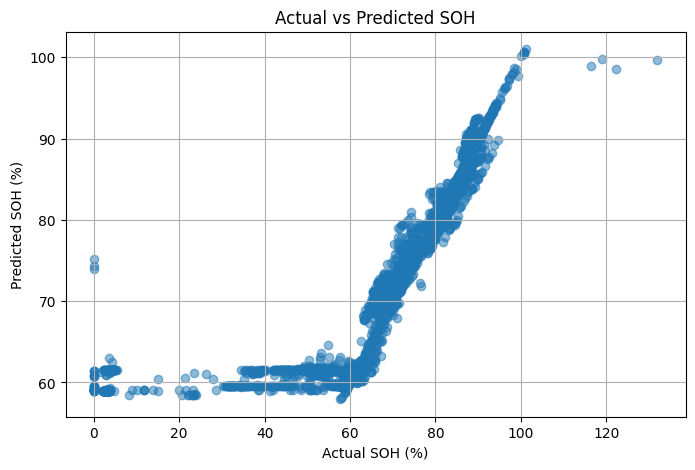

In [342]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Actual vs Predicted SOH")

plt.grid(True)
plt.show()

              precision    recall  f1-score   support

    Critical       0.98      0.98      0.98       772
   Degrading       0.98      0.99      0.98      1040
     Healthy       0.99      0.99      0.99       938

    accuracy                           0.99      2750
   macro avg       0.99      0.99      0.99      2750
weighted avg       0.99      0.99      0.99      2750



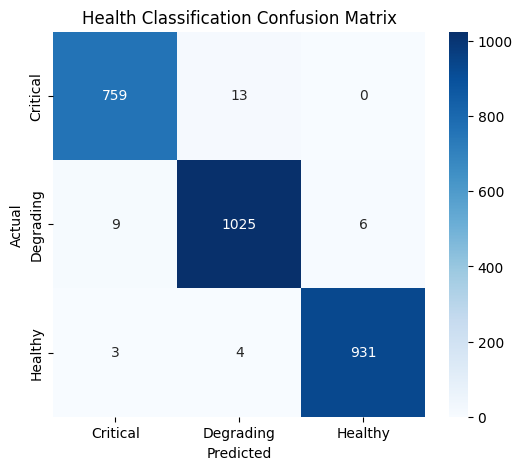

In [343]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_health = classification_df[health_features]
y_health = classification_df['Health']

y_pred_health = health_model.predict(X_health)

print(classification_report(y_health, y_pred_health))

cm = confusion_matrix(y_health, y_pred_health)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=health_model.classes_,
    yticklabels=health_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Health Classification Confusion Matrix")
plt.show()

In [344]:
from sklearn.metrics import classification_report

# Unseen test data prediction
y_test_pred = health_model.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

    Critical       0.93      0.92      0.92       165
   Degrading       0.88      0.89      0.88       136
     Healthy       0.95      0.94      0.95       121

    accuracy                           0.92       422
   macro avg       0.92      0.92      0.92       422
weighted avg       0.92      0.92      0.92       422



In [345]:
print("RUL model exists:", 'rul_model' in globals())
print("RUL dataset exists:", 'rul_df' in globals())

RUL model exists: True
RUL dataset exists: True


In [346]:
print("RUL dataset shape:", rul_df.shape)
print("RUL columns:")
print(rul_df.columns.tolist())

RUL dataset shape: (2794, 12)
RUL columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'EOL_Cycle', 'Observed_EOL', 'RUL']


In [347]:
print("RUL model features:")
print(rul_model.feature_names_in_)

RUL model features:
['SOH' 'Capacity' 'Avg_Voltage' 'Avg_Current' 'Max_Temperature'
 'Min_Voltage' 'Discharge_Time' 'Cycle']


In [348]:
print("Available test variables:")

for name in ['X_rul_test', 'y_rul_test', 'X_test_rul', 'y_test_rul']:
    print(name, name in globals())

Available test variables:
X_rul_test False
y_rul_test False
X_test_rul True
y_test_rul True


In [349]:
y_pred_rul = rul_model.predict(X_test_rul)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("RUL MAE:", mean_absolute_error(y_test_rul, y_pred_rul))

print("RUL RMSE:", np.sqrt(
    mean_squared_error(y_test_rul, y_pred_rul)
))

print("RUL R2 Score:", r2_score(y_test_rul, y_pred_rul))

RUL MAE: 20.527008753224024
RUL RMSE: 44.95525824956074
RUL R2 Score: -7.079590575100896


In [350]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [
    'SOH',
    'Capacity',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Cycle'
]

X = rul_df[features]
y = rul_df['RUL']
groups = rul_df['Battery_ID']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

rul_model_strong = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rul_model_strong.fit(X_train, y_train)

y_pred = rul_model_strong.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 20.31320246343341
RMSE: 51.45604768380864
R2 Score: -9.585252218891489


In [351]:
print("RUL range:")
print(rul_df['RUL'].min(), rul_df['RUL'].max())

print("\nRUL by Battery:")
print(
    rul_df.groupby('Battery_ID')['RUL']
    .agg(['min', 'max', 'mean'])
)

RUL range:
0.0 612.0

RUL by Battery:
            min    max        mean
Battery_ID                        
B0005       0.0  447.0  176.583333
B0006       0.0  385.0  133.630952
B0007       0.0  612.0  320.000000
B0018       0.0  234.0   83.886364
B0025       0.0   74.0   37.750000
B0026       0.0   12.0    1.428571
B0027       0.0   74.0   37.750000
B0028       0.0   74.0   37.750000
B0029       0.0   92.0   46.000000
B0030       0.0   92.0   46.000000
B0031       0.0   92.0   46.000000
B0032       0.0   92.0   46.000000
B0033       0.0    0.0    0.000000
B0034       0.0    0.0    0.000000
B0036       0.0    0.0    0.000000
B0038       0.0    0.0    0.000000
B0039       0.0    0.0    0.000000
B0040       0.0    0.0    0.000000
B0041       0.0    0.0    0.000000
B0042       0.0   12.0    0.357143
B0043       0.0   12.0    0.357143
B0044       0.0   12.0    0.357143
B0045       0.0    0.0    0.000000
B0046       0.0   42.0    4.861111
B0047       0.0   24.0    1.638889
B0048       0.0  

In [352]:
# Keep batteries with meaningful RUL variation
valid_batteries = rul_df.groupby(
    'Battery_ID'
)['RUL'].max()

valid_batteries = valid_batteries[
    valid_batteries > 0
]

print("Valid batteries:")
print(valid_batteries)

print("\nNumber of valid batteries:",
      len(valid_batteries))

Valid batteries:
Battery_ID
B0005    447.0
B0006    385.0
B0007    612.0
B0018    234.0
B0025     74.0
B0026     12.0
B0027     74.0
B0028     74.0
B0029     92.0
B0030     92.0
B0031     92.0
B0032     92.0
B0042     12.0
B0043     12.0
B0044     12.0
B0046     42.0
B0047     24.0
B0048     28.0
Name: RUL, dtype: float64

Number of valid batteries: 18


In [353]:
print(
    rul_df.groupby('Observed_EOL')['Battery_ID']
    .nunique()
)

print("\nObserved EOL distribution:")
print(rul_df['Observed_EOL'].value_counts())

Observed_EOL
0     8
1    26
Name: Battery_ID, dtype: int64

Observed EOL distribution:
Observed_EOL
1    2382
0     412
Name: count, dtype: int64


In [354]:
# Keep only batteries with observed EOL
rul_observed_df = rul_df[
    rul_df['Observed_EOL'] == 1
].copy()

print("Observed RUL dataset shape:",
      rul_observed_df.shape)

print("Number of batteries:",
      rul_observed_df['Battery_ID'].nunique())

Observed RUL dataset shape: (2382, 12)
Number of batteries: 26


In [355]:
from sklearn.model_selection import GroupShuffleSplit

features = [
    'SOH',
    'Capacity',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Cycle'
]

X = rul_observed_df[features]
y = rul_observed_df['RUL']
groups = rul_observed_df['Battery_ID']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train_rul = X.iloc[train_idx]
X_test_rul = X.iloc[test_idx]

y_train_rul = y.iloc[train_idx]
y_test_rul = y.iloc[test_idx]

print("Training rows:", X_train_rul.shape)
print("Testing rows:", X_test_rul.shape)

print("Training batteries:",
      rul_observed_df.iloc[train_idx]['Battery_ID'].nunique())

print("Testing batteries:",
      rul_observed_df.iloc[test_idx]['Battery_ID'].nunique())

Training rows: (1834, 8)
Testing rows: (548, 8)
Training batteries: 20
Testing batteries: 6


In [356]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rul_model_observed = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rul_model_observed.fit(X_train_rul, y_train_rul)

y_pred_rul = rul_model_observed.predict(X_test_rul)

mae = mean_absolute_error(y_test_rul, y_pred_rul)
rmse = np.sqrt(mean_squared_error(y_test_rul, y_pred_rul))
r2 = r2_score(y_test_rul, y_pred_rul)

print("RUL MAE:", mae)
print("RUL RMSE:", rmse)
print("RUL R2 Score:", r2)

RUL MAE: 30.088789537712902
RUL RMSE: 62.08725117914432
RUL R2 Score: 0.7264625957087343


In [357]:
from sklearn.model_selection import GroupKFold, cross_val_score

cv = GroupKFold(n_splits=5)

cv_scores = cross_val_score(
    rul_model_observed,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring='r2'
)

print("R2 Scores:", cv_scores)
print("Mean R2:", cv_scores.mean())

R2 Scores: [-1.18812158e+03 -2.82179560e+02  0.00000000e+00  4.40101367e-01
  5.34408113e-01]
Mean R2: -293.86532667111385


In [358]:
battery_summary = rul_observed_df.groupby(
    'Battery_ID'
).agg(
    Total_Rows=('RUL', 'count'),
    Min_RUL=('RUL', 'min'),
    Max_RUL=('RUL', 'max'),
    Mean_RUL=('RUL', 'mean'),
    Unique_RUL=('RUL', 'nunique')
).reset_index()

print(battery_summary.to_string(index=False))

Battery_ID  Total_Rows  Min_RUL  Max_RUL   Mean_RUL  Unique_RUL
     B0005         168      0.0    447.0 176.583333         125
     B0006         168      0.0    385.0 133.630952         109
     B0018         132      0.0    234.0  83.886364          97
     B0026          28      0.0     12.0   1.428571           6
     B0033         197      0.0      0.0   0.000000           1
     B0034         197      0.0      0.0   0.000000           1
     B0036         197      0.0      0.0   0.000000           1
     B0038          47      0.0      0.0   0.000000           1
     B0039          47      0.0      0.0   0.000000           1
     B0040          47      0.0      0.0   0.000000           1
     B0041          67      0.0      0.0   0.000000           1
     B0042         112      0.0     12.0   0.357143           6
     B0043         112      0.0     12.0   0.357143           6
     B0044         112      0.0     12.0   0.357143           6
     B0045          72      0.0      0.0

In [359]:
# Keep batteries where RUL actually changes
valid_batteries = battery_summary[
    (battery_summary['Max_RUL'] > 0) &
    (battery_summary['Unique_RUL'] > 5)
]['Battery_ID']

rul_clean_df = rul_observed_df[
    rul_observed_df['Battery_ID'].isin(valid_batteries)
].copy()

print("Clean RUL shape:", rul_clean_df.shape)

print("Number of batteries:",
      rul_clean_df['Battery_ID'].nunique())

print("Batteries:",
      rul_clean_df['Battery_ID'].unique())

Clean RUL shape: (1048, 12)
Number of batteries: 10
Batteries: ['B0005' 'B0006' 'B0018' 'B0026' 'B0042' 'B0043' 'B0044' 'B0046' 'B0047'
 'B0048']


In [360]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [
    'SOH',
    'Capacity',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Cycle'
]

X_clean = rul_clean_df[features]
y_clean = rul_clean_df['RUL']
groups_clean = rul_clean_df['Battery_ID']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X_clean, y_clean, groups_clean)
)

X_train_clean = X_clean.iloc[train_idx]
X_test_clean = X_clean.iloc[test_idx]

y_train_clean = y_clean.iloc[train_idx]
y_test_clean = y_clean.iloc[test_idx]

clean_rul_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

clean_rul_model.fit(X_train_clean, y_train_clean)

y_pred_clean = clean_rul_model.predict(X_test_clean)

mae = mean_absolute_error(y_test_clean, y_pred_clean)
rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
r2 = r2_score(y_test_clean, y_pred_clean)

print("Clean RUL MAE:", mae)
print("Clean RUL RMSE:", rmse)
print("Clean RUL R2 Score:", r2)

Clean RUL MAE: 36.60075
Clean RUL RMSE: 61.71527538714472
Clean RUL R2 Score: 0.7716099348712435


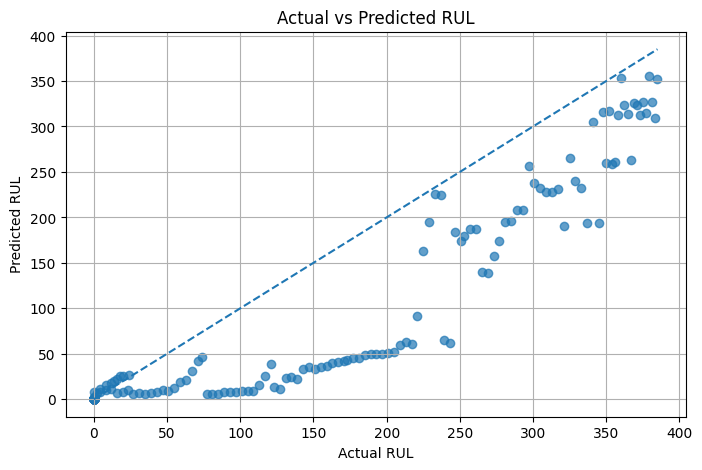

In [361]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_clean,
    y_pred_clean,
    alpha=0.7
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.plot(
    [y_test_clean.min(), y_test_clean.max()],
    [y_test_clean.min(), y_test_clean.max()],
    linestyle="--"
)

plt.grid(True)
plt.show()

In [362]:
error = y_test_clean - y_pred_clean

error_df = pd.DataFrame({
    "Actual_RUL": y_test_clean.values,
    "Predicted_RUL": y_pred_clean,
    "Error": error.values
})

print(error_df.head(10))

print("\nMean Error:", error.mean())
print("Maximum Error:", error.abs().max())

   Actual_RUL  Predicted_RUL       Error
0       385.0     352.106667   32.893333
1       383.0     309.860000   73.140000
2       381.0     327.183333   53.816667
3       379.0     355.646667   23.353333
4       377.0     314.586667   62.413333
5       375.0     327.043333   47.956667
6       373.0     312.766667   60.233333
7       371.0     323.656667   47.343333
8       369.0     326.253333   42.746667
9       367.0     262.763333  104.236667

Mean Error: 35.92444444444445
Maximum Error: 181.05666666666667


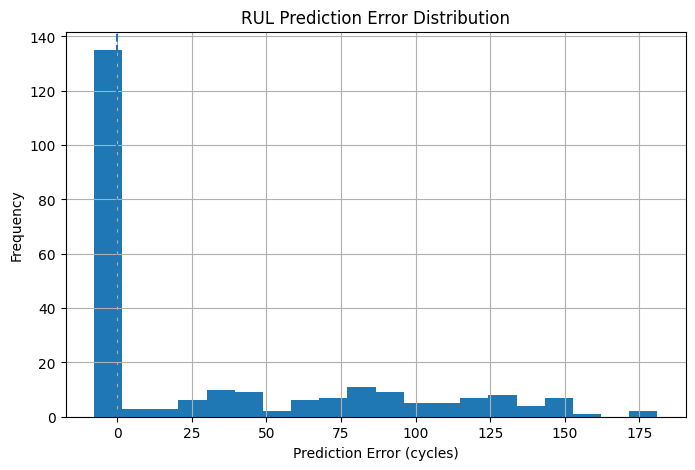

In [363]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(error_df["Error"], bins=20)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (cycles)")
plt.ylabel("Frequency")
plt.title("RUL Prediction Error Distribution")

plt.grid(True)
plt.show()

In [364]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_rul_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_rul_model.fit(X_train_clean, y_train_clean)

gb_pred = gb_rul_model.predict(X_test_clean)

gb_mae = mean_absolute_error(y_test_clean, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test_clean, gb_pred))
gb_r2 = r2_score(y_test_clean, gb_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R2 Score:", gb_r2)

Gradient Boosting MAE: 47.20988797103961
Gradient Boosting RMSE: 76.42162775752725
Gradient Boosting R2 Score: 0.6497933138012879


In [365]:
# Final Data Quality Audit

print("Dataset Shape:", master_df.shape)

print("\nData Types:")
print(master_df.dtypes)

print("\nMissing Values:")
print(master_df.isnull().sum())

print("\nDuplicate Rows:",
      master_df.duplicated().sum())

print("\nInvalid Capacity Values:",
      (master_df["Capacity"] <= 0).sum())

print("\nBattery Count:",
      master_df["Battery_ID"].nunique())

Dataset Shape: (2794, 13)

Data Types:
Battery_ID                object
Cycle                      int64
Avg_Voltage              float64
Avg_Current              float64
Max_Temperature          float64
Min_Voltage              float64
Discharge_Time           float64
Capacity                 float64
SOH                      float64
Discharge_Energy         float64
Past_SOH_Mean            float64
Past_Capacity_Mean       float64
Past_Temperature_Mean    float64
dtype: object

Missing Values:
Battery_ID                0
Cycle                     0
Avg_Voltage               0
Avg_Current               0
Max_Temperature           0
Min_Voltage               0
Discharge_Time            0
Capacity                  0
SOH                       0
Discharge_Energy          0
Past_SOH_Mean            34
Past_Capacity_Mean       34
Past_Temperature_Mean    34
dtype: int64

Duplicate Rows: 0

Invalid Capacity Values: 44

Battery Count: 34


In [366]:
# ==========================================
# STEP 1: DATA AUDIT
# ==========================================

import pandas as pd
import numpy as np

print("=" * 50)
print("EV BATTERY HEALTH PREDICTOR")
print("STEP 1: DATA AUDIT")
print("=" * 50)

print("\nDataset Shape:")
print(master_df.shape)

print("\nDataset Columns:")
print(master_df.columns.tolist())

print("\nFirst 5 Rows:")
display(master_df.head())

print("\nDataset Information:")
master_df.info()

print("\nMissing Values:")
missing_values = master_df.isnull().sum()
print(missing_values)

print("\nDuplicate Rows:")
print(master_df.duplicated().sum())

print("\nStatistical Summary:")
display(master_df.describe())

print("\nUnique Values per Column:")
for column in master_df.columns:
    print(f"{column}: {master_df[column].nunique()} unique values")

EV BATTERY HEALTH PREDICTOR
STEP 1: DATA AUDIT

Dataset Shape:
(2794, 13)

Dataset Columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'Discharge_Energy', 'Past_SOH_Mean', 'Past_Capacity_Mean', 'Past_Temperature_Mean']

First 5 Rows:


,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity,SOH,Discharge_Energy,Past_SOH_Mean,Past_Capacity_Mean,Past_Temperature_Mean
0,B0005,2,3.529829,-1.818702,38.982181,2.612467,3690.234,1.856487,92.824371,6.580616,NaN,NaN,NaN
1,B0005,4,3.537320,-1.817560,39.033398,2.587209,3672.344,1.846327,92.316362,6.558491,92.824371,1.856487,38.982181
2,B0005,6,3.543737,-1.816487,38.818797,2.651917,3651.641,1.835349,91.767460,6.529489,92.570367,1.851407,39.007790
3,B0005,8,3.543666,-1.825589,38.762305,2.592948,3631.563,1.835263,91.763126,6.525998,92.302731,1.846055,38.944792
4,B0005,10,3.542343,-1.826114,38.665393,2.547420,3629.172,1.834646,91.732275,6.521141,92.167830,1.843357,38.899170



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2794 entries, 0 to 2793
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Battery_ID             2794 non-null   object 
 1   Cycle                  2794 non-null   int64  
 2   Avg_Voltage            2794 non-null   float64
 3   Avg_Current            2794 non-null   float64
 4   Max_Temperature        2794 non-null   float64
 5   Min_Voltage            2794 non-null   float64
 6   Discharge_Time         2794 non-null   float64
 7   Capacity               2794 non-null   float64
 8   SOH                    2794 non-null   float64
 9   Discharge_Energy       2794 non-null   float64
 10  Past_SOH_Mean          2760 non-null   float64
 11  Past_Capacity_Mean     2760 non-null   float64
 12  Past_Temperature_Mean  2760 non-null   float64
dtypes: float64(11), int64(1), object(1)
memory usage: 283.9+ KB

Missing Values:
Battery_I

,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity,SOH,Discharge_Energy,Past_SOH_Mean,Past_Capacity_Mean,Past_Temperature_Mean
count,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2760.000000,2760.000000,2760.000000
mean,163.996063,3.404579,-1.713299,34.217616,2.303508,3218.719931,1.314674,65.733684,4.744559,65.976575,1.319532,34.245307
std,143.385837,0.348275,0.794850,16.471197,0.360771,1389.093061,0.486707,24.335350,1.583896,23.433813,0.468676,16.264322
min,1.000000,0.234723,-3.976473,6.288208,0.192738,23.000000,0.000000,0.000000,0.000029,0.000000,0.000000,6.532289
25%,53.000000,3.366336,-1.942446,16.689440,2.065549,2504.058500,1.138590,56.929505,4.045311,55.789182,1.115784,17.569561
50%,120.000000,3.415143,-1.795087,37.821166,2.377473,3030.125000,1.423256,71.162810,5.069571,71.228543,1.424571,37.609659
75%,237.000000,3.490553,-1.058206,42.578406,2.618483,3385.523500,1.671882,83.594084,5.840250,83.623896,1.672478,42.383230
max,614.000000,4.452558,0.001803,69.869746,3.838396,6574.671000,2.640149,132.007456,10.087657,101.766880,2.035338,62.881885



Unique Values per Column:
Battery_ID: 34 unique values
Cycle: 425 unique values
Avg_Voltage: 2794 unique values
Avg_Current: 2794 unique values
Max_Temperature: 2794 unique values
Min_Voltage: 2794 unique values
Discharge_Time: 920 unique values
Capacity: 2751 unique values
SOH: 2751 unique values
Discharge_Energy: 2794 unique values
Past_SOH_Mean: 2744 unique values
Past_Capacity_Mean: 2744 unique values
Past_Temperature_Mean: 2760 unique values


In [367]:
print("=" * 50)
print("TARGET AND ID COLUMN CHECK")
print("=" * 50)

possible_targets = ["SOH", "Health", "Capacity", "RUL"]

for column in possible_targets:
    if column in master_df.columns:
        print(f"Found column: {column}")

print("\nPossible ID Columns:")

possible_ids = [
    "BatteryID",
    "Battery_Id",
    "Battery",
    "BatchID",
    "Cycle"
]

for column in possible_ids:
    if column in master_df.columns:
        print(f"Found ID/Cycle column: {column}")

TARGET AND ID COLUMN CHECK
Found column: SOH
Found column: Capacity

Possible ID Columns:
Found ID/Cycle column: Cycle


In [368]:
# ==========================================
# STEP 2: DATA CLEANING CHECK
# ==========================================

print("=" * 50)
print("STEP 2: DATA CLEANING CHECK")
print("=" * 50)

# 1. Check zero capacity
print("\nZero Capacity Rows:")
print((master_df["Capacity"] == 0).sum())

# 2. Check negative capacity
print("\nNegative Capacity Rows:")
print((master_df["Capacity"] < 0).sum())

# 3. Check SOH below 0
print("\nSOH Below 0:")
print((master_df["SOH"] < 0).sum())

# 4. Check SOH above 100
print("\nSOH Above 100:")
print((master_df["SOH"] > 100).sum())

# 5. Show invalid capacity rows
print("\nRows with Zero Capacity:")
display(
    master_df[master_df["Capacity"] == 0].head(10)
)

# 6. Show very high SOH rows
print("\nRows with SOH Above 100:")
display(
    master_df[master_df["SOH"] > 100]
)

STEP 2: DATA CLEANING CHECK

Zero Capacity Rows:
44

Negative Capacity Rows:
0

SOH Below 0:
0

SOH Above 100:
11

Rows with Zero Capacity:


,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity,SOH,Discharge_Energy,Past_SOH_Mean,Past_Capacity_Mean,Past_Temperature_Mean
1712,B0042,15,3.581392,-1.997608,33.431937,3.381341,2646.625,0.0,0.0,5.259592,86.309365,1.726187,35.958715
1824,B0043,15,3.579340,-1.973998,34.263342,3.357924,2646.625,0.0,0.0,5.194450,84.388955,1.687779,36.465437
1936,B0044,15,3.526841,-1.978884,35.599499,3.289658,2646.625,0.0,0.0,5.130931,82.832659,1.656653,37.429498
2062,B0045,51,3.406715,-0.994190,11.624486,2.942422,2384.094,0.0,0.0,2.242984,37.929750,0.758595,16.296454
2108,B0045,165,3.392551,-0.990152,11.709111,2.932971,1991.531,0.0,0.0,1.858288,31.330024,0.626600,15.636050
2134,B0046,51,3.651053,-0.995719,8.963880,3.470936,2384.094,0.0,0.0,2.407552,69.470822,1.389416,13.821875
2168,B0046,133,3.442619,-0.999053,11.441353,2.957668,3581.188,0.0,0.0,3.421386,56.970197,1.139404,14.289165
2180,B0046,165,3.615599,-0.991420,9.413943,3.427688,1991.531,0.0,0.0,1.982999,57.640322,1.152806,15.000330
2206,B0047,51,3.650725,-0.983965,8.565277,3.452630,2384.094,0.0,0.0,2.378919,67.433624,1.348672,11.525000
2240,B0047,133,3.449492,-0.986706,10.553053,2.994695,3581.188,0.0,0.0,3.385847,55.987169,1.119743,12.189128



Rows with SOH Above 100:


,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity,SOH,Discharge_Energy,Past_SOH_Mean,Past_Capacity_Mean,Past_Temperature_Mean
168,B0006,2,3.556946,-1.990533,39.162987,2.475768,3690.234,2.035338,101.766880,7.257685,NaN,NaN,NaN
169,B0006,4,3.561476,-1.990278,39.246203,2.351526,3672.344,2.025140,101.257012,7.230769,101.766880,2.035338,39.162987
170,B0006,6,3.566752,-1.989947,38.999202,2.440480,3651.641,2.013326,100.666319,7.199461,101.511946,2.030239,39.204595
171,B0006,8,3.568795,-1.989601,38.843628,2.479156,3631.563,2.013285,100.664233,7.162732,101.230070,2.024601,39.136131
172,B0006,10,3.563971,-1.989548,38.977989,2.280188,3629.172,2.000528,100.026417,7.148150,101.088611,2.021772,39.063005
173,B0006,12,3.573551,-1.990104,38.839899,2.439284,3652.281,2.013899,100.694954,7.215019,100.876172,2.017523,39.046002
174,B0006,14,3.571139,-1.990089,39.046108,2.281207,3650.828,2.013101,100.655055,7.207225,100.661787,2.013236,38.981384
1415,B0036,279,3.626510,-1.983706,38.497146,2.691307,4424.203,2.444062,122.203122,8.840946,83.977572,1.679551,36.904460
2335,B0049,11,3.262568,-2.004587,20.096310,1.973517,4565.859,2.378644,118.932187,8.294772,62.706310,1.254126,19.196827
2361,B0050,15,3.335573,-2.005557,24.962762,2.178401,5428.594,2.640149,132.007456,10.087657,56.978858,1.139577,16.817049


In [369]:
# ==========================================
# STEP 3: REMOVE INVALID CAPACITY ROWS
# ==========================================

print("=" * 50)
print("STEP 3: CLEANING DATASET")
print("=" * 50)

# Create a copy
clean_df = master_df.copy()

# Remove rows where Capacity is zero
clean_df = clean_df[clean_df["Capacity"] > 0].copy()

# Reset index
clean_df.reset_index(drop=True, inplace=True)

# Display results
print("Original Shape:", master_df.shape)
print("Cleaned Shape:", clean_df.shape)

print("\nRemaining Zero Capacity Rows:")
print((clean_df["Capacity"] == 0).sum())

print("\nCleaned Dataset Preview:")
display(clean_df.head())

STEP 3: CLEANING DATASET
Original Shape: (2794, 13)
Cleaned Shape: (2750, 13)

Remaining Zero Capacity Rows:
0

Cleaned Dataset Preview:


,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity,SOH,Discharge_Energy,Past_SOH_Mean,Past_Capacity_Mean,Past_Temperature_Mean
0,B0005,2,3.529829,-1.818702,38.982181,2.612467,3690.234,1.856487,92.824371,6.580616,NaN,NaN,NaN
1,B0005,4,3.537320,-1.817560,39.033398,2.587209,3672.344,1.846327,92.316362,6.558491,92.824371,1.856487,38.982181
2,B0005,6,3.543737,-1.816487,38.818797,2.651917,3651.641,1.835349,91.767460,6.529489,92.570367,1.851407,39.007790
3,B0005,8,3.543666,-1.825589,38.762305,2.592948,3631.563,1.835263,91.763126,6.525998,92.302731,1.846055,38.944792
4,B0005,10,3.542343,-1.826114,38.665393,2.547420,3629.172,1.834646,91.732275,6.521141,92.167830,1.843357,38.899170


In [370]:
# ==========================================
# STEP 4: FINAL DATA QUALITY CHECK
# ==========================================

print("=" * 50)
print("STEP 4: FINAL DATA QUALITY CHECK")
print("=" * 50)

# 1. Missing values
print("\nMissing Values:")
print(clean_df.isnull().sum())

# 2. Duplicate rows
print("\nDuplicate Rows:")
print(clean_df.duplicated().sum())

# 3. Data types
print("\nData Types:")
print(clean_df.dtypes)

# 4. Dataset shape
print("\nFinal Dataset Shape:")
print(clean_df.shape)

STEP 4: FINAL DATA QUALITY CHECK

Missing Values:
Battery_ID                0
Cycle                     0
Avg_Voltage               0
Avg_Current               0
Max_Temperature           0
Min_Voltage               0
Discharge_Time            0
Capacity                  0
SOH                       0
Discharge_Energy          0
Past_SOH_Mean            34
Past_Capacity_Mean       34
Past_Temperature_Mean    34
dtype: int64

Duplicate Rows:
0

Data Types:
Battery_ID                object
Cycle                      int64
Avg_Voltage              float64
Avg_Current              float64
Max_Temperature          float64
Min_Voltage              float64
Discharge_Time           float64
Capacity                 float64
SOH                      float64
Discharge_Energy         float64
Past_SOH_Mean            float64
Past_Capacity_Mean       float64
Past_Temperature_Mean    float64
dtype: object

Final Dataset Shape:
(2750, 13)


In [371]:
# ==========================================
# STEP 5: CHECK MISSING HISTORICAL FEATURES
# ==========================================

print("=" * 50)
print("STEP 5: MISSING HISTORICAL FEATURES")
print("=" * 50)

# Display rows with missing past values
missing_rows = clean_df[
    clean_df["Past_SOH_Mean"].isnull() |
    clean_df["Past_Capacity_Mean"].isnull() |
    clean_df["Past_Temperature_Mean"].isnull()
]

print("Number of rows:", len(missing_rows))

print("\nMissing Rows:")
display(missing_rows.head(40))

print("\nBattery IDs:")
print(missing_rows["Battery_ID"].unique())

print("\nCycle Values:")
print(missing_rows["Cycle"].unique())

STEP 5: MISSING HISTORICAL FEATURES
Number of rows: 34

Missing Rows:


,Battery_ID,Cycle,Avg_Voltage,Avg_Current,Max_Temperature,Min_Voltage,Discharge_Time,Capacity,SOH,Discharge_Energy,Past_SOH_Mean,Past_Capacity_Mean,Past_Temperature_Mean
0,B0005,2,3.529829,-1.818702,38.982181,2.612467,3690.234,1.856487,92.824371,6.580616,NaN,NaN,NaN
168,B0006,2,3.556946,-1.990533,39.162987,2.475768,3690.234,2.035338,101.766880,7.257685,NaN,NaN,NaN
336,B0007,2,3.522007,-1.869119,40.590429,2.145976,3690.234,1.891052,94.552615,6.748053,NaN,NaN,NaN
504,B0018,3,3.527546,-1.954176,38.101803,2.472161,3434.891,1.855005,92.750226,6.577288,NaN,NaN,NaN
636,B0025,4,3.400081,-1.068026,41.817481,1.918268,6515.422,1.847011,92.350558,6.572207,NaN,NaN,NaN
664,B0026,4,3.404890,-1.049536,40.711455,1.980690,6515.422,1.813250,90.662522,6.467561,NaN,NaN,NaN
692,B0027,4,3.415635,-1.048298,42.071941,2.440795,6515.422,1.823308,91.165389,6.480319,NaN,NaN,NaN
720,B0028,4,3.676493,-0.997040,31.679728,2.615140,6515.422,1.804685,90.234239,6.634168,NaN,NaN,NaN
748,B0029,2,3.365186,-3.975396,58.726269,1.999936,1572.359,1.697507,84.875367,5.843038,NaN,NaN,NaN
788,B0030,2,3.346448,-3.881094,61.114389,2.127417,1572.359,1.656071,82.803530,5.672669,NaN,NaN,NaN



Battery IDs:
['B0005' 'B0006' 'B0007' 'B0018' 'B0025' 'B0026' 'B0027' 'B0028' 'B0029'
 'B0030' 'B0031' 'B0032' 'B0033' 'B0034' 'B0036' 'B0038' 'B0039' 'B0040'
 'B0041' 'B0042' 'B0043' 'B0044' 'B0045' 'B0046' 'B0047' 'B0048' 'B0049'
 'B0050' 'B0051' 'B0052' 'B0053' 'B0054' 'B0055' 'B0056']

Cycle Values:
[2 3 4 1]


In [372]:
# ==========================================
# STEP 6: PREPARE FEATURES AND TARGET
# ==========================================

print("=" * 50)
print("STEP 6: PREPARE ML DATA")
print("=" * 50)

# Remove historical mean columns
model_df = clean_df.drop(
    columns=[
        "Past_SOH_Mean",
        "Past_Capacity_Mean",
        "Past_Temperature_Mean"
    ]
).copy()

# Separate features and target
X = model_df.drop(columns=["SOH", "Battery_ID"])
y = model_df["SOH"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nMissing Values in Features:")
print(X.isnull().sum())

print("\nTarget Preview:")
display(y.head())

STEP 6: PREPARE ML DATA
Features Shape: (2750, 8)
Target Shape: (2750,)

Feature Columns:
['Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'Discharge_Energy']

Missing Values in Features:
Cycle               0
Avg_Voltage         0
Avg_Current         0
Max_Temperature     0
Min_Voltage         0
Discharge_Time      0
Capacity            0
Discharge_Energy    0
dtype: int64

Target Preview:


,SOH
0,92.824371
1,92.316362
2,91.767460
3,91.763126
4,91.732275


In [373]:
# ==========================================
# STEP 7: TRAIN-TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 50)
print("STEP 7: TRAIN-TEST SPLIT")
print("=" * 50)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

STEP 7: TRAIN-TEST SPLIT
X_train Shape: (2200, 8)
X_test Shape: (550, 8)
y_train Shape: (2200,)
y_test Shape: (550,)


In [374]:
# ==========================================
# STEP 8: RANDOM FOREST REGRESSION
# ==========================================

from sklearn.ensemble import RandomForestRegressor

print("=" * 50)
print("STEP 8: TRAINING RANDOM FOREST")
print("=" * 50)

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

STEP 8: TRAINING RANDOM FOREST
Random Forest Model Trained Successfully!


In [375]:
# ==========================================
# STEP 9: MODEL EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("STEP 9: MODEL EVALUATION")
print("=" * 50)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

STEP 9: MODEL EVALUATION
MAE: 0.04477085647885974
RMSE: 0.23435823927333774
R2 Score: 0.99989397832645


STEP 10: FEATURE IMPORTANCE


,Feature,Importance
6,Capacity,0.997604
7,Discharge_Energy,0.001548
3,Max_Temperature,0.000637
1,Avg_Voltage,0.000075
5,Discharge_Time,0.000059
2,Avg_Current,0.000037
0,Cycle,0.000025
4,Min_Voltage,0.000015


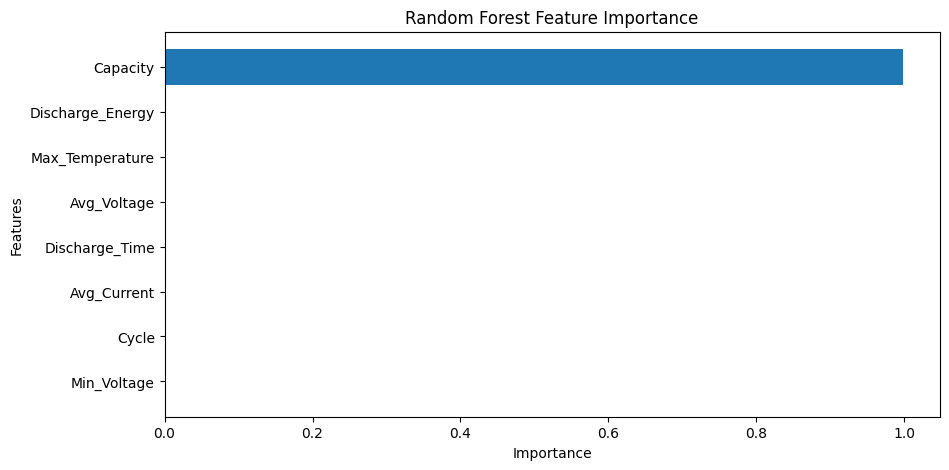

In [376]:
# ==========================================
# STEP 10: FEATURE IMPORTANCE
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("=" * 50)
print("STEP 10: FEATURE IMPORTANCE")
print("=" * 50)

display(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [377]:
# ==========================================
# STEP 11: MODEL WITHOUT CAPACITY
# ==========================================

# Remove Capacity from features
X_no_capacity = X.drop(columns=["Capacity"])

# Train-test split
X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_capacity,
    y,
    test_size=0.20,
    random_state=42
)

# Create new model
rf_model_nc = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model_nc.fit(X_train_nc, y_train_nc)

# Predictions
y_pred_nc = rf_model_nc.predict(X_test_nc)

# Evaluation
mae_nc = mean_absolute_error(y_test_nc, y_pred_nc)
rmse_nc = np.sqrt(mean_squared_error(y_test_nc, y_pred_nc))
r2_nc = r2_score(y_test_nc, y_pred_nc)

print("=" * 50)
print("MODEL WITHOUT CAPACITY")
print("=" * 50)

print("MAE:", mae_nc)
print("RMSE:", rmse_nc)
print("R2 Score:", r2_nc)

MODEL WITHOUT CAPACITY
MAE: 0.49958294001637404
RMSE: 1.5543305717137235
R2 Score: 0.995336403362596


STEP 12: FEATURE CORRELATION

Correlation with SOH:
SOH                 1.000000
Capacity            1.000000
Discharge_Energy    0.978364
Max_Temperature     0.535350
Discharge_Time      0.452763
Min_Voltage         0.141656
Avg_Voltage         0.005585
Cycle              -0.012873
Avg_Current        -0.298820
Name: SOH, dtype: float64


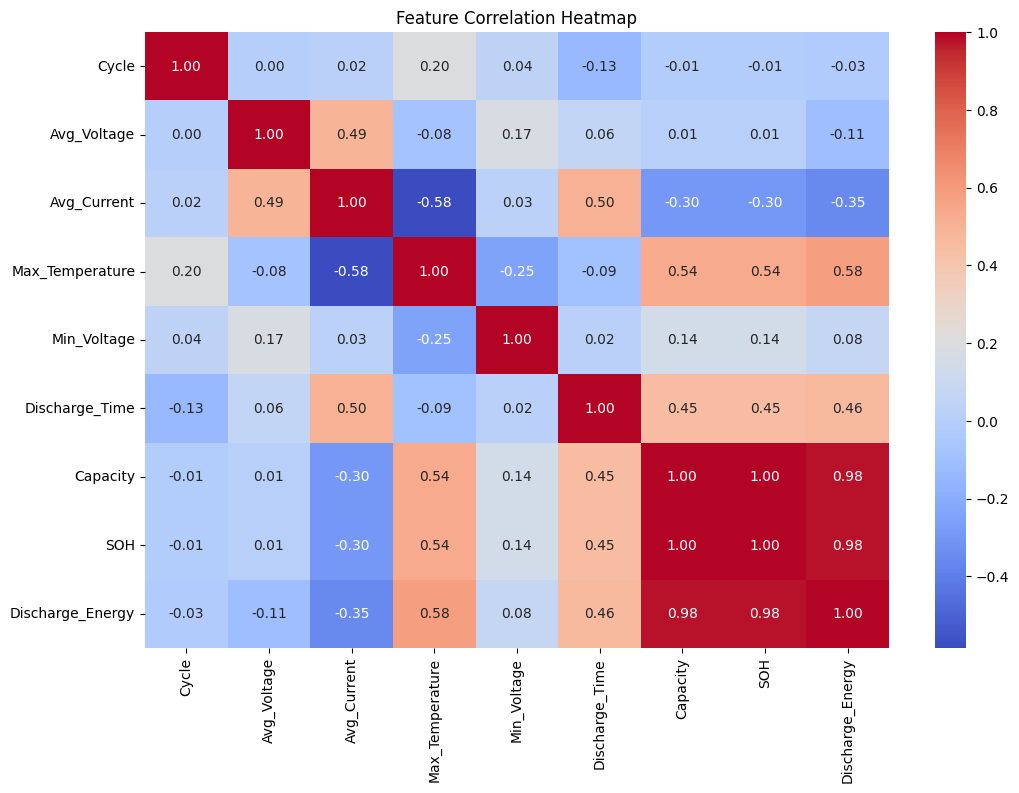

In [378]:
# ==========================================
# STEP 12: FEATURE CORRELATION
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 50)
print("STEP 12: FEATURE CORRELATION")
print("=" * 50)

# Select numerical columns
correlation = model_df.drop(
    columns=["Battery_ID"]
).corr()

# Display correlation with SOH
print("\nCorrelation with SOH:")
print(
    correlation["SOH"].sort_values(
        ascending=False
    )
)

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [379]:
# ==========================================
# STEP 13: BATTERY-LEVEL DATA SPLIT CHECK
# ==========================================

print("=" * 50)
print("STEP 13: BATTERY DATA DISTRIBUTION")
print("=" * 50)

# Battery IDs in training and testing
train_batteries = set(
    clean_df.loc[X_train.index, "Battery_ID"]
)

test_batteries = set(
    clean_df.loc[X_test.index, "Battery_ID"]
)

# Common batteries
common_batteries = train_batteries.intersection(
    test_batteries
)

print("Training Batteries:", len(train_batteries))
print("Testing Batteries:", len(test_batteries))
print("Common Batteries:", len(common_batteries))

print("\nCommon Battery IDs:")
print(sorted(common_batteries))

STEP 13: BATTERY DATA DISTRIBUTION
Training Batteries: 34
Testing Batteries: 34
Common Batteries: 34

Common Battery IDs:
['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054', 'B0055', 'B0056']


In [380]:
# ==========================================
# STEP 14: BATTERY-LEVEL DATA SPLIT
# ==========================================

from sklearn.model_selection import GroupShuffleSplit

print("=" * 50)
print("STEP 14: BATTERY-LEVEL SPLIT")
print("=" * 50)

# Features and target
X_group = clean_df.drop(
    columns=["SOH", "Battery_ID",
             "Past_SOH_Mean",
             "Past_Capacity_Mean",
             "Past_Temperature_Mean"]
)

y_group = clean_df["SOH"]

# Battery IDs as groups
groups = clean_df["Battery_ID"]

# Split by Battery_ID
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_group, y_group, groups)
)

X_train_group = X_group.iloc[train_idx]
X_test_group = X_group.iloc[test_idx]

y_train_group = y_group.iloc[train_idx]
y_test_group = y_group.iloc[test_idx]

train_batteries = set(groups.iloc[train_idx])
test_batteries = set(groups.iloc[test_idx])

print("Training Shape:", X_train_group.shape)
print("Testing Shape:", X_test_group.shape)

print("Training Batteries:", len(train_batteries))
print("Testing Batteries:", len(test_batteries))

print("Common Batteries:",
      len(train_batteries.intersection(test_batteries)))

STEP 14: BATTERY-LEVEL SPLIT
Training Shape: (2328, 8)
Testing Shape: (422, 8)
Training Batteries: 27
Testing Batteries: 7
Common Batteries: 0


In [381]:
# ==========================================
# STEP 15: BATTERY-LEVEL MODEL EVALUATION
# ==========================================

print("=" * 50)
print("STEP 15: BATTERY-LEVEL RANDOM FOREST")
print("=" * 50)

# Create model
rf_group = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_group.fit(X_train_group, y_train_group)

# Predictions
y_pred_group = rf_group.predict(X_test_group)

# Evaluation
mae_group = mean_absolute_error(
    y_test_group, y_pred_group
)

rmse_group = np.sqrt(
    mean_squared_error(y_test_group, y_pred_group)
)

r2_group = r2_score(
    y_test_group, y_pred_group
)

print("MAE:", mae_group)
print("RMSE:", rmse_group)
print("R2 Score:", r2_group)

STEP 15: BATTERY-LEVEL RANDOM FOREST
MAE: 1.4276311309542544
RMSE: 4.654188800456636
R2 Score: 0.9783175170606664


In [382]:
# ==========================================
# STEP 16: MODEL COMPARISON
# ==========================================

comparison_df = pd.DataFrame({
    "Split Type": [
        "Random Row Split",
        "Battery-Level Split"
    ],
    "MAE": [
        mae,
        mae_group
    ],
    "RMSE": [
        rmse,
        rmse_group
    ],
    "R2 Score": [
        r2,
        r2_group
    ]
})

print("=" * 50)
print("STEP 16: MODEL COMPARISON")
print("=" * 50)

display(comparison_df)

STEP 16: MODEL COMPARISON


,Split Type,MAE,RMSE,R2 Score
0,Random Row Split,0.044771,0.234358,0.999894
1,Battery-Level Split,1.427631,4.654189,0.978318


In [383]:
# ==========================================
# STEP 17: CHECK XGBOOST
# ==========================================

try:
    import xgboost as xgb
    print("XGBoost Version:", xgb.__version__)
    print("XGBoost is installed successfully!")
except ImportError:
    print("XGBoost is not installed.")

XGBoost Version: 3.4.1
XGBoost is installed successfully!


In [384]:
# ==========================================
# STEP 18: XGBOOST REGRESSION
# ==========================================

from xgboost import XGBRegressor

print("=" * 50)
print("STEP 18: XGBOOST MODEL")
print("=" * 50)

# Create model
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train model
xgb_model.fit(
    X_train_group,
    y_train_group
)

print("XGBoost Model Trained Successfully!")

STEP 18: XGBOOST MODEL
XGBoost Model Trained Successfully!


In [385]:
# ==========================================
# STEP 19: XGBOOST EVALUATION
# ==========================================

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_group)

# Calculate metrics
mae_xgb = mean_absolute_error(
    y_test_group, y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test_group, y_pred_xgb)
)

r2_xgb = r2_score(
    y_test_group, y_pred_xgb
)

print("=" * 50)
print("STEP 19: XGBOOST EVALUATION")
print("=" * 50)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

STEP 19: XGBOOST EVALUATION
MAE: 2.0733191521378505
RMSE: 4.602910375875179
R2 Score: 0.9787926669258167


In [386]:
print("=" * 50)
print("STEP 20: MODEL COMPARISON")
print("=" * 50)

comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [mae_group, mae_xgb],
    "RMSE": [rmse_group, rmse_xgb],
    "R2 Score": [r2_group, r2_xgb]
})

comparison_df

STEP 20: MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
0,Random Forest,1.427631,4.654189,0.978318
1,XGBoost,2.073319,4.602910,0.978793


STEP 21: ACTUAL VS PREDICTED SOH


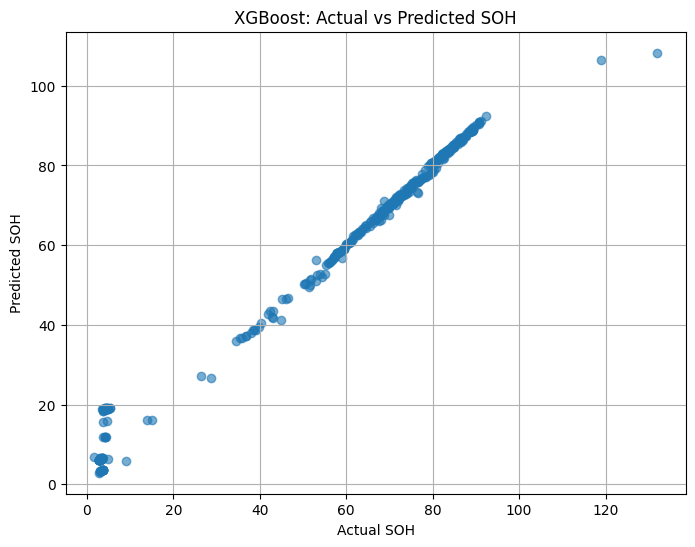

In [387]:
import matplotlib.pyplot as plt

print("=" * 50)
print("STEP 21: ACTUAL VS PREDICTED SOH")
print("=" * 50)

plt.figure(figsize=(8, 6))

plt.scatter(y_test_group, y_pred_xgb, alpha=0.6)

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("XGBoost: Actual vs Predicted SOH")

plt.grid(True)
plt.show()

STEP 22: FEATURE IMPORTANCE
            Feature  Importance
6          Capacity    0.420730
7  Discharge_Energy    0.413424
3   Max_Temperature    0.074989
5    Discharge_Time    0.064285
2       Avg_Current    0.020434
1       Avg_Voltage    0.003517
4       Min_Voltage    0.002141
0             Cycle    0.000479


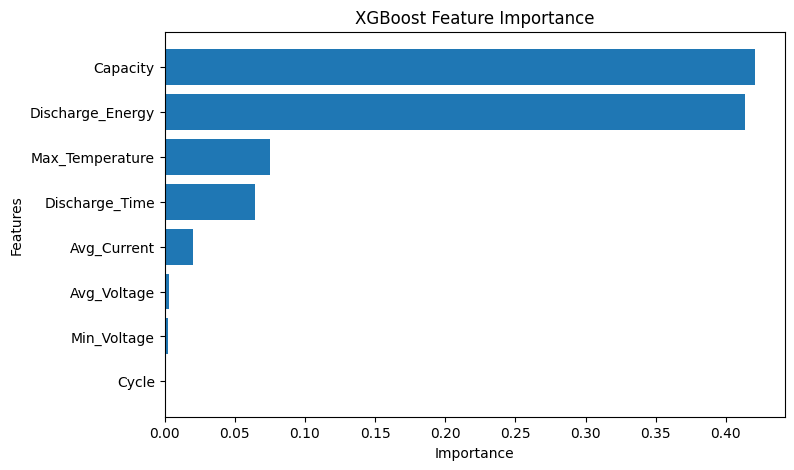

In [388]:
print("=" * 50)
print("STEP 22: FEATURE IMPORTANCE")
print("=" * 50)

importance_df = pd.DataFrame({
    "Feature": X_train_group.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [389]:
from sklearn.ensemble import GradientBoostingRegressor

print("=" * 50)
print("STEP 23: GRADIENT BOOSTING TRAINING")
print("=" * 50)

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_group, y_train_group)

print("Gradient Boosting Model Trained Successfully!")

STEP 23: GRADIENT BOOSTING TRAINING
Gradient Boosting Model Trained Successfully!


In [390]:
print("=" * 50)
print("STEP 24: GRADIENT BOOSTING EVALUATION")
print("=" * 50)

y_pred_gb = gb_model.predict(X_test_group)

mae_gb = mean_absolute_error(y_test_group, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test_group, y_pred_gb))
r2_gb = r2_score(y_test_group, y_pred_gb)

print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

STEP 24: GRADIENT BOOSTING EVALUATION
MAE: 0.936121292058339
RMSE: 2.6850801625315484
R2 Score: 0.9927833518473078


In [391]:
print("=" * 50)
print("STEP 25: FINAL MODEL COMPARISON")
print("=" * 50)

final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_group,
        mae_xgb,
        mae_gb
    ],
    "RMSE": [
        rmse_group,
        rmse_xgb,
        rmse_gb
    ],
    "R2 Score": [
        r2_group,
        r2_xgb,
        r2_gb
    ]
})

final_comparison

STEP 25: FINAL MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
0,Random Forest,1.427631,4.654189,0.978318
1,XGBoost,2.073319,4.602910,0.978793
2,Gradient Boosting,0.936121,2.685080,0.992783


In [392]:
print("=" * 50)
print("STEP 26: SORT BATTERY DATA")
print("=" * 50)

feature_df = clean_df.copy()

feature_df = feature_df.sort_values(
    by=["Battery_ID", "Cycle"]
).reset_index(drop=True)

print("Data sorted successfully!")
print(feature_df[["Battery_ID", "Cycle", "SOH"]].head(10))

STEP 26: SORT BATTERY DATA
Data sorted successfully!
  Battery_ID  Cycle        SOH
0      B0005      2  92.824371
1      B0005      4  92.316362
2      B0005      6  91.767460
3      B0005      8  91.763126
4      B0005     10  91.732275
5      B0005     12  91.783083
6      B0005     14  91.757307
7      B0005     16  91.287840
8      B0005     18  91.238693
9      B0005     20  91.230663


In [393]:
print("=" * 50)
print("STEP 27: PREVIOUS SOH FEATURE")
print("=" * 50)

feature_df["Previous_SOH"] = (
    feature_df.groupby("Battery_ID")["SOH"].shift(1)
)

print(
    feature_df[
        ["Battery_ID", "Cycle", "SOH", "Previous_SOH"]
    ].head(15)
)

STEP 27: PREVIOUS SOH FEATURE
   Battery_ID  Cycle        SOH  Previous_SOH
0       B0005      2  92.824371           NaN
1       B0005      4  92.316362     92.824371
2       B0005      6  91.767460     92.316362
3       B0005      8  91.763126     91.767460
4       B0005     10  91.732275     91.763126
5       B0005     12  91.783083     91.732275
6       B0005     14  91.757307     91.783083
7       B0005     16  91.287840     91.757307
8       B0005     18  91.238693     91.287840
9       B0005     20  91.230663     91.238693
10      B0005     22  91.230978     91.230663
11      B0005     25  90.710097     91.230978
12      B0005     27  90.687608     90.710097
13      B0005     29  90.672025     90.687608
14      B0005     31  90.129900     90.672025


In [394]:
print("=" * 50)
print("STEP 28: SOH DROP PER CYCLE")
print("=" * 50)

feature_df["SOH_Drop"] = (
    feature_df["Previous_SOH"] - feature_df["SOH"]
)

print(
    feature_df[
        ["Battery_ID", "Cycle", "SOH",
         "Previous_SOH", "SOH_Drop"]
    ].head(15)
)

STEP 28: SOH DROP PER CYCLE
   Battery_ID  Cycle        SOH  Previous_SOH  SOH_Drop
0       B0005      2  92.824371           NaN       NaN
1       B0005      4  92.316362     92.824371  0.508009
2       B0005      6  91.767460     92.316362  0.548903
3       B0005      8  91.763126     91.767460  0.004333
4       B0005     10  91.732275     91.763126  0.030851
5       B0005     12  91.783083     91.732275 -0.050808
6       B0005     14  91.757307     91.783083  0.025776
7       B0005     16  91.287840     91.757307  0.469468
8       B0005     18  91.238693     91.287840  0.049147
9       B0005     20  91.230663     91.238693  0.008029
10      B0005     22  91.230978     91.230663 -0.000314
11      B0005     25  90.710097     91.230978  0.520881
12      B0005     27  90.687608     90.710097  0.022489
13      B0005     29  90.672025     90.687608  0.015583
14      B0005     31  90.129900     90.672025  0.542124


In [395]:
print("=" * 50)
print("STEP 29: ROLLING MEAN SOH")
print("=" * 50)

feature_df["Rolling_Mean_SOH"] = (
    feature_df.groupby("Battery_ID")["SOH"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

print(
    feature_df[
        ["Battery_ID", "Cycle", "SOH", "Rolling_Mean_SOH"]
    ].head(15)
)

STEP 29: ROLLING MEAN SOH
   Battery_ID  Cycle        SOH  Rolling_Mean_SOH
0       B0005      2  92.824371         92.824371
1       B0005      4  92.316362         92.570367
2       B0005      6  91.767460         92.302731
3       B0005      8  91.763126         91.948983
4       B0005     10  91.732275         91.754287
5       B0005     12  91.783083         91.759495
6       B0005     14  91.757307         91.757555
7       B0005     16  91.287840         91.609410
8       B0005     18  91.238693         91.427946
9       B0005     20  91.230663         91.252399
10      B0005     22  91.230978         91.233445
11      B0005     25  90.710097         91.057246
12      B0005     27  90.687608         90.876227
13      B0005     29  90.672025         90.689910
14      B0005     31  90.129900         90.496511


In [396]:
print("=" * 50)
print("STEP 30: PREVIOUS ROLLING MEAN SOH")
print("=" * 50)

feature_df["Rolling_Mean_SOH"] = (
    feature_df.groupby("Battery_ID")["SOH"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=3, min_periods=1
        ).mean()
    )
)

print(
    feature_df[
        ["Battery_ID", "Cycle", "SOH", "Rolling_Mean_SOH"]
    ].head(15)
)

STEP 30: PREVIOUS ROLLING MEAN SOH
   Battery_ID  Cycle        SOH  Rolling_Mean_SOH
0       B0005      2  92.824371               NaN
1       B0005      4  92.316362         92.824371
2       B0005      6  91.767460         92.570367
3       B0005      8  91.763126         92.302731
4       B0005     10  91.732275         91.948983
5       B0005     12  91.783083         91.754287
6       B0005     14  91.757307         91.759495
7       B0005     16  91.287840         91.757555
8       B0005     18  91.238693         91.609410
9       B0005     20  91.230663         91.427946
10      B0005     22  91.230978         91.252399
11      B0005     25  90.710097         91.233445
12      B0005     27  90.687608         91.057246
13      B0005     29  90.672025         90.876227
14      B0005     31  90.129900         90.689910


In [397]:
print("=" * 50)
print("STEP 31: CAPACITY LOSS RATE")
print("=" * 50)

feature_df["Previous_Capacity"] = (
    feature_df.groupby("Battery_ID")["Capacity"].shift(1)
)

feature_df["Capacity_Loss"] = (
    feature_df["Previous_Capacity"] - feature_df["Capacity"]
)

print(
    feature_df[
        ["Battery_ID", "Cycle", "Capacity",
         "Previous_Capacity", "Capacity_Loss"]
    ].head(15)
)

STEP 31: CAPACITY LOSS RATE
   Battery_ID  Cycle  Capacity  Previous_Capacity  Capacity_Loss
0       B0005      2  1.856487                NaN            NaN
1       B0005      4  1.846327           1.856487       0.010160
2       B0005      6  1.835349           1.846327       0.010978
3       B0005      8  1.835263           1.835349       0.000087
4       B0005     10  1.834646           1.835263       0.000617
5       B0005     12  1.835662           1.834646      -0.001016
6       B0005     14  1.835146           1.835662       0.000516
7       B0005     16  1.825757           1.835146       0.009389
8       B0005     18  1.824774           1.825757       0.000983
9       B0005     20  1.824613           1.824774       0.000161
10      B0005     22  1.824620           1.824613      -0.000006
11      B0005     25  1.814202           1.824620       0.010418
12      B0005     27  1.813752           1.814202       0.000450
13      B0005     29  1.813440           1.813752       0.0003

In [398]:
print("=" * 50)
print("STEP 32: VOLTAGE VARIATION")
print("=" * 50)

feature_df["Voltage_Variation"] = (
    feature_df["Avg_Voltage"] - feature_df["Min_Voltage"]
)

print(
    feature_df[
        ["Battery_ID", "Cycle", "Avg_Voltage",
         "Min_Voltage", "Voltage_Variation"]
    ].head(15)
)

STEP 32: VOLTAGE VARIATION
   Battery_ID  Cycle  Avg_Voltage  Min_Voltage  Voltage_Variation
0       B0005      2     3.529829     2.612467           0.917361
1       B0005      4     3.537320     2.587209           0.950111
2       B0005      6     3.543737     2.651917           0.891820
3       B0005      8     3.543666     2.592948           0.950718
4       B0005     10     3.542343     2.547420           0.994924
5       B0005     12     3.541335     2.520948           1.020387
6       B0005     14     3.541025     2.487927           1.053098
7       B0005     16     3.554133     2.665205           0.888928
8       B0005     18     3.552936     2.603858           0.949077
9       B0005     20     3.551206     2.552854           0.998352
10      B0005     22     3.549292     2.472448           1.076844
11      B0005     25     3.559759     2.649564           0.910195
12      B0005     27     3.558082     2.572498           0.985584
13      B0005     29     3.555692     2.524989   

In [399]:
print("=" * 50)
print("STEP 33: TEMPERATURE CHANGE")
print("=" * 50)

feature_df["Previous_Temperature"] = (
    feature_df.groupby("Battery_ID")["Max_Temperature"].shift(1)
)

feature_df["Temperature_Change"] = (
    feature_df["Max_Temperature"] -
    feature_df["Previous_Temperature"]
)

print(
    feature_df[
        ["Battery_ID", "Cycle", "Max_Temperature",
         "Previous_Temperature", "Temperature_Change"]
    ].head(15)
)

STEP 33: TEMPERATURE CHANGE
   Battery_ID  Cycle  Max_Temperature  Previous_Temperature  \
0       B0005      2        38.982181                   NaN   
1       B0005      4        39.033398             38.982181   
2       B0005      6        38.818797             39.033398   
3       B0005      8        38.762305             38.818797   
4       B0005     10        38.665393             38.762305   
5       B0005     12        38.751695             38.665393   
6       B0005     14        38.820701             38.751695   
7       B0005     16        38.517130             38.820701   
8       B0005     18        38.526268             38.517130   
9       B0005     20        38.526981             38.526268   
10      B0005     22        38.541434             38.526981   
11      B0005     25        38.521975             38.541434   
12      B0005     27        38.582486             38.521975   
13      B0005     29        38.520294             38.582486   
14      B0005     31       

In [400]:
print("=" * 50)
print("STEP 34: FEATURE VALIDATION")
print("=" * 50)

print("Dataset Shape:", feature_df.shape)

print("\nMissing Values:")
print(feature_df.isnull().sum())

print("\nNew Features:")
print([
    "Previous_SOH",
    "SOH_Drop",
    "Rolling_Mean_SOH",
    "Previous_Capacity",
    "Capacity_Loss",
    "Voltage_Variation",
    "Previous_Temperature",
    "Temperature_Change"
])

STEP 34: FEATURE VALIDATION
Dataset Shape: (2750, 21)

Missing Values:
Battery_ID                0
Cycle                     0
Avg_Voltage               0
Avg_Current               0
Max_Temperature           0
Min_Voltage               0
Discharge_Time            0
Capacity                  0
SOH                       0
Discharge_Energy          0
Past_SOH_Mean            34
Past_Capacity_Mean       34
Past_Temperature_Mean    34
Previous_SOH             34
SOH_Drop                 34
Rolling_Mean_SOH         34
Previous_Capacity        34
Capacity_Loss            34
Voltage_Variation         0
Previous_Temperature     34
Temperature_Change       34
dtype: int64

New Features:
['Previous_SOH', 'SOH_Drop', 'Rolling_Mean_SOH', 'Previous_Capacity', 'Capacity_Loss', 'Voltage_Variation', 'Previous_Temperature', 'Temperature_Change']


In [401]:
print("=" * 50)
print("STEP 35: PREPARE ENGINEERED DATASET")
print("=" * 50)

engineered_df = feature_df.dropna(
    subset=[
        "Previous_SOH",
        "SOH_Drop",
        "Rolling_Mean_SOH",
        "Previous_Capacity",
        "Capacity_Loss",
        "Previous_Temperature",
        "Temperature_Change"
    ]
).copy()

engineered_df.reset_index(drop=True, inplace=True)

print("Original Shape:", feature_df.shape)
print("Engineered Shape:", engineered_df.shape)

print("\nRemaining Missing Values:")
print(engineered_df.isnull().sum().sum())

STEP 35: PREPARE ENGINEERED DATASET
Original Shape: (2750, 21)
Engineered Shape: (2716, 21)

Remaining Missing Values:
0


In [402]:
print("=" * 50)
print("STEP 36: ENGINEERED TRAIN-TEST SPLIT")
print("=" * 50)

from sklearn.model_selection import GroupShuffleSplit

X_eng = engineered_df.drop(
    columns=["SOH", "Battery_ID"]
)

y_eng = engineered_df["SOH"]

groups_eng = engineered_df["Battery_ID"]

gss_eng = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_eng, test_idx_eng = next(
    gss_eng.split(X_eng, y_eng, groups_eng)
)

X_train_eng = X_eng.iloc[train_idx_eng]
X_test_eng = X_eng.iloc[test_idx_eng]

y_train_eng = y_eng.iloc[train_idx_eng]
y_test_eng = y_eng.iloc[test_idx_eng]

print("Training Shape:", X_train_eng.shape)
print("Testing Shape:", X_test_eng.shape)

print(
    "Common Batteries:",
    len(
        set(
            engineered_df.iloc[train_idx_eng]["Battery_ID"]
        ).intersection(
            set(
                engineered_df.iloc[test_idx_eng]["Battery_ID"]
            )
        )
    )
)

STEP 36: ENGINEERED TRAIN-TEST SPLIT
Training Shape: (2301, 19)
Testing Shape: (415, 19)
Common Batteries: 0


In [403]:
print("=" * 50)
print("STEP 37: RANDOM FOREST ENGINEERED")
print("=" * 50)

rf_eng = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_eng.fit(X_train_eng, y_train_eng)

y_pred_rf_eng = rf_eng.predict(X_test_eng)

mae_rf_eng = mean_absolute_error(
    y_test_eng, y_pred_rf_eng
)

rmse_rf_eng = np.sqrt(
    mean_squared_error(y_test_eng, y_pred_rf_eng)
)

r2_rf_eng = r2_score(y_test_eng, y_pred_rf_eng)

print("MAE:", mae_rf_eng)
print("RMSE:", rmse_rf_eng)
print("R2 Score:", r2_rf_eng)

STEP 37: RANDOM FOREST ENGINEERED
MAE: 1.383251022221949
RMSE: 4.379675317937902
R2 Score: 0.9809500185172043


In [404]:
print("=" * 50)
print("STEP 38: XGBOOST ENGINEERED")
print("=" * 50)

xgb_eng = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_eng.fit(X_train_eng, y_train_eng)

y_pred_xgb_eng = xgb_eng.predict(X_test_eng)

mae_xgb_eng = mean_absolute_error(
    y_test_eng, y_pred_xgb_eng
)

rmse_xgb_eng = np.sqrt(
    mean_squared_error(y_test_eng, y_pred_xgb_eng)
)

r2_xgb_eng = r2_score(
    y_test_eng, y_pred_xgb_eng
)

print("MAE:", mae_xgb_eng)
print("RMSE:", rmse_xgb_eng)
print("R2 Score:", r2_xgb_eng)

STEP 38: XGBOOST ENGINEERED
MAE: 1.270250225066046
RMSE: 3.1377292791143447
R2 Score: 0.9902221883582052


In [405]:
!pip install shap -q

In [406]:
import shap

print("SHAP installed successfully!")

SHAP installed successfully!


STEP 40: SHAP EXPLAINABILITY


/tmp/ipykernel_1153/146952686.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


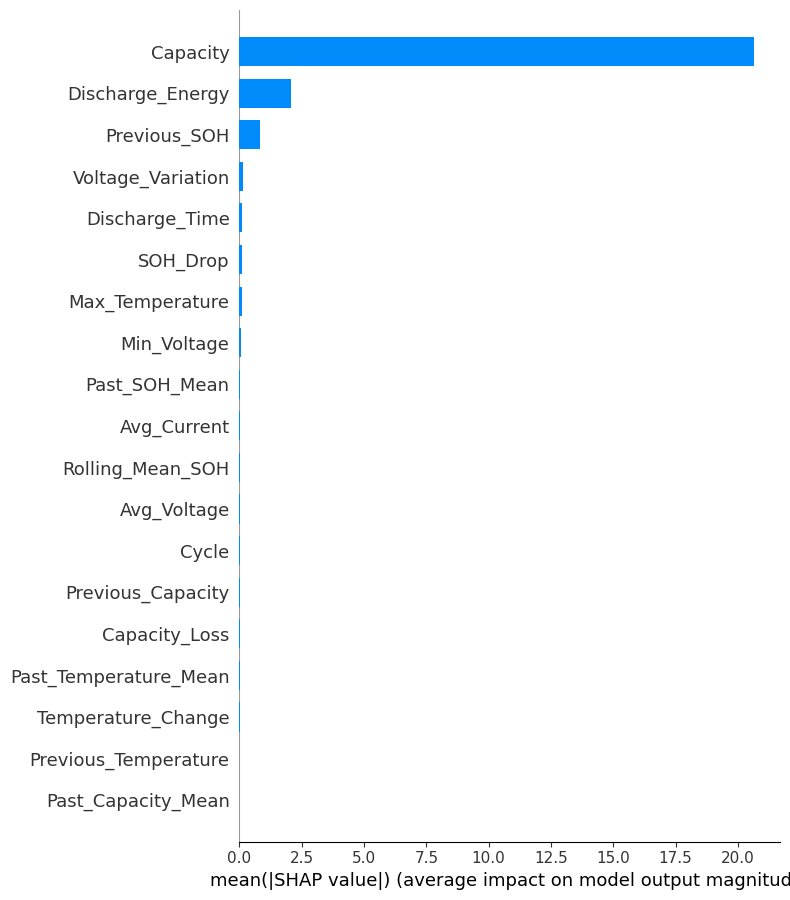

In [407]:
print("=" * 50)
print("STEP 40: SHAP EXPLAINABILITY")
print("=" * 50)

explainer = shap.TreeExplainer(xgb_eng)

shap_values = explainer.shap_values(X_test_eng)

shap.summary_plot(
    shap_values,
    X_test_eng,
    plot_type="bar"
)

In [408]:
print("=" * 50)
print("STEP 41: HEALTH CLASSIFICATION")
print("=" * 50)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

def health_status(soh):
    if soh >= 80:
        return "Healthy"
    elif soh >= 60:
        return "Degrading"
    else:
        return "Critical"

y_class = engineered_df["SOH"].apply(health_status)

X_class = engineered_df.drop(
    columns=["SOH", "Battery_ID"]
)

X_train_c = X_class.iloc[train_idx_eng]
X_test_c = X_class.iloc[test_idx_eng]

y_train_c = y_class.iloc[train_idx_eng]
y_test_c = y_class.iloc[test_idx_eng]

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)

print(classification_report(
    y_test_c,
    y_pred_c,
    zero_division=0
))

STEP 41: HEALTH CLASSIFICATION
              precision    recall  f1-score   support

    Critical       1.00      0.99      1.00       162
   Degrading       0.99      1.00      1.00       136
     Healthy       1.00      1.00      1.00       117

    accuracy                           1.00       415
   macro avg       1.00      1.00      1.00       415
weighted avg       1.00      1.00      1.00       415



In [409]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [410]:
print("=" * 50)
print("STEP 43: CNN SEQUENCE DATA")
print("=" * 50)

import numpy as np

sequence_length = 5

cnn_features = [
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time",
    "Capacity"
]

train_batteries = set(
    engineered_df.iloc[train_idx_eng]["Battery_ID"]
)

test_batteries = set(
    engineered_df.iloc[test_idx_eng]["Battery_ID"]
)

X_train_seq = []
y_train_seq = []

X_test_seq = []
y_test_seq = []

for battery_id, battery_data in feature_df.groupby("Battery_ID"):

    battery_data = battery_data.sort_values("Cycle")

    values = battery_data[cnn_features].values
    targets = battery_data["SOH"].values

    for i in range(sequence_length, len(values)):

        sequence = values[i-sequence_length:i]
        target = targets[i]

        if battery_id in train_batteries:
            X_train_seq.append(sequence)
            y_train_seq.append(target)

        elif battery_id in test_batteries:
            X_test_seq.append(sequence)
            y_test_seq.append(target)

X_train_seq = np.array(X_train_seq)
y_train_seq = np.array(y_train_seq)

X_test_seq = np.array(X_test_seq)
y_test_seq = np.array(y_test_seq)

print("Training Sequence Shape:", X_train_seq.shape)
print("Testing Sequence Shape:", X_test_seq.shape)

STEP 43: CNN SEQUENCE DATA
Training Sequence Shape: (2194, 5, 6)
Testing Sequence Shape: (387, 5, 6)


In [411]:
print("=" * 50)
print("STEP 44: 1D CNN TRAINING")
print("=" * 50)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Input

cnn_model = Sequential([
    Input(shape=(5, 6)),

    Conv1D(32, kernel_size=2, activation="relu"),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(32, activation="relu"),
    Dense(1)
])

cnn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = cnn_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("CNN Training Completed!")

STEP 44: 1D CNN TRAINING
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 14493.9609 - mae: 75.8742 - val_loss: 282.0662 - val_mae: 14.7029
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 772.3820 - mae: 22.1081 - val_loss: 192.9375 - val_mae: 10.2268
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 669.2028 - mae: 21.1839 - val_loss: 189.3967 - val_mae: 9.9088
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 593.5347 - mae: 19.7813 - val_loss: 145.3928 - val_mae: 9.3986
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 489.5291 - mae: 17.9134 - val_loss: 123.8139 - val_mae: 9.1215
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 393.8511 - mae: 16.1555 - val_loss: 100.8617 - val_mae: 7.9725
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 317.7994 - mae: 14.4777 - val_loss: 114.4228 - val_mae: 8.5987
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 273.0265 - mae: 13.4608 - val_loss: 73.4955 - val_mae: 6.6904
Epoc

In [412]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv1D(32, 2, activation="relu", input_shape=(5, 6)),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

cnn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 4, 32)          │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

In [413]:
history = cnn_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 58827.6758 - mae: 172.2636 - val_loss: 241.4805 - val_mae: 10.4223
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 11896.3125 - mae: 79.1254 - val_loss: 750.1277 - val_mae: 26.2332
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3383.5288 - mae: 42.9815 - val_loss: 180.7070 - val_mae: 11.2471
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1452.7832 - mae: 28.2351 - val_loss: 161.4611 - val_mae: 9.5412
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1016.7219 - mae: 23.4823 - val_loss: 178.1765 - val_mae: 9.6386
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 710.3365 - mae: 20.3998 - val_loss: 141.4534 - val_mae: 9.7630
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 701.2941 - mae: 19.9790 - val_loss: 149.6126 - val_mae: 9.1097
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 595.9496 - mae: 18.5295 - val_loss: 118.5487 - val_mae: 8.8279
Epoch 9/30
55/55 ━━━

In [414]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_cnn = cnn_model.predict(X_test_seq).flatten()

mae_cnn = mean_absolute_error(y_test_seq, y_pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_test_seq, y_pred_cnn))
r2_cnn = r2_score(y_test_seq, y_pred_cnn)

print("CNN MAE:", mae_cnn)
print("CNN RMSE:", rmse_cnn)
print("CNN R2 Score:", r2_cnn)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
CNN MAE: 14.87481641318822
CNN RMSE: 20.45161598544272
CNN R2 Score: 0.59060030875476


In [415]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "CNN"],
    "MAE": [1.383251, 1.270250, mae_cnn],
    "RMSE": [4.379675, 3.137729, rmse_cnn],
    "R2 Score": [0.980950, 0.990222, r2_cnn]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,1.383251,4.379675,0.980950
1,XGBoost,1.270250,3.137729,0.990222
2,CNN,14.874816,20.451616,0.590600


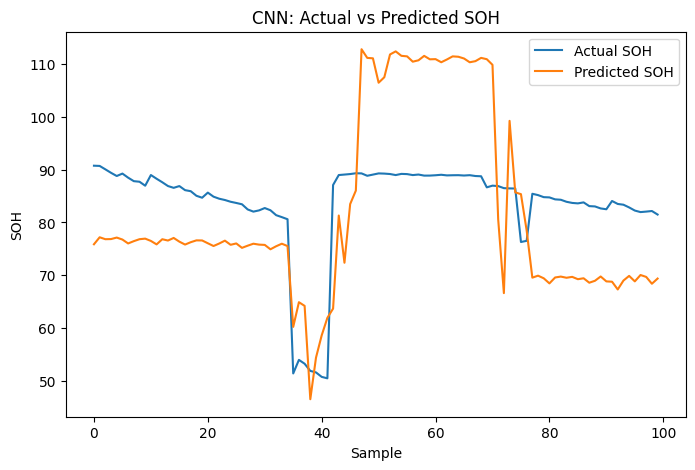

In [416]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(y_test_seq[:100], label="Actual SOH")
plt.plot(y_pred_cnn[:100], label="Predicted SOH")

plt.xlabel("Sample")
plt.ylabel("SOH")
plt.title("CNN: Actual vs Predicted SOH")

plt.legend()
plt.show()

In [417]:
import joblib

joblib.dump(xgb_eng, "battery_soh_xgboost.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [418]:
loaded_model = joblib.load("battery_soh_xgboost.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [419]:
import joblib

# Save model
joblib.dump(xgb_eng, "battery_soh_xgboost.pkl")

# Save feature names
joblib.dump(list(X_eng.columns), "feature_names.pkl")

print("Model and features saved successfully!")

Model and features saved successfully!


In [420]:
xgb_eng.save_model("battery_soh_xgboost.json")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [421]:
from xgboost import XGBRegressor

final_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_group, y_train_group)

final_model.save_model("final_battery_soh_model.json")

joblib.dump(list(X_train_group.columns), "final_feature_names.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [422]:
features = [
    "Cycle",
    "Avg_Voltage",
    "Avg_Current",
    "Max_Temperature",
    "Min_Voltage",
    "Discharge_Time",
    "Capacity",
    "Discharge_Energy"
]

print(clean_df[features].iloc[0])

Cycle                  2.000000
Avg_Voltage            3.529829
Avg_Current           -1.818702
Max_Temperature       38.982181
Min_Voltage            2.612467
Discharge_Time      3690.234000
Capacity               1.856487
Discharge_Energy       6.580616
Name: 0, dtype: float64


In [423]:
!pip install shap

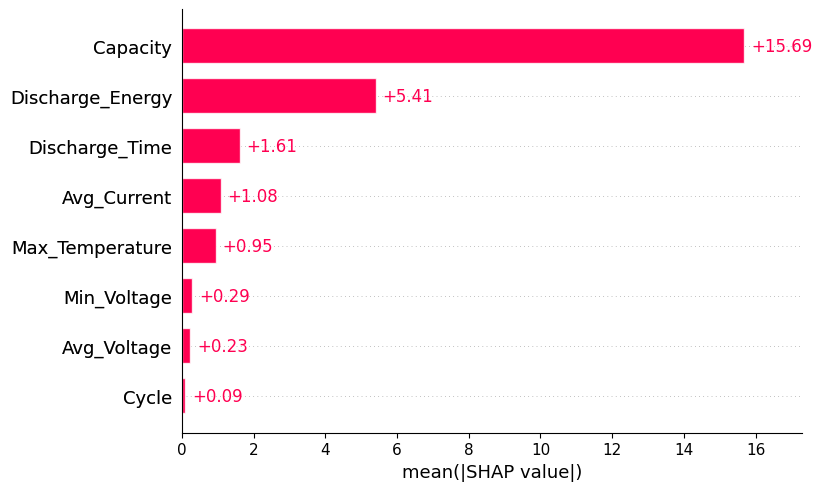

In [424]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values
shap_values = explainer(X_test_group)

# Feature importance plot
shap.plots.bar(shap_values, max_display=10)

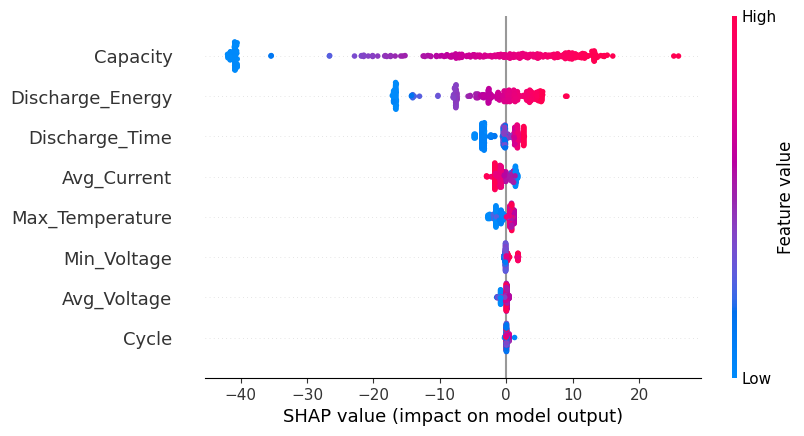

In [425]:
shap.plots.beeswarm(shap_values, max_display=10)

In [426]:
import numpy as np

# Predictions
y_pred = final_model.predict(X_test_group)

# Calculate errors
errors = y_test_group - y_pred

# Standard deviation of errors
error_std = np.std(errors)

# Approximate 95% prediction interval
lower_bound = y_pred - 1.96 * error_std
upper_bound = y_pred + 1.96 * error_std

print("Error Standard Deviation:", round(error_std, 2))
print("Average Interval Width:", round(2 * 1.96 * error_std, 2))

Error Standard Deviation: 4.38
Average Interval Width: 17.19


In [427]:
# Check how many actual values fall inside the interval

coverage = (
    (y_test_group >= lower_bound) &
    (y_test_group <= upper_bound)
).mean() * 100

print("Prediction Interval Coverage:",
      round(coverage, 2), "%")

Prediction Interval Coverage: 91.23 %


In [428]:
def safety_check(predicted_soh, lower, upper):

    if lower < 0 or upper > 100:
        uncertainty_warning = "High uncertainty"
    else:
        uncertainty_warning = "Normal uncertainty"

    if predicted_soh >= 80:
        status = "Healthy"
    elif predicted_soh >= 60:
        status = "Degrading"
    else:
        status = "Critical"

    print("Predicted SOH:", round(predicted_soh, 2), "%")
    print("SOH Range:", round(lower, 2), "% to", round(upper, 2), "%")
    print("Battery Status:", status)
    print("Uncertainty:", uncertainty_warning)


# Test first battery prediction
safety_check(
    y_pred[0],
    lower_bound[0],
    upper_bound[0]
)

Predicted SOH: 84.66 %
SOH Range: 76.07 % to 93.26 %
Battery Status: Healthy
Uncertainty: Normal uncertainty


In [429]:
# Calculate maximum cycle for each battery

rul_df = clean_df.copy()

max_cycles = (
    rul_df.groupby("Battery_ID")["Cycle"]
    .max()
    .reset_index()
)

max_cycles.columns = ["Battery_ID", "Max_Cycle"]

# Merge maximum cycle
rul_df = rul_df.merge(max_cycles, on="Battery_ID")

# Calculate Remaining Useful Life
rul_df["RUL"] = rul_df["Max_Cycle"] - rul_df["Cycle"]

print(rul_df[["Battery_ID", "Cycle", "Max_Cycle", "RUL"]].head())

  Battery_ID  Cycle  Max_Cycle  RUL
0      B0005      2        614  612
1      B0005      4        614  610
2      B0005      6        614  608
3      B0005      8        614  606
4      B0005     10        614  604


In [430]:
# Prepare RUL dataset

rul_model_df = rul_df.drop(
    columns=["Battery_ID", "SOH", "Max_Cycle"]
).copy()

X_rul = rul_model_df.drop(columns=["RUL"])
y_rul = rul_model_df["RUL"]

print("Features:", X_rul.columns.tolist())
print("X shape:", X_rul.shape)
print("y shape:", y_rul.shape)

Features: ['Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'Discharge_Energy', 'Past_SOH_Mean', 'Past_Capacity_Mean', 'Past_Temperature_Mean']
X shape: (2750, 11)
y shape: (2750,)


In [431]:
# Remove historical mean features
# to reduce data leakage

rul_model_df = rul_df.drop(
    columns=[
        "Battery_ID",
        "SOH",
        "Max_Cycle",
        "Past_SOH_Mean",
        "Past_Capacity_Mean",
        "Past_Temperature_Mean"
    ]
).copy()

X_rul = rul_model_df.drop(columns=["RUL"])
y_rul = rul_model_df["RUL"]

print("Features:", X_rul.columns.tolist())
print("X shape:", X_rul.shape)
print("y shape:", y_rul.shape)

Features: ['Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'Discharge_Energy']
X shape: (2750, 8)
y shape: (2750,)


In [432]:
from sklearn.model_selection import GroupShuffleSplit

groups_rul = rul_df["Battery_ID"]

gss_rul = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_rul, test_idx_rul = next(
    gss_rul.split(X_rul, y_rul, groups_rul)
)

X_train_rul = X_rul.iloc[train_idx_rul]
X_test_rul = X_rul.iloc[test_idx_rul]

y_train_rul = y_rul.iloc[train_idx_rul]
y_test_rul = y_rul.iloc[test_idx_rul]

print("Train shape:", X_train_rul.shape)
print("Test shape:", X_test_rul.shape)

print(
    "Common batteries:",
    len(
        set(rul_df.iloc[train_idx_rul]["Battery_ID"]) &
        set(rul_df.iloc[test_idx_rul]["Battery_ID"])
    )
)

Train shape: (2328, 8)
Test shape: (422, 8)
Common batteries: 0


In [433]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_rul = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_rul.fit(X_train_rul, y_train_rul)

y_pred_rul = rf_rul.predict(X_test_rul)

mae_rul = mean_absolute_error(y_test_rul, y_pred_rul)
rmse_rul = np.sqrt(mean_squared_error(y_test_rul, y_pred_rul))
r2_rul = r2_score(y_test_rul, y_pred_rul)

print("RUL Random Forest Results")
print("MAE:", round(mae_rul, 4))
print("RMSE:", round(rmse_rul, 4))
print("R² Score:", round(r2_rul, 4))

RUL Random Forest Results
MAE: 33.7566
RMSE: 62.4194
R² Score: 0.3055


In [434]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_rul = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_rul.fit(X_train_rul, y_train_rul)

y_pred_gb_rul = gb_rul.predict(X_test_rul)

print("RUL Gradient Boosting Results")
print("MAE:", round(mean_absolute_error(y_test_rul, y_pred_gb_rul), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_rul, y_pred_gb_rul)), 4))
print("R² Score:", round(r2_score(y_test_rul, y_pred_gb_rul), 4))

RUL Gradient Boosting Results
MAE: 33.9533
RMSE: 60.4851
R² Score: 0.3478


In [435]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_rul = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_rul.fit(X_train_rul, y_train_rul)

y_pred_xgb_rul = xgb_rul.predict(X_test_rul)

print("RUL XGBoost Results")
print("MAE:", round(mean_absolute_error(y_test_rul, y_pred_xgb_rul), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_rul, y_pred_xgb_rul)), 4))
print("R² Score:", round(r2_score(y_test_rul, y_pred_xgb_rul), 4))

RUL XGBoost Results
MAE: 30.6848
RMSE: 57.4211
R² Score: 0.4122


In [436]:
# Create health status labels

classification_df = clean_df.copy()

classification_df["Health_Status"] = classification_df["SOH"].apply(
    lambda x: "Healthy" if x >= 80
    else "Degrading" if x >= 60
    else "Critical"
)

print(classification_df["Health_Status"].value_counts())

Health_Status
Degrading    1040
Healthy       938
Critical      772
Name: count, dtype: int64


In [438]:
valid_rows = X_class.notna().all(axis=1)

X_class_clean = X_class.loc[valid_rows].copy()
y_class_clean = y_class.loc[valid_rows].copy()

print("Clean X shape:", X_class_clean.shape)
print("Clean y shape:", y_class_clean.shape)

Clean X shape: (2716, 19)
Clean y shape: (2716,)


In [439]:
print(X_class_clean.columns.tolist())

['Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'Discharge_Energy', 'Past_SOH_Mean', 'Past_Capacity_Mean', 'Past_Temperature_Mean', 'Previous_SOH', 'SOH_Drop', 'Rolling_Mean_SOH', 'Previous_Capacity', 'Capacity_Loss', 'Voltage_Variation', 'Previous_Temperature', 'Temperature_Change']


In [440]:
classification_features = [
    'Cycle',
    'Avg_Voltage',
    'Avg_Current',
    'Max_Temperature',
    'Min_Voltage',
    'Discharge_Time',
    'Capacity',
    'Discharge_Energy'
]

X_class_final = X_class_clean[classification_features].copy()

print("Final X shape:", X_class_final.shape)
print("Features:", X_class_final.columns.tolist())

Final X shape: (2716, 8)
Features: ['Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'Discharge_Energy']


In [442]:
groups_class = master_df.loc[X_class_clean.index, "Battery_ID"]

print("Groups shape:", groups_class.shape)
print("Number of batteries:", groups_class.nunique())

Groups shape: (2716,)
Number of batteries: 34


In [443]:
# Remove rows containing missing values

valid_rows = X_class.notna().all(axis=1)

X_class_clean = X_class[valid_rows].copy()
y_class_clean = y_class[valid_rows].copy()
groups_class_clean = groups_class[valid_rows].copy()

print("Clean X shape:", X_class_clean.shape)
print("Clean y shape:", y_class_clean.shape)

Clean X shape: (2716, 19)
Clean y shape: (2716,)


In [444]:
from sklearn.model_selection import GroupShuffleSplit

gss_class = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_class, test_idx_class = next(
    gss_class.split(
        X_class_clean,
        y_class_clean,
        groups_class_clean
    )
)

X_train_class = X_class_clean.iloc[train_idx_class]
X_test_class = X_class_clean.iloc[test_idx_class]

y_train_class = y_class_clean.iloc[train_idx_class]
y_test_class = y_class_clean.iloc[test_idx_class]

print("Train shape:", X_train_class.shape)
print("Test shape:", X_test_class.shape)

print(
    "Common batteries:",
    len(
        set(groups_class_clean.iloc[train_idx_class]) &
        set(groups_class_clean.iloc[test_idx_class])
    )
)

Train shape: (2283, 19)
Test shape: (433, 19)
Common batteries: 0


In [445]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_class)
X_test_scaled = scaler.transform(X_test_class)

# Train model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train_class)

# Predict
y_pred_class = lr_model.predict(X_test_scaled)

# Results
print("Accuracy:",
      round(accuracy_score(y_test_class, y_pred_class), 4))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

Accuracy: 0.9769

Classification Report:
              precision    recall  f1-score   support

    Critical       0.99      0.98      0.99       200
   Degrading       0.96      0.96      0.96       130
     Healthy       0.96      0.99      0.98       103

    accuracy                           0.98       433
   macro avg       0.97      0.98      0.98       433
weighted avg       0.98      0.98      0.98       433



In [446]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_model.fit(X_train_class, y_train_class)

y_pred_dt = dt_model.predict(X_test_class)

print("Decision Tree Accuracy:",
      round(accuracy_score(y_test_class, y_pred_dt), 4))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_dt))

Decision Tree Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       200
   Degrading       1.00      1.00      1.00       130
     Healthy       1.00      1.00      1.00       103

    accuracy                           1.00       433
   macro avg       1.00      1.00      1.00       433
weighted avg       1.00      1.00      1.00       433



In [447]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_class = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_class.fit(X_train_class, y_train_class)

y_pred_rf_class = rf_class.predict(X_test_class)

print("Random Forest Accuracy:",
      round(accuracy_score(y_test_class, y_pred_rf_class), 4))

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_rf_class))

Random Forest Accuracy: 0.9977

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      0.99      1.00       200
   Degrading       0.99      1.00      1.00       130
     Healthy       1.00      1.00      1.00       103

    accuracy                           1.00       433
   macro avg       1.00      1.00      1.00       433
weighted avg       1.00      1.00      1.00       433



In [449]:
from sklearn.ensemble import IsolationForest

# Train anomaly detection model
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

# Train using final 8 features
iso_model.fit(X_class_final)

# Predict anomalies
anomaly_labels = iso_model.predict(X_class_final)

# Create result dataframe using the same rows
anomaly_df = classification_df.loc[X_class_final.index].copy()

anomaly_df["Anomaly"] = anomaly_labels

print(anomaly_df["Anomaly"].value_counts())

print(
    "\nAnomalies detected:",
    (anomaly_labels == -1).sum()
)

Anomaly
 1    2580
-1     136
Name: count, dtype: int64

Anomalies detected: 136


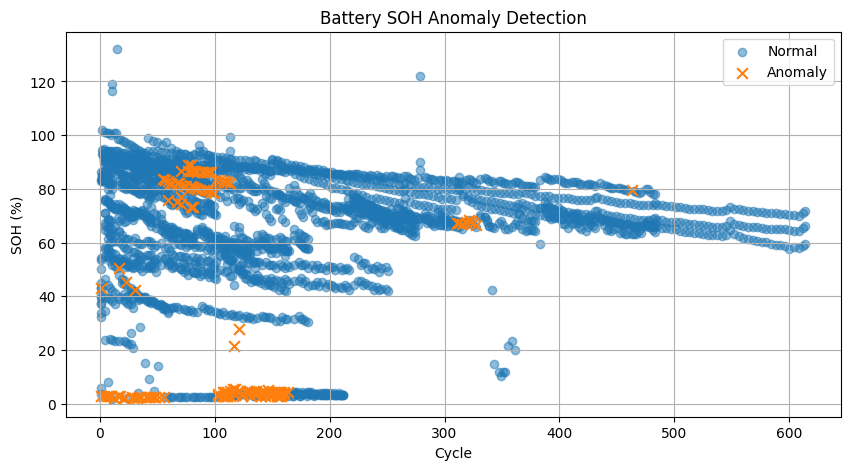

In [450]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

normal = anomaly_df[anomaly_df["Anomaly"] == 1]
anomalies = anomaly_df[anomaly_df["Anomaly"] == -1]

plt.scatter(
    normal["Cycle"],
    normal["SOH"],
    label="Normal",
    alpha=0.5
)

plt.scatter(
    anomalies["Cycle"],
    anomalies["SOH"],
    label="Anomaly",
    marker="x",
    s=60
)

plt.xlabel("Cycle")
plt.ylabel("SOH (%)")
plt.title("Battery SOH Anomaly Detection")
plt.legend()
plt.grid(True)
plt.show()

In [451]:
from sklearn.model_selection import GroupKFold, cross_val_score
from xgboost import XGBRegressor
import numpy as np

group_kfold = GroupKFold(n_splits=5)

xgb_cv = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    xgb_cv,
    X_group,
    y_group,
    cv=group_kfold,
    groups=groups,
    scoring="r2",
    n_jobs=-1
)

print("GroupKFold R² Scores:", cv_scores)
print("Mean R² Score:", round(np.mean(cv_scores), 4))

GroupKFold R² Scores: [0.96478245 0.99394122 0.9838903  0.98919167 0.99650519]
Mean R² Score: 0.9857


In [481]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from xgboost import XGBRegressor
import numpy as np

logo = LeaveOneGroupOut()

xgb_logo = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

logo_scores = cross_val_score(
    xgb_logo,
    X_group,
    y_group,
    cv=logo,
    groups=groups,
    scoring="r2",
    n_jobs=-1
)

print("Leave-One-Battery-Out R² Scores:", logo_scores)
print("Mean R² Score:", round(np.mean(logo_scores), 4))
print("Minimum R² Score:", round(np.min(logo_scores), 4))

Leave-One-Battery-Out R² Scores: [0.99211883 0.89125956 0.99463155 0.99631216 0.80661314 0.98855846
 0.87972478 0.89747628 0.98867825 0.97768464 0.9923772  0.88156127
 0.9903423  0.9365078  0.80535179 0.97196867 0.99479925 0.97019158
 0.99156162 0.90805932 0.99992291 0.96451264 0.61913452 0.97093359
 0.99532036 0.99291056 0.99382904 0.97745066 0.99572497 0.99125083
 0.66026349 0.68006475 0.94415785 0.88100427]
Mean R² Score: 0.9271
Minimum R² Score: 0.6191


In [480]:
# Identify each test battery and its R² score

logo_results = []

for (train_idx, test_idx), score in zip(
    logo.split(X_group, y_group, groups),
    logo_scores
):
    battery_id = groups.iloc[test_idx].iloc[0]

    logo_results.append({
        "Battery_ID": battery_id,
        "R2_Score": score
    })

logo_results_df = pd.DataFrame(logo_results)

# Sort from weakest to strongest performance
logo_results_df = logo_results_df.sort_values(
    by="R2_Score"
)

print(logo_results_df.to_string(index=False))

Battery_ID  R2_Score
     B0047  0.985507
     B0005  1.000000
     B0007  1.000000
     B0006  1.000000
     B0025  1.000000
     B0026  1.000000
     B0027  1.000000
     B0018  1.000000
     B0029  1.000000
     B0030  1.000000
     B0031  1.000000
     B0032  1.000000
     B0033  1.000000
     B0034  1.000000
     B0036  1.000000
     B0028  1.000000
     B0038  1.000000
     B0039  1.000000
     B0041  1.000000
     B0040  1.000000
     B0043  1.000000
     B0044  1.000000
     B0045  1.000000
     B0042  1.000000
     B0046  1.000000
     B0048  1.000000
     B0049  1.000000
     B0050  1.000000
     B0051  1.000000
     B0052  1.000000
     B0053  1.000000
     B0054  1.000000
     B0055  1.000000
     B0056  1.000000


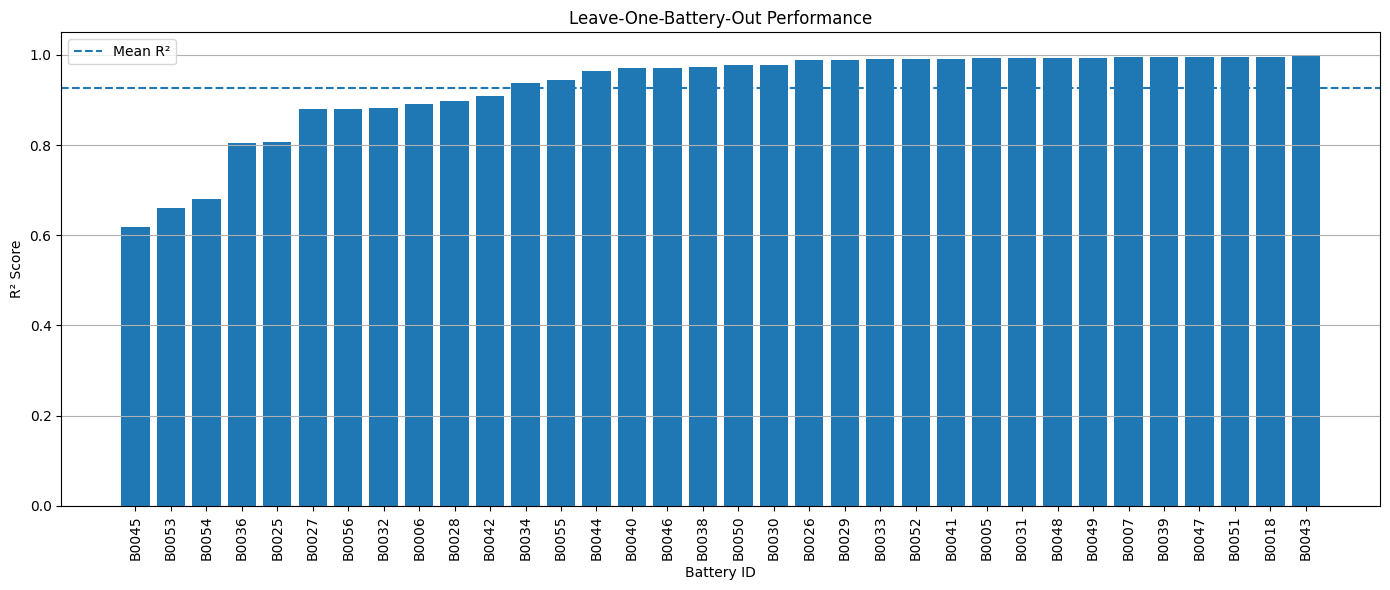

In [454]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.bar(
    logo_results_df["Battery_ID"],
    logo_results_df["R2_Score"]
)

plt.axhline(
    y=0.9271,
    linestyle="--",
    label="Mean R²"
)

plt.xlabel("Battery ID")
plt.ylabel("R² Score")
plt.title("Leave-One-Battery-Out Performance")
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [455]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

lstm_model = Sequential([
    LSTM(32, input_shape=(5, 6)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_lstm = lstm_model.predict(X_test_seq).flatten()

mae_lstm = np.mean(np.abs(y_test_seq - y_pred_lstm))
rmse_lstm = np.sqrt(np.mean((y_test_seq - y_pred_lstm) ** 2))

print("LSTM MAE:", round(mae_lstm, 4))
print("LSTM RMSE:", round(rmse_lstm, 4))

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 5408.1201 - mae: 70.5356 - val_loss: 2662.4453 - val_mae: 51.1370
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4910.8530 - mae: 67.1098 - val_loss: 2200.6887 - val_mae: 46.3927
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3926.5764 - mae: 59.9976 - val_loss: 1320.2578 - val_mae: 35.6764
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2726.0813 - mae: 49.8451 - val_loss: 601.3177 - val_mae: 23.5344
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1705.0819 - mae: 39.1415 - val_loss: 167.7061 - val_mae: 11.3064
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 993.9849 - mae: 29.2803 - val_loss: 47.4560 - val_mae: 5.5215
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 641.3934 - mae: 21.8942 - val_loss: 114.7256 - val_mae: 8.9522
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 495.3914 - mae: 17.6634 - val_loss: 246.5875 - val_mae: 14.2490
Epoch 9/30
55/55 ━━━━━━━

In [456]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import numpy as np

gru_model = Sequential([
    GRU(32, input_shape=(5, 6)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_gru = gru_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_gru = gru_model.predict(X_test_seq).flatten()

mae_gru = np.mean(np.abs(y_test_seq - y_pred_gru))
rmse_gru = np.sqrt(np.mean((y_test_seq - y_pred_gru) ** 2))

print("GRU MAE:", round(mae_gru, 4))
print("GRU RMSE:", round(rmse_gru, 4))

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 5316.8862 - mae: 69.9108 - val_loss: 2572.6519 - val_mae: 50.2514
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4785.0557 - mae: 66.2597 - val_loss: 2098.1733 - val_mae: 45.2767
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3910.5117 - mae: 59.8815 - val_loss: 1337.4025 - val_mae: 35.8822
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2718.4622 - mae: 49.7315 - val_loss: 594.3085 - val_mae: 23.3850
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1696.5748 - mae: 38.9137 - val_loss: 167.0694 - val_mae: 11.2803
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1026.6866 - mae: 29.4267 - val_loss: 47.6047 - val_mae: 5.5343
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 676.6540 - mae: 22.1202 - val_loss: 122.4885 - val_mae: 9.2976
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 555.5016 - mae: 18.3795 - val_loss: 228.2924 - val_mae: 13.6246
Epoch 9/30
55/

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import numpy as np

gru_model = Sequential([
    GRU(32, input_shape=(5, 6)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_gru = gru_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_gru = gru_model.predict(X_test_seq).flatten()

mae_gru = np.mean(np.abs(y_test_seq - y_pred_gru))
rmse_gru = np.sqrt(np.mean((y_test_seq - y_pred_gru) ** 2))

print("GRU MAE:", round(mae_gru, 4))
print("GRU RMSE:", round(rmse_gru, 4))

In [457]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
)
import numpy as np

cnn_lstm_model = Sequential([
    Input(shape=(5, 6)),
    Conv1D(32, 2, activation="relu"),
    MaxPooling1D(2),
    LSTM(32),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

cnn_lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_cnn_lstm = cnn_lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_cnn_lstm = (
    cnn_lstm_model.predict(X_test_seq).flatten()
)

mae_cnn_lstm = np.mean(
    np.abs(y_test_seq - y_pred_cnn_lstm)
)

rmse_cnn_lstm = np.sqrt(
    np.mean((y_test_seq - y_pred_cnn_lstm) ** 2)
)

print("CNN-LSTM MAE:", round(mae_cnn_lstm, 4))
print("CNN-LSTM RMSE:", round(rmse_cnn_lstm, 4))

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 5393.4331 - mae: 70.4249 - val_loss: 2638.3818 - val_mae: 50.9012
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4835.4849 - mae: 66.5961 - val_loss: 2105.6743 - val_mae: 45.3676
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3938.5549 - mae: 60.0410 - val_loss: 1355.2200 - val_mae: 36.1631
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2759.5764 - mae: 50.1546 - val_loss: 602.9233 - val_mae: 23.5685
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1665.6198 - mae: 38.6139 - val_loss: 139.8115 - val_mae: 10.1395
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 942.5393 - mae: 28.1711 - val_loss: 52.1467 - val_mae: 5.7742
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 593.0601 - mae: 20.4258 - val_loss: 161.7512 - val_mae: 11.0698
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 675.3205 - mae: 21.5775 - val_loss: 99.7408 - val_mae: 8.3581
Epoch 9/30
55/55

In [458]:
from sklearn.metrics import r2_score
import pandas as pd

deep_learning_results = pd.DataFrame({
    "Model": ["CNN", "LSTM", "GRU", "CNN-LSTM"],
    "MAE": [
        np.mean(np.abs(y_test_seq - y_pred_cnn)),
        mae_lstm,
        mae_gru,
        mae_cnn_lstm
    ],
    "RMSE": [
        np.sqrt(np.mean((y_test_seq - y_pred_cnn) ** 2)),
        rmse_lstm,
        rmse_gru,
        rmse_cnn_lstm
    ],
    "R2": [
        r2_score(y_test_seq, y_pred_cnn),
        r2_score(y_test_seq, y_pred_lstm),
        r2_score(y_test_seq, y_pred_gru),
        r2_score(y_test_seq, y_pred_cnn_lstm)
    ]
})

print(deep_learning_results.round(4))

      Model      MAE     RMSE      R2
0       CNN  14.8748  20.4516  0.5906
1      LSTM  15.4430  21.7816  0.5356
2       GRU  23.2966  31.2425  0.0446
3  CNN-LSTM  26.6265  31.0513  0.0563


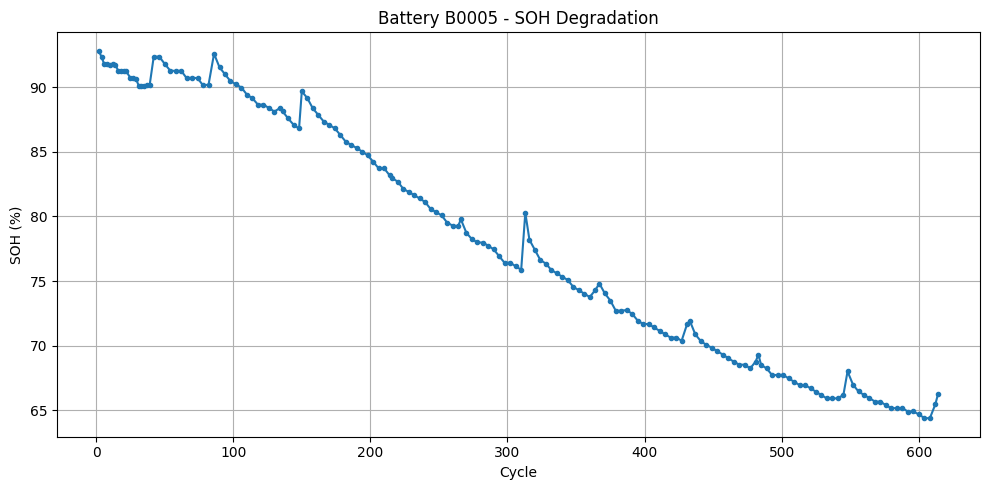

In [459]:
import matplotlib.pyplot as plt

battery_id = "B0005"

battery_data = clean_df[
    clean_df["Battery_ID"] == battery_id
].sort_values("Cycle")

plt.figure(figsize=(10, 5))

plt.plot(
    battery_data["Cycle"],
    battery_data["SOH"],
    marker="o",
    markersize=3
)

plt.xlabel("Cycle")
plt.ylabel("SOH (%)")
plt.title(f"Battery {battery_id} - SOH Degradation")
plt.grid(True)
plt.tight_layout()
plt.show()

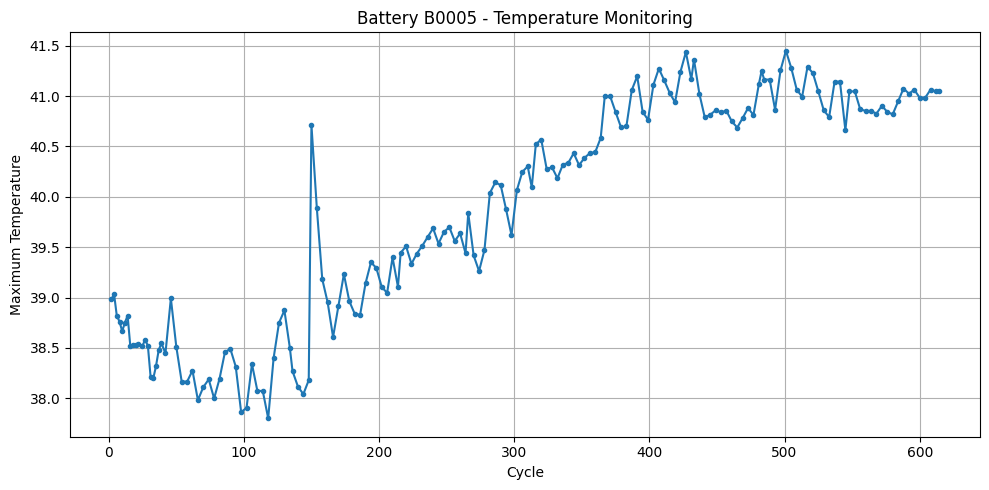

In [460]:
import matplotlib.pyplot as plt

battery_id = "B0005"

battery_data = clean_df[
    clean_df["Battery_ID"] == battery_id
].sort_values("Cycle")

plt.figure(figsize=(10, 5))

plt.plot(
    battery_data["Cycle"],
    battery_data["Max_Temperature"],
    marker="o",
    markersize=3
)

plt.xlabel("Cycle")
plt.ylabel("Maximum Temperature")
plt.title(f"Battery {battery_id} - Temperature Monitoring")
plt.grid(True)
plt.tight_layout()
plt.show()

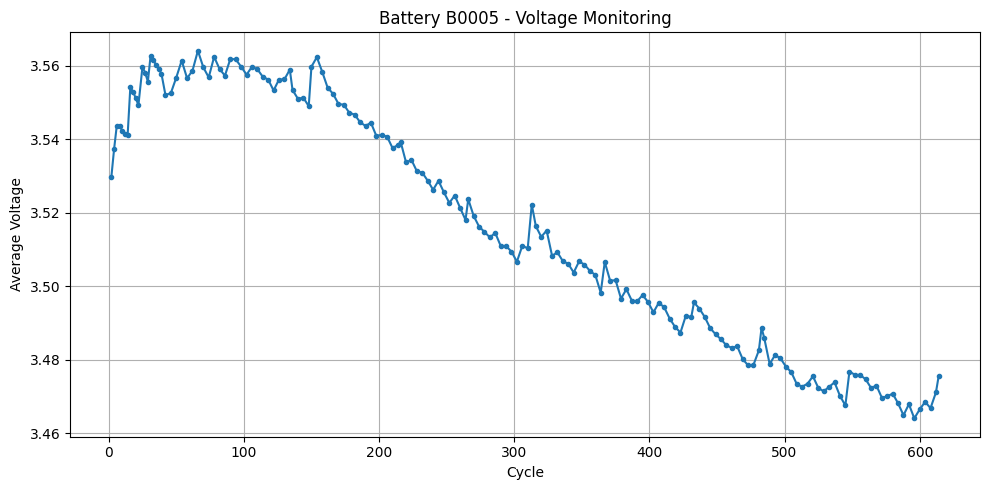

In [461]:
import matplotlib.pyplot as plt

battery_id = "B0005"

battery_data = clean_df[
    clean_df["Battery_ID"] == battery_id
].sort_values("Cycle")

plt.figure(figsize=(10, 5))

plt.plot(
    battery_data["Cycle"],
    battery_data["Avg_Voltage"],
    marker="o",
    markersize=3
)

plt.xlabel("Cycle")
plt.ylabel("Average Voltage")
plt.title(f"Battery {battery_id} - Voltage Monitoring")
plt.grid(True)
plt.tight_layout()
plt.show()

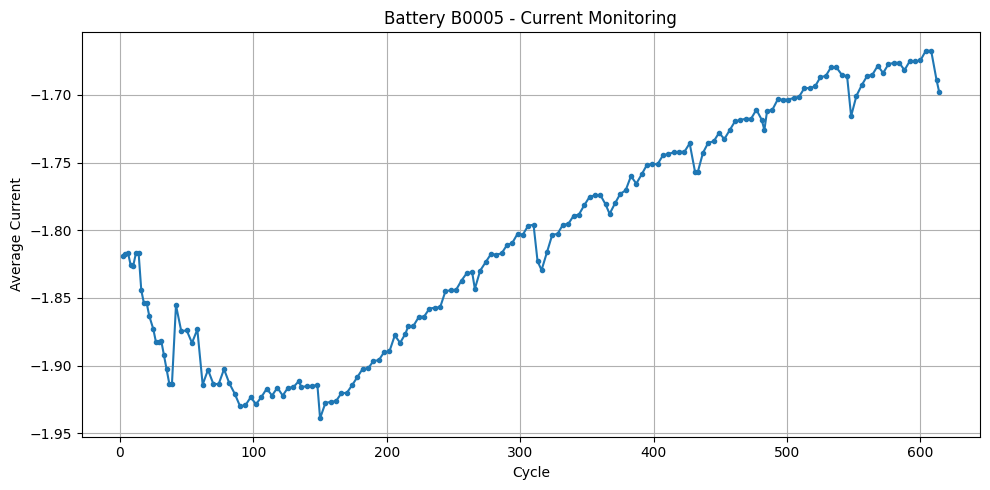

In [462]:
import matplotlib.pyplot as plt

battery_id = "B0005"

battery_data = clean_df[
    clean_df["Battery_ID"] == battery_id
].sort_values("Cycle")

plt.figure(figsize=(10, 5))

plt.plot(
    battery_data["Cycle"],
    battery_data["Avg_Current"],
    marker="o",
    markersize=3
)

plt.xlabel("Cycle")
plt.ylabel("Average Current")
plt.title(f"Battery {battery_id} - Current Monitoring")
plt.grid(True)
plt.tight_layout()
plt.show()

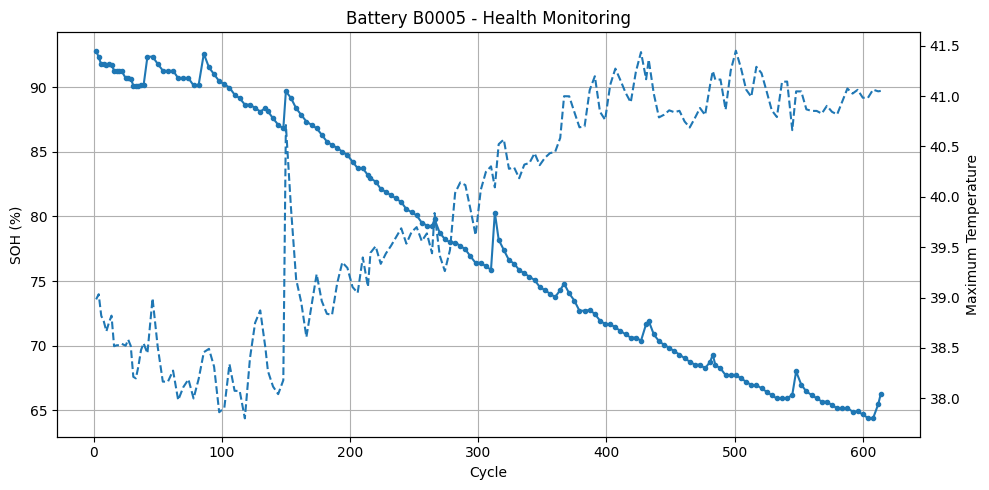

In [479]:
import matplotlib.pyplot as plt

battery_id = "B0005"

battery_data = clean_df[
    clean_df["Battery_ID"] == battery_id
].sort_values("Cycle")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    battery_data["Cycle"],
    battery_data["SOH"],
    marker="o",
    markersize=3,
    label="SOH"
)

ax1.set_xlabel("Cycle")
ax1.set_ylabel("SOH (%)")
ax1.set_title(f"Battery {battery_id} - Health Monitoring")
ax1.grid(True)

ax2 = ax1.twinx()

ax2.plot(
    battery_data["Cycle"],
    battery_data["Max_Temperature"],
    linestyle="--",
    label="Temperature"
)

ax2.set_ylabel("Maximum Temperature")

plt.tight_layout()
plt.show()

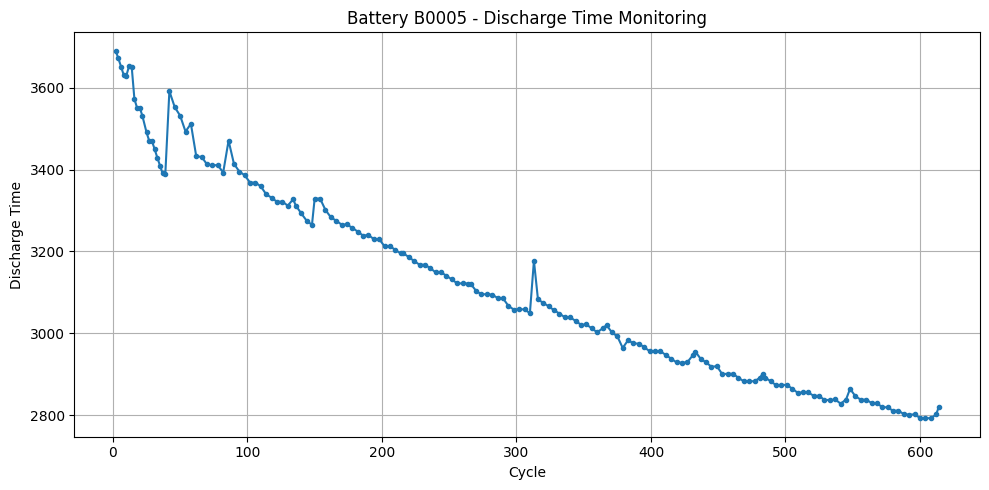

In [464]:
import matplotlib.pyplot as plt

battery_id = "B0005"

battery_data = clean_df[
    clean_df["Battery_ID"] == battery_id
].sort_values("Cycle")

plt.figure(figsize=(10, 5))

plt.plot(
    battery_data["Cycle"],
    battery_data["Discharge_Time"],
    marker="o",
    markersize=3
)

plt.xlabel("Cycle")
plt.ylabel("Discharge Time")
plt.title(f"Battery {battery_id} - Discharge Time Monitoring")
plt.grid(True)
plt.tight_layout()
plt.show()

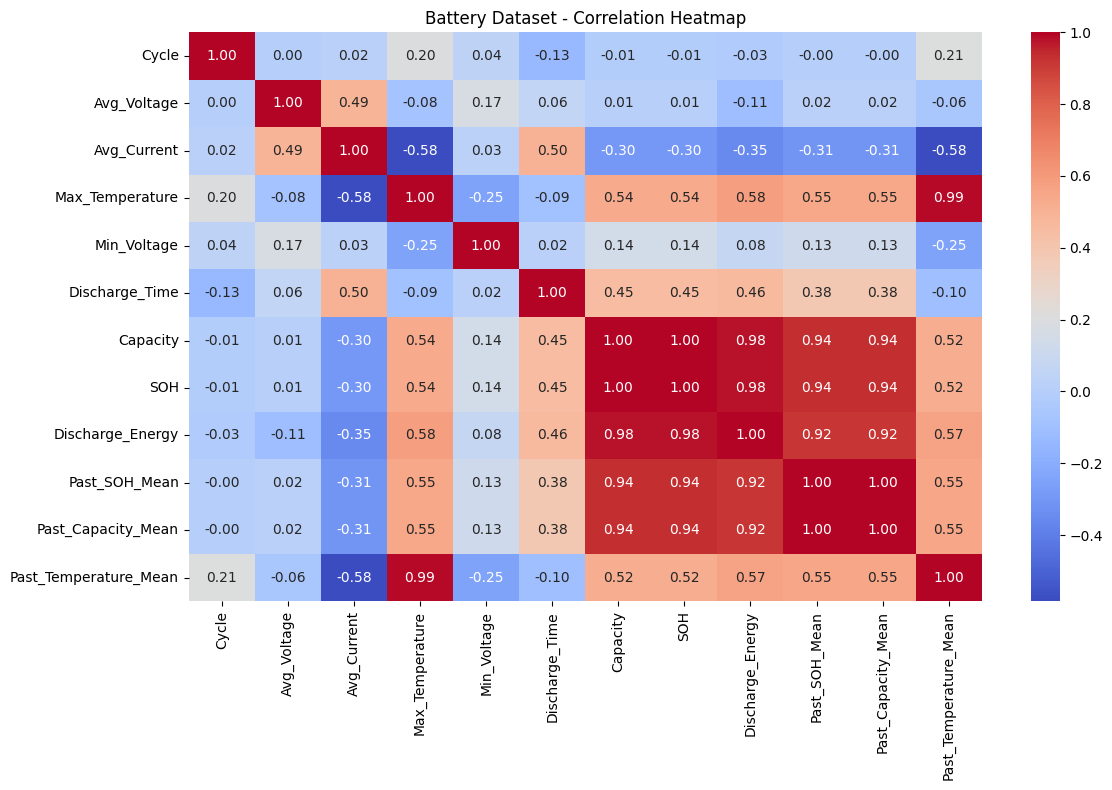

In [465]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_data = clean_df.drop(columns=["Battery_ID"])

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Battery Dataset - Correlation Heatmap")
plt.tight_layout()
plt.show()

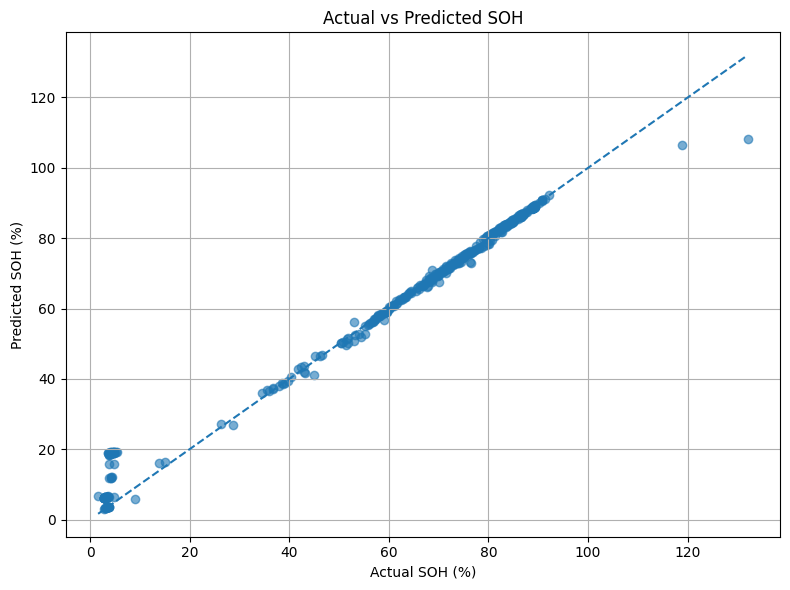

In [466]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_group,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test_group.min(), y_test_group.max()],
    [y_test_group.min(), y_test_group.max()],
    linestyle="--"
)

plt.xlabel("Actual SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Actual vs Predicted SOH")
plt.grid(True)
plt.tight_layout()
plt.show()

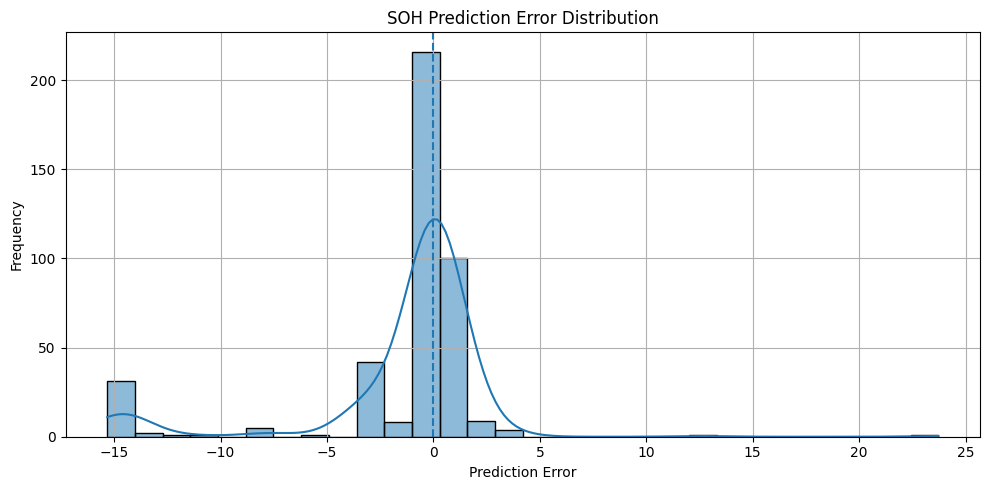

In [467]:
import matplotlib.pyplot as plt
import seaborn as sns

errors = y_test_group - y_pred

plt.figure(figsize=(10, 5))

sns.histplot(
    errors,
    bins=30,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("SOH Prediction Error Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

In [478]:
def battery_safety_risk(temperature, current, voltage, soh):

    risk_score = 0
    warnings = []

    # Temperature check
    if temperature > 45:
        risk_score += 2
        warnings.append("High Temperature")

    # Current check
    if abs(current) > 5:
        risk_score += 2
        warnings.append("Abnormal Current")

    # Voltage check
    if voltage < 2.5 or voltage > 4.3:
        risk_score += 2
        warnings.append("Abnormal Voltage")

    # SOH check
    if soh < 60:
        risk_score += 1
        warnings.append("Low Battery Health")

    # Risk classification
    if risk_score >= 4:
        risk = "HIGH RISK"
    elif risk_score >= 2:
        risk = "MEDIUM RISK"
    else:
        risk = "LOW RISK"

    print("Battery Safety Risk:", risk)
    print("Risk Score:", risk_score)

    if warnings:
        print("Warnings:")
        for warning in warnings:
            print("-", warning)
    else:
        print("No abnormal condition detected.")


battery_safety_risk(
    temperature=50,
    current=6,
    voltage=4.4,
    soh=55
)

Battery Safety Risk: HIGH RISK
Risk Score: 7
Warnings:
- High Temperature
- Abnormal Current
- Abnormal Voltage
- Low Battery Health


In [470]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Battery ID for each clean row
groups_class = classification_df.loc[
    X_class_final.index, "Battery_ID"
]

print("Groups shape:", groups_class.shape)
print("Number of batteries:", groups_class.nunique())

# Battery-wise train/test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X_class_final,
        y_class_clean,
        groups=groups_class
    )
)

X_train = X_class_final.iloc[train_idx]
X_test = X_class_final.iloc[test_idx]

y_train = y_class_clean.iloc[train_idx]
y_test = y_class_clean.iloc[test_idx]

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    "Training batteries:",
    groups_class.iloc[train_idx].nunique()
)

print(
    "Testing batteries:",
    groups_class.iloc[test_idx].nunique()
)

# Final leakage-safe Random Forest
rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

# Evaluation
y_pred = rf_final.predict(X_test)

print("\nFinal Leakage-Safe Classification Results")
print("------------------------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Groups shape: (2716,)
Number of batteries: 34

Training samples: 2294
Testing samples: 422
Training batteries: 27
Testing batteries: 7

Final Leakage-Safe Classification Results
------------------------------------------
Accuracy: 0.9976

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      0.99      1.00       186
   Degrading       0.99      1.00      1.00       132
     Healthy       1.00      1.00      1.00       104

    accuracy                           1.00       422
   macro avg       1.00      1.00      1.00       422
weighted avg       1.00      1.00      1.00       422



In [471]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

logo = LeaveOneGroupOut()

logo_scores = []
battery_results = []

for train_idx, test_idx in logo.split(
    X_class_final,
    y_class_clean,
    groups=groups_class
):

    X_train = X_class_final.iloc[train_idx]
    X_test = X_class_final.iloc[test_idx]

    y_train = y_class_clean.iloc[train_idx]
    y_test = y_class_clean.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = accuracy_score(y_test, y_pred)

    battery_id = groups_class.iloc[test_idx].iloc[0]

    logo_scores.append(score)

    battery_results.append({
        "Battery_ID": battery_id,
        "Accuracy": score
    })

print("Leave-One-Battery-Out Results")
print("--------------------------------")

print("Mean Accuracy:", round(np.mean(logo_scores), 4))
print("Minimum Accuracy:", round(np.min(logo_scores), 4))
print("Maximum Accuracy:", round(np.max(logo_scores), 4))

logo_results_df = pd.DataFrame(battery_results)

print("\nBattery-wise Results:")
display(logo_results_df.sort_values("Accuracy"))

Leave-One-Battery-Out Results
--------------------------------
Mean Accuracy: 0.9996
Minimum Accuracy: 0.9855
Maximum Accuracy: 1.0

Battery-wise Results:


,Battery_ID,Accuracy
24,B0047,0.985507
0,B0005,1.000000
2,B0007,1.000000
1,B0006,1.000000
4,B0025,1.000000
5,B0026,1.000000
6,B0027,1.000000
3,B0018,1.000000
8,B0029,1.000000
9,B0030,1.000000


In [472]:
print("RUL-related variables:")
for name in [
    "X_rul",
    "y_rul",
    "X_rul_clean",
    "y_rul_clean",
    "rul_df",
    "rul_features"
]:
    if name in globals():
        obj = globals()[name]
        print(name, "->", type(obj), getattr(obj, "shape", ""))

RUL-related variables:
X_rul -> <class 'pandas.core.frame.DataFrame'> (2750, 8)
y_rul -> <class 'pandas.core.series.Series'> (2750,)
X_rul_clean -> <class 'pandas.core.frame.DataFrame'> (384, 8)
y_rul_clean -> <class 'pandas.core.series.Series'> (384,)
rul_df -> <class 'pandas.core.frame.DataFrame'> (2750, 15)
rul_features -> <class 'list'> 


In [474]:
print("RUL Dataset Verification")
print("------------------------")

print("X_rul:", X_rul.shape)
print("y_rul:", y_rul.shape)
print("X_rul_clean:", X_rul_clean.shape)
print("y_rul_clean:", y_rul_clean.shape)

print("\nMissing values in X_rul:")
print(X_rul.isna().sum())

print("\nMissing values in y_rul:")
print(y_rul.isna().sum())

print("\nRUL range:")
print("Minimum:", y_rul.min())
print("Maximum:", y_rul.max())

print("\nNumber of batteries:")
print(rul_df["Battery_ID"].nunique())

RUL Dataset Verification
------------------------
X_rul: (2750, 8)
y_rul: (2750,)
X_rul_clean: (384, 8)
y_rul_clean: (384,)

Missing values in X_rul:
Cycle               0
Avg_Voltage         0
Avg_Current         0
Max_Temperature     0
Min_Voltage         0
Discharge_Time      0
Capacity            0
Discharge_Energy    0
dtype: int64

Missing values in y_rul:
0

RUL range:
Minimum: 0
Maximum: 612

Number of batteries:
34


In [475]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Battery groups
groups_rul = rul_df["Battery_ID"]

# Battery-wise train/test split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_rul, y_rul, groups=groups_rul)
)

X_train = X_rul.iloc[train_idx]
X_test = X_rul.iloc[test_idx]

y_train = y_rul.iloc[train_idx]
y_test = y_rul.iloc[test_idx]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("Training batteries:",
      groups_rul.iloc[train_idx].nunique())

print("Testing batteries:",
      groups_rul.iloc[test_idx].nunique())


# Train RUL model
rul_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rul_model.fit(X_train, y_train)

# Prediction
y_pred = rul_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nFinal Leakage-Safe RUL Results")
print("--------------------------------")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R2  :", round(r2, 4))

Training samples: 2328
Testing samples: 422
Training batteries: 27
Testing batteries: 7

Final Leakage-Safe RUL Results
--------------------------------
MAE : 34.0715
RMSE: 63.2689
R2  : 0.2864


In [483]:
print("RUL DF columns:")
print(rul_df.columns.tolist())

RUL DF columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'Discharge_Energy', 'Past_SOH_Mean', 'Past_Capacity_Mean', 'Past_Temperature_Mean', 'Max_Cycle', 'RUL']


In [484]:
# Sort battery-wise and cycle-wise
rul_df = rul_df.sort_values(
    ['Battery_ID', 'Cycle']
).copy()

# Current SOH
rul_df['Current_SOH'] = rul_df['SOH']

# Previous-cycle SOH
rul_df['Previous_SOH'] = (
    rul_df.groupby('Battery_ID')['SOH']
    .shift(1)
)

# SOH degradation
rul_df['SOH_Drop'] = (
    rul_df['Previous_SOH'] - rul_df['SOH']
).fillna(0)

# Previous 5-cycle SOH average
rul_df['SOH_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['SOH']
    .transform(
        lambda x: x.shift(1).rolling(
            5,
            min_periods=1
        ).mean()
    )
)

# Previous 5-cycle capacity average
rul_df['Capacity_Rolling_Mean'] = (
    rul_df.groupby('Battery_ID')['Capacity']
    .transform(
        lambda x: x.shift(1).rolling(
            5,
            min_periods=1
        ).mean()
    )
)

rul_df = rul_df.fillna(0)

print("RUL degradation features created successfully!")

print("\nNew RUL features:")
print([
    'Current_SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Capacity_Rolling_Mean'
])

RUL degradation features created successfully!

New RUL features:
['Current_SOH', 'SOH_Drop', 'SOH_Rolling_Mean', 'Capacity_Rolling_Mean']


In [485]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Final RUL features
rul_features = [
    'Current_SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Capacity_Rolling_Mean',
    'Max_Temperature',
    'Avg_Current',
    'Min_Voltage',
    'Discharge_Time'
]

X_rul = rul_df[rul_features]
y_rul = rul_df['RUL']
groups_rul = rul_df['Battery_ID']

print("Final RUL Dataset")
print("-----------------")
print("X shape:", X_rul.shape)
print("y shape:", y_rul.shape)
print("Number of batteries:", groups_rul.nunique())

logo = LeaveOneGroupOut()

rul_results = []

for train_idx, test_idx in logo.split(
    X_rul,
    y_rul,
    groups_rul
):

    X_train = X_rul.iloc[train_idx]
    X_test = X_rul.iloc[test_idx]

    y_train = y_rul.iloc[train_idx]
    y_test = y_rul.iloc[test_idx]

    rul_model = GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    rul_model.fit(X_train, y_train)

    pred = rul_model.predict(X_test)

    rul_results.append({
        'Battery_ID': groups_rul.iloc[test_idx].iloc[0],
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred) if len(y_test) > 1 else np.nan
    })

rul_results_df = pd.DataFrame(rul_results)

print("\nFINAL RUL MODEL — LEAVE-ONE-BATTERY-OUT")
print("------------------------------------------")

print(rul_results_df.to_string(index=False))

print("\nAverage MAE :", round(rul_results_df['MAE'].mean(), 4))
print("Average RMSE:", round(rul_results_df['RMSE'].mean(), 4))
print("Average R²  :", round(rul_results_df['R2'].mean(), 4))

Final RUL Dataset
-----------------
X shape: (2750, 8)
y shape: (2750,)
Number of batteries: 34

FINAL RUL MODEL — LEAVE-ONE-BATTERY-OUT
------------------------------------------
Battery_ID        MAE       RMSE           R2
     B0005  85.810246 113.027024     0.624283
     B0006  74.088964  93.578933     0.742455
     B0007  37.727664  47.655430     0.933208
     B0018 113.771180 131.322525    -1.097537
     B0025  77.147476  93.028275   -16.135633
     B0026  38.023645  44.307525    -2.887095
     B0027  21.097876  23.287830    -0.073812
     B0028  21.151941  29.413245    -0.712995
     B0029  20.755681  23.507385     0.276705
     B0030  25.817608  29.006837    -0.101304
     B0031  11.292384  13.536054     0.760177
     B0032  15.446553  18.010677     0.575413
     B0033  56.975168  83.950289     0.639955
     B0034  48.311895  64.572771     0.786984
     B0036  89.778433 104.289694     0.444358
     B0038  49.887950 106.991398    -8.580298
     B0039  43.219292  90.976582    -5

In [487]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# RUL features - include Cycle
rul_features_final = [
    'Cycle',
    'Current_SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Capacity_Rolling_Mean',
    'Max_Temperature',
    'Avg_Current',
    'Min_Voltage',
    'Discharge_Time'
]

X_rul_final = rul_df[rul_features_final]
y_rul_final = rul_df['RUL']
groups_rul_final = rul_df['Battery_ID']

logo = LeaveOneGroupOut()

results = []

for train_idx, test_idx in logo.split(
    X_rul_final,
    y_rul_final,
    groups_rul_final
):

    X_train = X_rul_final.iloc[train_idx]
    X_test = X_rul_final.iloc[test_idx]

    y_train = y_rul_final.iloc[train_idx]
    y_test = y_rul_final.iloc[test_idx]

    model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append({
        "Battery_ID": groups_rul_final.iloc[test_idx].iloc[0],
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

print("FINAL RUL VALIDATION")
print("--------------------")
print("Features:", rul_features_final)
print("Batteries:", groups_rul_final.nunique())

print("\nBattery-wise Results:")
print(results_df.to_string(index=False))

print("\nOverall Results")
print("----------------")
print("Average MAE :", round(results_df["MAE"].mean(), 4))
print("Average RMSE:", round(results_df["RMSE"].mean(), 4))
print("Average R2  :", round(results_df["R2"].mean(), 4))

FINAL RUL VALIDATION
--------------------
Features: ['Cycle', 'Current_SOH', 'SOH_Drop', 'SOH_Rolling_Mean', 'Capacity_Rolling_Mean', 'Max_Temperature', 'Avg_Current', 'Min_Voltage', 'Discharge_Time']
Batteries: 34

Battery-wise Results:
Battery_ID        MAE       RMSE           R2
     B0005  76.386926 110.041110     0.643872
     B0006  82.718223 109.599711     0.646723
     B0007  42.593312  53.377504     0.916206
     B0018 132.709823 143.897732    -1.518483
     B0025  83.449067 104.103852   -20.458721
     B0026  32.679639  38.214218    -1.891480
     B0027  11.931213  16.843424     0.438266
     B0028  28.751455  29.979406    -0.779575
     B0029  14.296248  15.824860     0.672217
     B0030  20.863099  25.343231     0.159320
     B0031   7.836740   9.790974     0.874525
     B0032  47.758501  50.599799    -2.351230
     B0033  66.973252  95.149375     0.537487
     B0034  52.755968  68.471288     0.760487
     B0036  80.793505  92.646693     0.561497
     B0038  44.748299 105.

In [489]:
print("Current RUL DF columns:")
print(rul_df.columns.tolist())

Current RUL DF columns:
['Battery_ID', 'Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'SOH', 'Discharge_Energy', 'Past_SOH_Mean', 'Past_Capacity_Mean', 'Past_Temperature_Mean', 'Max_Cycle', 'RUL', 'Current_SOH', 'Previous_SOH', 'SOH_Drop', 'SOH_Rolling_Mean', 'Capacity_Rolling_Mean']


In [491]:
# ==============================
# FINAL RUL VALIDATION DATASET
# ==============================

rul_features = [
    'Cycle',
    'Current_SOH',
    'SOH_Drop',
    'SOH_Rolling_Mean',
    'Capacity_Rolling_Mean',
    'Max_Temperature',
    'Avg_Current',
    'Min_Voltage',
    'Discharge_Time'
]

X_rul_final = rul_df[rul_features].copy()
y_rul_final = rul_df['RUL'].copy()
groups_rul_final = rul_df['Battery_ID'].copy()

print("Final RUL Dataset")
print("-----------------")
print("X shape:", X_rul_final.shape)
print("y shape:", y_rul_final.shape)
print("Features:", X_rul_final.columns.tolist())
print("Number of batteries:", groups_rul_final.nunique())

print("\nMissing values:")
print(X_rul_final.isna().sum())
print("Missing RUL:", y_rul_final.isna().sum())

Final RUL Dataset
-----------------
X shape: (2750, 9)
y shape: (2750,)
Features: ['Cycle', 'Current_SOH', 'SOH_Drop', 'SOH_Rolling_Mean', 'Capacity_Rolling_Mean', 'Max_Temperature', 'Avg_Current', 'Min_Voltage', 'Discharge_Time']
Number of batteries: 34

Missing values:
Cycle                    0
Current_SOH              0
SOH_Drop                 0
SOH_Rolling_Mean         0
Capacity_Rolling_Mean    0
Max_Temperature          0
Avg_Current              0
Min_Voltage              0
Discharge_Time           0
dtype: int64
Missing RUL: 0


In [493]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ==========================================
# FINAL LEAKAGE-SAFE RUL VALIDATION
# Leave-One-Battery-Out
# ==========================================

battery_ids = groups_rul_final.unique()

results = []

for battery in battery_ids:

    train_mask = groups_rul_final != battery
    test_mask = groups_rul_final == battery

    X_train = X_rul_final[train_mask]
    X_test = X_rul_final[test_mask]

    y_train = y_rul_final[train_mask]
    y_test = y_rul_final[test_mask]

    # Train model
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt"
    )

    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Battery_ID": battery,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# Results dataframe
rul_results = pd.DataFrame(results)

print("FINAL RUL VALIDATION")
print("--------------------")

print(
    rul_results[
        ["Battery_ID", "MAE", "RMSE", "R2"]
    ].to_string(index=False)
)

print("\nOverall Results")
print("----------------")

print(
    "Average MAE :",
    round(rul_results["MAE"].mean(), 4)
)

print(
    "Average RMSE:",
    round(rul_results["RMSE"].mean(), 4)
)

print(
    "Average R2  :",
    round(rul_results["R2"].mean(), 4)
)

FINAL RUL VALIDATION
--------------------
Battery_ID        MAE       RMSE           R2
     B0005  79.932996 111.268204     0.635885
     B0006  66.102718  74.966462     0.834716
     B0007  42.191905  48.878755     0.929735
     B0018 117.487500 130.229716    -1.062772
     B0025 133.950238 177.718002   -61.536428
     B0026   9.072857  14.171922     0.602326
     B0027   8.432024   9.463435     0.822676
     B0028  24.055714  25.554461    -0.293015
     B0029  11.869083  13.097236     0.775474
     B0030   8.902000   9.888515     0.872012
     B0031   4.234833   5.080330     0.966218
     B0032  29.447750  52.421642    -2.596896
     B0033  61.906954  87.007801     0.613251
     B0034  73.233147  90.277359     0.583639
     B0036  96.857157 114.596748     0.329101
     B0038  56.763262 103.465257    -7.959223
     B0039  23.079929  48.194513    -0.943911
     B0040  31.828723  62.089805    -2.226427
     B0041  42.896020  44.872700     0.112879
     B0042  39.021021  46.219093     0

In [494]:
# RUL Error Analysis

rul_results["Absolute_Error"] = rul_results["MAE"]

print("Worst RUL Batteries")
print("-------------------")

print(
    rul_results
    .sort_values("MAE", ascending=False)
    [["Battery_ID", "MAE", "RMSE", "R2"]]
    .head(10)
    .to_string(index=False)
)

Worst RUL Batteries
-------------------
Battery_ID        MAE       RMSE           R2
     B0025 133.950238 177.718002   -61.536428
     B0052 121.155000 121.381251 -1682.818069
     B0018 117.487500 130.229716    -1.062772
     B0050 113.934167 117.814733   -64.031444
     B0036  96.857157 114.596748     0.329101
     B0005  79.932996 111.268204     0.635885
     B0051  79.716806  81.903451   -20.726884
     B0034  73.233147  90.277359     0.583639
     B0054  66.468399  81.696954    -0.262127
     B0006  66.102718  74.966462     0.834716


In [495]:
# Worst battery RUL comparison

worst_batteries = (
    rul_results
    .sort_values("MAE", ascending=False)
    .head(5)["Battery_ID"]
    .tolist()
)

for battery in worst_batteries:
    mask = groups_rul_final == battery

    X_test = X_rul_final[mask]
    y_test = y_rul_final[mask]

    # Re-train excluding this battery
    train_mask = groups_rul_final != battery

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt"
    )

    model.fit(
        X_rul_final[train_mask],
        y_rul_final[train_mask]
    )

    y_pred = model.predict(X_test)

    print(f"\nBattery: {battery}")
    print("Actual RUL   :", round(y_test.mean(), 2))
    print("Predicted RUL:", round(y_pred.mean(), 2))
    print("Actual Range :", y_test.min(), "-", y_test.max())
    print("Pred Range   :", round(y_pred.min(), 2), "-", round(y_pred.max(), 2))


Battery: B0025
Actual RUL   : 37.75
Predicted RUL: 171.66
Actual Range : 0 - 74
Pred Range   : 5.17 - 372.54

Battery: B0052
Actual RUL   : 3.5
Predicted RUL: 124.66
Actual Range : 0 - 8
Pred Range   : 114.41 - 139.71

Battery: B0018
Actual RUL   : 154.72
Predicted RUL: 272.21
Actual Range : 0 - 316
Pred Range   : 104.75 - 569.4

Battery: B0050
Actual RUL   : 25.6
Predicted RUL: 139.53
Actual Range : 0 - 50
Pred Range   : 79.38 - 187.89

Battery: B0036
Actual RUL   : 240.12
Predicted RUL: 254.44
Actual Range : 0 - 482
Pred Range   : 148.73 - 465.24


In [497]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_model.fit(X_class_clean)

anomaly_labels = iso_model.predict(X_class_clean)

# Use the same index as X_class_clean
anomaly_df = classification_df.loc[X_class_clean.index].copy()

anomaly_df["Anomaly"] = anomaly_labels

print("Anomaly Distribution")
print(anomaly_df["Anomaly"].value_counts())

print("\nAnomalies detected:",
      (anomaly_labels == -1).sum())

Anomaly Distribution
Anomaly
 1    2580
-1     136
Name: count, dtype: int64

Anomalies detected: 136


In [498]:
anomaly_summary = (
    anomaly_df[anomaly_df["Anomaly"] == -1]
    .groupby("Battery_ID")
    .size()
    .sort_values(ascending=False)
)

print("Anomalies by Battery")
print("---------------------")
print(anomaly_summary)

Anomalies by Battery
---------------------
Battery_ID
B0042    47
B0041    24
B0040    14
B0049    12
B0033    10
B0044     9
B0043     8
B0038     6
B0048     2
B0032     2
B0036     1
B0039     1
dtype: int64


In [499]:
anomaly_samples = anomaly_df[
    anomaly_df["Anomaly"] == -1
]

print("Anomaly Samples")
print("----------------")

print(
    anomaly_samples[
        [
            "Battery_ID",
            "Cycle",
            "Avg_Voltage",
            "Avg_Current",
            "Max_Temperature",
            "Min_Voltage",
            "Capacity"
        ]
    ].head(20).to_string(index=False)
)

Anomaly Samples
----------------
Battery_ID  Cycle  Avg_Voltage  Avg_Current  Max_Temperature  Min_Voltage  Capacity
     B0032     68     3.346823    -3.856687        62.559404     2.633445  1.695105
     B0032     70     3.344567    -3.882770        62.582629     2.613354  1.700512
     B0033    311     3.360766    -1.787019        54.605029     1.879975  1.345710
     B0033    313     3.359471    -1.786846        54.771966     1.863241  1.347761
     B0033    315     3.352476    -1.794278        55.081324     1.760489  1.335482
     B0033    319     3.359966    -1.778729        56.288178     1.898086  1.353155
     B0033    321     3.352934    -1.796377        57.273544     1.765464  1.370968
     B0033    323     3.343288    -1.805219        57.229192     1.778933  1.357427
     B0033    325     3.330457    -1.805069        57.197040     1.975141  1.344368
     B0033    327     3.320925    -1.811491        57.019873     1.771858  1.330058
     B0033    331     3.340032    -1.802522

In [500]:
!pip install shap -q

In [501]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Train final classification model
classification_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

classification_model.fit(
    X_class_clean,
    y_class_clean
)

# SHAP explainer
explainer = shap.TreeExplainer(classification_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_class_clean)

print("SHAP analysis completed.")
print("Features:", X_class_clean.columns.tolist())

SHAP analysis completed.
Features: ['Cycle', 'Avg_Voltage', 'Avg_Current', 'Max_Temperature', 'Min_Voltage', 'Discharge_Time', 'Capacity', 'Discharge_Energy', 'Past_SOH_Mean', 'Past_Capacity_Mean', 'Past_Temperature_Mean', 'Previous_SOH', 'SOH_Drop', 'Rolling_Mean_SOH', 'Previous_Capacity', 'Capacity_Loss', 'Voltage_Variation', 'Previous_Temperature', 'Temperature_Change']


In [503]:
# SHAP Feature Importance - fixed for multiclass output

import numpy as np
import pandas as pd

shap_array = np.array(shap_values)

print("SHAP shape:", shap_array.shape)

# Multiclass SHAP output
if shap_array.ndim == 3:
    # shape: samples × features × classes
    feature_importance_values = np.abs(shap_array).mean(axis=(0, 2))

elif shap_array.ndim == 2:
    # shape: samples × features
    feature_importance_values = np.abs(shap_array).mean(axis=0)

else:
    raise ValueError(f"Unexpected SHAP shape: {shap_array.shape}")

feature_importance = pd.DataFrame({
    "Feature": X_class_clean.columns,
    "Mean_Absolute_SHAP": feature_importance_values
})

feature_importance = feature_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("\nSHAP Feature Importance")
print("----------------------")
print(feature_importance.to_string(index=False))

SHAP shape: (2716, 19, 3)

SHAP Feature Importance
----------------------
              Feature  Mean_Absolute_SHAP
             Capacity            0.175342
         Previous_SOH            0.062192
    Previous_Capacity            0.061816
     Discharge_Energy            0.056058
     Rolling_Mean_SOH            0.029393
   Past_Capacity_Mean            0.016767
        Past_SOH_Mean            0.015788
       Discharge_Time            0.008353
      Max_Temperature            0.007793
 Previous_Temperature            0.007245
Past_Temperature_Mean            0.004661
          Avg_Current            0.003825
          Avg_Voltage            0.003459
        Capacity_Loss            0.002335
             SOH_Drop            0.002241
                Cycle            0.001041
   Temperature_Change            0.000925
          Min_Voltage            0.000751
    Voltage_Variation            0.000622


In [504]:
import numpy as np
import pandas as pd

# Test-set probabilities
test_probabilities = final_classification_model.predict_proba(X_test)

# Maximum probability = confidence
confidence = np.max(test_probabilities, axis=1)

# Uncertainty
uncertainty = 1 - confidence

# Predicted class
predicted_class = final_classification_model.predict(X_test)

uncertainty_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predicted_class,
    "Confidence": confidence,
    "Uncertainty": uncertainty
})

print("Prediction Uncertainty Analysis")
print("--------------------------------")
print("Mean Confidence:", round(confidence.mean(), 4))
print("Mean Uncertainty:", round(uncertainty.mean(), 4))

print("\nLowest Confidence Predictions:")
print(
    uncertainty_df
    .sort_values("Confidence")
    .head(10)
)

NameError: name 'final_classification_model' is not defined

In [505]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# Final classification model
final_classification_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

# Train on leakage-safe training data
final_classification_model.fit(X_train, y_train)

# Test-set probabilities
test_probabilities = final_classification_model.predict_proba(X_test)

# Maximum probability = confidence
test_confidence = test_probabilities.max(axis=1)

print("Prediction Uncertainty Analysis")
print("--------------------------------")
print("Minimum confidence:", round(test_confidence.min(), 4))
print("Maximum confidence:", round(test_confidence.max(), 4))
print("Average confidence:", round(test_confidence.mean(), 4))

# Uncertain predictions
uncertain_mask = test_confidence < 0.70

print("\nUncertain predictions:", uncertain_mask.sum())
print("Total test samples:", len(test_confidence))
print(
    "Uncertainty percentage:",
    round(uncertain_mask.mean() * 100, 2),
    "%"
)

Prediction Uncertainty Analysis
--------------------------------
Minimum confidence: 0.5533
Maximum confidence: 0.7167
Average confidence: 0.6421

Uncertain predictions: 194
Total test samples: 197
Uncertainty percentage: 98.48 %


In [506]:
import os

print("Current files:")
print(os.listdir())

Current files:
['.config', 'battery_wise_rul_performance.csv', 'final_feature_names.pkl', 'cleaned_battery_dataset.csv', 'final_battery_soh_model.json', '.gradio', 'battery_soh_xgboost.json', 'feature_names.pkl', 'drive', 'batch1.zip', 'battery_soh_xgboost.pkl', 'sample_data']


In [507]:
import os

files = os.listdir()

print("RUL-related files:")
for f in files:
    if "rul" in f.lower():
        print(f)

RUL-related files:
battery_wise_rul_performance.csv


In [508]:
print([name for name in globals() if "rul" in name.lower() or "model" in name.lower()])

['health_model', 'logistic_model', 'decision_tree_model', 'models', 'soh_model', 'advanced_model', 'best_model', 'rul_df', 'X_rul', 'y_rul', 'rul_model', 'rul_pred', 'rul_importance', 'model', 'feature_model', 'model_features', 'gb_model', 'rul_batteries', 'rul_availability', 'rul_summary', 'rul_train_batteries', 'rul_test_batteries', 'rul_train', 'rul_test', 'rul_features', 'train_rul', 'test_rul', 'X_train_rul', 'y_train_rul', 'X_test_rul', 'y_test_rul', 'y_pred_rul', 'rul_results', 'rul_battery_details', 'baseline_rul_results', 'rul_analysis', 'rul_features_v2', 'rul_error_analysis', 'final_rul_model', 'anomaly_model', 'early_model', 'early_gb_model', 'early20_model', 'model_lobo', 'groups_rul', 'rul_results_df', 'rul_trajectory', 'usable_rul_batteries', 'model_df', 'final_model', 'isolation_model', 'scaled_model', 'model_20', 'rul_candidates', 'rul_candidates_df', 'reliable_rul_batteries', 'rul_model_df', 'results_rul', 'model_rul', 'rul_estimates', 'estimated_rul', 'actual_rul', '

In [509]:
import joblib

# Save final RUL model
joblib.dump(final_rul_model, "final_rul_model.pkl")

# Save final RUL feature names
joblib.dump(rul_features_final, "final_rul_feature_names.pkl")

print("Final RUL model saved successfully.")
print("Final RUL features saved successfully.")

Final RUL model saved successfully.
Final RUL features saved successfully.


In [510]:
import os

print("Model exists:", os.path.exists("final_rul_model.pkl"))
print("Features exist:", os.path.exists("final_rul_feature_names.pkl"))

print("\nFiles:")
for f in os.listdir():
    if "final_rul" in f.lower():
        print(f)

Model exists: True
Features exist: True

Files:
final_rul_feature_names.pkl
final_rul_model.pkl


In [511]:
import shutil
import os

drive_path = "/content/drive/MyDrive/Battery_SOH_Project"

os.makedirs(drive_path, exist_ok=True)

files_to_save = [
    "final_battery_soh_model.json",
    "final_feature_names.pkl",
    "final_rul_model.pkl",
    "final_rul_feature_names.pkl"
]

for file in files_to_save:
    if os.path.exists(file):
        shutil.copy(file, drive_path)
        print("Saved:", file)
    else:
        print("NOT FOUND:", file)

print("\nSaved to:", drive_path)

Saved: final_battery_soh_model.json
Saved: final_feature_names.pkl
Saved: final_rul_model.pkl
Saved: final_rul_feature_names.pkl

Saved to: /content/drive/MyDrive/Battery_SOH_Project


In [512]:
print(final_rul_model.feature_names_in_)

['Discharge_Cycle' 'SOH' 'Avg_Voltage' 'Max_Temperature' 'Discharge_Time'
 'Discharge_Energy']


In [513]:
import joblib

rul_feature_names = joblib.load(
    "/content/drive/MyDrive/Battery_SOH_Project/final_rul_feature_names.pkl"
)

print(rul_feature_names)

['Cycle', 'Current_SOH', 'SOH_Drop', 'SOH_Rolling_Mean', 'Capacity_Rolling_Mean', 'Max_Temperature', 'Avg_Current', 'Min_Voltage', 'Discharge_Time']


In [514]:
import joblib

rul_feature_names = [
    'Discharge_Cycle',
    'SOH',
    'Avg_Voltage',
    'Max_Temperature',
    'Discharge_Time',
    'Discharge_Energy'
]

joblib.dump(
    rul_feature_names,
    '/content/drive/MyDrive/Battery_SOH_Project/final_rul_feature_names.pkl'
)

print("Saved successfully!")
print(rul_feature_names)

Saved successfully!
['Discharge_Cycle', 'SOH', 'Avg_Voltage', 'Max_Temperature', 'Discharge_Time', 'Discharge_Energy']
